In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
mainfolder = '/content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/'

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

import os
import joblib  # to save the scaler

from numba import njit # for the LQ mass reconstruction

from scipy.optimize import fsolve, minimize
from scipy import stats
from scipy.stats import poisson
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp
from scipy.stats import wasserstein_distance
from scipy.stats import chisquare
from scipy.interpolate import interp1d

import math
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn import preprocessing
from sklearn.metrics import roc_curve, roc_auc_score, auc, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor, XGBClassifier
import xgboost as xgb

# LOAD DATA

## Background

In [4]:
CHs_selected = ["tt", "singletP1", "singletP2", "Wbbjets", "ttW", "ttZ", "ttH"]


df_B_all = {}
X_B_all = {}


output_folder = mainfolder + "../DATA/backgrounds/data_df/"

for CH_sel in CHs_selected:
    # Read the file
    if CH_sel == 'singletP2':
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-singlet-comp/df_' + CH_sel + ".csv"
    else:
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-' + CH_sel + '/df_' + CH_sel + ".csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_B_all[CH_sel] = df_temp
    X_B_all[CH_sel] = df_temp[feats_label].values

    # Print
    print(f"X_{CH_sel}.shape: {X_B_all[CH_sel].shape}")

X_tt.shape: (826022, 53)
X_singletP1.shape: (179677, 53)
X_singletP2.shape: (94219, 53)
X_Wbbjets.shape: (162448, 53)
X_ttW.shape: (141919, 53)
X_ttZ.shape: (16178, 53)
X_ttH.shape: (12068, 53)


## Signal SLQ

In [5]:
masses_SLQ = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]


df_SLQ_all = {}
X_SLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_SLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-SLQ-' + str(mass_sel) + 'GeV/df_SLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_SLQ_all[mass_sel] = df_temp
    X_SLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_SLQ_{mass_sel}GeV.shape: {X_SLQ_all[mass_sel].shape}")

X_SLQ_1200GeV.shape: (534247, 53)
X_SLQ_1300GeV.shape: (196510, 53)
X_SLQ_1400GeV.shape: (506381, 53)
X_SLQ_1500GeV.shape: (185940, 53)
X_SLQ_1600GeV.shape: (481827, 53)
X_SLQ_1700GeV.shape: (173573, 53)
X_SLQ_1800GeV.shape: (301687, 53)
X_SLQ_1900GeV.shape: (64690, 53)
X_SLQ_2000GeV.shape: (156921, 53)
X_SLQ_2200GeV.shape: (145784, 53)


## Signal VLQ

In [6]:
masses_VLQ = [1200, 1400, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]


df_VLQ_all = {}
X_VLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_VLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-' + str(mass_sel) + 'GeV/df_VLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_VLQ_all[mass_sel] = df_temp
    X_VLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_VLQ_{mass_sel}GeV.shape: {X_VLQ_all[mass_sel].shape}")

X_VLQ_1200GeV.shape: (285547, 53)
X_VLQ_1400GeV.shape: (139696, 53)
X_VLQ_1600GeV.shape: (134774, 53)
X_VLQ_1700GeV.shape: (192819, 53)
X_VLQ_1800GeV.shape: (127670, 53)
X_VLQ_1900GeV.shape: (75898, 53)
X_VLQ_2000GeV.shape: (184097, 53)
X_VLQ_2100GeV.shape: (72762, 53)
X_VLQ_2200GeV.shape: (232166, 53)
X_VLQ_2300GeV.shape: (64705, 53)


# Cross Section

In [7]:
# -------------------------
# cross sections
# -------------------------
k_LQ = 1.8877462860822058

xsec_file_14TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-14TeV.txt'

xsec_data_14TeV = np.loadtxt(xsec_file_14TeV, comments='#')

# columns: 0=mass, 1=SLQ, 2=VLQ
masses_14TeV = xsec_data_14TeV[:,0].astype(int)
fidxsec_SLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,1]*k_LQ))
fidxsec_VLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,2]*k_LQ))


masses_SLQ_14TeV = [1000, 1200, 1400, 1600, 1800, 2000, 2200]
masses_VLQ_14TeV = [1200, 1400, 1600, 1800, 2000, 2200]

fidxsec_SLQ_non0_14TeV = [fidxsec_SLQ_14TeV[ii] for ii in masses_SLQ_14TeV]
fidxsec_VLQ_non0_14TeV = [fidxsec_VLQ_14TeV[ii] for ii in masses_VLQ_14TeV]


#  interpolate
f_xsec_SLQ_log_14TeV = interp1d(masses_SLQ_14TeV, np.log10(fidxsec_SLQ_non0_14TeV), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log_14TeV = interp1d(masses_VLQ_14TeV, np.log10(fidxsec_VLQ_non0_14TeV), kind='linear', fill_value="extrapolate")



# -------------------------
# cross sections
# -------------------------
xsec_file_betas_14TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-14TeV-betas.txt'

xsec_data_betas_14TeV = np.loadtxt(xsec_file_betas_14TeV, comments='#')

# columns: 0=beta, 1,...=SLQ, -1=ratio=fid_xsec(beta)/fid_xsec(beta=0.5)
betas = xsec_data_betas_14TeV[:,0]
ratio_mean_14TeV = xsec_data_betas_14TeV[:,-1]

#  interpolate
f_ratio_SLQ_log_14TeV = interp1d(betas, ratio_mean_14TeV, kind='linear', fill_value="extrapolate")
f_ratio_VLQ_log_14TeV = interp1d(betas, ratio_mean_14TeV, kind='linear', fill_value="extrapolate")



# FINAL FUNCTIONS
def fid_xsec_SLQ_14TeV(mass, beta):
    return 10**f_xsec_SLQ_log_14TeV(mass) * f_ratio_SLQ_log_14TeV(beta)

def fid_xsec_VLQ_14TeV(mass, beta):
    return 10**f_xsec_VLQ_log_14TeV(mass) * f_ratio_VLQ_log_14TeV(beta)

In [8]:
masses = [1000, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

fidxsec_SLQ = dict(zip(masses, fid_xsec_SLQ_14TeV(masses, 0.5)))
fidxsec_VLQ = dict(zip(masses, fid_xsec_VLQ_14TeV(masses, 0.5)))


print('masses: ', masses)
print(fidxsec_SLQ[1200], '[fb]')
print(fidxsec_VLQ[1600], '[fb]')

masses:  [1000, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
0.24743452316552159 [fb]
0.26523144909845914 [fb]


In [11]:
# -----------------------------------
# LQs number and fid cross sections
# -----------------------------------

masses_SLQ = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]

masses_VLQ = [1200, 1400, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]


for m_it in masses_SLQ:
    print(f"# eventos SLQ {m_it} GeV:", len(X_SLQ_all[m_it]), "  fid_xsec = ", fidxsec_SLQ[m_it], "[fb]")

print(" ")
for m_it in masses_VLQ:
    print(f"# eventos VLQ {m_it} GeV:", len(X_VLQ_all[m_it]), "  fid_xsec = ", fidxsec_VLQ[m_it], "[fb]")

# eventos SLQ 1200 GeV: 534247   fid_xsec =  0.24743452316552159 [fb]
# eventos SLQ 1300 GeV: 196510   fid_xsec =  0.13982063344676618 [fb]
# eventos SLQ 1400 GeV: 506381   fid_xsec =  0.07901003177465696 [fb]
# eventos SLQ 1500 GeV: 185940   fid_xsec =  0.04581708431512623 [fb]
# eventos SLQ 1600 GeV: 481827   fid_xsec =  0.02656884408205899 [fb]
# eventos SLQ 1700 GeV: 173573   fid_xsec =  0.015388910834251649 [fb]
# eventos SLQ 1800 GeV: 301687   fid_xsec =  0.00891339404654277 [fb]
# eventos SLQ 1900 GeV: 64690   fid_xsec =  0.005260680024994185 [fb]
# eventos SLQ 2000 GeV: 156921   fid_xsec =  0.003104850316373818 [fb]
# eventos SLQ 2200 GeV: 145784   fid_xsec =  0.0010848671764219994 [fb]
 
# eventos VLQ 1200 GeV: 285547   fid_xsec =  2.611788944658798 [fb]
# eventos VLQ 1400 GeV: 139696   fid_xsec =  0.7980588250285466 [fb]
# eventos VLQ 1600 GeV: 134774   fid_xsec =  0.26523144909845914 [fb]
# eventos VLQ 1700 GeV: 192819   fid_xsec =  0.15538479377277226 [fb]
# eventos VLQ 180

In [12]:
# FOR 14 TeV

k_fakett = 1.1053030485310749
crossfid_fakett = 0.244
k_tt = 1.2593273872014419
crossfid_tt = (7.74198*k_tt) + (crossfid_fakett * k_fakett)


fidxsec_SM = {'tt': crossfid_tt,
              'singletP1': 0.632632 * 3.440676833094312,
              'singletP2': 0.3182704 * 3.440676833094312,
              'Wbbjets': 1.6542420183645095 * 0.9781509289273502,
              'ttW': 0.03683196 * 3.056401327463198,
              'ttZ': 0.0715444 * 3.056401327463198,
              'ttH': 0.03630132 * 2.2127445612386474
              }

for ch_it in fidxsec_SM:
    print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

# eventos tt: 826022   fid_xsec =  10.019381389007401 [fb]
# eventos singletP1: 179677   fid_xsec =  2.1766822662741205 [fb]
# eventos singletP2: 94219   fid_xsec =  1.09506559193966 [fb]
# eventos Wbbjets: 162448   fid_xsec =  1.6180983669338997 [fb]
# eventos ttW: 141919   fid_xsec =  0.1125732514370714 [fb]
# eventos ttZ: 16178   fid_xsec =  0.218668399132558 [fb]
# eventos ttH: 12068   fid_xsec =  0.08032554839578374 [fb]


## Number of events to get a balanced dataset

In [13]:
# -------------------------
# Step 1: minimim number of events in LQs (selected mass)
# -------------------------
masses_SLQ_tomin = [1200, 1400, 1600, 1800]

num_data_SLQ = [len(X_SLQ_all[m_it]) for m_it in masses_SLQ_tomin]


masses_VLQ_tomin = [1200, 1400, 1600, 1800, 2000, 2200]

num_data_VLQ = [len(X_VLQ_all[m_it]) for m_it in masses_VLQ_tomin]

num_data_NP = min(num_data_SLQ + num_data_VLQ)

print('SIGNAL: # events per-class chosen =', num_data_NP)



# -------------------------
# Step 2: background total fid_xsec
# -------------------------
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])



# -------------------------
# Step 3: number of events per chanel, proportional to xsec
# -------------------------
num_data_SM_dict = {}
for ch_it in fidxsec_SM:
    if ch_it == 'tt':
        # set at the end to have exactly the same # events (otherwise can be a difference of 1 due to rounding)
        continue
    fraction = fidxsec_SM[ch_it]/totalcrossSM
    num_data_SM_dict[ch_it] = round(num_data_NP * fraction)

# Set tt such that the total matches num_data_NP
num_data_SM_dict['tt'] = num_data_NP - sum([v for k,v in num_data_SM_dict.items() if k != 'tt'])




print('\nBACKGROUND events chosen (weighted by xsec):')
for ch_it in fidxsec_SM:
    print(f'# {ch_it}: {num_data_SM_dict[ch_it]}')
print('# total B events chosen: ', sum(num_data_SM_dict.values()))

SIGNAL: # events per-class chosen = 127670

BACKGROUND events chosen (weighted by xsec):
# tt: 83493
# singletP1: 18139
# singletP2: 9125
# Wbbjets: 13484
# ttW: 938
# ttZ: 1822
# ttH: 669
# total B events chosen:  127670


In [14]:
masses_SLQ_rest = [1300, 1500, 1700, 1900, 2000, 2200]

masses_VLQ_rest = [1700, 1900, 2100, 2300]

In [16]:
Lum = 3000

In [18]:
B_expected = round(Lum * totalcrossSM)    # luminosity * cross * aceptance
print('B_expected: ', B_expected)



S_expected_SLQ = []

for m_it in masses_SLQ:
    S_expected_SLQ.append( round(Lum * fidxsec_SLQ[m_it]) )

print('\nmasses:           ', masses_SLQ)
print('S_expected (SLQ): ', S_expected_SLQ)    # luminosity * cross * aceptance



S_expected_VLQ = []

for m_it in masses_VLQ:
    S_expected_VLQ.append( round(Lum * fidxsec_VLQ[m_it]) )

print('\nmasses:           ', masses_VLQ)
print('S_expected (VLQ): ', S_expected_VLQ)    # luminosity * cross * aceptance

B_expected:  45962

masses:            [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]
S_expected (SLQ):  [742, 419, 237, 137, 80, 46, 27, 16, 9, 3]

masses:            [1200, 1400, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
S_expected (VLQ):  [7835, 2394, 796, 466, 273, 163, 98, 59, 36, 22]


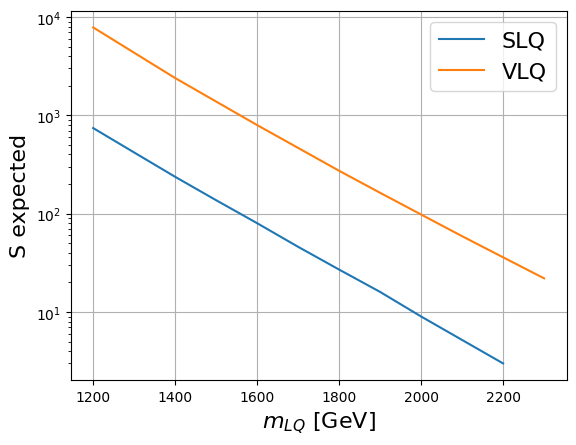

In [19]:
plt.plot(masses_SLQ, S_expected_SLQ, label='SLQ')
plt.plot(masses_VLQ, S_expected_VLQ, label='VLQ')
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]", fontsize=16)
plt.ylabel("S expected", fontsize=16)
plt.grid()
plt.legend(fontsize=16)
plt.show()

In [20]:
matched_VLQ_masses = []

for s_ev in S_expected_SLQ:
    # buscamos la VLQ que tenga la menor diferencia de eventos
    idx_match = np.argmin([abs(vlq_ev - s_ev) for vlq_ev in S_expected_VLQ])
    matched_mass = masses_VLQ[idx_match]
    matched_VLQ_masses.append(matched_mass)

# Mostrar resultados
for slq, s_ev, vlq, v_ev in zip(masses_SLQ, S_expected_SLQ, matched_VLQ_masses,
                                 [S_expected_VLQ[masses_VLQ.index(m)] for m in matched_VLQ_masses]):
    print(f"SLQ {slq} GeV ({s_ev} ev)  -> VLQ {vlq} GeV ({v_ev} ev)")

SLQ 1200 GeV (742 ev)  -> VLQ 1600 GeV (796 ev)
SLQ 1300 GeV (419 ev)  -> VLQ 1700 GeV (466 ev)
SLQ 1400 GeV (237 ev)  -> VLQ 1800 GeV (273 ev)
SLQ 1500 GeV (137 ev)  -> VLQ 1900 GeV (163 ev)
SLQ 1600 GeV (80 ev)  -> VLQ 2000 GeV (98 ev)
SLQ 1700 GeV (46 ev)  -> VLQ 2200 GeV (36 ev)
SLQ 1800 GeV (27 ev)  -> VLQ 2300 GeV (22 ev)
SLQ 1900 GeV (16 ev)  -> VLQ 2300 GeV (22 ev)
SLQ 2000 GeV (9 ev)  -> VLQ 2300 GeV (22 ev)
SLQ 2200 GeV (3 ev)  -> VLQ 2300 GeV (22 ev)


### Plot

In [52]:
def plot_variable(var_name_aux, SLQ_data, VLQ_data, SM_data,
                  masses_SLQ, masses_VLQ,
                  bins=25, range=[20,2500], logy=True):

    var_name = feats_label.index(var_name_aux)

    plt.figure(figsize=(6,5))

    # --- Señal SLQ ---
    colors_SLQ = ['red', 'pink', 'orange', 'purple']  # ajustar según # de masas
    for i, m in enumerate(masses_SLQ):
        data = SLQ_data[m][:,var_name]
        plt.hist(data[:], bins=bins, lw=2, range=range, density=True,
                 edgecolor=colors_SLQ[i], histtype='step', label=f'SLQ {m} GeV')

    # --- Señal VLQ ---
    colors_VLQ = ['lime', 'dodgerblue', 'cyan', 'magenta']  # ajustar según # de masas
    for i, m in enumerate(masses_VLQ):
        data = VLQ_data[m][:,var_name]
        plt.hist(data[:], bins=bins, lw=2, range=range, density=True,
                 edgecolor=colors_VLQ[i], histtype='step', label=f'VLQ {m} GeV')

    # --- Background stacked ---
    # se combinan todos los backgrounds en un solo histograma apilado
    bg_data_list = [
        SM_data['tt'][:int(len(SM_data['tt'])*fidxsec_SM['tt']/totalcrossSM),var_name],
        np.concatenate([SM_data['singletP1'][:int(len(SM_data['singletP1'])*fidxsec_SM['singletP1']/totalcrossSM),var_name], SM_data['singletP2'][:int(len(SM_data['singletP2'])*fidxsec_SM['singletP2']/totalcrossSM),var_name]]),
        SM_data['Wbbjets'][:int(len(SM_data['Wbbjets'])*fidxsec_SM['Wbbjets']/totalcrossSM),var_name],
        np.concatenate([SM_data['ttW'][:int(len(SM_data['ttW'])*fidxsec_SM['ttW']/totalcrossSM),var_name], SM_data['ttZ'][:int(len(SM_data['ttZ'])*fidxsec_SM['ttZ']/totalcrossSM),var_name], SM_data['ttH'][:int(len(SM_data['ttH'])*fidxsec_SM['ttH']/totalcrossSM),var_name]])
    ]

    bg_colors = ['blue','green','magenta','black']
    plt.hist([d[:] for d in bg_data_list], bins=bins, lw=2, range=range, density=True,
             stacked=True, color=bg_colors, label=['tt','single t','W+j','tt/fake'])

    # --- Configuración del plot ---
    plt.grid()
    plt.xlabel(f"{var_name} [GeV]", fontsize=14)
    plt.ylabel("Fraction of Events/bin", fontsize=14)
    plt.xlim(range)

    if logy:
        plt.yscale('log')
        plt.ylim(1e-7,1e-2)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=10)
    plt.show()

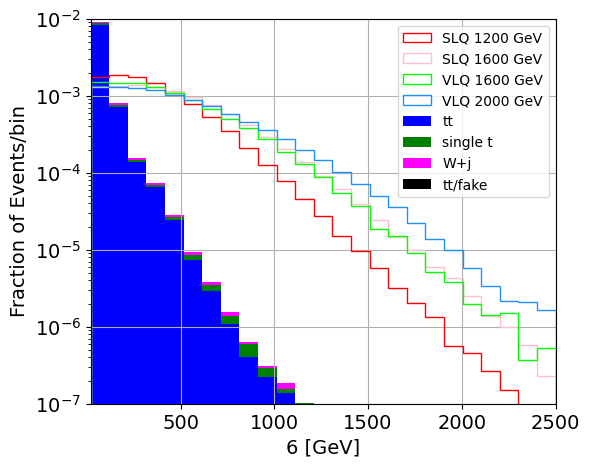

In [53]:
# Ejemplo: plot pT del tau
plot_variable('tau-pt', X_SLQ_all, X_VLQ_all, X_B_all,
              masses_SLQ=[1200,1600],
              masses_VLQ=[1600,2000],
              bins=25, range=[20,2500])

# LQ mass reconstruction

#### Aux functions

In [54]:
@njit
def invariant_mass_2(pt1, eta1, phi1, m1, pt2, eta2, phi2, m2):
    E1 = np.sqrt(pt1*pt1*np.cosh(eta1)**2 + m1*m1)
    E2 = np.sqrt(pt2*pt2*np.cosh(eta2)**2 + m2*m2)

    px = pt1*np.cos(phi1) + pt2*np.cos(phi2)
    py = pt1*np.sin(phi1) + pt2*np.sin(phi2)
    pz = pt1*np.sinh(eta1) + pt2*np.sinh(eta2)

    M2 = (E1+E2)**2 - (px*px + py*py + pz*pz)
    return np.sqrt(M2) if M2 > 0.0 else 0.0

@njit
def invariant_mass_3(jets, i1, i2, i3, m_jet):
    px = py = pz = E = 0.0

    for i in (i1, i2, i3):
        pt, eta, phi = jets[i]
        px += pt*np.cos(phi)
        py += pt*np.sin(phi)
        pz += pt*np.sinh(eta)
        E  += np.sqrt(px*px + py*py + pz*pz + m_jet*m_jet)

    m2 = E*E - (px*px + py*py + pz*pz)
    return np.sqrt(m2) if m2 > 0.0 else 0.0


@njit
def reconstruct_LQ2(jets, idx, MET):
    px = py = pz = E = 0.0

    for i in idx:
        pt, eta, phi = jets[i]
        px += pt*np.cos(phi)
        py += pt*np.sin(phi)
        pz += pt*np.sinh(eta)
        E  += pt*np.cosh(eta)

    met_pt, met_eta, met_phi = MET
    px += met_pt*np.cos(met_phi)
    py += met_pt*np.sin(met_phi)
    pz += met_pt*np.sinh(met_eta)
    E  += met_pt*np.cosh(met_eta)

    m2 = E*E - (px*px + py*py + pz*pz)
    return np.sqrt(m2) if m2 > 0.0 else 0.0




In [55]:


@njit
def invariant_mass_3_custom(j1, j2, j3, m_jet=4.7):

    # --- Jet 1 ---
    pt1, eta1, phi1 = j1
    px1 = pt1 * np.cos(phi1)
    py1 = pt1 * np.sin(phi1)
    pz1 = pt1 * np.sinh(eta1)
    E1  = np.sqrt(px1**2 + py1**2 + pz1**2 + m_jet**2)

    # --- Jet 2 ---
    pt2, eta2, phi2 = j2
    px2 = pt2 * np.cos(phi2)
    py2 = pt2 * np.sin(phi2)
    pz2 = pt2 * np.sinh(eta2)
    E2  = np.sqrt(px2**2 + py2**2 + pz2**2 + m_jet**2)

    # --- Jet 3 ---
    pt3, eta3, phi3 = j3
    px3 = pt3 * np.cos(phi3)
    py3 = pt3 * np.sin(phi3)
    pz3 = pt3 * np.sinh(eta3)
    E3  = np.sqrt(px3**2 + py3**2 + pz3**2 + m_jet**2)

    # --- Sum 4-vector ---
    px = px1 + px2 + px3
    py = py1 + py2 + py3
    pz = pz1 + pz2 + pz3
    E  = E1 + E2 + E3

    m2 = E**2 - px**2 - py**2 - pz**2

    return np.sqrt(m2) if m2 > 0.0 else 0.0


@njit
def reconstruct_LQ2_1jet(b_top, jet, MET, m_jet=4.7):

    # ---- b jet ----
    pt_b, eta_b, phi_b = b_top
    px_b = pt_b * np.cos(phi_b)
    py_b = pt_b * np.sin(phi_b)
    pz_b = pt_b * np.sinh(eta_b)
    E_b  = np.sqrt(px_b**2 + py_b**2 + pz_b**2 + m_jet**2)

    # ---- extra jet ----
    pt_j, eta_j, phi_j = jet
    px_j = pt_j * np.cos(phi_j)
    py_j = pt_j * np.sin(phi_j)
    pz_j = pt_j * np.sinh(eta_j)
    E_j  = np.sqrt(px_j**2 + py_j**2 + pz_j**2 + m_jet**2)

    # ---- MET (neutrino, masa = 0) ----
    pt_met, _, phi_met = MET
    px_met = pt_met * np.cos(phi_met)
    py_met = pt_met * np.sin(phi_met)
    pz_met = 0.0
    E_met  = np.sqrt(px_met**2 + py_met**2)

    # ---- suma de 4-vectores ----
    px = px_b + px_j + px_met
    py = py_b + py_j + py_met
    pz = pz_b + pz_j + pz_met
    E  = E_b  + E_j  + E_met

    m2 = E**2 - (px**2 + py**2 + pz**2)

    return np.sqrt(m2) if m2 > 0.0 else 0.0


@njit
def reconstruct_LQ2_2jets(b_top, jet, jet2, MET, m_jet=4.7):

    # ---- b jet ----
    pt_b, eta_b, phi_b = b_top
    px_b = pt_b * np.cos(phi_b)
    py_b = pt_b * np.sin(phi_b)
    pz_b = pt_b * np.sinh(eta_b)
    E_b  = np.sqrt(px_b**2 + py_b**2 + pz_b**2 + m_jet**2)

    # ---- extra jet 1 ----
    pt_j, eta_j, phi_j = jet
    px_j = pt_j * np.cos(phi_j)
    py_j = pt_j * np.sin(phi_j)
    pz_j = pt_j * np.sinh(eta_j)
    E_j  = np.sqrt(px_j**2 + py_j**2 + pz_j**2 + m_jet**2)

    # ---- extra jet 2 ----
    pt_j2, eta_j2, phi_j2 = jet2
    px_j2 = pt_j2 * np.cos(phi_j2)
    py_j2 = pt_j2 * np.sin(phi_j2)
    pz_j2 = pt_j2 * np.sinh(eta_j2)
    E_j2  = np.sqrt(px_j2**2 + py_j2**2 + pz_j2**2 + m_jet**2)

    # ---- MET (neutrino, masa = 0) ----
    pt_met, _, phi_met = MET
    px_met = pt_met * np.cos(phi_met)
    py_met = pt_met * np.sin(phi_met)
    pz_met = 0.0
    E_met  = np.sqrt(px_met**2 + py_met**2)

    # ---- suma de 4-vectores ----
    px = px_b + px_j + px_j2 + px_met
    py = py_b + py_j + py_j2 + py_met
    pz = pz_b + pz_j + pz_j2 + pz_met
    E  = E_b  + E_j + E_j2 + E_met

    m2 = E**2 - (px**2 + py**2 + pz**2)

    return np.sqrt(m2) if m2 > 0.0 else 0.0


In [118]:
@njit
def find_best_LQ_pairing_btag_W(
    tau, b1, b2, jet1, jet2, MET,
    m_top_target=173.0, m_jet=4.7, m_tau=1.777, m_W_target = 80.4
):

    # N_JETS_MAX = jets_rest.shape[0]

    # # guardar solo jets válidos
    # jets_extra = np.zeros((N_JETS_MAX, 3))
    # n_extra = 0
    # for i in range(N_JETS_MAX):
    #     if jets_rest[i, 0] > 0.0:
    #         jets_extra[n_extra] = jets_rest[i]
    #         n_extra += 1

    n_extra = 2
    jets_extra = np.array([jet1, jet2])

    best_mLQ1 = np.nan
    best_mLQ2 = np.nan
    best_mTop = np.nan
    best_mW = np.nan
    best_diff = 1e9
    best_top_err = 1e9

    best_mLQ10 = np.nan
    best_mLQ20 = np.nan
    best_mLQ11 = np.nan
    best_mLQ21 = np.nan
    best_mLQ12 = np.nan
    best_mLQ22 = np.nan

    # probar las dos asignaciones posibles:
    # (b1 -> LQ1, b2 -> top) y viceversa
    for swap in range(2):

        if swap == 0:
            b_LQ1 = b1
            b_top = b2
        else:
            b_LQ1 = b2
            b_top = b1

        # -------- LQ1 siempre tau + b --------
        mLQ1 = invariant_mass_2(
            b_LQ1[0], b_LQ1[1], b_LQ1[2], m_jet,
            tau[0], tau[1], tau[2], m_tau
        )

        # ==========================================================
        # CASO 0: no hay jets extra
        # ==========================================================
        if n_extra == 0:

            mTop = np.nan  # no top reconstruible
            mLQ2 = invariant_mass_2(
                b_top[0], b_top[1], b_top[2], m_jet,
                MET[0], 0.0, MET[2], 0.0
            )

            diff = abs(mLQ1 - mLQ2)

            if diff < best_diff:
                best_diff = diff
                best_mLQ1 = mLQ1
                best_mLQ2 = mLQ2
                best_mTop = mTop

                best_mLQ10 = mLQ1
                best_mLQ20 = mLQ2

        # ==========================================================
        # CASO 1: un jet extra
        # ==========================================================
        elif n_extra == 1:

            jet = jets_extra[0]

            # top = b + jet
            mTop = invariant_mass_2(
                b_top[0], b_top[1], b_top[2], m_jet,
                jet[0], jet[1], jet[2], m_jet
            )

            mLQ2 = reconstruct_LQ2_1jet(b_top, jet, MET)

            top_err = abs(mTop - m_top_target)
            diff = abs(mLQ1 - mLQ2)

            if (top_err < best_top_err) or \
               (top_err == best_top_err and diff < best_diff):

                best_top_err = top_err
                best_diff = diff
                best_mLQ1 = mLQ1
                best_mLQ2 = mLQ2
                best_mTop = mTop

                best_mLQ11 = mLQ1
                best_mLQ21 = mLQ2

        # ==========================================================
        # CASO ≥2 jets extra
        # ==========================================================

        else:
            best_w_err = 1e9
            best_i = -1
            best_j = -1

            # -----------------------------------
            # 1) Encontrar par que mejor reconstruye W
            # -----------------------------------
            for i in range(n_extra):
                for j in range(i+1, n_extra):

                    mW = invariant_mass_2(
                        jets_extra[i,0], jets_extra[i,1], jets_extra[i,2], m_jet,
                        jets_extra[j,0], jets_extra[j,1], jets_extra[j,2], m_jet
                    )

                    w_err = abs(mW - m_W_target)

                    if w_err < best_w_err:
                        best_w_err = w_err
                        best_i = i
                        best_j = j
                        best_mW = mW

            # -----------------------------------
            # 2) Reconstruir top con ese par
            # -----------------------------------
            jet1 = jets_extra[best_i]
            jet2 = jets_extra[best_j]

            mTop = invariant_mass_3_custom(
                b_top, jet1, jet2, m_jet
            )

            mLQ2 = reconstruct_LQ2_2jets(
                b_top, jet1, jet2, MET
            )

            top_err = abs(mTop - m_top_target)
            diff = abs(mLQ1 - mLQ2)

            if (top_err < best_top_err) or \
               (top_err == best_top_err and diff < best_diff):

                best_top_err = top_err
                best_diff = diff
                best_mLQ1 = mLQ1
                best_mLQ2 = mLQ2
                best_mTop = mTop

                best_mLQ12 = mLQ1
                best_mLQ22 = mLQ2

    return best_mLQ1, best_mLQ2, best_mTop, best_diff, best_mW, best_mLQ10, best_mLQ20, best_mLQ11, best_mLQ21, best_mLQ12, best_mLQ22

In [134]:
# --- Padding jets ---
def pad_jets(jets_list, max_jets=6):
    arr = np.zeros((max_jets, 3), dtype=np.float64)
    n = min(len(jets_list), max_jets)
    for i in range(n):
        arr[i, :3] = jets_list[i][:3]
    return arr

# --- Reconstruct LQ for a dataset ---
def compute_LQ_features_btag_W(data_dict, N_JETS_MAX=6):
    """
    data_dict: dict with keys 'b1','b2','tau','MET','jets_rest'
    Returns dict with mLQ1, mLQ2, mTop, dM, mW
    """
    n_events = len(data_dict)

    mLQ1 = np.zeros(n_events, dtype=np.float64)
    mLQ2 = np.zeros(n_events, dtype=np.float64)
    mTop = np.zeros(n_events, dtype=np.float64)
    dM   = np.zeros(n_events, dtype=np.float64)
    mW  = np.zeros(n_events, dtype=np.float64)

    mLQ10 = np.zeros(n_events, dtype=np.float64)
    mLQ20 = np.zeros(n_events, dtype=np.float64)
    mLQ11 = np.zeros(n_events, dtype=np.float64)
    mLQ21 = np.zeros(n_events, dtype=np.float64)
    mLQ12 = np.zeros(n_events, dtype=np.float64)
    mLQ22 = np.zeros(n_events, dtype=np.float64)

    # padding jets
    # jets_rest_padded = np.array([pad_jets(jets, N_JETS_MAX) for jets in data_dict['jets_rest']], dtype=np.float64)

    for i in range(n_events):
        tau_i = np.array([data_dict[:,feats_label.index('tau-pt')], data_dict[:,feats_label.index('tau-eta')], data_dict[:,feats_label.index('tau-phi')]])[:,i]
        b1_i = np.array([data_dict[:,feats_label.index('b1-pt')], data_dict[:,feats_label.index('b1-eta')], data_dict[:,feats_label.index('b1-phi')]])[:,i]
        b2_i = np.array([data_dict[:,feats_label.index('b2-pt')], data_dict[:,feats_label.index('b2-eta')], data_dict[:,feats_label.index('b2-phi')]])[:,i]
        jet1_i = np.array([data_dict[:,feats_label.index('jet1-pt')], data_dict[:,feats_label.index('jet1-eta')], data_dict[:,feats_label.index('jet1-phi')]])[:,i]
        jet2_i = np.array([data_dict[:,feats_label.index('jet2-pt')], data_dict[:,feats_label.index('jet2-eta')], data_dict[:,feats_label.index('jet2-phi')]])[:,i]
        MET_i = np.array([data_dict[:,feats_label.index('MET-pt')], np.zeros(len(data_dict)), data_dict[:,feats_label.index('MET-phi')]])[:,i]

        mLQ1[i], mLQ2[i], mTop[i], dM[i], mW[i], mLQ10[i], mLQ20[i], mLQ11[i], mLQ21[i], mLQ12[i], mLQ22[i] = find_best_LQ_pairing_btag_W(
            tau_i,
            b1_i,
            b2_i,
            jet1_i.tolist(),
            jet2_i.tolist(),
            MET_i
        )

    # del jets_rest_padded

    # replace nan with a 0
    mLQ1 = np.nan_to_num(mLQ1, nan=0.0)
    mLQ2 = np.nan_to_num(mLQ2, nan=0.0)
    mTop = np.nan_to_num(mTop, nan=0.0)
    dM   = np.nan_to_num(dM, nan=0.0)
    mW   = np.nan_to_num(mW, nan=0.0)

    mLQ10 = np.nan_to_num(mLQ10, nan=0.0)
    mLQ20 = np.nan_to_num(mLQ20, nan=0.0)
    mLQ11 = np.nan_to_num(mLQ11, nan=0.0)
    mLQ21 = np.nan_to_num(mLQ21, nan=0.0)
    mLQ12 = np.nan_to_num(mLQ12, nan=0.0)
    mLQ22 = np.nan_to_num(mLQ22, nan=0.0)

    return {'mLQ1': mLQ1, 'mLQ2': mLQ2, 'mTop': mTop, 'dM': dM, 'mW': mW, 'mLQ10': mLQ10, 'mLQ20': mLQ20, 'mLQ11': mLQ11, 'mLQ21': mLQ21, 'mLQ12': mLQ12, 'mLQ22': mLQ22}

In [135]:
compute_LQ_features_btag_W(X_SLQ_all[1200])

KeyboardInterrupt: 

In [72]:
np.array([X_SLQ_all[1200][:,6], X_SLQ_all[1200][:,7], X_SLQ_all[1200][:,8]])[:,0]

array([156.36 ,   0.227,  -2.163])

In [84]:
X_SLQ_all[1200][:,feats_label.index('jet2-phi')]

array([ 2.396,  0.   ,  2.284, ..., -0.298,  1.17 , -2.92 ])

In [82]:
np.zeros(len(X_SLQ_all[1200]))

array([0., 0., 0., ..., 0., 0., 0.])

In [61]:
# --- Apply to all SLQ ---
for mass in X_SLQ_all:
    X_SLQ_all[mass].add(compute_LQ_features_btag_W(X_SLQ_all[mass]))

AttributeError: 'numpy.ndarray' object has no attribute 'add'

In [ ]:
# --- Apply to all SLQ ---
for mass in SLQ_data:
    SLQ_data[mass].update(compute_LQ_features_btag_W(SLQ_data[mass]))

# --- Apply to all VLQ ---
for mass in VLQ_data:
    VLQ_data[mass].update(compute_LQ_features_btag_W(VLQ_data[mass]))

# --- Apply to the combined background ---
SM_features.update(compute_LQ_features_btag_W(SM_features))


 ALL
scalar:
mean LQ1 (b + tau):  761.457215676994
mean LQ2 (top + MET):  1056.6490719503072

vector:
mean LQ1 (b + tau):  738.6768038469362
mean LQ2 (top + MET):  1051.9452936987059

SM:
mean LQ1 (b + tau):  213.6535157299013
mean LQ2 (top + MET):  759.6201307888902

 jets=0
scalar:
mean LQ1 (b + tau):  813.1809576398296
mean LQ2 (top + MET):  841.0543804366293

vector:
mean LQ1 (b + tau):  789.4640282570456
mean LQ2 (top + MET):  804.8109426434352

SM:
mean LQ1 (b + tau):  354.17557231913673
mean LQ2 (top + MET):  285.4701626243047

 jets=1
scalar:
mean LQ1 (b + tau):  809.1252166064174
mean LQ2 (top + MET):  1057.6319994702146

vector:
mean LQ1 (b + tau):  788.836557366958
mean LQ2 (top + MET):  1048.1716917175706

SM:
mean LQ1 (b + tau):  198.77816962151851
mean LQ2 (top + MET):  796.3162337392203

 jets>=2
scalar:
mean LQ1 (b + tau):  749.2195981452544
mean LQ2 (top + MET):  1068.780224533756

vector:
mean LQ1 (b + tau):  724.7258058535127
mean LQ2 (top + MET):  1068.163453440173

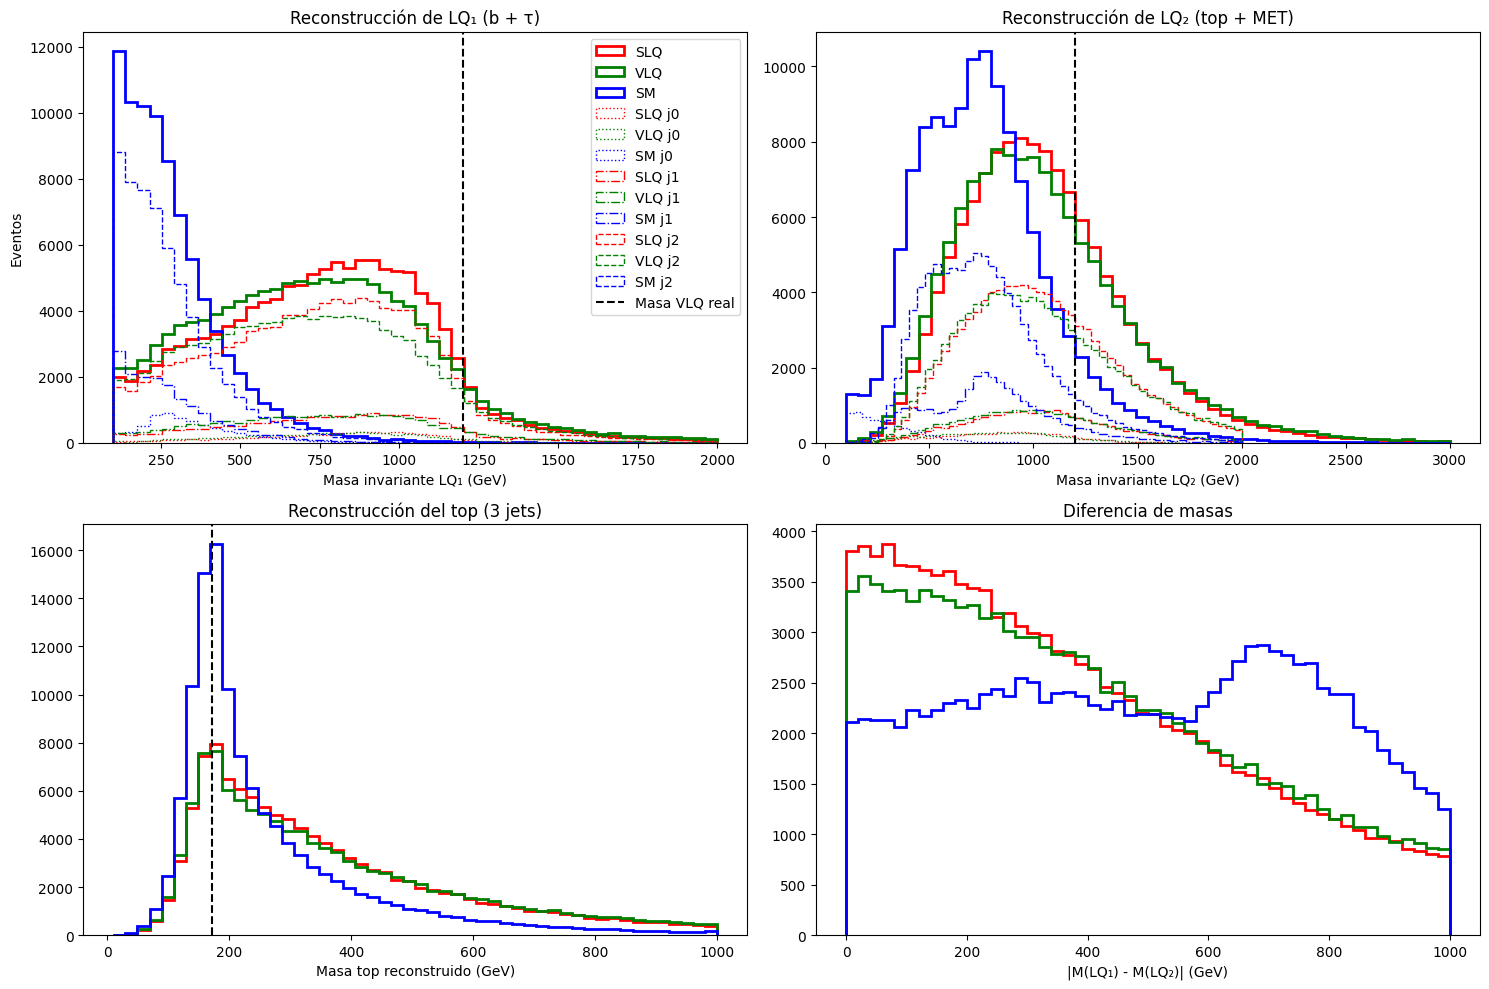

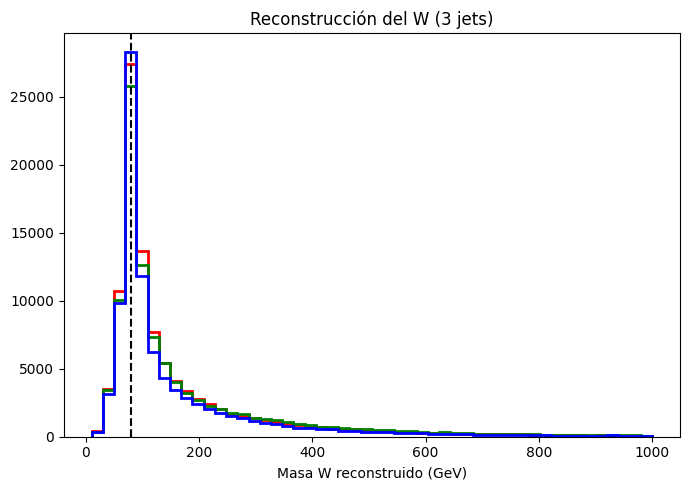

In [ ]:

mass_plot = 1200  # LQ mass

print('\n ALL')
print('scalar:')
print('mean LQ1 (b + tau): ', np.mean(SLQ_data[mass_plot]['mLQ1']))
print('mean LQ2 (top + MET): ', np.mean(SLQ_data[mass_plot]['mLQ2']))

print('\nvector:')
print('mean LQ1 (b + tau): ', np.mean(VLQ_data[mass_plot]['mLQ1']))
print('mean LQ2 (top + MET): ', np.mean(VLQ_data[mass_plot]['mLQ2']))

print('\nSM:')
print('mean LQ1 (b + tau): ', np.mean(SM_features['mLQ1']))
print('mean LQ2 (top + MET): ', np.mean(SM_features['mLQ2']))


print('\n jets=0')
print('scalar:')
print('mean LQ1 (b + tau): ', np.mean(SLQ_data[mass_plot]['mLQ10'][SLQ_data[mass_plot]['mLQ10'] != 0]))
print('mean LQ2 (top + MET): ', np.mean(SLQ_data[mass_plot]['mLQ20'][SLQ_data[mass_plot]['mLQ20'] != 0]))

print('\nvector:')
print('mean LQ1 (b + tau): ', np.mean(VLQ_data[mass_plot]['mLQ10'][VLQ_data[mass_plot]['mLQ10'] != 0]))
print('mean LQ2 (top + MET): ', np.mean(VLQ_data[mass_plot]['mLQ20'][VLQ_data[mass_plot]['mLQ20'] != 0]))

print('\nSM:')
print('mean LQ1 (b + tau): ', np.mean(SM_features['mLQ10'][SM_features['mLQ10'] != 0]))
print('mean LQ2 (top + MET): ', np.mean(SM_features['mLQ20'][SM_features['mLQ20'] != 0]))


print('\n jets=1')
print('scalar:')
print('mean LQ1 (b + tau): ', np.mean(SLQ_data[mass_plot]['mLQ11'][SLQ_data[mass_plot]['mLQ11'] != 0]))
print('mean LQ2 (top + MET): ', np.mean(SLQ_data[mass_plot]['mLQ21'][SLQ_data[mass_plot]['mLQ21'] != 0]))

print('\nvector:')
print('mean LQ1 (b + tau): ', np.mean(VLQ_data[mass_plot]['mLQ11'][VLQ_data[mass_plot]['mLQ11'] != 0]))
print('mean LQ2 (top + MET): ', np.mean(VLQ_data[mass_plot]['mLQ21'][VLQ_data[mass_plot]['mLQ21'] != 0]))

print('\nSM:')
print('mean LQ1 (b + tau): ', np.mean(SM_features['mLQ11'][SM_features['mLQ11'] != 0]))
print('mean LQ2 (top + MET): ', np.mean(SM_features['mLQ21'][SM_features['mLQ21'] != 0]))


print('\n jets>=2')
print('scalar:')
print('mean LQ1 (b + tau): ', np.mean(SLQ_data[mass_plot]['mLQ12'][SLQ_data[mass_plot]['mLQ12'] != 0]))
print('mean LQ2 (top + MET): ', np.mean(SLQ_data[mass_plot]['mLQ22'][SLQ_data[mass_plot]['mLQ22'] != 0]))

print('\nvector:')
print('mean LQ1 (b + tau): ', np.mean(VLQ_data[mass_plot]['mLQ12'][VLQ_data[mass_plot]['mLQ12'] != 0]))
print('mean LQ2 (top + MET): ', np.mean(VLQ_data[mass_plot]['mLQ22'][VLQ_data[mass_plot]['mLQ22'] != 0]))

print('\nSM:')
print('mean LQ1 (b + tau): ', np.mean(SM_features['mLQ12'][SM_features['mLQ12'] != 0]))
print('mean LQ2 (top + MET): ', np.mean(SM_features['mLQ22'][SM_features['mLQ22'] != 0]))


# --- plot ---
plt.figure(figsize=(15, 10))

colors = {'SLQ':'red','VLQ':'green','SM':'blue'}

plt.subplot(2,2,1)
plt.hist(SLQ_data[mass_plot]['mLQ1'], bins=50, range=(100,2000), color=colors['SLQ'], histtype='step', linewidth=2, label='SLQ')
plt.hist(VLQ_data[mass_plot]['mLQ1'], bins=50, range=(100,2000), color=colors['VLQ'], histtype='step', linewidth=2, label='VLQ')
plt.hist(SM_features['mLQ1'], bins=50, range=(100,2000), color=colors['SM'], histtype='step', linewidth=2, label='SM')

plt.hist(SLQ_data[mass_plot]['mLQ10'], bins=50, range=(100,2000), color=colors['SLQ'], histtype='step', linestyle=':', linewidth=1, label='SLQ j0')
plt.hist(VLQ_data[mass_plot]['mLQ10'], bins=50, range=(100,2000), color=colors['VLQ'], histtype='step', linestyle=':', linewidth=1, label='VLQ j0')
plt.hist(SM_features['mLQ10'], bins=50, range=(100,2000), color=colors['SM'], histtype='step', linestyle=':', linewidth=1, label='SM j0')

plt.hist(SLQ_data[mass_plot]['mLQ11'], bins=50, range=(100,2000), color=colors['SLQ'], histtype='step', linestyle='-.', linewidth=1, label='SLQ j1')
plt.hist(VLQ_data[mass_plot]['mLQ11'], bins=50, range=(100,2000), color=colors['VLQ'], histtype='step', linestyle='-.', linewidth=1, label='VLQ j1')
plt.hist(SM_features['mLQ11'], bins=50, range=(100,2000), color=colors['SM'], histtype='step', linestyle='-.', linewidth=1, label='SM j1')

plt.hist(SLQ_data[mass_plot]['mLQ12'], bins=50, range=(100,2000), color=colors['SLQ'], histtype='step', linestyle='--', linewidth=1, label='SLQ j2')
plt.hist(VLQ_data[mass_plot]['mLQ12'], bins=50, range=(100,2000), color=colors['VLQ'], histtype='step', linestyle='--', linewidth=1, label='VLQ j2')
plt.hist(SM_features['mLQ12'], bins=50, range=(100,2000), color=colors['SM'], histtype='step', linestyle='--', linewidth=1, label='SM j2')

plt.axvline(mass_plot, color='black', linestyle='--', label='Masa VLQ real')
plt.xlabel("Masa invariante LQ₁ (GeV)")
plt.ylabel("Eventos")
plt.title("Reconstrucción de LQ₁ (b + τ)")
plt.legend()

plt.subplot(2,2,2)
plt.hist(SLQ_data[mass_plot]['mLQ2'], bins=50, range=(100,3000), color=colors['SLQ'], histtype='step', linewidth=2)
plt.hist(VLQ_data[mass_plot]['mLQ2'], bins=50, range=(100,3000), color=colors['VLQ'], histtype='step', linewidth=2)
plt.hist(SM_features['mLQ2'], bins=50, range=(100,3000), color=colors['SM'], histtype='step', linewidth=2)

plt.hist(SLQ_data[mass_plot]['mLQ20'], bins=50, range=(100,2000), color=colors['SLQ'], histtype='step', linestyle=':', linewidth=1, label='SLQ j0')
plt.hist(VLQ_data[mass_plot]['mLQ20'], bins=50, range=(100,2000), color=colors['VLQ'], histtype='step', linestyle=':', linewidth=1, label='VLQ j0')
plt.hist(SM_features['mLQ20'], bins=50, range=(100,2000), color=colors['SM'], histtype='step', linestyle=':', linewidth=1, label='SM j0')

plt.hist(SLQ_data[mass_plot]['mLQ21'], bins=50, range=(100,2000), color=colors['SLQ'], histtype='step', linestyle='-.', linewidth=1, label='SLQ j1')
plt.hist(VLQ_data[mass_plot]['mLQ21'], bins=50, range=(100,2000), color=colors['VLQ'], histtype='step', linestyle='-.', linewidth=1, label='VLQ j1')
plt.hist(SM_features['mLQ21'], bins=50, range=(100,2000), color=colors['SM'], histtype='step', linestyle='-.', linewidth=1, label='SM j1')

plt.hist(SLQ_data[mass_plot]['mLQ22'], bins=50, range=(100,2000), color=colors['SLQ'], histtype='step', linestyle='--', linewidth=1, label='SLQ j2')
plt.hist(VLQ_data[mass_plot]['mLQ22'], bins=50, range=(100,2000), color=colors['VLQ'], histtype='step', linestyle='--', linewidth=1, label='VLQ j2')
plt.hist(SM_features['mLQ22'], bins=50, range=(100,2000), color=colors['SM'], histtype='step', linestyle='--', linewidth=1, label='SM j2')

plt.axvline(mass_plot, color='black', linestyle='--')
plt.xlabel("Masa invariante LQ₂ (GeV)")
plt.title("Reconstrucción de LQ₂ (top + MET)")

plt.subplot(2,2,3)
plt.hist(SLQ_data[mass_plot]['mTop'], bins=50, range=(10,1000), color=colors['SLQ'], histtype='step', linewidth=2)
plt.hist(VLQ_data[mass_plot]['mTop'], bins=50, range=(10,1000), color=colors['VLQ'], histtype='step', linewidth=2)
plt.hist(SM_features['mTop'], bins=50, range=(10,1000), color=colors['SM'], histtype='step', linewidth=2)
plt.axvline(172.5, color='black', linestyle='--')
plt.xlabel("Masa top reconstruido (GeV)")
plt.title("Reconstrucción del top (3 jets)")

plt.subplot(2,2,4)
plt.hist(SLQ_data[mass_plot]['dM'], bins=50, range=(0,1000), color=colors['SLQ'], histtype='step', linewidth=2)
plt.hist(VLQ_data[mass_plot]['dM'], bins=50, range=(0,1000), color=colors['VLQ'], histtype='step', linewidth=2)
plt.hist(SM_features['dM'], bins=50, range=(0,1000), color=colors['SM'], histtype='step', linewidth=2)
plt.xlabel('|M(LQ₁) - M(LQ₂)| (GeV)')
plt.title('Diferencia de masas')

plt.tight_layout()
plt.show()



# --- plot ---
plt.figure(figsize=(7, 5))

colors = {'SLQ':'red','VLQ':'green','SM':'blue'}

plt.hist(SLQ_data[mass_plot]['mW'], bins=50, range=(10,1000), color=colors['SLQ'], histtype='step', linewidth=2)
plt.hist(VLQ_data[mass_plot]['mW'], bins=50, range=(10,1000), color=colors['VLQ'], histtype='step', linewidth=2)
plt.hist(SM_features['mW'], bins=50, range=(10,1000), color=colors['SM'], histtype='step', linewidth=2)
plt.axvline(80.4, color='black', linestyle='--')
plt.xlabel("Masa W reconstruido (GeV)")
plt.title("Reconstrucción del W (3 jets)")

plt.tight_layout()
plt.show()

only the ones with n_jets >= 2 
scalar:
mean LQ1 (b + tau):  749.2195981452544
mean LQ2 (top + MET):  1068.780224533756

vector:
mean LQ1 (b + tau):  724.7258058535127
mean LQ2 (top + MET):  1068.1634534401737

SM:
mean LQ1 (b + tau):  207.4399905832168
mean LQ2 (top + MET):  784.854040445103


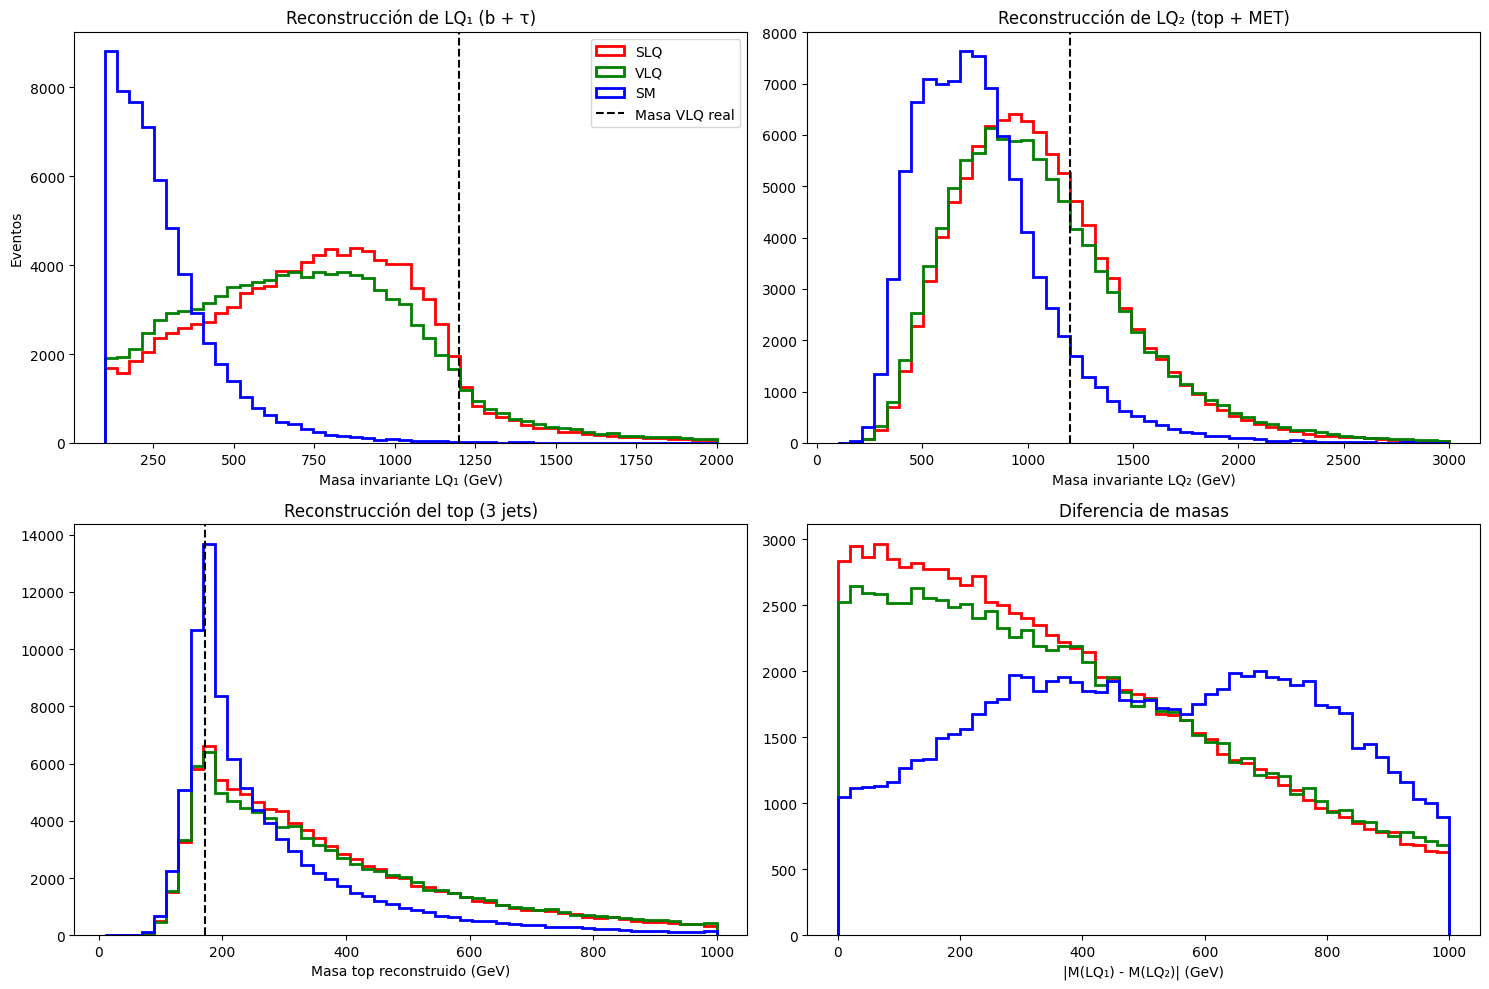

In [ ]:
print('only the ones with n_jets >= 2 ')

mass_plot = 1200  # LQ mass


print('scalar:')
print('mean LQ1 (b + tau): ', np.mean(SLQ_data[mass_plot]['mLQ1'][SLQ_data[mass_plot]['mW'] != 0]))
print('mean LQ2 (top + MET): ', np.mean(SLQ_data[mass_plot]['mLQ2'][SLQ_data[mass_plot]['mW'] != 0]))

print('\nvector:')
print('mean LQ1 (b + tau): ', np.mean(VLQ_data[mass_plot]['mLQ1'][VLQ_data[mass_plot]['mW'] != 0]))
print('mean LQ2 (top + MET): ', np.mean(VLQ_data[mass_plot]['mLQ2'][VLQ_data[mass_plot]['mW'] != 0]))

print('\nSM:')
print('mean LQ1 (b + tau): ', np.mean(SM_features['mLQ1'][SM_features['mW'] != 0]))
print('mean LQ2 (top + MET): ', np.mean(SM_features['mLQ2'][SM_features['mW'] != 0]))

# --- plot ---
plt.figure(figsize=(15, 10))

colors = {'SLQ':'red','VLQ':'green','SM':'blue'}

plt.subplot(2,2,1)
plt.hist(SLQ_data[mass_plot]['mLQ1'][SLQ_data[mass_plot]['mW'] != 0], bins=50, range=(100,2000), color=colors['SLQ'], histtype='step', linewidth=2, label='SLQ')
plt.hist(VLQ_data[mass_plot]['mLQ1'][VLQ_data[mass_plot]['mW'] != 0], bins=50, range=(100,2000), color=colors['VLQ'], histtype='step', linewidth=2, label='VLQ')
plt.hist(SM_features['mLQ1'][SM_features['mW'] != 0], bins=50, range=(100,2000), color=colors['SM'], histtype='step', linewidth=2, label='SM')
plt.axvline(mass_plot, color='black', linestyle='--', label='Masa VLQ real')
plt.xlabel("Masa invariante LQ₁ (GeV)")
plt.ylabel("Eventos")
plt.title("Reconstrucción de LQ₁ (b + τ)")
plt.legend()

plt.subplot(2,2,2)
plt.hist(SLQ_data[mass_plot]['mLQ2'][SLQ_data[mass_plot]['mW'] != 0], bins=50, range=(100,3000), color=colors['SLQ'], histtype='step', linewidth=2)
plt.hist(VLQ_data[mass_plot]['mLQ2'][VLQ_data[mass_plot]['mW'] != 0], bins=50, range=(100,3000), color=colors['VLQ'], histtype='step', linewidth=2)
plt.hist(SM_features['mLQ2'][SM_features['mW'] != 0], bins=50, range=(100,3000), color=colors['SM'], histtype='step', linewidth=2)
plt.axvline(mass_plot, color='black', linestyle='--')
plt.xlabel("Masa invariante LQ₂ (GeV)")
plt.title("Reconstrucción de LQ₂ (top + MET)")

plt.subplot(2,2,3)
plt.hist(SLQ_data[mass_plot]['mTop'][SLQ_data[mass_plot]['mW'] != 0], bins=50, range=(10,1000), color=colors['SLQ'], histtype='step', linewidth=2)
plt.hist(VLQ_data[mass_plot]['mTop'][VLQ_data[mass_plot]['mW'] != 0], bins=50, range=(10,1000), color=colors['VLQ'], histtype='step', linewidth=2)
plt.hist(SM_features['mTop'][SM_features['mW'] != 0], bins=50, range=(10,1000), color=colors['SM'], histtype='step', linewidth=2)
plt.axvline(172.5, color='black', linestyle='--')
plt.xlabel("Masa top reconstruido (GeV)")
plt.title("Reconstrucción del top (3 jets)")

plt.subplot(2,2,4)
plt.hist(SLQ_data[mass_plot]['dM'][SLQ_data[mass_plot]['mW'] != 0], bins=50, range=(0,1000), color=colors['SLQ'], histtype='step', linewidth=2)
plt.hist(VLQ_data[mass_plot]['dM'][VLQ_data[mass_plot]['mW'] != 0], bins=50, range=(0,1000), color=colors['VLQ'], histtype='step', linewidth=2)
plt.hist(SM_features['dM'][SM_features['mW'] != 0], bins=50, range=(0,1000), color=colors['SM'], histtype='step', linewidth=2)
plt.xlabel('|M(LQ₁) - M(LQ₂)| (GeV)')
plt.title('Diferencia de masas')

plt.tight_layout()
plt.show()

In [ ]:
# total number of events
n_SLQ = len(SLQ_data[mass_plot]['b1'])
n_VLQ = len(VLQ_data[mass_plot]['b1'])
n_SM = len(SM_features['b1'])

n_zeroW_SLQ = (SLQ_data[mass_plot]['mW'] == 0).sum()
n_zeroW_VLQ = (VLQ_data[mass_plot]['mW'] == 0).sum()
n_zeroW_SM = (SM_features['mW'] == 0).sum()

n_zeroTop_SLQ = (SLQ_data[mass_plot]['mTop'] == 0).sum()
n_zeroTop_VLQ = (VLQ_data[mass_plot]['mTop'] == 0).sum()
n_zeroTop_SM = (SM_features['mTop'] == 0).sum()

print(' SM')
print('Total # events: ', n_SM)
print("# mW = 0   (jets < 2):", n_zeroW_SM, '    ratio: ', n_zeroW_SM/n_SM)
print("# mTop = 0 (jets < 1):", n_zeroTop_SM, '     ratio: ', n_zeroTop_SM/n_SM)


print('\nSLQ')
print('Total # events: ', n_SLQ)
print("# mW = 0   (jets < 2):", n_zeroW_SLQ, '    ratio: ', n_zeroW_SLQ/n_SLQ)
print("# mTop = 0 (jets < 1):", n_zeroTop_SLQ, '     ratio: ', n_zeroTop_SLQ/n_SLQ)


print('\nVLQ')
print('Total # events: ', n_VLQ)
print("# mW = 0   (jets < 2):", n_zeroW_VLQ, '    ratio: ', n_zeroW_VLQ/n_VLQ)
print("# mTop = 0 (jets < 1):", n_zeroTop_VLQ, '     ratio: ', n_zeroTop_VLQ/n_VLQ)



 SM
Total # events:  127670
# mW = 0   (jets < 2): 36081     ratio:  0.2826114200673612
# mTop = 0 (jets < 1): 7116      ratio:  0.05573744810840448

SLQ
Total # events:  127670
# mW = 0   (jets < 2): 25686     ratio:  0.20119056943682934
# mTop = 0 (jets < 1): 5829      ratio:  0.045656771363671966

VLQ
Total # events:  127670
# mW = 0   (jets < 2): 27721     ratio:  0.21713010104174826
# mTop = 0 (jets < 1): 6231      ratio:  0.048805514216339


In [ ]:
# total number of events
n_SLQ = len(SLQ_data[mass_plot]['b1'])
n_VLQ = len(VLQ_data[mass_plot]['b1'])
n_SM = len(SM_features['b1'])

n_zeroTop_SLQ0 = (SLQ_data[mass_plot]['mLQ10'] != 0).sum()
n_zeroTop_VLQ0 = (VLQ_data[mass_plot]['mLQ10'] != 0).sum()
n_zeroTop_SM0 = (SM_features['mLQ10'] != 0).sum()

n_zeroTop_SLQ1 = (SLQ_data[mass_plot]['mLQ11'] != 0).sum()
n_zeroTop_VLQ1 = (VLQ_data[mass_plot]['mLQ11'] != 0).sum()
n_zeroTop_SM1 = (SM_features['mLQ11'] != 0).sum()

n_zeroTop_SLQ2 = (SLQ_data[mass_plot]['mLQ12'] != 0).sum()
n_zeroTop_VLQ2 = (VLQ_data[mass_plot]['mLQ12'] != 0).sum()
n_zeroTop_SM2 = (SM_features['mLQ12'] != 0).sum()


print(' SM')
print('Total # events: ', n_SM)
print("# jets = 0:", n_zeroTop_SM0, '     ratio: ', n_zeroTop_SM0/n_SM)
print("# jets = 1:", n_zeroTop_SM1, '     ratio: ', n_zeroTop_SM1/n_SM)
print("# jets >=2:", n_zeroTop_SM2, '     ratio: ', n_zeroTop_SM2/n_SM)

print('\nSLQ')
print('Total # events: ', n_SLQ)
print("# jets = 0:", n_zeroTop_SLQ0, '     ratio: ', n_zeroTop_SLQ0/n_SLQ)
print("# jets = 1:", n_zeroTop_SLQ1, '     ratio: ', n_zeroTop_SLQ1/n_SLQ)
print("# jets >=2:", n_zeroTop_SLQ2, '     ratio: ', n_zeroTop_SLQ2/n_SLQ)

print('\nVLQ')
print('Total # events: ', n_VLQ)
print("# jets = 0:", n_zeroTop_VLQ0, '     ratio: ', n_zeroTop_VLQ0/n_VLQ)
print("# jets = 1:", n_zeroTop_VLQ1, '     ratio: ', n_zeroTop_VLQ1/n_VLQ)
print("# jets >=2:", n_zeroTop_VLQ2, '     ratio: ', n_zeroTop_VLQ2/n_VLQ)


 SM
Total # events:  127670
# jets = 0: 7116      ratio:  0.05573744810840448
# jets = 1: 28965      ratio:  0.22687397195895667
# jets >=2: 91589      ratio:  0.7173885799326388

SLQ
Total # events:  127670
# jets = 0: 5829      ratio:  0.045656771363671966
# jets = 1: 19857      ratio:  0.15553379807315737
# jets >=2: 101984      ratio:  0.7988094305631707

VLQ
Total # events:  127670
# jets = 0: 6231      ratio:  0.048805514216339
# jets = 1: 21490      ratio:  0.16832458682540927
# jets >=2: 99949      ratio:  0.7828698989582518


#### Delete jets_rest

In [ ]:
for mass in masses_VLQ_tomin:
    del VLQ_data[mass]['jets_rest']

for mass in masses_VLQ_rest:
    del VLQ_data[mass]['jets_rest']

for mass in masses_SLQ_tomin:
    del SLQ_data[mass]['jets_rest']

for mass in masses_SLQ_rest:
    del SLQ_data[mass]['jets_rest']

for ch in channels:
    del SM_data[ch]['jets_rest']

del SM_features['jets_rest']


# HIGH-LEVEL FEATURES

In [ ]:
def delta_phi(p1, p2):
    """ phi diff in [-π, π]."""

    phi1 = p1[:,2]
    phi2 = p2[:,2]

    dphi = phi1 - phi2
    dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
    return dphi

def delta_R(p1, p2):
    """ΔR given (eta, phi)."""

    eta1 = p1[:,1]
    phi1 = p1[:,2]

    eta2 = p2[:,1]
    phi2 = p2[:,2]

    d_eta = eta1 - eta2
    d_phi = delta_phi(p1, p2)
    return np.sqrt(d_eta**2 + d_phi**2)


def inv_mass(p1, p2):
    """invariant mass (massless particles approx)."""
    pt1 = p1[:,0]
    eta1 = p1[:,1]
    phi1 = p1[:,2]

    pt2 = p2[:,0]
    eta2 = p2[:,1]
    phi2 = p2[:,2]


    delta_eta = eta1 - eta2
    delta_phi = np.mod(phi1 - phi2 + np.pi, 2 * np.pi) - np.pi  # [-π, π]

    cosh_delta_eta = np.cosh(delta_eta)
    cos_delta_phi = np.cos(delta_phi)

    m2 = 2 * pt1 * pt2 * (cosh_delta_eta - cos_delta_phi)
    m2 = np.maximum(m2, 0.0)  # avoid negative roots
    return np.sqrt(m2)


def trans_mass(p1, p2):
    """transverse mass between two objects (pt, phi)."""
    pt1 = p1[:,0]
    phi1 = p1[:,2]

    pt2 = p2[:,0]
    phi2 = p2[:,2]

    delta_phi = np.mod(phi1 - phi2 + np.pi, 2 * np.pi) - np.pi  # [-π, π]
    return np.sqrt(2 * pt1 * pt2 * (1 - np.cos(delta_phi)))


def sT(tau, b1, b2, jet1, jet2):
    """
    the scalar sum of the transverse momenta of the tau lepton and the two leading jets.
    """
    tau_pt = tau[:, 0]

    # Stack pt of b1, b2, jet1, jet2 => shape (N, 4)
    others_pt = np.stack([b1[:, 0], b2[:, 0], jet1[:, 0], jet2[:, 0]], axis=1)

    # Obtain the 2 higher pTs per row
    top2_pt = np.partition(others_pt, -2, axis=1)[:, -2:]

    # Sum the pTs: tau_pt + top2_pt.sum(axis=1)
    total_pt = tau_pt + np.sum(top2_pt, axis=1)

    return total_pt


def pT12(p1, p2):
    """
    transverse momenta of the p1 p2 system
    """
    px1 = p1[:, 0] * np.cos(p1[:, 1])
    px2 = p2[:, 0] * np.cos(p2[:, 1])

    px12 = px1 + px2

    py1 = p1[:, 0] * np.sin(p1[:, 1])
    py2 = p2[:, 0] * np.sin(p2[:, 1])

    py12 = py1 + py2

    return np.sqrt( px12**2 + py12**2 )


def costhetaCS(p1, p2):
    """
    cosine of the angle between p1 and p2 in Collins-Soper frame
    """
    dR12 = p1[:,2] - p2[:,2]
    p_T_12 = pT12(p1, p2)
    m12 = inv_mass(p1, p2)

    return ( np.sinh(dR12) / np.sqrt( 1 + (p_T_12/m12)**2 ) ) * (2 * p1[:,0] * p2[:,0] / (m12**2) )




In [ ]:
def compute_high_level_features(features):
    """
    Compute deltaR, deltaPhi, invariant masses, transverse masses, sT, mTb1b2, mTj1j2
    for a dictionary containing 'b1', 'b2', 'tau', 'jet1', 'jet2', 'MET'.
    Returns a dictionary with the new features.
    """
    f = {}  # new features

    # --- delta R ---
    f['dR_tau_b1'] = delta_R(features['tau'], features['b1'])
    f['dR_tau_b2'] = delta_R(features['tau'], features['b2'])
    f['dR_b1_b2'] = delta_R(features['b1'], features['b2'])

    f['dR_jet1_b1'] = delta_R(features['jet1'], features['b1'])
    f['dR_jet1_b2'] = delta_R(features['jet1'], features['b2'])
    f['dR_jet1_tau'] = delta_R(features['jet1'], features['tau'])

    f['dR_jet2_b1'] = delta_R(features['jet2'], features['b1'])
    f['dR_jet2_b2'] = delta_R(features['jet2'], features['b2'])
    f['dR_jet2_tau'] = delta_R(features['jet2'], features['tau'])

    f['dR_jet1_jet2'] = delta_R(features['jet1'], features['jet2'])

    # --- delta phi ---
    f['dphi_tau_b1'] = delta_phi(features['tau'], features['b1'])
    f['dphi_tau_b2'] = delta_phi(features['tau'], features['b2'])
    f['dphi_b1_b2'] = delta_phi(features['b1'], features['b2'])

    f['dphi_MET_b1'] = delta_phi(features['MET'], features['b1'])
    f['dphi_MET_b2'] = delta_phi(features['MET'], features['b2'])
    f['dphi_MET_tau'] = delta_phi(features['MET'], features['tau'])
    f['dphi_MET_jet1'] = delta_phi(features['MET'], features['jet1'])
    f['dphi_MET_jet2'] = delta_phi(features['MET'], features['jet2'])

    # --- invariant masses ---
    f['m_tau_b1'] = inv_mass(features['tau'], features['b1'])
    f['m_tau_b2'] = inv_mass(features['tau'], features['b2'])
    f['m_b1_b2'] = inv_mass(features['b1'], features['b2'])

    f['m_jet1_b1'] = inv_mass(features['jet1'], features['b1'])
    f['m_jet1_b2'] = inv_mass(features['jet1'], features['b2'])
    f['m_jet1_tau'] = inv_mass(features['jet1'], features['tau'])

    f['m_jet2_b1'] = inv_mass(features['jet2'], features['b1'])
    f['m_jet2_b2'] = inv_mass(features['jet2'], features['b2'])
    f['m_jet2_tau'] = inv_mass(features['jet2'], features['tau'])

    f['m_jet1_jet2'] = inv_mass(features['jet1'], features['jet2'])

    # --- transverse masses ---
    f['mT_MET_b1'] = trans_mass(features['MET'], features['b1'])
    f['mT_MET_b2'] = trans_mass(features['MET'], features['b2'])
    f['mT_MET_tau'] = trans_mass(features['MET'], features['tau'])
    f['mT_MET_jet1'] = trans_mass(features['MET'], features['jet1'])
    f['mT_MET_jet2'] = trans_mass(features['MET'], features['jet2'])

    f['mTb1b2'] = f['mT_MET_b1'] + f['mT_MET_b2']
    f['mTj1j2'] = f['mT_MET_jet1'] + f['mT_MET_jet2']

    # --- sT ---
    f['sT'] = sT(features['tau'], features['b1'], features['b2'], features['jet1'], features['jet2'])

    return f

In [ ]:
# --- Apply to all SLQ ---
for mass in SLQ_data:
    SLQ_data[mass].update(compute_high_level_features(SLQ_data[mass]))

In [ ]:
# --- Apply to all VLQ ---
for mass in VLQ_data:
    VLQ_data[mass].update(compute_high_level_features(VLQ_data[mass]))

In [ ]:
# --- Apply to the combined background ---
SM_features.update(compute_high_level_features(SM_features))

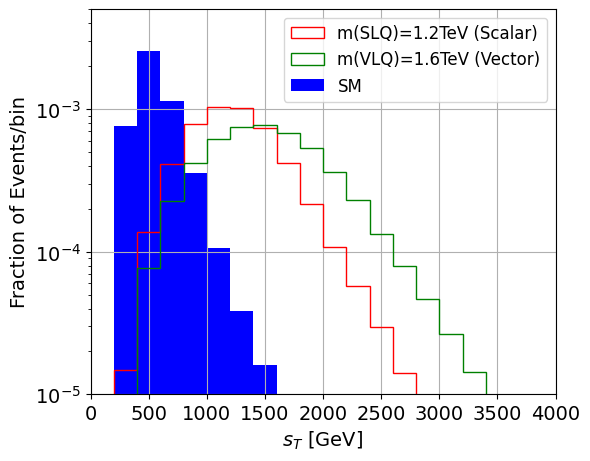

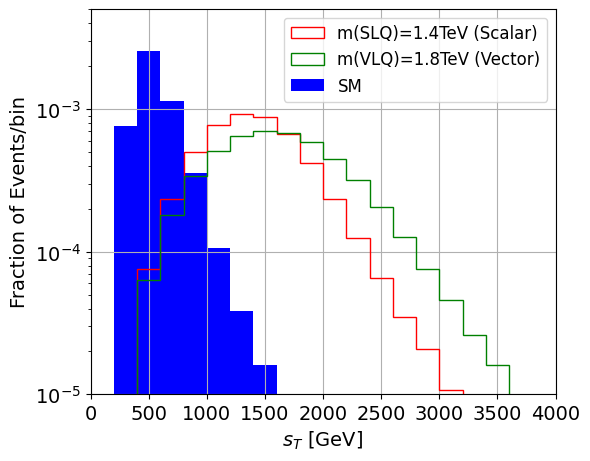

In [ ]:
def plot_feat(slq_mass, vlq_mass, feat_SLQ, feat_VLQ, feat_SM, slq_label=None, vlq_label=None):
    plt.figure(figsize=(6,5))

    plt.hist(feat_SLQ, bins=25, lw=2, range=[0,5000], density=True,
             edgecolor='red', histtype='step', label=slq_label)

    plt.hist(feat_VLQ, bins=25, lw=2, range=[0,5000], density=True,
             edgecolor='green', histtype='step', label=vlq_label)

    plt.hist(feat_SM, bins=25, lw=2, range=[0,5000], density=True, stacked=True, color=["blue"], label='SM')

    plt.grid()
#     plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
    plt.ylabel("Fraction of Events/bin", fontsize=14)
    plt.xlim(0,4000)
    plt.ylim(1e-5,5e-3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.yscale('log')
    plt.legend(fontsize=12)
#     plt.show()


feat = 'sT'

plot_feat(
    1200, 1600,
    SLQ_data[1200][feat],
    VLQ_data[1600][feat],
    SM_features[feat],
    slq_label=r'm(SLQ)=1.2TeV (Scalar)',
    vlq_label=r'm(VLQ)=1.6TeV (Vector)'
)
plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
plt.show()

plot_feat(
    1400, 1800,
    SLQ_data[1400][feat],
    VLQ_data[1800][feat],
    SM_features[feat],
    slq_label=r'm(SLQ)=1.4TeV (Scalar)',
    vlq_label=r'm(VLQ)=1.8TeV (Vector)'
)
plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
plt.show()

# 1. DATA FORMAT for CLASSIFIERS

In [ ]:
# Function to converts the features into a DataFrame

def features_to_df(features_dict):
    df = pd.DataFrame({
        'b1-pt': features_dict['b1'][:,0], 'b1-eta': features_dict['b1'][:,1], 'b1-phi': features_dict['b1'][:,2],
        'b2-pt': features_dict['b2'][:,0], 'b2-eta': features_dict['b2'][:,1], 'b2-phi': features_dict['b2'][:,2],
        'tau-pt': features_dict['tau'][:,0], 'tau-eta': features_dict['tau'][:,1], 'tau-phi': features_dict['tau'][:,2],
        'MET-pt': features_dict['MET'][:,0], 'MET-phi': features_dict['MET'][:,2],
        'HT-pt': features_dict['hadinfo'][:,0], 'num-jets': features_dict['hadinfo'][:,1], 'num-bjets': features_dict['hadinfo'][:,2],
        'dR-taub1': features_dict['dR_tau_b1'], 'dR-taub2': features_dict['dR_tau_b2'], 'dR-b1b2': features_dict['dR_b1_b2'],
        'dR-j1b1': features_dict['dR_jet1_b1'], 'dR-j1b2': features_dict['dR_jet1_b2'], 'dR-j1tau': features_dict['dR_jet1_tau'],
        'dR-j2b1': features_dict['dR_jet2_b1'], 'dR-j2b2': features_dict['dR_jet2_b2'], 'dR-j2tau': features_dict['dR_jet2_tau'],
        'dR-j1j2': features_dict['dR_jet1_jet2'],
        'dphi-METb1': features_dict['dphi_MET_b1'], 'dphi-METb2': features_dict['dphi_MET_b2'], 'dphi-METtau': features_dict['dphi_MET_tau'],
        'dphi-METj1': features_dict['dphi_MET_jet1'], 'dphi-METj2': features_dict['dphi_MET_jet2'],
        'm-taub1': features_dict['m_tau_b1'], 'm-taub2': features_dict['m_tau_b2'], 'm-b1b2': features_dict['m_b1_b2'],
        'm-j1b1': features_dict['m_jet1_b1'], 'm-j1b2': features_dict['m_jet1_b2'], 'm-j1tau': features_dict['m_jet1_tau'],
        'm-j2b1': features_dict['m_jet2_b1'], 'm-j2b2': features_dict['m_jet2_b2'], 'm-j2tau': features_dict['m_jet2_tau'],
        'm-j1j2': features_dict['m_jet1_jet2'],
        'mT-METb1': features_dict['mT_MET_b1'], 'mT-METb2': features_dict['mT_MET_b2'], 'mT-METtau': features_dict['mT_MET_tau'],
        'mT-METj1': features_dict['mT_MET_jet1'], 'mT-METj2': features_dict['mT_MET_jet2'],
        'mTb1b2': features_dict['mTb1b2'], 'mTj1j2': features_dict['mTj1j2'],'sT': features_dict['sT'],
        'mLQ1': features_dict['mLQ1'], 'mLQ2': features_dict['mLQ2'], 'mTop': features_dict['mTop']
    })
    return df

In [ ]:
# ---------------------------
# Convert to DataFrames
# ---------------------------

df_SM = features_to_df(SM_features)

df_VLQ = {}
for mass in masses_VLQ_tomin:
    df_VLQ[mass] = features_to_df(VLQ_data[mass])

df_SLQ = {}
for mass in masses_SLQ_tomin:
    df_SLQ[mass] = features_to_df(SLQ_data[mass])


df_VLQ_rest = {}
for mass in masses_VLQ_rest:
    df_VLQ_rest[mass] = features_to_df(VLQ_data[mass])

df_SLQ_rest = {}
for mass in masses_SLQ_rest:
    df_SLQ_rest[mass] = features_to_df(SLQ_data[mass])


# ---------------------------
# Concatenate all for normalization
# ---------------------------
df_all = pd.concat([df_SM] + list(df_SLQ.values()) + list(df_VLQ.values()), ignore_index=True)

# ---------------------------
# Normalization
# ---------------------------
scaler = MinMaxScaler()
scaler.fit(df_all)

# Save the scaler
joblib.dump(scaler, mainfolder + 'saved-models/scaler_features.pkl')

# Apply normalization
df_SM_norm = pd.DataFrame(scaler.transform(df_SM), columns=df_SM.columns)
df_SLQ_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ[mass]), columns=df_SLQ[mass].columns) for mass in df_SLQ}
df_VLQ_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ[mass]), columns=df_VLQ[mass].columns) for mass in df_VLQ}

df_SLQ_rest_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_rest[mass]), columns=df_SLQ_rest[mass].columns) for mass in df_SLQ_rest}
df_VLQ_rest_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_rest[mass]), columns=df_VLQ_rest[mass].columns) for mass in df_VLQ_rest}



# ---------------------------
# Divide datasets into train/val/test/pseudo
# ---------------------------
def split_class(df, test_ratio=0.25, val_ratio=0.10, pseudo_ratio=0.25):
    X = df.values
    aux_val_ratio = val_ratio / (1 - test_ratio)
    aux_pseudo_ratio = pseudo_ratio / (1 - test_ratio - val_ratio)

    X_aux, X_test = train_test_split(X, test_size=test_ratio, random_state=42, shuffle=True)
    X_aux2, X_val = train_test_split(X_aux, test_size=aux_val_ratio, random_state=42, shuffle=True)
    X_train, X_pseudo = train_test_split(X_aux2, test_size=aux_pseudo_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, X_pseudo



# ---------------------------
# Divide the datasets
# ---------------------------
split_SM = split_class(df_SM_norm)
split_SLQ = {mass: split_class(df_SLQ_norm[mass]) for mass in df_SLQ_norm}
split_VLQ = {mass: split_class(df_VLQ_norm[mass]) for mass in df_VLQ_norm}



# Example of how to use them
X_train_SM, X_val_SM, X_test_SM, X_pseudo_SM = split_SM
X_train_SLQ1200, X_val_SLQ1200, X_test_SLQ1200, X_pseudo_SLQ1200 = split_SLQ[1200]
X_train_VLQ1600, X_val_VLQ1600, X_test_VLQ1600, X_pseudo_VLQ1600 = split_VLQ[1600]

print('')
print('X_train_SM : ', X_train_SM.shape)
print('X_val_SM : ', X_val_SM.shape)
print('X_test_SM : ', X_test_SM.shape)
print('X_pseudo_SM : ', X_pseudo_SM.shape)

print('')
print('X_train_SLQ1200 : ', X_train_SLQ1200.shape)
print('X_val_SLQ1200 : ', X_val_SLQ1200.shape)
print('X_test_SLQ1200 : ', X_test_SLQ1200.shape)
print('X_pseudo_SLQ1200 : ', X_pseudo_SLQ1200.shape)

print('')
print('X_train_VLQ1600 : ', X_train_VLQ1600.shape)
print('X_val_VLQ1600 : ', X_val_VLQ1600.shape)
print('X_test_VLQ1600 : ', X_test_VLQ1600.shape)
print('X_pseudo_VLQ1600 : ', X_pseudo_VLQ1600.shape)


X_train_SM :  (51067, 50)
X_val_SM :  (12767, 50)
X_test_SM :  (31918, 50)
X_pseudo_SM :  (31918, 50)

X_train_SLQ1200 :  (51067, 50)
X_val_SLQ1200 :  (12767, 50)
X_test_SLQ1200 :  (31918, 50)
X_pseudo_SLQ1200 :  (31918, 50)

X_train_VLQ1600 :  (51067, 50)
X_val_VLQ1600 :  (12767, 50)
X_test_VLQ1600 :  (31918, 50)
X_pseudo_VLQ1600 :  (31918, 50)


In [ ]:
# To save memory

del VLQ_data
del SLQ_data
del SM_features

del df_VLQ
del df_SLQ
del df_SM

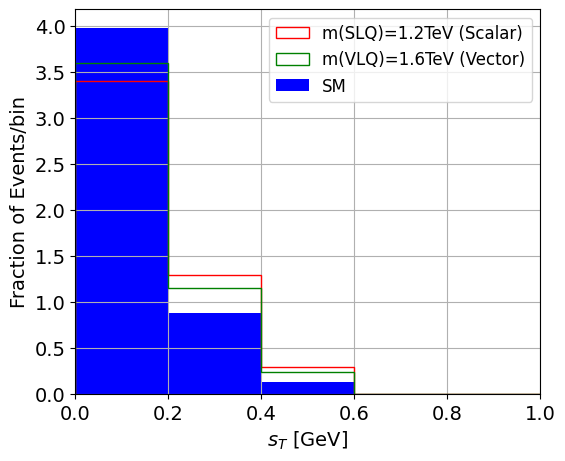

In [ ]:
def plot_feat(slq_mass, vlq_mass, feat_SLQ, feat_VLQ, feat_SM, slq_label=None, vlq_label=None):
    plt.figure(figsize=(6,5))

    plt.hist(feat_SLQ, bins=5, lw=2, range=[0,1], density=True,
             edgecolor='red', histtype='step', label=slq_label)

    plt.hist(feat_VLQ, bins=5, lw=2, range=[0,1], density=True,
             edgecolor='green', histtype='step', label=vlq_label)

    plt.hist(feat_SM, bins=5, lw=2, range=[0,1], density=True, stacked=True, color=["blue"], label='SM')

    plt.grid()
#     plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
    plt.ylabel("Fraction of Events/bin", fontsize=14)
    plt.xlim(0,1)
#     plt.ylim(1e-5,5e-3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
#     plt.yscale('log')
    plt.legend(fontsize=12)
#     plt.show()


feat = 'num-jets'

plot_feat(
    1200, 1600,
    df_SLQ_norm[1200][feat],
    df_VLQ_norm[1600][feat],
    df_SM_norm[feat],
    slq_label=r'm(SLQ)=1.2TeV (Scalar)',
    vlq_label=r'm(VLQ)=1.6TeV (Vector)'
)
plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
plt.show()

### Regresor

#### Without m_LQ (kinetic recontruction)

In [ ]:
split_SM_norec = split_class(df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop']))
split_SLQ_norec = {mass: split_class(df_SLQ_norm[mass].drop(columns=['mLQ1','mLQ2','mTop'])) for mass in df_SLQ_norm}
split_VLQ_norec = {mass: split_class(df_VLQ_norm[mass].drop(columns=['mLQ1','mLQ2','mTop'])) for mass in df_VLQ_norm}

In [ ]:
# Concatenate SLQ and VLQ
X_train_list = []
y_train_list = []

# SLQs
for mass, splits in split_SLQ_norec.items():
    X_train, _, _, _ = splits # use only the train
    X_train_list.append(X_train)
    y_train_list.append(np.full(len(X_train), mass))

# VLQs
for mass, splits in split_VLQ_norec.items():
    X_train, _, _, _ = splits
    X_train_list.append(X_train)
    y_train_list.append(np.full(len(X_train), mass))

# Concatenate
X_train_all = np.vstack(X_train_list)
y_train_all = np.concatenate(y_train_list)





X_test_list = []
y_test_list = []

for mass, splits in split_SLQ_norec.items():
    _, _, X_test, _ = splits
    X_test_list.append(X_test)
    y_test_list.append(np.full(len(X_test), mass))

for mass, splits in split_VLQ_norec.items():
    _, _, X_test, _ = splits
    X_test_list.append(X_test)
    y_test_list.append(np.full(len(X_test), mass))

X_test_all = np.vstack(X_test_list)
y_test_all = np.concatenate(y_test_list)

In [ ]:
regressor = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42
)


regressor.fit(X_train_all, y_train_all, verbose=True)


regressor.save_model(mainfolder + "saved-models/xgb_LQ_mass_norec.model")

/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:1116: UserWarning: [05:52:59] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:1125: UserWarning: [12:16:47] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1509: Unknown file format: `model`. Using UBJSON (`ubj`) as a guess.
  self.get_booster().load_model(fname)


RMSE: 277.11 GeV, R²: 0.229
R²:  1 → perfect, 0 → bad


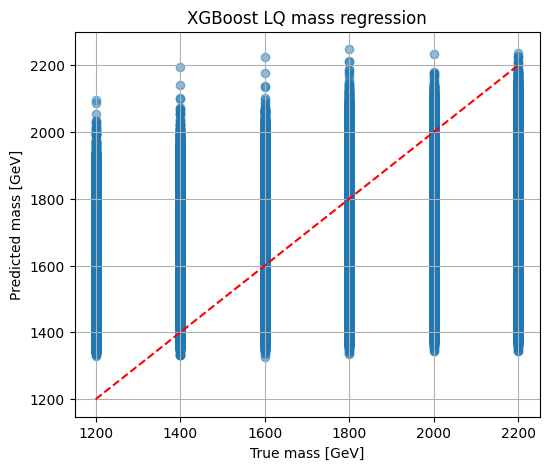

In [ ]:
# LOAD
regressor = XGBRegressor()
regressor.load_model(mainfolder + "saved-models/xgb_LQ_mass_norec.model")

y_pred = regressor.predict(X_test_all)

rmse = np.sqrt(mean_squared_error(y_test_all, y_pred))
r2 = r2_score(y_test_all, y_pred)
print(f"RMSE: {rmse:.2f} GeV, R²: {r2:.3f}")

print("R²:  1 → perfect, 0 → bad")



plt.figure(figsize=(6,5))
plt.scatter(y_test_all, y_pred, alpha=0.5)
plt.plot([y_test_all.min(), y_test_all.max()], [y_test_all.min(), y_test_all.max()], 'r--')
plt.xlabel("True mass [GeV]")
plt.ylabel("Predicted mass [GeV]")
plt.title("XGBoost LQ mass regression")
plt.grid()
plt.show()

SLQ1200: mean = 1505.58 GeV, sigma = 92.94 GeV, RMSE = 319.40 GeV, R² = 0.000
SLQ1400: mean = 1562.10 GeV, sigma = 108.60 GeV, RMSE = 195.11 GeV, R² = 0.000
VLQ1600: mean = 1617.64 GeV, sigma = 129.62 GeV, RMSE = 130.82 GeV, R² = 0.000
VLQ1800: mean = 1663.21 GeV, sigma = 144.08 GeV, RMSE = 198.67 GeV, R² = 0.000


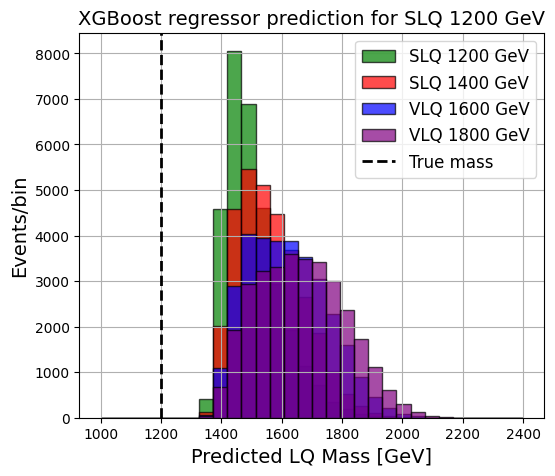

In [ ]:
# data
X_train_SLQ1200, X_val_SLQ1200, X_test_SLQ1200, X_pseudo_SLQ1200 = split_SLQ_norec[1200]
X_train_SLQ1400, X_val_SLQ1400, X_test_SLQ1400, X_pseudo_SLQ1400 = split_SLQ_norec[1400]

X_train_VLQ1600, X_val_VLQ1600, X_test_VLQ1600, X_pseudo_VLQ1600 = split_VLQ_norec[1600]
X_train_VLQ1800, X_val_VLQ1800, X_test_VLQ1800, X_pseudo_VLQ1800 = split_VLQ_norec[1800]

y_test_SLQ1200  = np.full(X_test_SLQ1200.shape[0], 1200.0)
y_test_SLQ1400  = np.full(X_test_SLQ1400.shape[0], 1400.0)

y_test_VLQ1600  = np.full(X_test_VLQ1600.shape[0], 1600.0)
y_test_VLQ1800  = np.full(X_test_VLQ1800.shape[0], 1800.0)


# Prediction
y_pred_SLQ1200 = regressor.predict(X_test_SLQ1200)
y_pred_SLQ1400 = regressor.predict(X_test_SLQ1400)

y_pred_VLQ1600 = regressor.predict(X_test_VLQ1600)
y_pred_VLQ1800 = regressor.predict(X_test_VLQ1800)


#  stats
mean_SLQ1200 = np.mean(y_pred_SLQ1200)
std_SLQ1200 = np.std(y_pred_SLQ1200)
rmse_SLQ1200 = np.sqrt(mean_squared_error(y_test_SLQ1200, y_pred_SLQ1200))
r2_SLQ1200   = r2_score(y_test_SLQ1200, y_pred_SLQ1200)
print(f"SLQ1200: mean = {mean_SLQ1200:.2f} GeV, sigma = {std_SLQ1200:.2f} GeV, RMSE = {rmse_SLQ1200:.2f} GeV, R² = {r2_SLQ1200:.3f}")

mean_SLQ1400 = np.mean(y_pred_SLQ1400)
std_SLQ1400 = np.std(y_pred_SLQ1400)
rmse_SLQ1400 = np.sqrt(mean_squared_error(y_test_SLQ1400, y_pred_SLQ1400))
r2_SLQ1400   = r2_score(y_test_SLQ1400, y_pred_SLQ1400)
print(f"SLQ1400: mean = {mean_SLQ1400:.2f} GeV, sigma = {std_SLQ1400:.2f} GeV, RMSE = {rmse_SLQ1400:.2f} GeV, R² = {r2_SLQ1400:.3f}")

mean_VLQ1600 = np.mean(y_pred_VLQ1600)
std_VLQ1600 = np.std(y_pred_VLQ1600)
rmse_VLQ1600 = np.sqrt(mean_squared_error(y_test_VLQ1600, y_pred_VLQ1600))
r2_VLQ1600   = r2_score(y_test_VLQ1600, y_pred_VLQ1600)
print(f"VLQ1600: mean = {mean_VLQ1600:.2f} GeV, sigma = {std_VLQ1600:.2f} GeV, RMSE = {rmse_VLQ1600:.2f} GeV, R² = {r2_VLQ1600:.3f}")

mean_VLQ1800 = np.mean(y_pred_VLQ1800)
std_VLQ1800 = np.std(y_pred_VLQ1800)
rmse_VLQ1800 = np.sqrt(mean_squared_error(y_test_VLQ1800, y_pred_VLQ1800))
r2_VLQ1800   = r2_score(y_test_VLQ1800, y_pred_VLQ1800)
print(f"VLQ1800: mean = {mean_VLQ1800:.2f} GeV, sigma = {std_VLQ1800:.2f} GeV, RMSE = {rmse_VLQ1800:.2f} GeV, R² = {r2_VLQ1800:.3f}")


# Histograma de la predicción
plt.figure(figsize=(6,5))
plt.hist(y_pred_SLQ1200, bins=30, range=[1000, 2400], color='green', alpha=0.7, edgecolor='black', label='SLQ 1200 GeV')
plt.hist(y_pred_SLQ1400, bins=30, range=[1000, 2400], color='red', alpha=0.7, edgecolor='black', label='SLQ 1400 GeV')
plt.hist(y_pred_VLQ1600, bins=30, range=[1000, 2400], color='blue', alpha=0.7, edgecolor='black', label='VLQ 1600 GeV')
plt.hist(y_pred_VLQ1800, bins=30, range=[1000, 2400], color='purple', alpha=0.7, edgecolor='black', label='VLQ 1800 GeV')
plt.axvline(1200, color='black', linestyle='--', lw=2, label='True mass')
plt.xlabel("Predicted LQ Mass [GeV]", fontsize=14)
plt.ylabel("Events/bin", fontsize=14)
plt.title("XGBoost regressor prediction for SLQ 1200 GeV", fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()

## Include m_LQ (regressor) to the dataset

In [ ]:
X_SM = df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop']).values
mass_SM_pred = regressor.predict(X_SM)

In [ ]:
# LQ have a key, the mass

def predict_mass_dict(df_dict, regressor):
    mass_pred = {}
    for key, df in df_dict.items():
        X = df.drop(columns=['mLQ1','mLQ2','mTop']).values
        mass_pred[key] = regressor.predict(X)
    return mass_pred

mass_SLQ_pred = predict_mass_dict(df_SLQ_norm, regressor)
mass_VLQ_pred = predict_mass_dict(df_VLQ_norm, regressor)

mass_SLQ_rest_pred = predict_mass_dict(df_SLQ_rest_norm, regressor)
mass_VLQ_rest_pred = predict_mass_dict(df_VLQ_rest_norm, regressor)

##### normalize the new mass

In [ ]:
all_masses = [mass_SM_pred]

all_masses += list(mass_SLQ_pred.values())
all_masses += list(mass_VLQ_pred.values())
# all_masses += list(mass_SLQ_rest_pred.values())
# all_masses += list(mass_VLQ_rest_pred.values())

all_masses_concat = np.concatenate(all_masses).reshape(-1,1)



mass_scaler = MinMaxScaler()
mass_scaler.fit(all_masses_concat)


joblib.dump(mass_scaler, mainfolder + "saved-models/mass_scaler.pkl")


mass_SM_norm = mass_scaler.transform(mass_SM_pred.reshape(-1,1)).flatten()

mass_SLQ_norm = {m: mass_scaler.transform(v.reshape(-1,1)).flatten() for m, v in mass_SLQ_pred.items()}
mass_VLQ_norm = {m: mass_scaler.transform(v.reshape(-1,1)).flatten() for m, v in mass_VLQ_pred.items()}
mass_SLQ_rest_norm = {m: mass_scaler.transform(v.reshape(-1,1)).flatten() for m, v in mass_SLQ_rest_pred.items()}
mass_VLQ_rest_norm = {m: mass_scaler.transform(v.reshape(-1,1)).flatten() for m, v in mass_VLQ_rest_pred.items()}

In [ ]:
df_SM_norm['mLQ_reg'] = mass_SM_norm


for m in df_SLQ_norm:
    df_SLQ_norm[m]['mLQ_reg'] = mass_SLQ_norm[m]

for m in df_VLQ_norm:
    df_VLQ_norm[m]['mLQ_reg'] = mass_VLQ_norm[m]

for m in df_SLQ_rest_norm:
    df_SLQ_rest_norm[m]['mLQ_reg'] = mass_SLQ_rest_norm[m]

for m in df_VLQ_rest_norm:
    df_VLQ_rest_norm[m]['mLQ_reg'] = mass_VLQ_rest_norm[m]

## SM vs LQ

### With only the reconstructed mass features (kinetic)

In [ ]:
# --- 1. Combinar todos los LQ en un solo DataFrame ---
df_LQ_list = list(df_SLQ_norm.values()) + list(df_VLQ_norm.values())
df_LQ_norm = pd.concat(df_LQ_list, ignore_index=True)


# --- 2. Igualar número de eventos con SM ---
n_SM = len(df_SM_norm)
n_LQ = len(df_LQ_norm)
n_events = min(n_SM, n_LQ)

df_SM_sample = (df_SM_norm.drop(columns=['mLQ_reg'])).sample(n=n_events, random_state=42)
df_LQ_sample = (df_LQ_norm.drop(columns=['mLQ_reg'])).sample(n=n_events, random_state=42)


# --- 3. Crear X, y ---
X = pd.concat([df_SM_sample, df_LQ_sample], ignore_index=True)
y = np.hstack([np.zeros(n_events), np.ones(n_events)])  # 0=SM, 1=LQ

# --- 4. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)



In [ ]:
# --- 5. Entrenar XGBoost ---
xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_clf.fit(X_train, y_train)

# SAVE
xgb_clf.save_model(mainfolder + "saved-models/xgboost_SMLQ_2026_massK.json")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:14:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_667/4282977786.py:28: SyntaxWarning: invalid escape sequence '\e'
  keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
/tmp/ipykernel_667/4282977786.py:28: SyntaxWarning: invalid escape sequence '\p'
  keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
/tmp/ipykernel_667/4282977786.py:29: SyntaxWarning: invalid escape sequence '\e'
  '$p_T(b_2)$','$\eta(b_2)$','$\phi(b_2)$',
/tmp/ipykernel_667/4282977786.py:29: SyntaxWarning: invalid escape sequence '\p'


Accuracy: 0.971, ROC-AUC: 0.99598


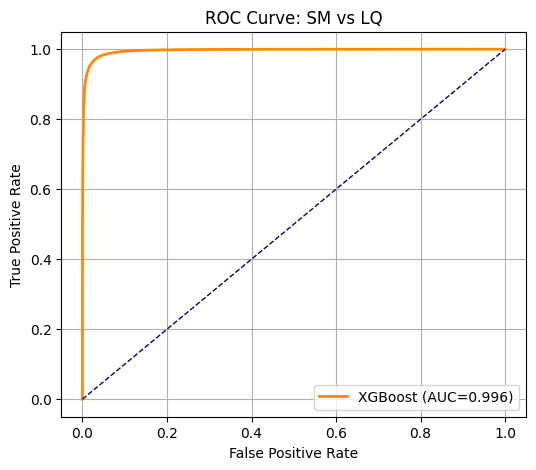

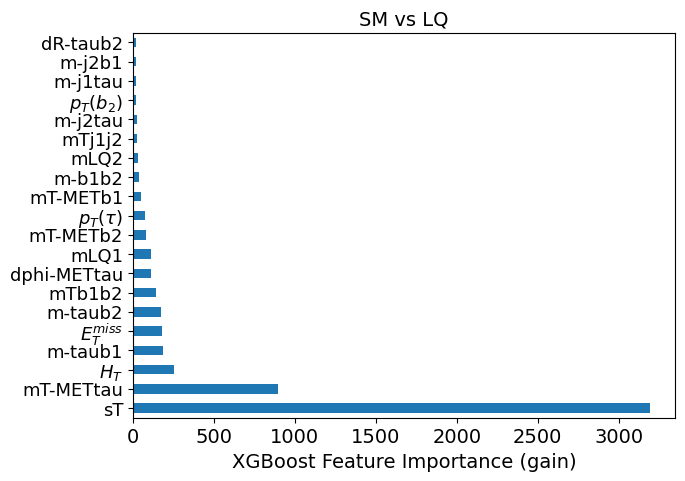

[46, 41, 11, 29, 9, 30, 44, 26, 47, 40, 6, 39, 31, 48, 45]


In [ ]:
# LOAD
xgb_clf = XGBClassifier()
xgb_clf.load_model(mainfolder + "saved-models/xgboost_SMLQ_2026_massK.json")


# --- 6. Evaluación ---
y_pred = xgb_clf.predict(X_test)
y_pred_proba = xgb_clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {acc:.3f}, ROC-AUC: {auc:.5f}")

# --- 7. ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: SM vs LQ")
plt.grid(True)
plt.legend()
plt.show()


# --- 8. Feature importance ---
keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
                 '$p_T(b_2)$','$\eta(b_2)$','$\phi(b_2)$',
                 r'$p_T(\tau)$',r'$\eta(\tau)$',r'$\phi(\tau)$',
                 '$E_T^{miss}$','$\phi(E_T^{miss})$',
                 '$H_T$','# jets','# $b$-jets',
                 'dR-taub1','dR-taub2','dR-b1b2',
                 'dR-j1b1','dR-j1b2','dR-j1tau',
                 'dR-j2b1','dR-j2b2','dR-j2tau',
                 'dR-j1j2',
#                  'dphi-taub1','dphi-taub2','dphi-b1b2',
                 'dphi-METb1','dphi-METb2','dphi-METtau',
                 'dphi-METj1','dphi-METj2',
                 'm-taub1','m-taub2','m-b1b2',
                 'm-j1b1','m-j1b2','m-j1tau',
                 'm-j2b1','m-j2b2','m-j2tau',
                 'm-j1j2',
                 'mT-METb1','mT-METb2','mT-METtau',
                 'mT-METj1','mT-METj2',
                 'mTb1b2','mTj1j2','sT',
                 'mLQ1','mLQ2','mTop'])

feature_important = xgb_clf.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(20, columns="score").plot(kind='barh',figsize=(7,5)) ## plot top 20 features
plt.xticks(fontsize=14)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
plt.title(r'SM vs LQ', fontsize=14)
# plt.savefig('XG_feature_importance.pdf', bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

### let's compute S_pseudo

In [ ]:
# output of all the background events
scores_B = xgb_clf.predict_proba( df_SM_norm.drop(columns=['mLQ_reg']) )[:, 1]

# output of all the signal events
scores_S = xgb_clf.predict_proba( df_LQ_norm.drop(columns=['mLQ_reg']) )[:, 1]

In [ ]:
def Z_asimov(S, B):
    if S <= 0 or B <= 0:
        return 0
    return np.sqrt(2 * ((S+B) * np.log(1 + S/B) - S))

In [ ]:
print(B_expected)
print()

print(S_expected_SLQ)
print(S_expected_VLQ)
print()

print(masses_SLQ)
print(masses_VLQ)

45962

[742, 419, 237, 137, 80, 46, 27, 16, 9, 3]
[7835, 2394, 796, 466, 273, 163, 98, 59, 36, 22]

[1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]
[1200, 1400, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]


###### cut based

In [ ]:
S_expected = S_expected_SLQ


n_pseudo = 5000

threshold = [0.5,0.6,0.7,0.8,0.9,0.95,0.99,0.995]


# to save
B_mean_cut = {}
B_std_cut  = {}
S_mean_cut = {}
S_std_cut  = {}
Z_cut = {}



for S_it in S_expected:
    print('\n----------------')
    print('S_expected = ', S_it)

    B_mean_cut[S_it] = []
    B_std_cut[S_it]  = []
    S_mean_cut[S_it] = []
    S_std_cut[S_it]  = []
    Z_cut[S_it] = []

    for th_it in threshold:

        print('threshold = ', th_it)

        B_estimates = []

        for n_it in range(n_pseudo):

            # Poisson
            N_B = np.random.poisson(B_expected)

            # Sample with replacements
            sample_scores = np.random.choice(scores_B, size=N_B, replace=True)

            # Cut-based (weight = 1)
            B_pass = np.sum(sample_scores > th_it)
            B_estimates.append(B_pass)


        mean_B = np.mean(B_estimates)
        std_B  = np.std(B_estimates)
        B_mean_cut[S_it].append(mean_B)
        B_std_cut[S_it].append(std_B)

        print("B =", mean_B, "+-", std_B)



        # just in case, lets not use the same pseudo experiments

        S_estimates = []

        for n_it in range(n_pseudo):

            # Poisson
            N_B = np.random.poisson(B_expected)
            N_S = np.random.poisson(S_it)

            # Sample with replacements
            sample_B = np.random.choice(scores_B, size=N_B, replace=True)
            sample_S = np.random.choice(scores_S, size=N_S, replace=True)

            sample_all = np.concatenate([sample_B, sample_S])

            # Cut-based (weight = 1)
            S_pass = np.sum(sample_all > th_it)

            S_pseudo = S_pass - mean_B
            S_estimates.append(S_pseudo)


        mean_S = np.mean(S_estimates)
        std_S  = np.std(S_estimates)
        S_mean_cut[S_it].append(mean_S)
        S_std_cut[S_it].append(std_S)

        print("S =", mean_S, "+-", std_S)


        Z_val = Z_asimov(mean_S, mean_B)
        Z_cut[S_it].append(Z_val)

        print('Z = ', Z_val)

        print(' ')


----------------
S_expected =  742
threshold =  0.5
B = 1240.8748 +- 34.743965302768764
S = 721.1024 +- 44.546378979216705
Z =  18.854719981214892
 
threshold =  0.6
B = 992.0642 +- 31.09230255802873
S = 717.1408 +- 41.01254167934487
Z =  20.623266079774982
 
threshold =  0.7
B = 763.144 +- 27.465812640444486
S = 709.1285999999998 +- 38.7042205610706
Z =  22.72993112941746
 
threshold =  0.8
B = 545.8662 +- 23.005770962086885
S = 699.7937999999998 +- 35.50672049063389
Z =  25.609924605373372
 
threshold =  0.9
B = 300.2098 +- 17.00716860503241
S = 677.7622000000001 +- 31.389769288734826
Z =  30.89408421483002
 
threshold =  0.95
B = 147.7706 +- 12.169058124604385
S = 648.3322000000001 +- 27.92618542085546
Z =  37.21178454941645
 
threshold =  0.99
B = 28.4678 +- 5.349931136005397
S = 526.9186 +- 23.609538221659484
Z =  47.393534568521645
 
threshold =  0.995
B = 12.2908 +- 3.5211696011410756
S = 445.1702000000001 +- 21.31333101605659
Z =  49.181161575015864
 

----------------
S_expec

###### weighted

In [ ]:
S_expected = S_expected_SLQ


n_pseudo = 5000


# to save
B_mean_weight = {}
B_std_weight  = {}
S_mean_weight = {}
S_std_weight  = {}
Z_weight = {}


for S_it in S_expected:
    print('\n----------------')
    print('S_expected = ', S_it)

    B_mean_weight[S_it] = []
    B_std_weight[S_it]  = []
    S_mean_weight[S_it] = []
    S_std_weight[S_it]  = []
    Z_weight[S_it] = []


    B_estimates = []

    for n_it in range(n_pseudo):

        # Poisson
        N_B = np.random.poisson(B_expected)

        # Sample with replacements
        sample_scores = np.random.choice(scores_B, size=N_B, replace=True)

        # Weighted (weight = score)
        B_pass = np.sum(sample_scores)
        B_estimates.append(B_pass)


    mean_B = np.mean(B_estimates)
    std_B  = np.std(B_estimates)
    B_mean_weight[S_it].append(mean_B)
    B_std_weight[S_it].append(std_B)

    print("B =", mean_B, "+-", std_B)



    # just in case, lets not use the same pseudo experiments

    S_estimates = []

    for n_it in range(n_pseudo):

        # Poisson
        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_it)

        # Sample with replacements
        sample_B = np.random.choice(scores_B, size=N_B, replace=True)
        sample_S = np.random.choice(scores_S, size=N_S, replace=True)

        sample_all = np.concatenate([sample_B, sample_S])

        # Weighted (weight = score)
        S_pass = np.sum(sample_all)

        S_pseudo = S_pass - mean_B
        S_estimates.append(S_pseudo)


    mean_S = np.mean(S_estimates)
    std_S  = np.std(S_estimates)
    S_mean_weight[S_it].append(mean_S)
    S_std_weight[S_it].append(std_S)

    print("S =", mean_S, "+-", std_S)


    Z_val = Z_asimov(mean_S, mean_B)
    Z_weight[S_it].append(Z_val)

    print('Z = ', Z_val)

    print(' ')


----------------
S_expected =  742
B = 1944.2368 +- 30.335178
S = 709.38794 +- 40.412212
Z =  15.234202
 

----------------
S_expected =  419
B = 1945.7686 +- 30.60695
S = 400.22314 +- 36.37789
Z =  8.786041
 

----------------
S_expected =  237
B = 1943.8315 +- 31.208927
S = 227.1144 +- 33.795116
Z =  5.055536
 

----------------
S_expected =  137
B = 1944.0526 +- 30.896255
S = 131.58553 +- 32.418663
Z =  2.9516313
 

----------------
S_expected =  80
B = 1944.4744 +- 30.21408
S = 76.3676 +- 31.547625
Z =  1.7207464
 

----------------
S_expected =  46
B = 1945.045 +- 29.950058
S = 43.55327 +- 30.909634
Z =  0.98390985
 

----------------
S_expected =  27
B = 1944.1948 +- 30.626476
S = 26.226841 +- 30.529234
Z =  0.5935476
 

----------------
S_expected =  16
B = 1944.6222 +- 30.623116
S = 15.001109 +- 30.34514
Z =  0.33975393
 

----------------
S_expected =  9
B = 1944.958 +- 30.782274
S = 8.077386 +- 31.10201
Z =  0.18330263
 

----------------
S_expected =  3
B = 1944.6792 +- 30.

###### binned likelihood fit

fit de mezcla:

f(x)=μS pS(x)+μB pB(x)


donde:

pS(x) = pdf del score para señal

pB(x) = pdf del score para background

μS, μB = yields a ajustar



maximizamos:

L(μS,μB)= Prod_i=1^N ( μS pS(xi) + μB pB (xi )) e^−(μS+μB)

In [ ]:
bins = np.linspace(0, 1, 30)

# normalized histograms of pure signal and pure background
hist_B, _ = np.histogram(scores_B, bins=bins, density=True)
hist_S, _ = np.histogram(scores_S, bins=bins, density=True)


bin_width = bins[1] - bins[0]

pS = hist_S * bin_width
pB = hist_B * bin_width

eventos esperados en el bin i:

λi = μS pS,i + μB pB,i



Likelihood binned:

log L = Sum_i ( ni log(λi) − λi )

q0 = −2 ln ( L(μS=0) / L(μS_hat) )

Z = np.sqrt{q0}

In [ ]:
S_expected = S_expected_SLQ


n_pseudo = 5000


# to save
S_mean_fit = {}
S_std_fit  = {}
Z_fit = {}



for S_it in S_expected:
    print('\n----------------')
    print('S_expected = ', S_it)

    S_mean_fit[S_it] = []
    S_std_fit[S_it]  = []
    Z_fit[S_it] = []


    muS_fits = []
    muB_fits = []

    for n_it in range(n_pseudo):

        # 1) pseudo experiment
        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_it)

        sample_B = np.random.choice(scores_B, N_B, replace=True)
        sample_S = np.random.choice(scores_S, N_S, replace=True)

        data_scores = np.concatenate([sample_B, sample_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_it, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits.append(muS_fit)
        muB_fits.append(muB_fit)


    mean_muB = np.mean(muB_fits)

    mean_muS = np.mean(muS_fits)
    std_muS  = np.std(muS_fits)

    S_mean_fit[S_it].append(mean_muS)
    S_std_fit[S_it].append(std_muS)


    # significance
    logL_hat = -neg_logL([mean_muS, mean_muB])
    logL_null = -neg_logL([0, mean_muB])

    q0 = -2 * (logL_null - logL_hat)

    Z = np.sqrt(q0)

    Z_fit[S_it].append(Z)

    print("S =", mean_muS, "+-", std_muS)
    print("Z =", Z)
    print('')



----------------
S_expected =  742
S = 742.230755806183 +- 29.327797056506288
Z = 39.73665363426911


----------------
S_expected =  419
S = 419.51996993712356 +- 23.895475952832243
Z = 24.187303042866585


----------------
S_expected =  237
S = 237.36092748034707 +- 20.47489344996439
Z = 17.131123983774227


----------------
S_expected =  137
S = 137.28526211119492 +- 17.40986235416573
Z = 6.993619518296877


----------------
S_expected =  80
S = 80.03990868781172 +- 15.623168112913014
Z = 6.848724780090063


----------------
S_expected =  46
S = 46.12311248347166 +- 14.284652927041794
Z = 3.9555132478350696


----------------
S_expected =  27
S = 27.327257674008205 +- 13.26736583571652
Z = 1.7355564035577578


----------------
S_expected =  16


/tmp/ipykernel_4474/1530406176.py:76: RuntimeWarning: invalid value encountered in sqrt
  Z = np.sqrt(q0)


S = 16.545344839203278 +- 12.091971757609503
Z = nan


----------------
S_expected =  9
S = 11.083493672982318 +- 10.40724053450166
Z = nan


----------------
S_expected =  3
S = 6.75860182701159 +- 8.49777071040818
Z = nan



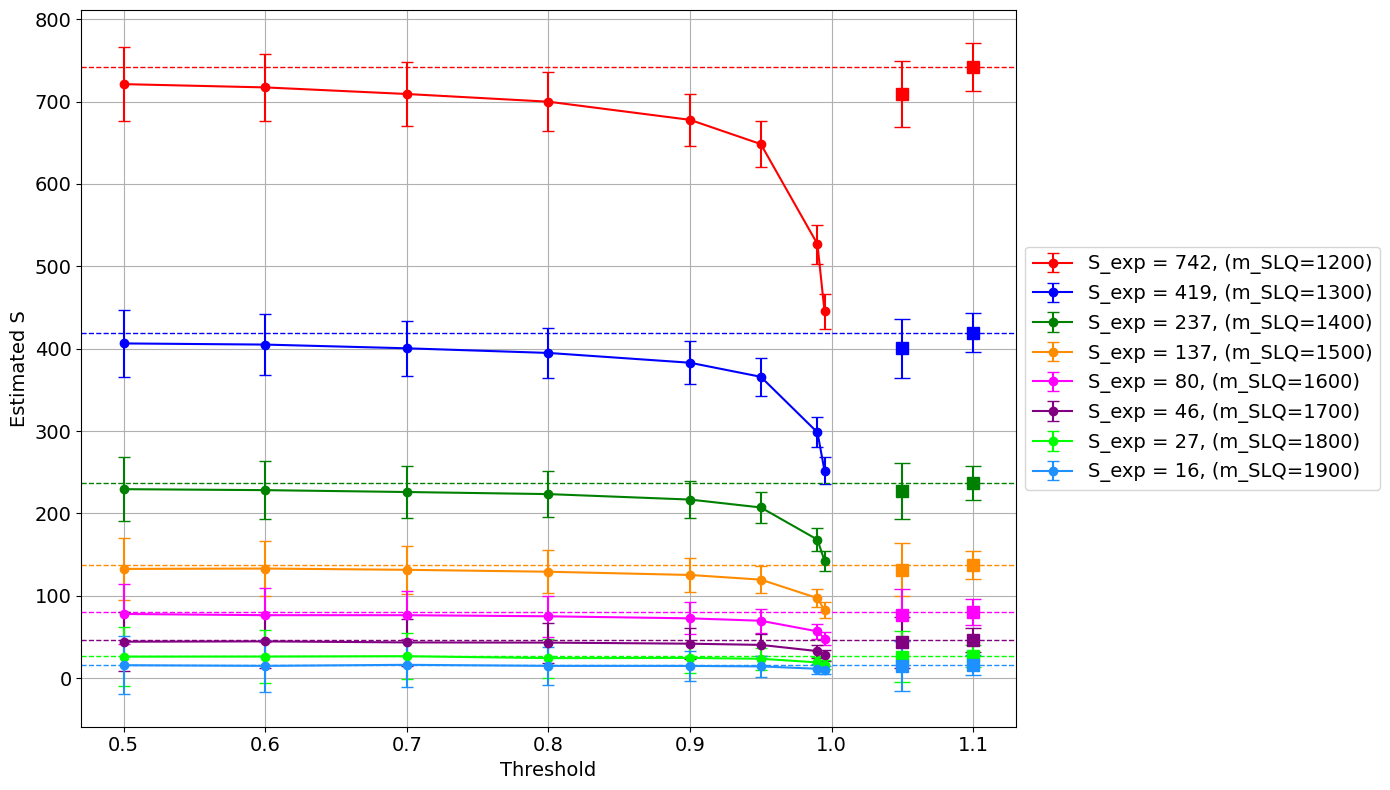

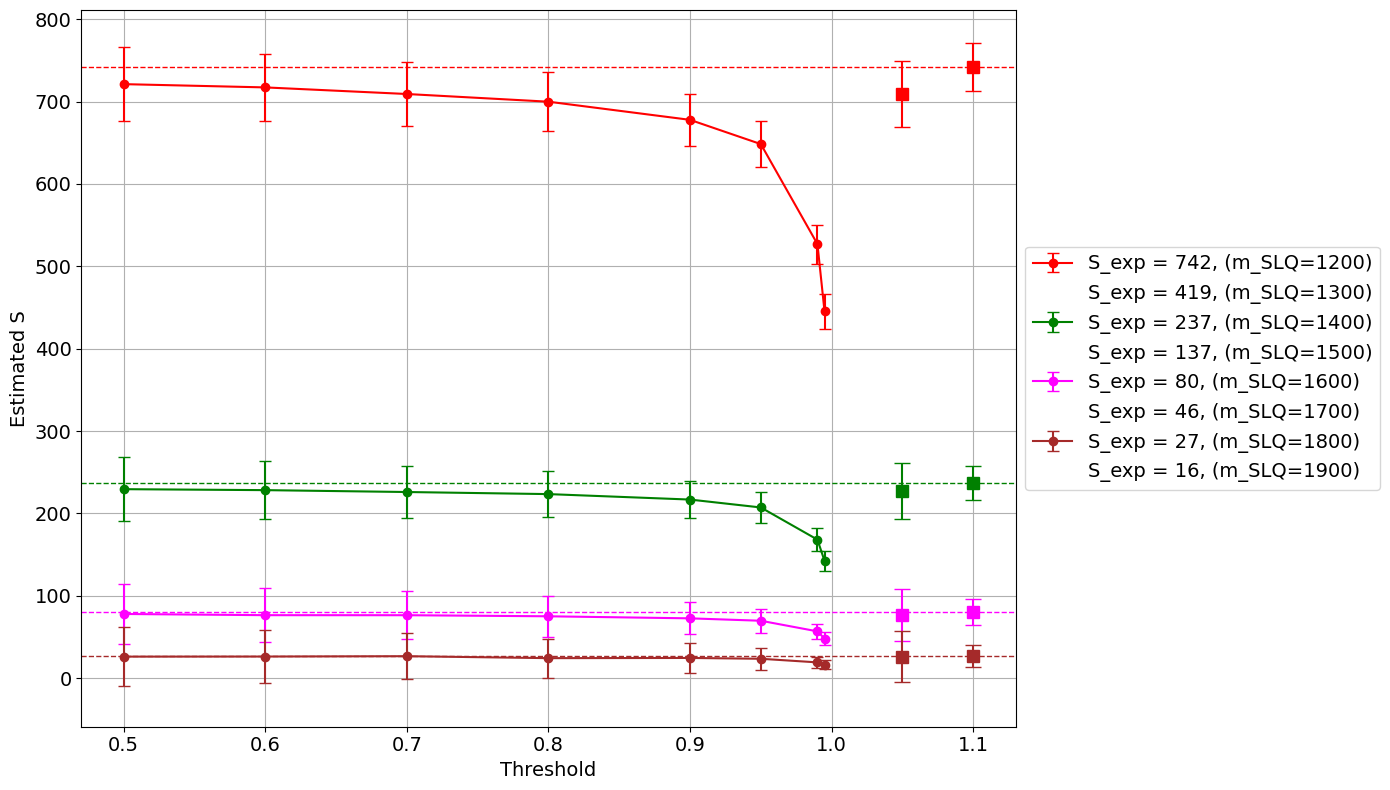

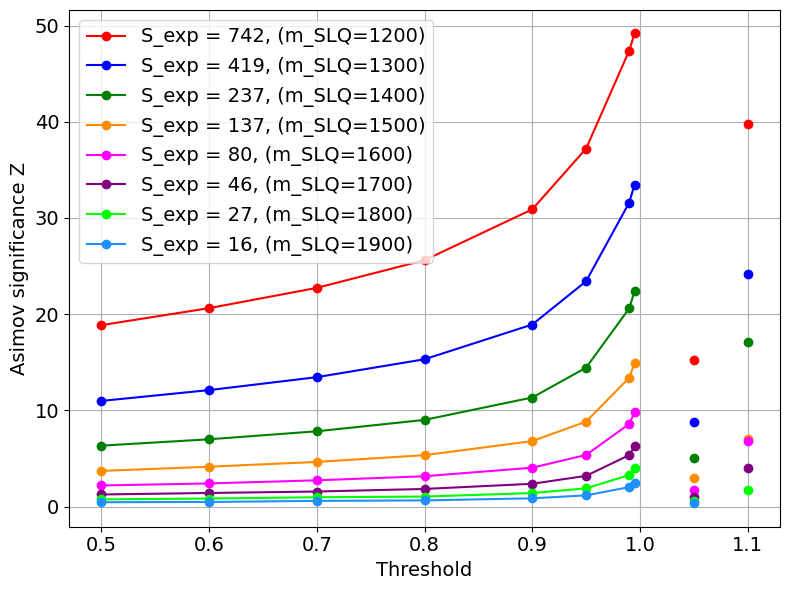

In [ ]:
SLQ_mass = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]

cols = ['red', 'blue', 'green', 'darkorange', 'magenta', 'purple', 'lime', 'dodgerblue']

plt.figure(figsize=(14,8))

for ii, S_it in enumerate(S_expected[:8]):

    # ---- CUT-BASED ----
    plt.errorbar(threshold, S_mean_cut[S_it], yerr=S_std_cut[S_it], color=cols[ii], fmt='o-', capsize=4, label=f"S_exp = {S_it}, (m_SLQ={SLQ_mass[ii]})")

    plt.axhline(y=S_it, color=cols[ii], linestyle='--', lw=1)

    # ---- WEIGHTED ----
    plt.errorbar([1.05], [S_mean_weight[S_it]], yerr=[S_std_weight[S_it]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')

    # ---- FIT ----
    plt.errorbar([1.1], [S_mean_fit[S_it]], yerr=[S_std_fit[S_it]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')

plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Estimated S", fontsize=14)
# plt.title("Cut-based (weight = 1)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)
plt.tight_layout()
plt.show()




SLQ_mass = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]

cols = ['red', 'blue', 'green', 'darkorange', 'magenta', 'purple', 'lime', 'dodgerblue']
cols = ['red', '#FF000000', 'green', '#FF000000', 'magenta', '#FF000000', 'brown', '#FF000000']

plt.figure(figsize=(14,8))

for ii, S_it in enumerate(S_expected[:8]):

    # ---- CUT-BASED ----
    plt.errorbar(threshold, S_mean_cut[S_it], yerr=S_std_cut[S_it], color=cols[ii], fmt='o-', capsize=4, label=f"S_exp = {S_it}, (m_SLQ={SLQ_mass[ii]})")

    plt.axhline(y=S_it, color=cols[ii], linestyle='--', lw=1)

    # ---- WEIGHTED ----
    plt.errorbar([1.05], [S_mean_weight[S_it]], yerr=[S_std_weight[S_it]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')

    # ---- FIT ----
    plt.errorbar([1.1], [S_mean_fit[S_it]], yerr=[S_std_fit[S_it]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')

plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Estimated S", fontsize=14)
# plt.title("Cut-based (weight = 1)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)
plt.tight_layout()
plt.show()



cols = ['red', 'blue', 'green', 'darkorange', 'magenta', 'purple', 'lime', 'dodgerblue']

plt.figure(figsize=(8,6))

for ii, S_it in enumerate(S_expected[:8]):

    plt.plot(threshold, Z_cut[S_it], 'o-', color=cols[ii], label=f"S_exp = {S_it}, (m_SLQ={SLQ_mass[ii]})")

    plt.plot([1.05], [Z_weight[S_it]], 'o-', color=cols[ii])

    plt.plot([1.1], [Z_fit[S_it]], 'o-', color=cols[ii])

plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Asimov significance Z", fontsize=14)
# plt.title("Cut-based (weight = 1)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

### With only the reconstructed mass (regressor)

In [ ]:
# --- 1. Combinar todos los LQ en un solo DataFrame ---
df_LQ_list = list(df_SLQ_norm.values()) + list(df_VLQ_norm.values())
df_LQ_norm = pd.concat(df_LQ_list, ignore_index=True)


# --- 2. Igualar número de eventos con SM ---
n_SM = len(df_SM_norm)
n_LQ = len(df_LQ_norm)
n_events = min(n_SM, n_LQ)

df_SM_sample = (df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop'])).sample(n=n_events, random_state=42)
df_LQ_sample = (df_LQ_norm.drop(columns=['mLQ1','mLQ2','mTop'])).sample(n=n_events, random_state=42)


# --- 3. Crear X, y ---
X = pd.concat([df_SM_sample, df_LQ_sample], ignore_index=True)
y = np.hstack([np.zeros(n_events), np.ones(n_events)])  # 0=SM, 1=LQ

# --- 4. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)



In [ ]:
# --- 5. Entrenar XGBoost ---
xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_clf.fit(X_train, y_train)

# SAVE
xgb_clf.save_model(mainfolder + "saved-models/xgboost_SMLQ_2026_massR.json")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:53:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1363/1919415669.py:28: SyntaxWarning: invalid escape sequence '\e'
  keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
/tmp/ipykernel_1363/1919415669.py:28: SyntaxWarning: invalid escape sequence '\p'
  keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
/tmp/ipykernel_1363/1919415669.py:29: SyntaxWarning: invalid escape sequence '\e'
  '$p_T(b_2)$','$\eta(b_2)$','$\phi(b_2)$',
/tmp/ipykernel_1363/1919415669.py:29: SyntaxWarning: invalid escape sequence '

Accuracy: 0.970, ROC-AUC: 0.99600


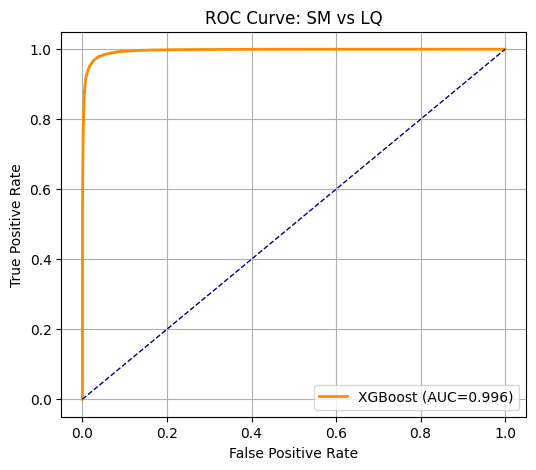

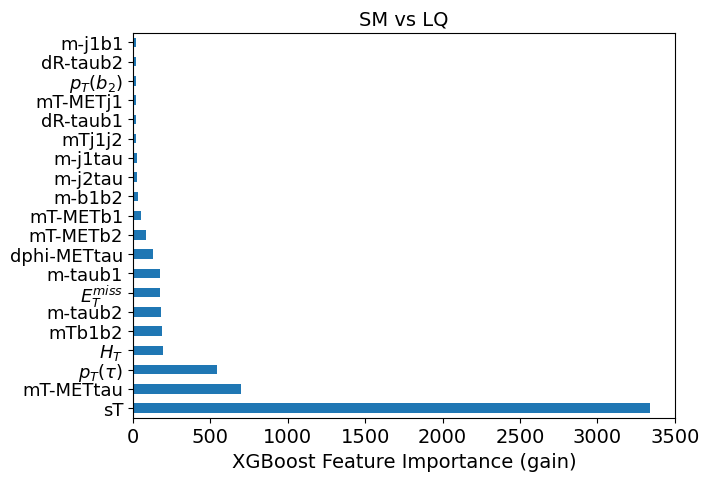

[46, 41, 6, 11, 44, 30, 9, 29, 26, 40, 39, 31, 37, 34, 45]


In [ ]:
# LOAD
xgb_clf = XGBClassifier()
xgb_clf.load_model(mainfolder + "saved-models/xgboost_SMLQ_2026_massR.json")


# --- 6. Evaluación ---
y_pred = xgb_clf.predict(X_test)
y_pred_proba = xgb_clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {acc:.3f}, ROC-AUC: {auc:.5f}")

# --- 7. ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: SM vs LQ")
plt.grid(True)
plt.legend()
plt.show()


# --- 8. Feature importance ---
keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
                 '$p_T(b_2)$','$\eta(b_2)$','$\phi(b_2)$',
                 r'$p_T(\tau)$',r'$\eta(\tau)$',r'$\phi(\tau)$',
                 '$E_T^{miss}$','$\phi(E_T^{miss})$',
                 '$H_T$','# jets','# $b$-jets',
                 'dR-taub1','dR-taub2','dR-b1b2',
                 'dR-j1b1','dR-j1b2','dR-j1tau',
                 'dR-j2b1','dR-j2b2','dR-j2tau',
                 'dR-j1j2',
#                  'dphi-taub1','dphi-taub2','dphi-b1b2',
                 'dphi-METb1','dphi-METb2','dphi-METtau',
                 'dphi-METj1','dphi-METj2',
                 'm-taub1','m-taub2','m-b1b2',
                 'm-j1b1','m-j1b2','m-j1tau',
                 'm-j2b1','m-j2b2','m-j2tau',
                 'm-j1j2',
                 'mT-METb1','mT-METb2','mT-METtau',
                 'mT-METj1','mT-METj2',
                 'mTb1b2','mTj1j2','sT',
                 'mLQ_reg'])

feature_important = xgb_clf.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(20, columns="score").plot(kind='barh',figsize=(7,5)) ## plot top 20 features
plt.xticks(fontsize=14)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
plt.title(r'SM vs LQ', fontsize=14)
# plt.savefig('XG_feature_importance.pdf', bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

### let's compute S_pseudo

In [ ]:
# output of all the background events
scores_B = xgb_clf.predict_proba( df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop']) )[:, 1]

# output of all the signal events
scores_S = xgb_clf.predict_proba( df_LQ_norm.drop(columns=['mLQ1','mLQ2','mTop']) )[:, 1]

In [ ]:
def Z_asimov(S, B):
    if S <= 0 or B <= 0:
        return 0
    return np.sqrt(2 * ((S+B) * np.log(1 + S/B) - S))

###### cut based

In [ ]:
S_expected = S_expected_SLQ


n_pseudo = 100

threshold = [0.5,0.6,0.7,0.8,0.9,0.95,0.99,0.995]


# to save
B_mean_cut = {}
B_std_cut  = {}
S_mean_cut = {}
S_std_cut  = {}
Z_cut = {}



for S_it in S_expected:
    print('\n----------------')
    print('S_expected = ', S_it)

    B_mean_cut[S_it] = []
    B_std_cut[S_it]  = []
    S_mean_cut[S_it] = []
    S_std_cut[S_it]  = []
    Z_cut[S_it] = []

    for th_it in threshold:

        print('threshold = ', th_it)

        B_estimates = []

        for n_it in range(n_pseudo):

            # Poisson
            N_B = np.random.poisson(B_expected)

            # Sample with replacements
            sample_scores = np.random.choice(scores_B, size=N_B, replace=True)

            # Cut-based (weight = 1)
            B_pass = np.sum(sample_scores > th_it)
            B_estimates.append(B_pass)


        mean_B = np.mean(B_estimates)
        std_B  = np.std(B_estimates)
        B_mean_cut[S_it].append(mean_B)
        B_std_cut[S_it].append(std_B)

        print("B =", mean_B, "+-", std_B)



        # just in case, lets not use the same pseudo experiments

        S_estimates = []

        for n_it in range(n_pseudo):

            # Poisson
            N_B = np.random.poisson(B_expected)
            N_S = np.random.poisson(S_it)

            # Sample with replacements
            sample_B = np.random.choice(scores_B, size=N_B, replace=True)
            sample_S = np.random.choice(scores_S, size=N_S, replace=True)

            sample_all = np.concatenate([sample_B, sample_S])

            # Cut-based (weight = 1)
            S_pass = np.sum(sample_all > th_it)

            S_pseudo = S_pass - mean_B
            S_estimates.append(S_pseudo)


        mean_S = np.mean(S_estimates)
        std_S  = np.std(S_estimates)
        S_mean_cut[S_it].append(mean_S)
        S_std_cut[S_it].append(std_S)

        print("S =", mean_S, "+-", std_S)


        Z_val = Z_asimov(mean_S, mean_B)
        Z_cut[S_it].append(Z_val)

        print('Z = ', Z_val)

        print(' ')


----------------
S_expected =  742
threshold =  0.5
B = 1238.11 +- 29.447544889175393
S = 724.1000000000001 +- 41.82470442214745
Z =  18.945658580779003
 
threshold =  0.6
B = 980.62 +- 26.787974914128913
S = 713.8800000000001 +- 38.577843381920665
Z =  20.6368735035202
 
threshold =  0.7
B = 751.32 +- 25.680295948450436
S = 714.3999999999999 +- 32.58284211053419
Z =  23.025942342155567
 
threshold =  0.8
B = 538.43 +- 20.868279756606675
S = 692.4600000000003 +- 34.988539552259105
Z =  25.506205566488944
 
threshold =  0.9
B = 297.65 +- 14.945484267831539
S = 678.9600000000005 +- 26.28037100194744
Z =  31.02959286005605
 
threshold =  0.95
B = 151.46 +- 12.0850486138865
S = 652.06 +- 28.664082054027123
Z =  37.11490711910978
 
threshold =  0.99
B = 28.39 +- 4.843335627436942
S = 525.33 +- 25.096645194129035
Z =  47.31940214793219
 
threshold =  0.995
B = 10.03 +- 3.119150525383474
S = 447.86000000000024 +- 21.259771870836243
Z =  51.02469680628992
 

----------------
S_expected =  419

###### weighted

In [ ]:
S_expected = S_expected_SLQ


n_pseudo = 100


# to save
B_mean_weight = {}
B_std_weight  = {}
S_mean_weight = {}
S_std_weight  = {}
Z_weight = {}


for S_it in S_expected:
    print('\n----------------')
    print('S_expected = ', S_it)

    B_mean_weight[S_it] = []
    B_std_weight[S_it]  = []
    S_mean_weight[S_it] = []
    S_std_weight[S_it]  = []
    Z_weight[S_it] = []


    B_estimates = []

    for n_it in range(n_pseudo):

        # Poisson
        N_B = np.random.poisson(B_expected)

        # Sample with replacements
        sample_scores = np.random.choice(scores_B, size=N_B, replace=True)

        # Weighted (weight = score)
        B_pass = np.sum(sample_scores)
        B_estimates.append(B_pass)


    mean_B = np.mean(B_estimates)
    std_B  = np.std(B_estimates)
    B_mean_weight[S_it].append(mean_B)
    B_std_weight[S_it].append(std_B)

    print("B =", mean_B, "+-", std_B)



    # just in case, lets not use the same pseudo experiments

    S_estimates = []

    for n_it in range(n_pseudo):

        # Poisson
        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_it)

        # Sample with replacements
        sample_B = np.random.choice(scores_B, size=N_B, replace=True)
        sample_S = np.random.choice(scores_S, size=N_S, replace=True)

        sample_all = np.concatenate([sample_B, sample_S])

        # Weighted (weight = score)
        S_pass = np.sum(sample_all)

        S_pseudo = S_pass - mean_B
        S_estimates.append(S_pseudo)


    mean_S = np.mean(S_estimates)
    std_S  = np.std(S_estimates)
    S_mean_weight[S_it].append(mean_S)
    S_std_weight[S_it].append(std_S)

    print("S =", mean_S, "+-", std_S)


    Z_val = Z_asimov(mean_S, mean_B)
    Z_weight[S_it].append(Z_val)

    print('Z = ', Z_val)

    print(' ')


----------------
S_expected =  742
B = 1937.1982 +- 28.993925
S = 716.735 +- 37.868835
Z =  15.409305
 

----------------
S_expected =  419
B = 1945.2985 +- 34.658566
S = 395.87943 +- 36.019466
Z =  8.694537
 

----------------
S_expected =  237
B = 1942.8204 +- 27.76834
S = 220.69456 +- 30.747282
Z =  4.9163785
 

----------------
S_expected =  137
B = 1941.4595 +- 27.071907
S = 133.53026 +- 30.743122
Z =  2.9967227
 

----------------
S_expected =  80
B = 1945.7993 +- 30.095083
S = 74.13332 +- 29.239199
Z =  1.6701081
 

----------------
S_expected =  46
B = 1941.4136 +- 28.470562
S = 45.680508 +- 31.607424
Z =  1.0327544
 

----------------
S_expected =  27
B = 1941.7152 +- 27.274313
S = 29.081585 +- 32.213097
Z =  0.65818864
 

----------------
S_expected =  16
B = 1938.7976 +- 31.115929
S = 19.396643 +- 30.440407
Z =  0.440004
 

----------------
S_expected =  9
B = 1942.947 +- 34.22092
S = 1.677229 +- 32.440243
Z =  0.035654563
 

----------------
S_expected =  3
B = 1938.1843 +

###### binned likelihood fit

fit de mezcla:

f(x)=μS pS(x)+μB pB(x)


donde:

pS(x) = pdf del score para señal

pB(x) = pdf del score para background

μS, μB = yields a ajustar



maximizamos:

L(μS,μB)= Prod_i=1^N ( μS pS(xi) + μB pB (xi )) e^−(μS+μB)

In [ ]:
bins = np.linspace(0, 1, 30)

# normalized histograms of pure signal and pure background
hist_B, _ = np.histogram(scores_B, bins=bins, density=True)
hist_S, _ = np.histogram(scores_S, bins=bins, density=True)


bin_width = bins[1] - bins[0]

pS = hist_S * bin_width
pB = hist_B * bin_width

eventos esperados en el bin i:

λi = μS pS,i + μB pB,i



Likelihood binned:

log L = Sum_i ( ni log(λi) − λi )

q0 = −2 ln ( L(μS=0) / L(μS_hat) )

Z = np.sqrt{q0}

In [ ]:
S_expected = S_expected_SLQ


n_pseudo = 100


# to save
S_mean_fit = {}
S_std_fit  = {}
Z_fit = {}



for S_it in S_expected:
    print('\n----------------')
    print('S_expected = ', S_it)

    S_mean_fit[S_it] = []
    S_std_fit[S_it]  = []
    Z_fit[S_it] = []


    muS_fits = []
    muB_fits = []

    for n_it in range(n_pseudo):

        # 1) pseudo experiment
        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_it)

        sample_B = np.random.choice(scores_B, N_B, replace=True)
        sample_S = np.random.choice(scores_S, N_S, replace=True)

        data_scores = np.concatenate([sample_B, sample_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_it, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits.append(muS_fit)
        muB_fits.append(muB_fit)


    mean_muB = np.mean(muB_fits)

    mean_muS = np.mean(muS_fits)
    std_muS  = np.std(muS_fits)

    S_mean_fit[S_it].append(mean_muS)
    S_std_fit[S_it].append(std_muS)


    # significance
    logL_hat = -neg_logL([mean_muS, mean_muB])
    logL_null = -neg_logL([0, mean_muB])

    q0 = -2 * (logL_null - logL_hat)

    Z = np.sqrt(q0)

    Z_fit[S_it].append(Z)

    print("S =", mean_muS, "+-", std_muS)
    print("Z =", Z)
    print('')



----------------
S_expected =  742
S = 747.1444177286775 +- 31.63950170634691
Z = 41.72217978541676


----------------
S_expected =  419
S = 417.4980935269199 +- 24.510719036995347
Z = 26.027492947394038


----------------
S_expected =  237
S = 238.4884873467668 +- 17.74531672543028
Z = 16.170788027389005


----------------
S_expected =  137
S = 136.86277361815726 +- 17.62316797528075
Z = 7.696803981523702


----------------
S_expected =  80
S = 79.46762231889548 +- 16.291130617644804
Z = 5.14278071959651


----------------
S_expected =  46


/tmp/ipykernel_23338/859518255.py:76: RuntimeWarning: invalid value encountered in sqrt
  Z = np.sqrt(q0)


S = 44.231183235776726 +- 14.382552497393785
Z = nan


----------------
S_expected =  27
S = 26.772958952039485 +- 11.906884514063696
Z = 1.5961393689970507


----------------
S_expected =  16
S = 17.316922618725144 +- 11.24445025167195
Z = 2.331250932988282


----------------
S_expected =  9
S = 10.86195006132267 +- 11.168359728642814
Z = 1.244858194043015


----------------
S_expected =  3
S = 6.387844356677955 +- 8.281929774143524
Z = 0.2987090482043449



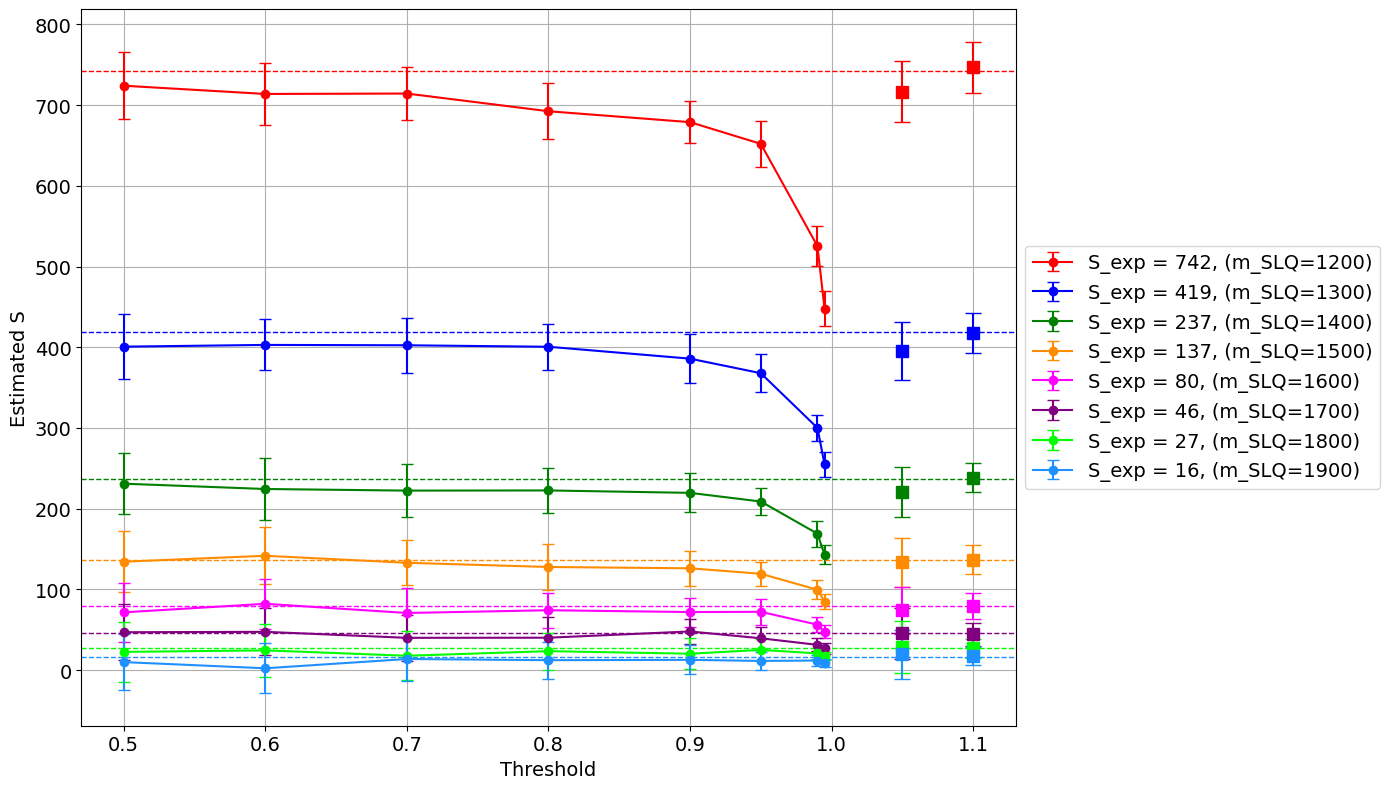

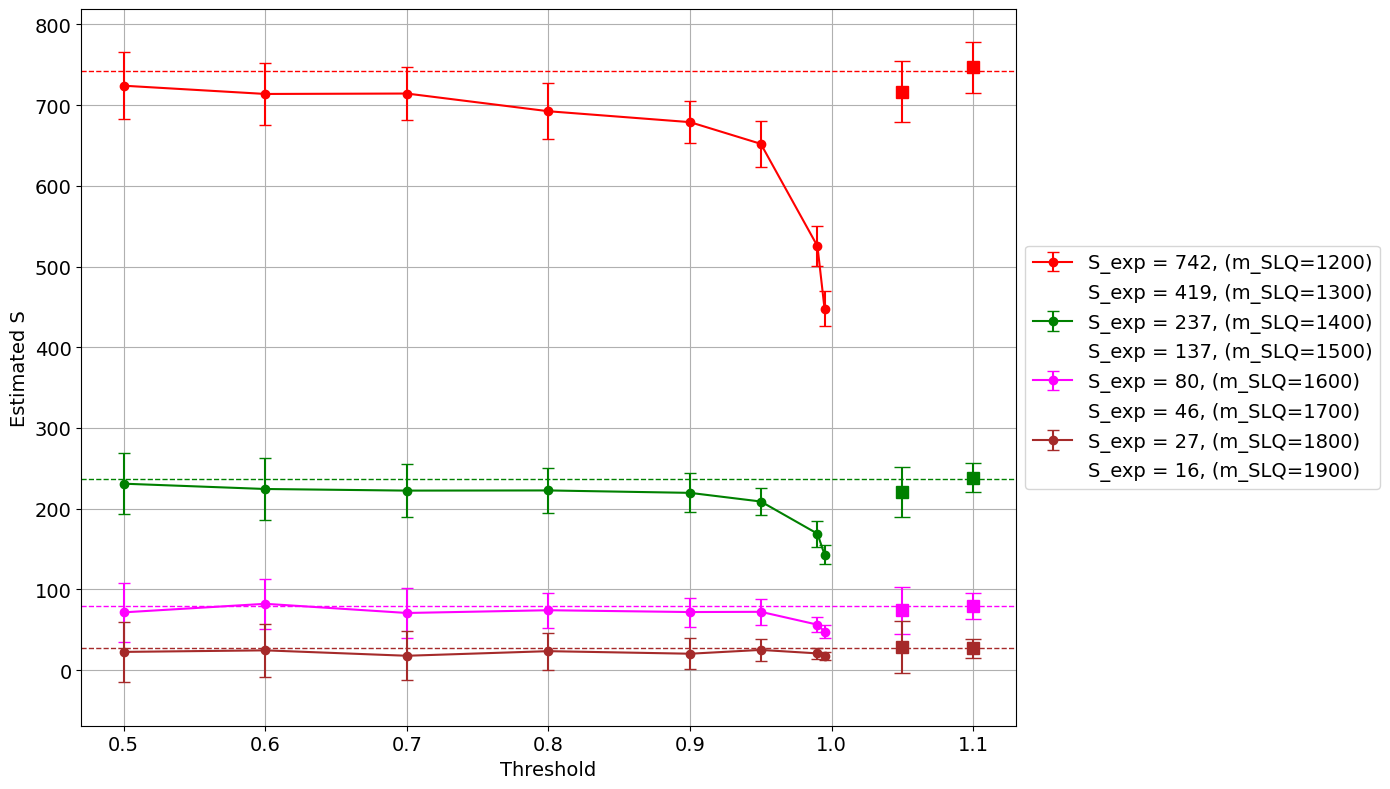

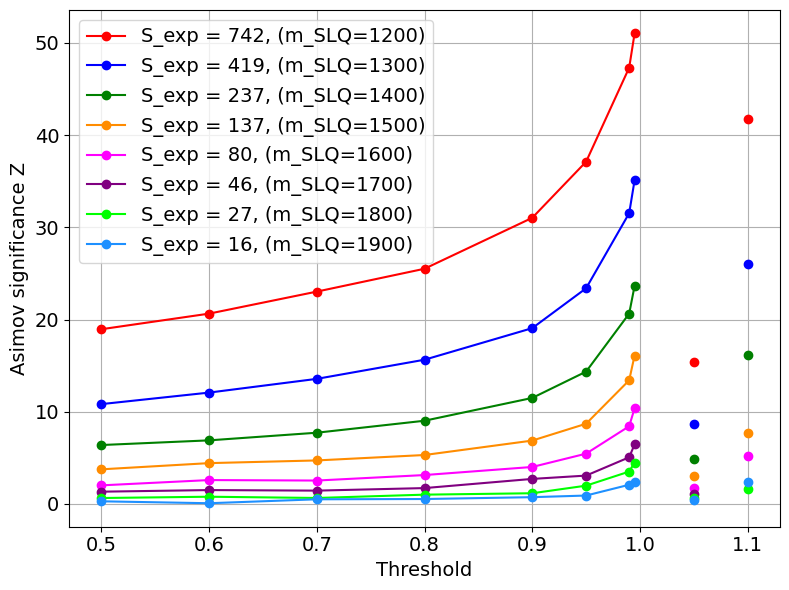

In [ ]:
SLQ_mass = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]

cols = ['red', 'blue', 'green', 'darkorange', 'magenta', 'purple', 'lime', 'dodgerblue']

plt.figure(figsize=(14,8))

for ii, S_it in enumerate(S_expected[:8]):

    # ---- CUT-BASED ----
    plt.errorbar(threshold, S_mean_cut[S_it], yerr=S_std_cut[S_it], color=cols[ii], fmt='o-', capsize=4, label=f"S_exp = {S_it}, (m_SLQ={SLQ_mass[ii]})")

    plt.axhline(y=S_it, color=cols[ii], linestyle='--', lw=1)

    # ---- WEIGHTED ----
    plt.errorbar([1.05], [S_mean_weight[S_it]], yerr=[S_std_weight[S_it]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')

    # ---- FIT ----
    plt.errorbar([1.1], [S_mean_fit[S_it]], yerr=[S_std_fit[S_it]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')

plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Estimated S", fontsize=14)
# plt.title("Cut-based (weight = 1)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)
plt.tight_layout()
plt.show()




SLQ_mass = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]

cols = ['red', 'blue', 'green', 'darkorange', 'magenta', 'purple', 'lime', 'dodgerblue']
cols = ['red', '#FF000000', 'green', '#FF000000', 'magenta', '#FF000000', 'brown', '#FF000000']

plt.figure(figsize=(14,8))

for ii, S_it in enumerate(S_expected[:8]):

    # ---- CUT-BASED ----
    plt.errorbar(threshold, S_mean_cut[S_it], yerr=S_std_cut[S_it], color=cols[ii], fmt='o-', capsize=4, label=f"S_exp = {S_it}, (m_SLQ={SLQ_mass[ii]})")

    plt.axhline(y=S_it, color=cols[ii], linestyle='--', lw=1)

    # ---- WEIGHTED ----
    plt.errorbar([1.05], [S_mean_weight[S_it]], yerr=[S_std_weight[S_it]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')

    # ---- FIT ----
    plt.errorbar([1.1], [S_mean_fit[S_it]], yerr=[S_std_fit[S_it]], color=cols[ii], fmt='s', markersize=8, capsize=6, linestyle='None')

plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Estimated S", fontsize=14)
# plt.title("Cut-based (weight = 1)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)
plt.tight_layout()
plt.show()



cols = ['red', 'blue', 'green', 'darkorange', 'magenta', 'purple', 'lime', 'dodgerblue']

plt.figure(figsize=(8,6))

for ii, S_it in enumerate(S_expected[:8]):

    plt.plot(threshold, Z_cut[S_it], 'o-', color=cols[ii], label=f"S_exp = {S_it}, (m_SLQ={SLQ_mass[ii]})")

    plt.plot([1.05], [Z_weight[S_it]], 'o-', color=cols[ii])

    plt.plot([1.1], [Z_fit[S_it]], 'o-', color=cols[ii])

plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Asimov significance Z", fontsize=14)
# plt.title("Cut-based (weight = 1)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

## Exclusion and Discovery

### load the classifier SQL vs VLQ with the reconstructed mass (regressor)

In [ ]:
# --- 1. Combinar todos los LQ en un solo DataFrame ---
df_LQ_list = list(df_SLQ_norm.values()) + list(df_VLQ_norm.values())
df_LQ_norm = pd.concat(df_LQ_list, ignore_index=True)


# --- 2. Igualar número de eventos con SM ---
n_SM = len(df_SM_norm)
n_LQ = len(df_LQ_norm)
n_events = min(n_SM, n_LQ)

df_SM_sample = (df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop'])).sample(n=n_events, random_state=42)
df_LQ_sample = (df_LQ_norm.drop(columns=['mLQ1','mLQ2','mTop'])).sample(n=n_events, random_state=42)


# --- 3. Crear X, y ---
X = pd.concat([df_SM_sample, df_LQ_sample], ignore_index=True)
y = np.hstack([np.zeros(n_events), np.ones(n_events)])  # 0=SM, 1=LQ

# --- 4. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_43487/1919415669.py:28: SyntaxWarning: invalid escape sequence '\e'
  keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
/tmp/ipykernel_43487/1919415669.py:28: SyntaxWarning: invalid escape sequence '\p'
  keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
/tmp/ipykernel_43487/1919415669.py:29: SyntaxWarning: invalid escape sequence '\e'
  '$p_T(b_2)$','$\eta(b_2)$','$\phi(b_2)$',
/tmp/ipykernel_43487/1919415669.py:29: SyntaxWarning: invalid escape sequen

Accuracy: 0.970, ROC-AUC: 0.99600


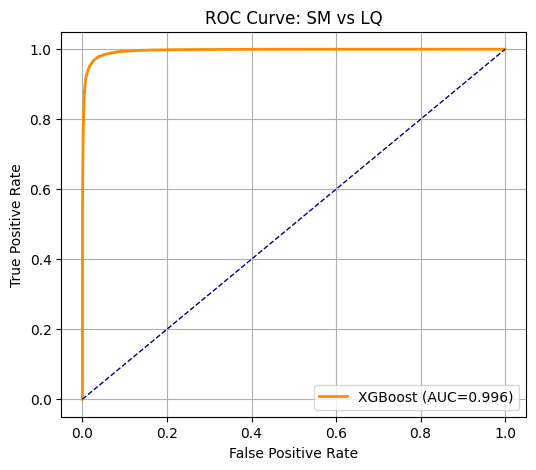

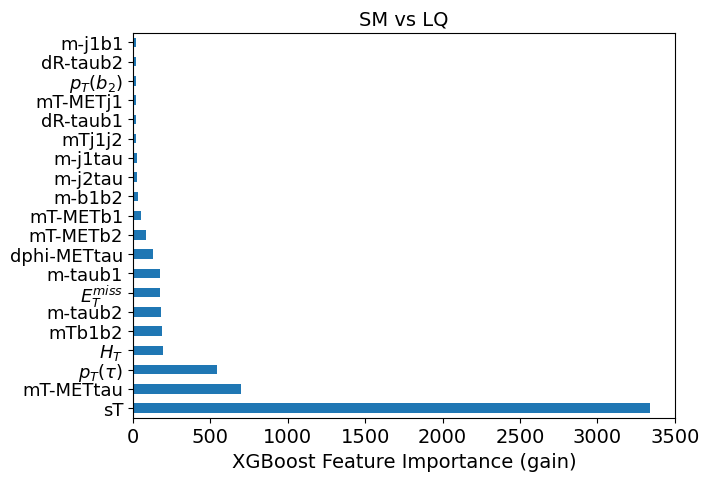

[46, 41, 6, 11, 44, 30, 9, 29, 26, 40, 39, 31, 37, 34, 45]


In [ ]:
# LOAD
xgb_clf = XGBClassifier()
xgb_clf.load_model(mainfolder + "saved-models/xgboost_SMLQ_2026_massR.json")


# --- 6. Evaluación ---
y_pred = xgb_clf.predict(X_test)
y_pred_proba = xgb_clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {acc:.3f}, ROC-AUC: {auc:.5f}")

# --- 7. ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: SM vs LQ")
plt.grid(True)
plt.legend()
plt.show()


# --- 8. Feature importance ---
keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
                 '$p_T(b_2)$','$\eta(b_2)$','$\phi(b_2)$',
                 r'$p_T(\tau)$',r'$\eta(\tau)$',r'$\phi(\tau)$',
                 '$E_T^{miss}$','$\phi(E_T^{miss})$',
                 '$H_T$','# jets','# $b$-jets',
                 'dR-taub1','dR-taub2','dR-b1b2',
                 'dR-j1b1','dR-j1b2','dR-j1tau',
                 'dR-j2b1','dR-j2b2','dR-j2tau',
                 'dR-j1j2',
#                  'dphi-taub1','dphi-taub2','dphi-b1b2',
                 'dphi-METb1','dphi-METb2','dphi-METtau',
                 'dphi-METj1','dphi-METj2',
                 'm-taub1','m-taub2','m-b1b2',
                 'm-j1b1','m-j1b2','m-j1tau',
                 'm-j2b1','m-j2b2','m-j2tau',
                 'm-j1j2',
                 'mT-METb1','mT-METb2','mT-METtau',
                 'mT-METj1','mT-METj2',
                 'mTb1b2','mTj1j2','sT',
                 'mLQ_reg'])

feature_important = xgb_clf.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(20, columns="score").plot(kind='barh',figsize=(7,5)) ## plot top 20 features
plt.xticks(fontsize=14)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
plt.title(r'SM vs LQ', fontsize=14)
# plt.savefig('XG_feature_importance.pdf', bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

In [ ]:
# output of all the background events
scores_B = xgb_clf.predict_proba( df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop']) )[:, 1]

# output of all the signal events
scores_S = xgb_clf.predict_proba( df_LQ_norm.drop(columns=['mLQ1','mLQ2','mTop']) )[:, 1]

#### Join all data

In [ ]:
# ALL THE MASSES

df_SLQ_norm_all = {}
df_SLQ_norm_all[1200] = df_SLQ_norm[1200]
df_SLQ_norm_all[1300] = df_SLQ_rest_norm[1300]
df_SLQ_norm_all[1400] = df_SLQ_norm[1400]
df_SLQ_norm_all[1500] = df_SLQ_rest_norm[1500]
df_SLQ_norm_all[1600] = df_SLQ_norm[1600]
df_SLQ_norm_all[1700] = df_SLQ_rest_norm[1700]
df_SLQ_norm_all[1800] = df_SLQ_norm[1800]
df_SLQ_norm_all[1900] = df_SLQ_rest_norm[1900]

df_VLQ_norm_all = {}
df_VLQ_norm_all[1600] = df_VLQ_norm[1600]
df_VLQ_norm_all[1700] = df_VLQ_rest_norm[1700]
df_VLQ_norm_all[1800] = df_VLQ_norm[1800]
df_VLQ_norm_all[1900] = df_VLQ_rest_norm[1900]
df_VLQ_norm_all[2000] = df_VLQ_norm[2000]
df_VLQ_norm_all[2100] = df_VLQ_rest_norm[2100]
df_VLQ_norm_all[2200] = df_VLQ_norm[2200]
df_VLQ_norm_all[2300] = df_VLQ_rest_norm[2300]

In [ ]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM = xgb_clf.predict_proba( df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop']) )[:,1]

scoresA_SLQ = {}
scoresA_VLQ = {}

for m in df_SLQ_norm_all:
    scoresA_SLQ[m] = xgb_clf.predict_proba( df_SLQ_norm_all[m].drop(columns=['mLQ1','mLQ2','mTop']) )[:,1]

for m in df_VLQ_norm_all:
    scoresA_VLQ[m] = xgb_clf.predict_proba( df_VLQ_norm_all[m].drop(columns=['mLQ1','mLQ2','mTop']) )[:,1]

#### Aux functions

In [ ]:
def generate_pseudo_1output_dis(scores_B, scores_S, N_B, N_S):

    sB = np.random.choice(scores_B, N_B, replace=True)
    sS = np.random.choice(scores_S, N_S, replace=True)

    scores = np.concatenate([sB, sS])

    return scores


def generate_pseudo_1output_exc(scores_B, N_B):

    sB = np.random.choice(scores_B, N_B, replace=True)

    return sB




In [ ]:
def Z_asimov_dis(S, B):
    return np.sqrt( 2 * np.sum( (S+B) * np.log(1 + S/B) - S ) )


def Z_asimov_exc(S, B):
    return np.sqrt( 2 * np.sum( S - B * np.log(1 + S/B) ) )


def f_mu_hat(mu, N, S, B):

    return sum((ni*si)/(mu*si+bi) - si for ni,si,bi in zip(N,S,B))


def q0(N,S,B,mu_hat):
    """
    this is for discovery
    q0 = −2 log( L(0)/L(μ^) )
    """
    if mu_hat <= 0:
        return 0

    return -2 * sum( ni*np.log((bi)/(mu_hat*si+bi)) - bi + (mu_hat*si+bi) for ni,si,bi in zip(N,S,B)  )


def q1(N,S,B,mu_hat):
    """
    this is for exclusion
    q1 = −2 log( L(1)/L(μ^) )
    """
    if mu_hat > 1:
        return 0
    elif mu_hat > 0:
        return -2 * sum( ni*np.log((si+bi)/(mu_hat*si+bi)) - (1-mu_hat)*si  for ni,si,bi in zip(N,S,B)  )
    else:
        return -2 * sum( ni*np.log((si+bi)/(0.*si+bi)) - (1-0.)*si  for ni,si,bi in zip(N,S,B)  )


def compute_T(scores, S_exp, B_exp):
    """
    this is the statistic for the unbinned method
    T = Sum( log ( 1 + ((S/B) * (score / 1−score)) )

    since
    score / 1−score = p_S / p_B
    """
    eps = 1e-6
    scores = np.clip(scores, eps, 1-eps)

    r = scores/(1-scores)

    return -S_exp + np.sum(np.log(1 + (S_exp/B_exp)*r))

#### build the PDFs

<>:197: SyntaxWarning: invalid escape sequence '\h'
<>:197: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_43487/942148449.py:197: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("$q(\hat{\mu})$",fontsize=16)


B_expected:  45962
S_expected:  742
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  48.99190232666438
Z_asimov_dis_VLQ =  60.459576242251885

Z_asimov_exc_SLQ =  29.502491073744896
Z_asimov_exc_VLQ =  32.077872156459186


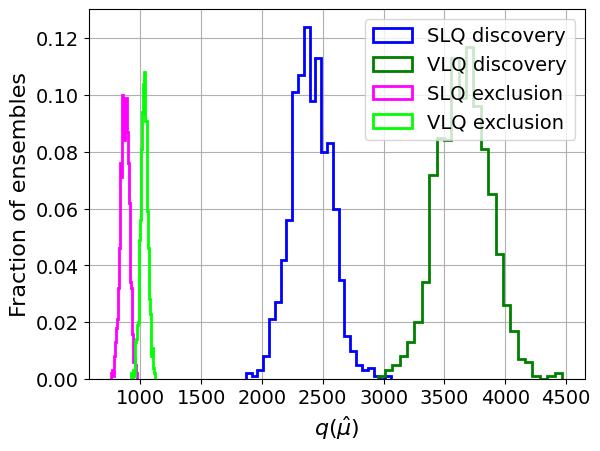


 Binned Likelihood:
Z_dis_SLQ =  48.94319797554887  +-  1.659869210179286
Z_dis_VLQ =  60.437278705452655  +-  0.463501527143409

Z_exc_SLQ =  29.53158586256814  +-  1.659869210179286
Z_exc_VLQ =  32.10164127861482  +-  0.463501527143409

 UnBinned Method:
Z_T_dis_SLQ =  91.82796  +-  0.14653765485146653
Z_T_dis_VLQ =  130.80664  +-  0.18767963864737336

Z_T_exc_SLQ =  19.816442  +-  0.006824184548426271
Z_T_exc_VLQ =  22.040052  +-  0.005328228502607443

------------------------------------------

B_expected:  45962
S_expected:  419
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  36.93931184127484
Z_asimov_dis_VLQ =  43.080343159584025

Z_asimov_exc_SLQ =  22.04220116561371
Z_asimov_exc_VLQ =  23.55921211441699


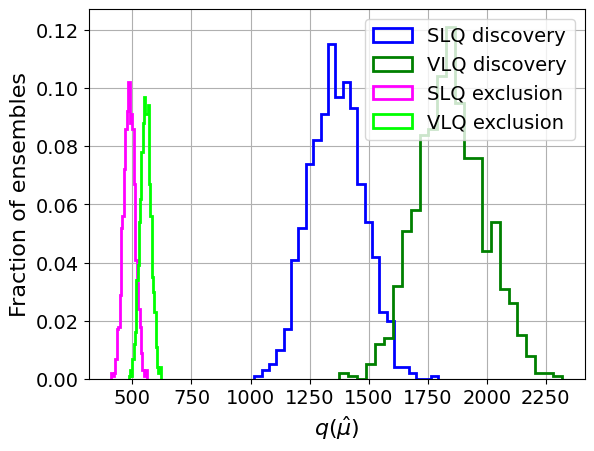


 Binned Likelihood:
Z_dis_SLQ =  36.89373291714096  +-  1.5226704153188653
Z_dis_VLQ =  42.9748676670896  +-  0.4678940512585298

Z_exc_SLQ =  22.044633269980086  +-  1.5226704153188653
Z_exc_VLQ =  23.562977014666277  +-  0.4678940512585298

 UnBinned Method:
Z_T_dis_SLQ =  69.182556  +-  0.13271627995890156
Z_T_dis_VLQ =  91.11243  +-  0.17416896509918942

Z_T_exc_SLQ =  16.484371  +-  0.0075348706301116295
Z_T_exc_VLQ =  16.542717  +-  0.0057415510244922165

------------------------------------------

B_expected:  45962
S_expected:  237
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  27.37868888662048
Z_asimov_dis_VLQ =  30.510928694934904

Z_asimov_exc_SLQ =  16.451194002280406
Z_asimov_exc_VLQ =  17.277469748271532


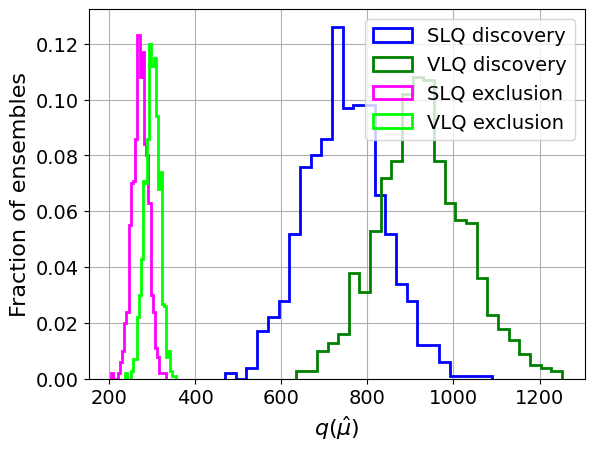


 Binned Likelihood:
Z_dis_SLQ =  27.27346371988976  +-  1.6715288421015864
Z_dis_VLQ =  30.403252738607122  +-  0.4898633606045693

Z_exc_SLQ =  16.478003572697396  +-  1.6715288421015864
Z_exc_VLQ =  17.315768412374776  +-  0.4898633606045693

 UnBinned Method:
Z_T_dis_SLQ =  49.491703  +-  0.1409180865691363
Z_T_dis_VLQ =  61.208942  +-  0.16539080178797957

Z_T_exc_SLQ =  11.106204  +-  0.007096321163212692
Z_T_exc_VLQ =  11.70317  +-  0.006046285459586416

------------------------------------------

B_expected:  45962
S_expected:  137
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  20.387143418913343
Z_asimov_dis_VLQ =  21.846881870499686

Z_asimov_exc_SLQ =  12.443190146561006
Z_asimov_exc_VLQ =  12.83992074903348


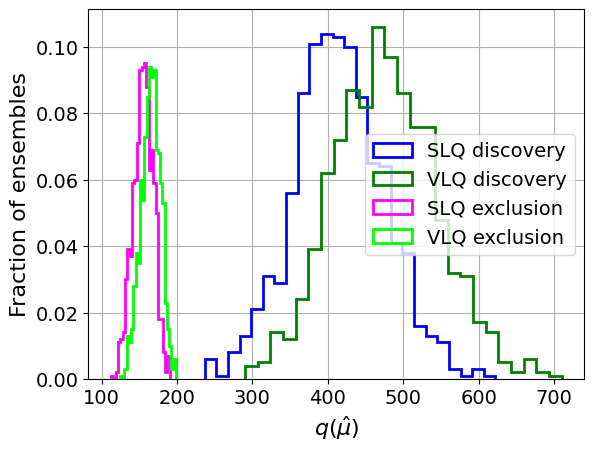


 Binned Likelihood:
Z_dis_SLQ =  20.349074174867596  +-  1.485274062571446
Z_dis_VLQ =  21.75444604603144  +-  0.49640959283918856

Z_exc_SLQ =  12.46947188421055  +-  1.485274062571446
Z_exc_VLQ =  12.867299796695024  +-  0.49640959283918856

 UnBinned Method:
Z_T_dis_SLQ =  36.599503  +-  0.1264799119491374
Z_T_dis_VLQ =  42.5977  +-  0.14857004262327458

Z_T_exc_SLQ =  9.150685  +-  0.007906393865945603
Z_T_exc_VLQ =  9.066818  +-  0.006730832019316812

------------------------------------------

B_expected:  45962
S_expected:  80
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  15.009138665213012
Z_asimov_dis_VLQ =  15.451782992279677

Z_asimov_exc_SLQ =  9.411034874072461
Z_asimov_exc_VLQ =  9.509914538244189


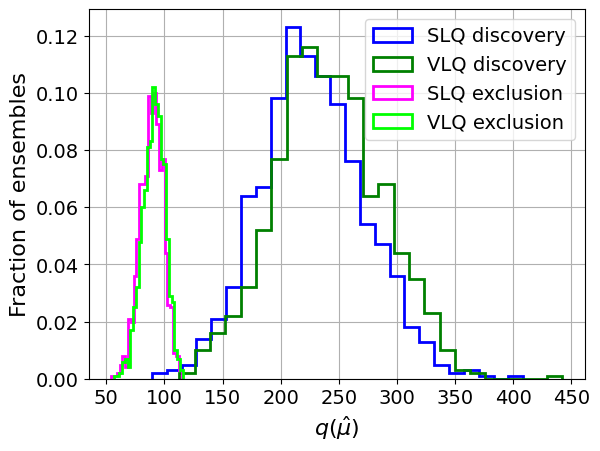


 Binned Likelihood:
Z_dis_SLQ =  15.000502437251022  +-  1.5070582781914934
Z_dis_VLQ =  15.4300479004851  +-  0.502295059138882

Z_exc_SLQ =  9.4443189516289  +-  1.5070582781914934
Z_exc_VLQ =  9.551539488204472  +-  0.502295059138882

 UnBinned Method:
Z_T_dis_SLQ =  26.925913  +-  0.12634624579800866
Z_T_dis_VLQ =  29.470835  +-  0.13555946781237052

Z_T_exc_SLQ =  6.7391963  +-  0.007914758318966696
Z_T_exc_VLQ =  6.87484  +-  0.0073768362781131015

------------------------------------------

B_expected:  45962
S_expected:  46
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  10.784721423156185
Z_asimov_dis_VLQ =  10.688426547844411

Z_asimov_exc_SLQ =  7.031373055025063
Z_asimov_exc_VLQ =  6.937075955465894


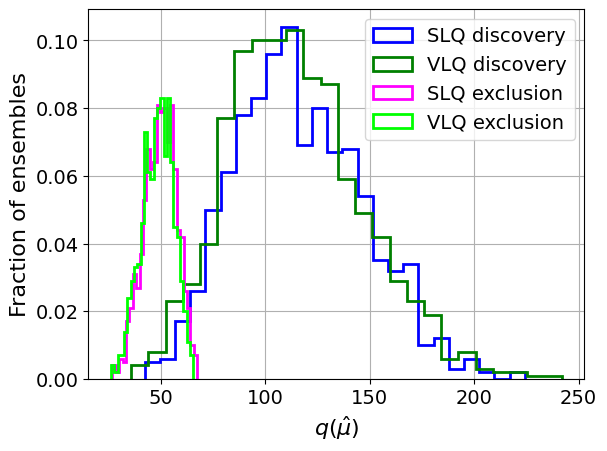


 Binned Likelihood:
Z_dis_SLQ =  10.661144399973983  +-  1.4395318012742608
Z_dis_VLQ =  10.581340948378038  +-  0.5411209325226323

Z_exc_SLQ =  7.072062136530543  +-  1.4395318012742608
Z_exc_VLQ =  6.980983916834717  +-  0.5411209325226323

 UnBinned Method:
Z_T_dis_SLQ =  18.984869  +-  0.12006990408502603
Z_T_dis_VLQ =  19.588465  +-  0.13071625052997643

Z_T_exc_SLQ =  5.0000396  +-  0.008328481709220507
Z_T_exc_VLQ =  4.7388268  +-  0.0076501582316322305

------------------------------------------

B_expected:  45962
S_expected:  27
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  7.729012926219351
Z_asimov_dis_VLQ =  7.363331678157809

Z_asimov_exc_SLQ =  5.264742191098182
Z_asimov_exc_VLQ =  5.061610932435178


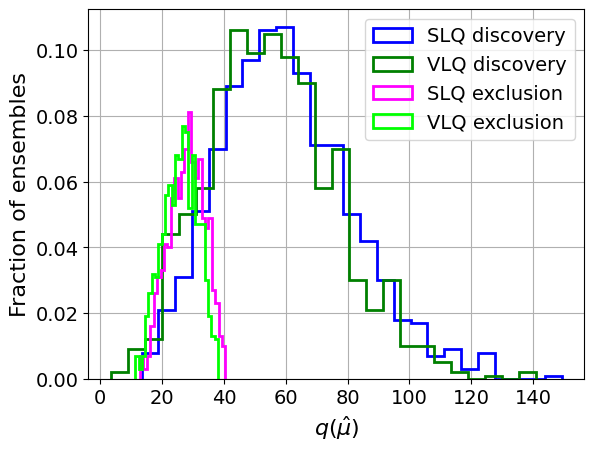


 Binned Likelihood:
Z_dis_SLQ =  7.6241611645857486  +-  1.399691275081471
Z_dis_VLQ =  7.391566946689819  +-  0.5488155875788003

Z_exc_SLQ =  5.310909850117445  +-  1.399691275081471
Z_exc_VLQ =  5.110238156252745  +-  0.5488155875788003

 UnBinned Method:
Z_T_dis_SLQ =  13.830119  +-  0.11386225669483664
Z_T_dis_VLQ =  13.60437  +-  0.11802546528476754

Z_T_exc_SLQ =  3.8410163  +-  0.008782541546494287
Z_T_exc_VLQ =  3.6450434  +-  0.008472747788684726

------------------------------------------

B_expected:  45962
S_expected:  16
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  5.484029011980471
Z_asimov_dis_VLQ =  5.054577925510671

Z_asimov_exc_SLQ =  3.9172960347022423
Z_asimov_exc_VLQ =  3.6739765225841485


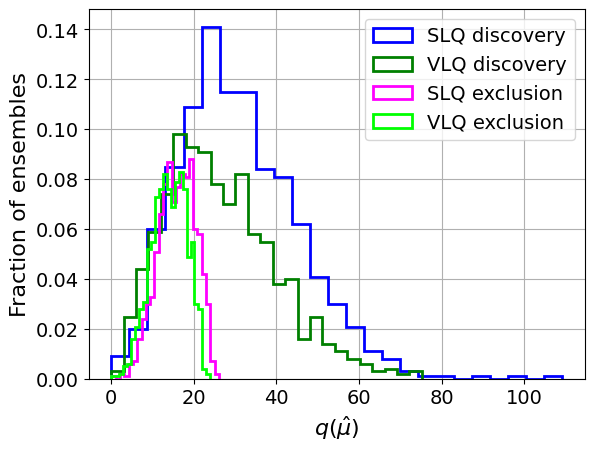


 Binned Likelihood:
Z_dis_SLQ =  5.399621006862763  +-  1.3244321759695892
Z_dis_VLQ =  4.951488881463023  +-  0.5646028386198375

Z_exc_SLQ =  4.000269942781283  +-  1.3244321759695892
Z_exc_VLQ =  3.7538703189982874  +-  0.5646028386198375

 UnBinned Method:
Z_T_dis_SLQ =  9.406919  +-  0.10033299091468798
Z_T_dis_VLQ =  8.642917  +-  0.1021383231861987

Z_T_exc_SLQ =  2.9648561  +-  0.009966811423475743
Z_T_exc_VLQ =  2.6759107  +-  0.009790644381120248

------------------------------------------



In [ ]:
masses_SLQ = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
masses_VLQ = [1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

S_expected = S_expected_SLQ[:8]

n_pseudo = 1000


N_bins = 1000

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



Z_asimov_dis_SLQ = []
Z_asimov_exc_SLQ = []

Z_asimov_dis_VLQ = []
Z_asimov_exc_VLQ = []


Z_dis_SLQ = []
Z_exc_SLQ = []

Z_dis_VLQ = []
Z_exc_VLQ = []

Z_dis_std_SLQ = []
Z_exc_std_SLQ = []

Z_dis_std_VLQ = []
Z_exc_std_VLQ = []


Z_T_dis_SLQ = []
Z_T_dis_VLQ = []

Z_T_exc_SLQ = []
Z_T_exc_VLQ = []


Z_T_dis_err_SLQ = []
Z_T_dis_err_VLQ = []

Z_T_exc_err_SLQ = []
Z_T_exc_err_VLQ = []


for m_it in range(len(masses_SLQ)):

    print('B_expected: ', B_expected)
    print('S_expected: ', S_expected[m_it])

    mass_SLQ = masses_SLQ[m_it]
    mass_VLQ = masses_VLQ[m_it]

    print('m_SLQ= ', mass_SLQ, ' GeV' )
    print('m_VLQ= ', mass_VLQ, ' GeV' )



    ###################
    # ASIMOV EXPECTED #
    ###################

    # SLQ PDF
    hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
    S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected[m_it])

    # SLQ PDF
    hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
    S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected[m_it])


    Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
    Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

    Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
    Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


    Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
    Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

    Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
    Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


    print('\n Asimov datasets:')
    print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
    print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
    print()
    print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
    print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





    #####################
    # BINNED LIKELIHOOD #
    #####################

    q_dis_SLQ = []
    q_exc_SLQ = []

    q_dis_VLQ = []
    q_exc_VLQ = []


    T_SLQ = []
    T_VLQ = []
    T_B = []

    for pexp_it in range(n_pseudo):

        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_expected[m_it])


        # pseudo experiment (DISCOVERY: SM vs SM+LQ)
        # SLQ
        scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_SLQ[mass_SLQ], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
        N_pseudo_SLQ = hist

        # VLQ
        scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_VLQ[mass_VLQ], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
        N_pseudo_VLQ = hist


        # pseudo experiment (EXCLUSION: SM ONLY)
        # SLQ and VLQ (since no signal)
        scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM, N_B )
        hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
        N_pseudo_EXC = hist



        # DISCOVERY (mu_hat=1 idedally)
        # SLQ
        mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

        q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
        q_dis_SLQ.append(q_dis_SLQ_it)


        # VLQ
        mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

        q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
        q_dis_VLQ.append(q_dis_VLQ_it)



        # EXCLUSION (mu_hat=0 idedally)
        # SLQ
        mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
        q_exc_SLQ.append(q_exc_SLQ_it)


        # VLQ
        mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
        q_exc_VLQ.append(q_exc_VLQ_it)


        ####
        # UNBINNED
        ####
        T_SLQ.append(compute_T(scoresA_pseudo_SLQ, S_expected[m_it], B_expected))
        T_VLQ.append(compute_T(scoresA_pseudo_VLQ, S_expected[m_it], B_expected))

        T_B.append(compute_T(scoresA_pseudo_EXC, S_expected[m_it], B_expected))



    # Histogram of q_muhats
    weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='blue', linewidth=2, label='SLQ discovery')
    weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

    weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
    weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
    #plt.xlim(0,1)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("$q(\hat{\mu})$",fontsize=16)
    plt.ylabel("Fraction of ensembles",fontsize=16)
    plt.grid()
    plt.legend(fontsize=14)
    plt.show()




    Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
    Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

    Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
    Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


    Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
    Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

    Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
    Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


    Z_dis_SLQ.append(Z_dis_SLQ_it)
    Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
    Z_exc_SLQ.append(Z_exc_SLQ_it)
    Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

    Z_dis_VLQ.append(Z_dis_VLQ_it)
    Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
    Z_exc_VLQ.append(Z_exc_VLQ_it)
    Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


    print('\n Binned Likelihood:')
    print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
    print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_exc_std_VLQ_it)
    print()
    print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
    print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)



    Z_T_dis_SLQ_it = (np.mean(T_SLQ)-np.mean(T_B)) / np.std(T_B)
    Z_T_exc_SLQ_it = (np.mean(T_SLQ)-np.mean(T_B)) / np.std(T_SLQ)

    Z_T_dis_SLQ.append(Z_T_dis_SLQ_it)
    Z_T_exc_SLQ.append(Z_T_exc_SLQ_it)

    Z_T_dis_err_SLQ_it = np.std(T_SLQ)/np.sqrt(len(T_SLQ)) / np.std(T_B)
    Z_T_exc_err_SLQ_it = np.std(T_B)/np.sqrt(len(T_B)) / np.std(T_SLQ)

    Z_T_dis_err_SLQ.append(Z_T_dis_err_SLQ_it)
    Z_T_exc_err_SLQ.append(Z_T_exc_err_SLQ_it)


    Z_T_dis_VLQ_it = (np.mean(T_VLQ)-np.mean(T_B)) / np.std(T_B)
    Z_T_exc_VLQ_it = (np.mean(T_VLQ)-np.mean(T_B)) / np.std(T_VLQ)

    Z_T_dis_VLQ.append(Z_T_dis_VLQ_it)
    Z_T_exc_VLQ.append(Z_T_exc_VLQ_it)

    Z_T_dis_err_VLQ_it = np.std(T_VLQ)/np.sqrt(len(T_VLQ)) / np.std(T_B)
    Z_T_exc_err_VLQ_it = np.std(T_B)/np.sqrt(len(T_B)) / np.std(T_VLQ)

    Z_T_dis_err_VLQ.append(Z_T_dis_err_VLQ_it)
    Z_T_exc_err_VLQ.append(Z_T_exc_err_VLQ_it)

    print('\n UnBinned Method:')
    print("Z_T_dis_SLQ = ",Z_T_dis_SLQ_it, ' +- ', Z_T_dis_err_SLQ_it)
    print("Z_T_dis_VLQ = ",Z_T_dis_VLQ_it, ' +- ', Z_T_dis_err_VLQ_it)
    print()
    print("Z_T_exc_SLQ = ",Z_T_exc_SLQ_it, ' +- ', Z_T_exc_err_SLQ_it)
    print("Z_T_exc_VLQ = ",Z_T_exc_VLQ_it, ' +- ', Z_T_exc_err_VLQ_it)


    print('\n------------------------------------------\n')

m_asimov_dis_SLQ =  1921.5604668216329  GeV
m_asimov_dis_VLQ =  2302.3639561147693  GeV

m_asimov_exc_VLQ =  2446.2289260937623  GeV
m_asimov_exc_SLQ =  2068.648104932738  GeV

m_BL_dis_SLQ =  1917.9642073655264  GeV
m_BL_dis_VLQ =  2298.0119030112887  GeV

m_BL_exc_VLQ =  2455.490025207016  GeV
m_BL_exc_SLQ =  2079.714985225585  GeV

m_UB_dis_SLQ =  1999.631893665932  GeV
m_UB_dis_VLQ =  2373.4243851131223  GeV

m_UB_exc_VLQ =  2406.389674495261  GeV
m_UB_exc_SLQ =  2050.6576769829053  GeV


/tmp/ipykernel_43487/3754139578.py:27: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_dis_SLQ = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1600)[0]
/tmp/ipykernel_43487/3754139578.py:28: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_exc_SLQ = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]
/tmp/ipykernel_43487/3754139578.py:30: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_dis_VLQ = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1600)[0]
/tmp/ipykernel_43487/3754139578.py:31: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_exc_VLQ = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1600)[0]
/tmp/ipykernel_43487/3754139578.py:33: RuntimeWa

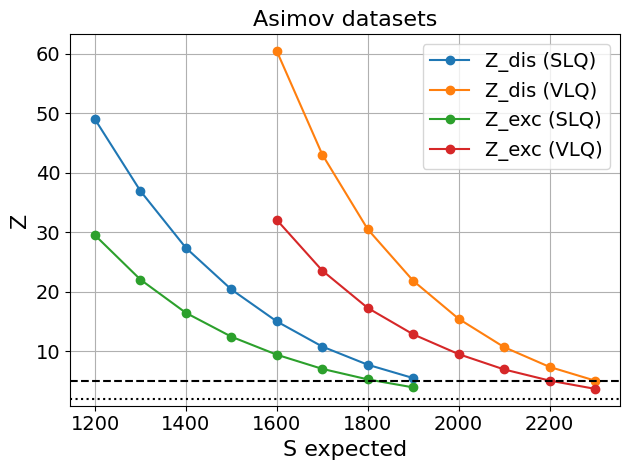

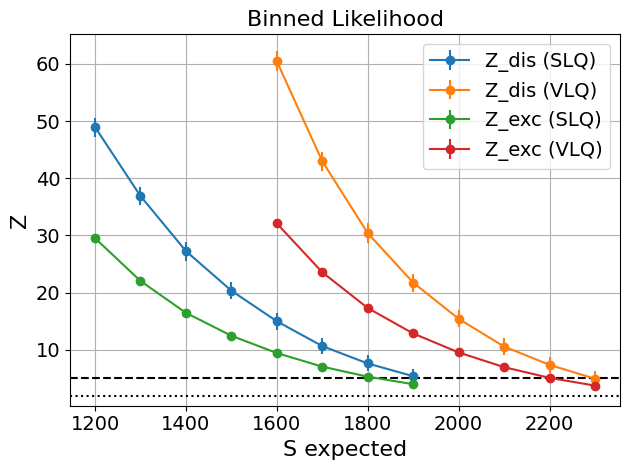

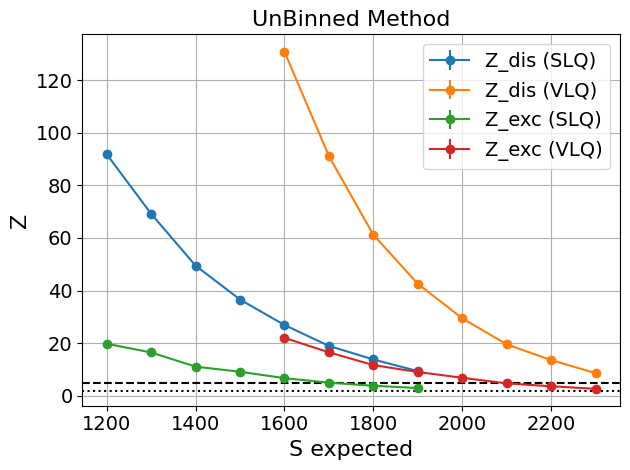

In [ ]:
# Z value that we want
Z_dis = 5
Z_exc = stats.norm.isf(0.05)

#  interpolate
f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")

f_Z_UB_dis_SLQ = interp1d(masses_SLQ, Z_T_dis_SLQ, kind='linear', fill_value="extrapolate")
f_Z_UB_exc_SLQ = interp1d(masses_SLQ, Z_T_exc_SLQ, kind='linear', fill_value="extrapolate")

f_Z_UB_dis_VLQ = interp1d(masses_VLQ, Z_T_dis_VLQ, kind='linear', fill_value="extrapolate")
f_Z_UB_exc_VLQ = interp1d(masses_VLQ, Z_T_exc_VLQ, kind='linear', fill_value="extrapolate")


# find the mass such that we get Z for discovery or exclusion

m_asimov_dis_SLQ = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1600)[0]
m_asimov_exc_SLQ = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]

m_asimov_dis_VLQ = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1600)[0]
m_asimov_exc_VLQ = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1600)[0]

m_BL_dis_SLQ = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1600)[0]
m_BL_exc_SLQ = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1600)[0]

m_BL_dis_VLQ = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1600)[0]
m_BL_exc_VLQ = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1600)[0]

m_UB_dis_SLQ = fsolve(lambda x: f_Z_UB_dis_SLQ(x) - Z_dis,1600)[0]
m_UB_exc_SLQ = fsolve(lambda x: f_Z_UB_exc_SLQ(x) - Z_exc,1600)[0]

m_UB_dis_VLQ = fsolve(lambda x: f_Z_UB_dis_VLQ(x) - Z_dis,1600)[0]
m_UB_exc_VLQ = fsolve(lambda x: f_Z_UB_exc_VLQ(x) - Z_exc,1600)[0]

print('m_asimov_dis_SLQ = ', m_asimov_dis_SLQ, ' GeV')
print('m_asimov_dis_VLQ = ', m_asimov_dis_VLQ, ' GeV')
print()
print('m_asimov_exc_VLQ = ', m_asimov_exc_VLQ, ' GeV')
print('m_asimov_exc_SLQ = ', m_asimov_exc_SLQ, ' GeV')

print()
print('m_BL_dis_SLQ = ', m_BL_dis_SLQ, ' GeV')
print('m_BL_dis_VLQ = ', m_BL_dis_VLQ, ' GeV')
print()
print('m_BL_exc_VLQ = ', m_BL_exc_VLQ, ' GeV')
print('m_BL_exc_SLQ = ', m_BL_exc_SLQ, ' GeV')

print()
print('m_UB_dis_SLQ = ', m_UB_dis_SLQ, ' GeV')
print('m_UB_dis_VLQ = ', m_UB_dis_VLQ, ' GeV')
print()
print('m_UB_exc_VLQ = ', m_UB_exc_VLQ, ' GeV')
print('m_UB_exc_SLQ = ', m_UB_exc_SLQ, ' GeV')





# plot ASIMOV DATASETS

plt.plot(masses_SLQ, Z_asimov_dis_SLQ, 'o-', label='Z_dis (SLQ)')
plt.plot(masses_VLQ, Z_asimov_dis_VLQ, 'o-', label='Z_dis (VLQ)')

plt.plot(masses_SLQ, Z_asimov_exc_SLQ, 'o-', label='Z_exc (SLQ)')
plt.plot(masses_VLQ, Z_asimov_exc_VLQ, 'o-', label='Z_exc (VLQ)')

plt.axhline(y=5, linestyle='--', color='black')
plt.axhline(y=2, linestyle=':', color='black')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("S expected",fontsize=16)
plt.ylabel("Z",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.errorbar(masses_SLQ, Z_dis_SLQ, yerr=Z_dis_std_SLQ, fmt='o-', label='Z_dis (SLQ)')
plt.errorbar(masses_VLQ, Z_dis_VLQ, yerr=Z_dis_std_VLQ, fmt='o-', label='Z_dis (VLQ)')

plt.errorbar(masses_SLQ, Z_exc_SLQ, yerr=Z_exc_std_SLQ, fmt='o-', label='Z_exc (SLQ)')
plt.errorbar(masses_VLQ, Z_exc_VLQ, yerr=Z_exc_std_VLQ, fmt='o-', label='Z_exc (VLQ)')

plt.axhline(y=5, linestyle='--', color='black')
plt.axhline(y=2, linestyle=':', color='black')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("S expected",fontsize=16)
plt.ylabel("Z",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot UNBINNED METHOD

plt.errorbar(masses_SLQ, Z_T_dis_SLQ, yerr=Z_T_dis_err_SLQ, fmt='o-', label='Z_dis (SLQ)')
plt.errorbar(masses_VLQ, Z_T_dis_VLQ, yerr=Z_T_dis_err_VLQ, fmt='o-', label='Z_dis (VLQ)')

plt.errorbar(masses_SLQ, Z_T_exc_SLQ, yerr=Z_T_exc_err_SLQ, fmt='o-', label='Z_exc (SLQ)')
plt.errorbar(masses_VLQ, Z_T_exc_VLQ, yerr=Z_T_exc_err_VLQ, fmt='o-', label='Z_exc (VLQ)')

plt.axhline(y=5, linestyle='--', color='black')
plt.axhline(y=2, linestyle=':', color='black')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("S expected",fontsize=16)
plt.ylabel("Z",fontsize=16)
plt.title('UnBinned Method', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

## SLQ vs VLQ (divide in sectors, following the S_expected_calculated)

In [ ]:
df_SLQ_norm[1300] = df_SLQ_rest_norm[1300]
df_SLQ_norm[1500] = df_SLQ_rest_norm[1500]
df_SLQ_norm[1700] = df_SLQ_rest_norm[1700]
df_SLQ_norm[1900] = df_SLQ_rest_norm[1900]

df_VLQ_norm[1700] = df_VLQ_rest_norm[1700]
df_VLQ_norm[1900] = df_VLQ_rest_norm[1900]
df_VLQ_norm[2100] = df_VLQ_rest_norm[2100]
df_VLQ_norm[2300] = df_VLQ_rest_norm[2300]

#### no mass reconstruction at all

In [ ]:
split_SM = split_class(df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop','mLQ_reg']))
split_SLQ = {mass: split_class(df_SLQ_norm[mass].drop(columns=['mLQ1','mLQ2','mTop','mLQ_reg'])) for mass in df_SLQ_norm}
split_VLQ = {mass: split_class(df_VLQ_norm[mass].drop(columns=['mLQ1','mLQ2','mTop','mLQ_reg'])) for mass in df_VLQ_norm}

In [ ]:
sectors = {
    0: [(1200, 1600)],        # mucha señal
    1: [(1300, 1700)],
    2: [(1400, 1800)],
    3: [(1500, 1900)],
    4: [(1600, 2000)],        # señal intermedia
    5: [                      # señal baja
        (1700, 2100),
        (1800, 2200),
        (1900, 2300),
    ]
}

In [ ]:
X_train_list, y_train_list, sector_train_list = [], [], []
X_val_list,   y_val_list,   sector_val_list   = [], [], []
X_test_list,  y_test_list,  sector_test_list  = [], [], []

for sector_id, pair_list in sectors.items():

    for (m_s, m_v) in pair_list:

        # -------- SLQ --------
        X_train_s, X_val_s, X_test_s, _ = split_SLQ[m_s]

        X_train_list.append(X_train_s)
        y_train_list.append(np.zeros(len(X_train_s)))
        sector_train_list.append(np.full(len(X_train_s), sector_id))

        X_val_list.append(X_val_s)
        y_val_list.append(np.zeros(len(X_val_s)))
        sector_val_list.append(np.full(len(X_val_s), sector_id))

        X_test_list.append(X_test_s)
        y_test_list.append(np.zeros(len(X_test_s)))
        sector_test_list.append(np.full(len(X_test_s), sector_id))


        # -------- VLQ --------
        X_train_v, X_val_v, X_test_v, _ = split_VLQ[m_v]

        X_train_list.append(X_train_v)
        y_train_list.append(np.ones(len(X_train_v)))
        sector_train_list.append(np.full(len(X_train_v), sector_id))

        X_val_list.append(X_val_v)
        y_val_list.append(np.ones(len(X_val_v)))
        sector_val_list.append(np.full(len(X_val_v), sector_id))

        X_test_list.append(X_test_v)
        y_test_list.append(np.ones(len(X_test_v)))
        sector_test_list.append(np.full(len(X_test_v), sector_id))


# Concatenate
# TRAIN
X_train_spin = np.vstack(X_train_list)
y_train_spin = np.concatenate(y_train_list)
sector_train = np.concatenate(sector_train_list)

# add sector id as extra feature
X_train_spin = np.column_stack([X_train_spin, sector_train])


# VAL
X_val_spin = np.vstack(X_val_list)
y_val_spin = np.concatenate(y_val_list)
sector_val = np.concatenate(sector_val_list)

X_val_spin = np.column_stack([X_val_spin, sector_val])


# TEST
X_test_spin = np.vstack(X_test_list)
y_test_spin = np.concatenate(y_test_list)
sector_test = np.concatenate(sector_test_list)

X_test_spin = np.column_stack([X_test_spin, sector_test])

In [ ]:
classifier_spin = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=5,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50
)

classifier_spin.fit(
    X_train_spin, y_train_spin,
    eval_set=[(X_train_spin, y_train_spin),
              (X_val_spin, y_val_spin)],
    verbose=True
)

classifier_spin.save_model(mainfolder + "saved-models/xgb_spin_conditional_sector_nomass.json")

[0]	validation_0-logloss:0.68004	validation_1-logloss:0.68011
[1]	validation_0-logloss:0.67351	validation_1-logloss:0.67366
[2]	validation_0-logloss:0.66844	validation_1-logloss:0.66866
[3]	validation_0-logloss:0.66421	validation_1-logloss:0.66449
[4]	validation_0-logloss:0.66032	validation_1-logloss:0.66066
[5]	validation_0-logloss:0.65662	validation_1-logloss:0.65697
[6]	validation_0-logloss:0.65318	validation_1-logloss:0.65361
[7]	validation_0-logloss:0.65041	validation_1-logloss:0.65093
[8]	validation_0-logloss:0.64775	validation_1-logloss:0.64827
[9]	validation_0-logloss:0.64520	validation_1-logloss:0.64576
[10]	validation_0-logloss:0.64301	validation_1-logloss:0.64358
[11]	validation_0-logloss:0.64112	validation_1-logloss:0.64172
[12]	validation_0-logloss:0.63859	validation_1-logloss:0.63927
[13]	validation_0-logloss:0.63698	validation_1-logloss:0.63771
[14]	validation_0-logloss:0.63541	validation_1-logloss:0.63614
[15]	validation_0-logloss:0.63303	validation_1-logloss:0.63385
[1

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_43487/3144669894.py:28: SyntaxWarning: invalid escape sequence '\e'
  keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
/tmp/ipykernel_43487/3144669894.py:28: SyntaxWarning: invalid escape sequence '\p'
  keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
/tmp/ipykernel_43487/3144669894.py:29: SyntaxWarning: invalid escape sequence '\e'
  '$p_T(b_2)$','$\eta(b_2)$','$\phi(b_2)$',
/tmp/ipykernel_43487/3144669894.py:29: SyntaxWarning: invalid escape sequen

Global AUC = 0.7470148562556739


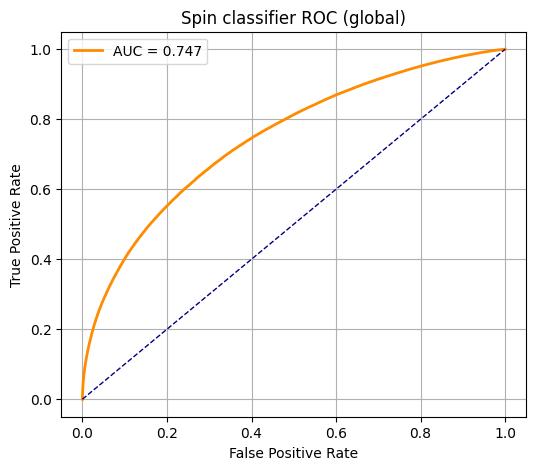

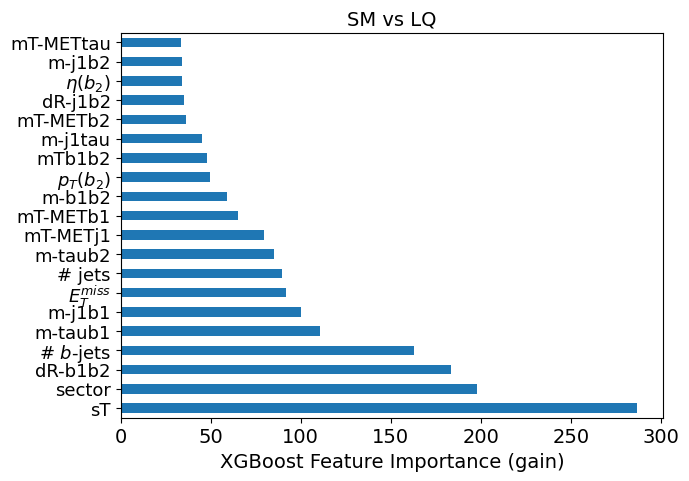

[46, 47, 16, 13, 29, 32, 9, 12, 30, 42, 39, 31, 3, 44, 34]


In [ ]:
# LOAD
classifier_spin = XGBClassifier()
classifier_spin.load_model(mainfolder + "saved-models/xgb_spin_conditional_sector_nomass.json")


y_score = classifier_spin.predict_proba(X_test_spin)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test_spin, y_score)
roc_auc = roc_auc_score(y_test_spin, y_score)

print("Global AUC =", roc_auc)


plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Spin classifier ROC (global)")
plt.grid(True)
plt.legend()
plt.show()




keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
                 '$p_T(b_2)$','$\eta(b_2)$','$\phi(b_2)$',
                 r'$p_T(\tau)$',r'$\eta(\tau)$',r'$\phi(\tau)$',
                 '$E_T^{miss}$','$\phi(E_T^{miss})$',
                 '$H_T$','# jets','# $b$-jets',
                 'dR-taub1','dR-taub2','dR-b1b2',
                 'dR-j1b1','dR-j1b2','dR-j1tau',
                 'dR-j2b1','dR-j2b2','dR-j2tau',
                 'dR-j1j2',
#                  'dphi-taub1','dphi-taub2','dphi-b1b2',
                 'dphi-METb1','dphi-METb2','dphi-METtau',
                 'dphi-METj1','dphi-METj2',
                 'm-taub1','m-taub2','m-b1b2',
                 'm-j1b1','m-j1b2','m-j1tau',
                 'm-j2b1','m-j2b2','m-j2tau',
                 'm-j1j2',
                 'mT-METb1','mT-METb2','mT-METtau',
                 'mT-METj1','mT-METj2',
                 'mTb1b2','mTj1j2','sT',
                 'sector'])

feature_important = classifier_spin.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(20, columns="score").plot(kind='barh',figsize=(7,5)) ## plot top 20 features
plt.xticks(fontsize=14)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
plt.title(r'SM vs LQ', fontsize=14)
# plt.savefig('XG_feature_importance.pdf', bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

In [ ]:
sector_column = X_test_spin[:, -1]


# evaluate per sector
for sector_id in range(6):

    mask = sector_column == sector_id

    y_true_sector = y_test_spin[mask]
    y_score_sector = y_score[mask]

    fpr, tpr, _ = roc_curve(y_true_sector, y_score_sector)
    auc_sector = roc_auc_score(y_true_sector, y_score_sector)

    print(f"Sector {sector_id} AUC = {auc_sector:.5f}")



Sector 0 AUC = 0.77415
Sector 1 AUC = 0.75897
Sector 2 AUC = 0.74443
Sector 3 AUC = 0.73306
Sector 4 AUC = 0.72410
Sector 5 AUC = 0.70812


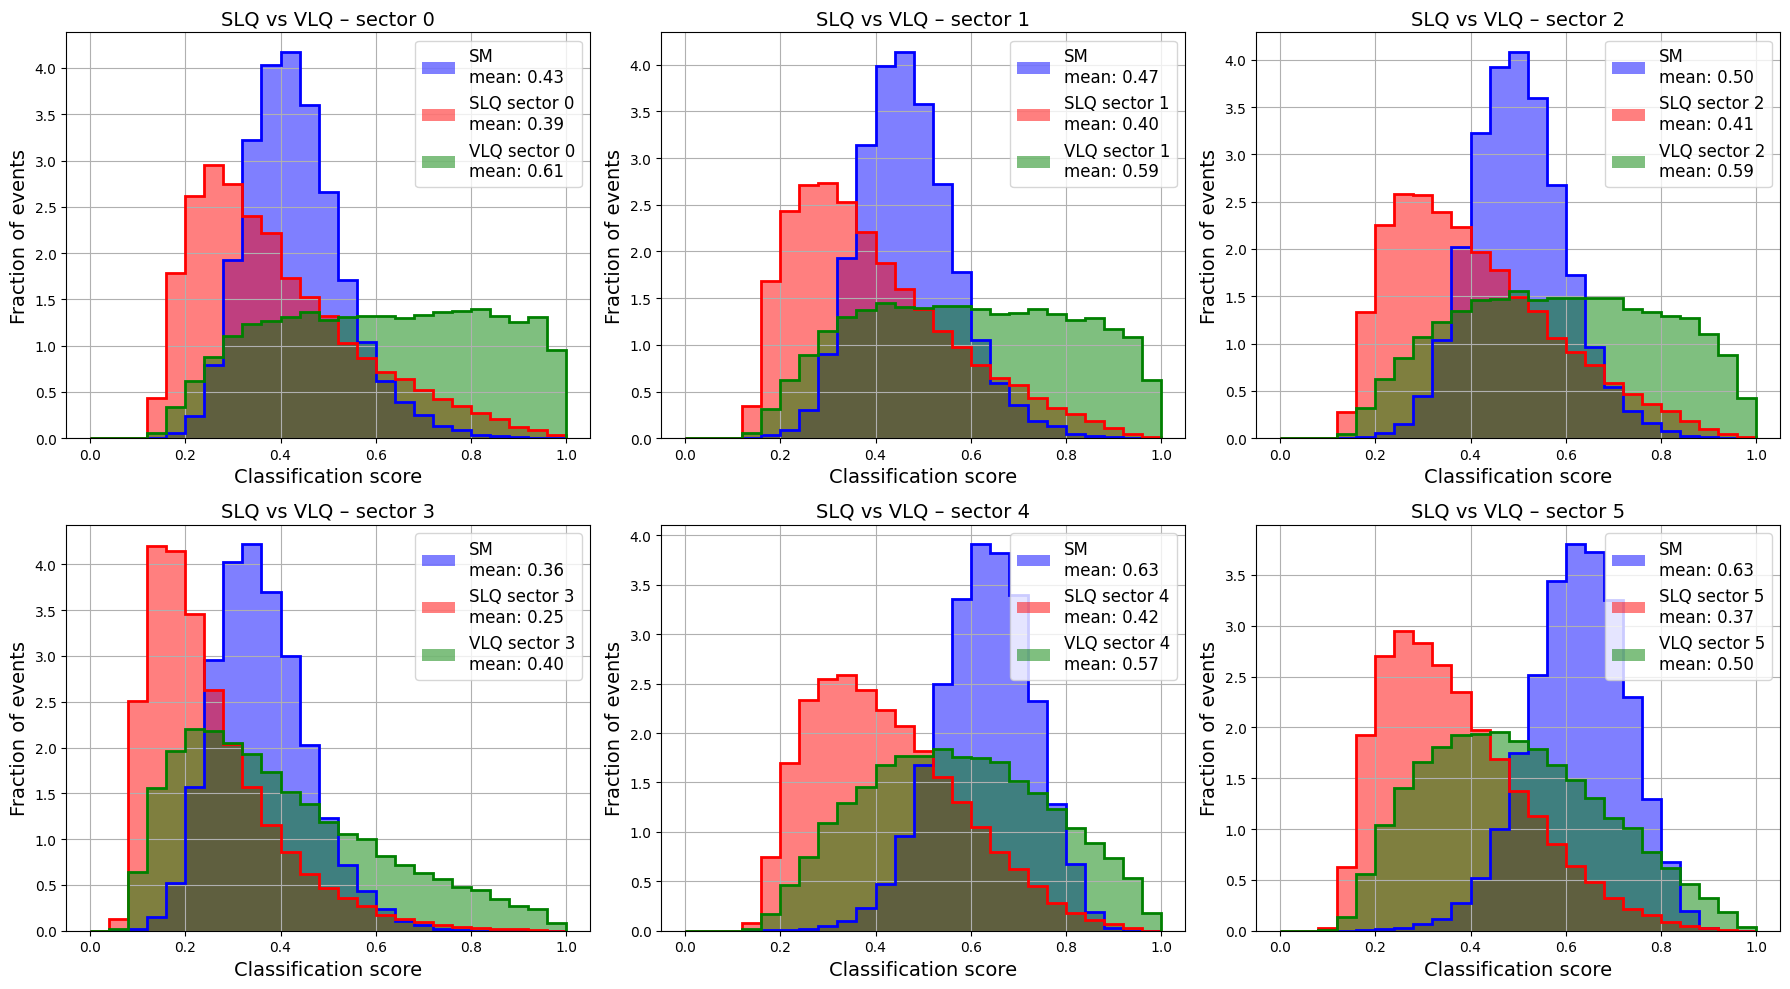

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# axes = axes.flatten()

for sector_id, pair_list in sectors.items():

    if sector_id < 3:
        ax = axes[0,sector_id]
    else:
        ax = axes[1,sector_id-3]

    # SM
    _, _, X_test_B, _ = split_SM
    sector_feature_B = np.full(len(X_test_B), sector_id)
    X_B_spin = np.column_stack([X_test_B, sector_feature_B])
    pred_B = classifier_spin.predict_proba(X_B_spin)[:,1]

    # -------- SLQ --------
    X_SLQ_sector = []

    for m_s, _ in pair_list:
        _, _, X_test_s, _ = split_SLQ[m_s]
        X_SLQ_sector.append(X_test_s)

    X_SLQ_sector = np.vstack(X_SLQ_sector)
    sector_feature_s = np.full(len(X_SLQ_sector), sector_id)
    X_s_spin = np.column_stack([X_SLQ_sector, sector_feature_s])
    pred_s = classifier_spin.predict_proba(X_s_spin)[:,1]


    # -------- VLQ --------
    X_VLQ_sector = []

    for _, m_v in pair_list:
        _, _, X_test_v, _ = split_VLQ[m_v]
        X_VLQ_sector.append(X_test_v)

    X_VLQ_sector = np.vstack(X_VLQ_sector)
    sector_feature_v = np.full(len(X_VLQ_sector), sector_id)
    X_v_spin = np.column_stack([X_VLQ_sector, sector_feature_v])
    pred_v = classifier_spin.predict_proba(X_v_spin)[:,1]


    # Histogramas
    ax.hist(pred_B, bins=25, range=(0,1), density=True, histtype='step', color='blue', linewidth=2)
    ax.hist(pred_s, bins=25, range=(0,1), density=True, histtype='step', color='red', linewidth=2)
    ax.hist(pred_v, bins=25, range=(0,1), density=True, histtype='step', color='green', linewidth=2)

    ax.hist(pred_B, bins=25, range=(0,1), density=True, color='blue', alpha=0.5, label=f'SM\nmean: {np.mean(pred_B):.2f}')
    ax.hist(pred_s, bins=25, range=(0,1), density=True, color='red', alpha=0.5, label=f'SLQ sector {sector_id}\nmean: {np.mean(pred_s):.2f}')
    ax.hist(pred_v, bins=25, range=(0,1), density=True, color='green', alpha=0.5, label=f'VLQ sector {sector_id}\nmean: {np.mean(pred_v):.2f}')

    ax.set_title(f'SLQ vs VLQ – sector {sector_id}', fontsize=14)
    ax.set_xlabel("Classification score", fontsize=14)
    ax.set_ylabel("Fraction of events", fontsize=14)
    ax.grid(True)
    ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

#### With mass reconstruction (kinetic)

In [ ]:
split_SM = split_class(df_SM_norm.drop(columns=['mLQ_reg']))
split_SLQ = {mass: split_class(df_SLQ_norm[mass].drop(columns=['mLQ_reg'])) for mass in df_SLQ_norm}
split_VLQ = {mass: split_class(df_VLQ_norm[mass].drop(columns=['mLQ_reg'])) for mass in df_VLQ_norm}

In [ ]:
sectors = {
    0: [(1200, 1600)],        # mucha señal
    1: [(1300, 1700)],
    2: [(1400, 1800)],
    3: [(1500, 1900)],
    4: [(1600, 2000)],        # señal intermedia
    5: [                      # señal baja
        (1700, 2100),
        (1800, 2200),
        (1900, 2300),
    ]
}

In [ ]:
X_train_list, y_train_list, sector_train_list = [], [], []
X_val_list,   y_val_list,   sector_val_list   = [], [], []
X_test_list,  y_test_list,  sector_test_list  = [], [], []

for sector_id, pair_list in sectors.items():

    for (m_s, m_v) in pair_list:

        # -------- SLQ --------
        X_train_s, X_val_s, X_test_s, _ = split_SLQ[m_s]

        X_train_list.append(X_train_s)
        y_train_list.append(np.zeros(len(X_train_s)))
        sector_train_list.append(np.full(len(X_train_s), sector_id))

        X_val_list.append(X_val_s)
        y_val_list.append(np.zeros(len(X_val_s)))
        sector_val_list.append(np.full(len(X_val_s), sector_id))

        X_test_list.append(X_test_s)
        y_test_list.append(np.zeros(len(X_test_s)))
        sector_test_list.append(np.full(len(X_test_s), sector_id))


        # -------- VLQ --------
        X_train_v, X_val_v, X_test_v, _ = split_VLQ[m_v]

        X_train_list.append(X_train_v)
        y_train_list.append(np.ones(len(X_train_v)))
        sector_train_list.append(np.full(len(X_train_v), sector_id))

        X_val_list.append(X_val_v)
        y_val_list.append(np.ones(len(X_val_v)))
        sector_val_list.append(np.full(len(X_val_v), sector_id))

        X_test_list.append(X_test_v)
        y_test_list.append(np.ones(len(X_test_v)))
        sector_test_list.append(np.full(len(X_test_v), sector_id))


# Concatenate
# TRAIN
X_train_spin = np.vstack(X_train_list)
y_train_spin = np.concatenate(y_train_list)
sector_train = np.concatenate(sector_train_list)

# add sector id as extra feature
X_train_spin = np.column_stack([X_train_spin, sector_train])


# VAL
X_val_spin = np.vstack(X_val_list)
y_val_spin = np.concatenate(y_val_list)
sector_val = np.concatenate(sector_val_list)

X_val_spin = np.column_stack([X_val_spin, sector_val])


# TEST
X_test_spin = np.vstack(X_test_list)
y_test_spin = np.concatenate(y_test_list)
sector_test = np.concatenate(sector_test_list)

X_test_spin = np.column_stack([X_test_spin, sector_test])

In [ ]:
classifier_spin = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=5,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50
)

classifier_spin.fit(
    X_train_spin, y_train_spin,
    eval_set=[(X_train_spin, y_train_spin),
              (X_val_spin, y_val_spin)],
    verbose=True
)

classifier_spin.save_model(mainfolder + "saved-models/xgb_spin_conditional_sector_massK.json")

[0]	validation_0-logloss:0.68004	validation_1-logloss:0.68010
[1]	validation_0-logloss:0.67349	validation_1-logloss:0.67362
[2]	validation_0-logloss:0.66839	validation_1-logloss:0.66859
[3]	validation_0-logloss:0.66407	validation_1-logloss:0.66430
[4]	validation_0-logloss:0.66018	validation_1-logloss:0.66048
[5]	validation_0-logloss:0.65651	validation_1-logloss:0.65686
[6]	validation_0-logloss:0.65254	validation_1-logloss:0.65299
[7]	validation_0-logloss:0.64981	validation_1-logloss:0.65031
[8]	validation_0-logloss:0.64713	validation_1-logloss:0.64769
[9]	validation_0-logloss:0.64477	validation_1-logloss:0.64533
[10]	validation_0-logloss:0.64239	validation_1-logloss:0.64294
[11]	validation_0-logloss:0.64043	validation_1-logloss:0.64106
[12]	validation_0-logloss:0.63867	validation_1-logloss:0.63935
[13]	validation_0-logloss:0.63694	validation_1-logloss:0.63764
[14]	validation_0-logloss:0.63533	validation_1-logloss:0.63609
[15]	validation_0-logloss:0.63376	validation_1-logloss:0.63456
[1

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_43487/2278699139.py:28: SyntaxWarning: invalid escape sequence '\e'
  keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
/tmp/ipykernel_43487/2278699139.py:28: SyntaxWarning: invalid escape sequence '\p'
  keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
/tmp/ipykernel_43487/2278699139.py:29: SyntaxWarning: invalid escape sequence '\e'
  '$p_T(b_2)$','$\eta(b_2)$','$\phi(b_2)$',
/tmp/ipykernel_43487/2278699139.py:29: SyntaxWarning: invalid escape sequen

Global AUC = 0.7474455692736677


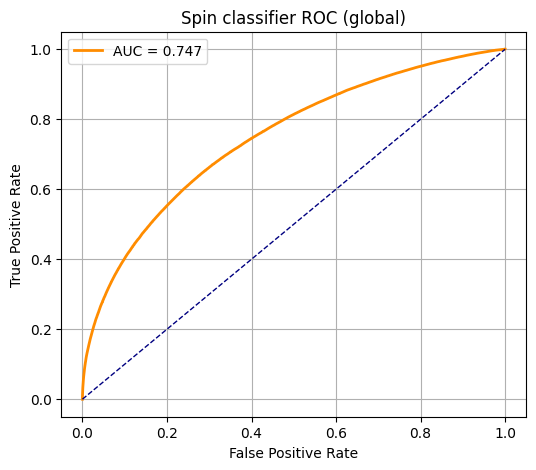

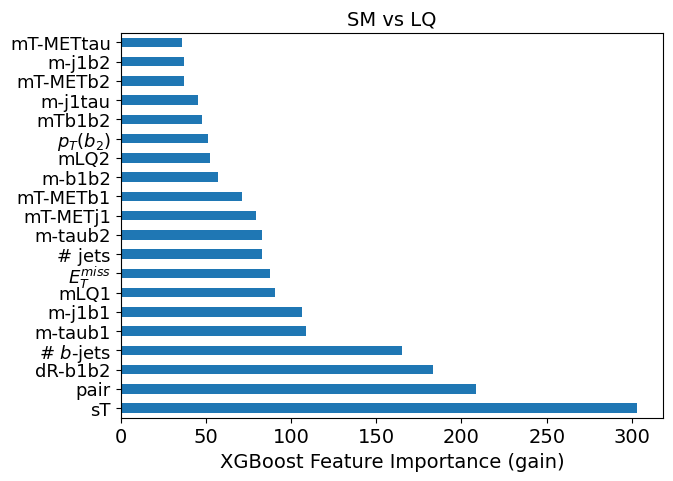

[46, 50, 16, 13, 29, 32, 47, 9, 12, 30, 42, 39, 31, 48, 3]


In [ ]:
# LOAD
classifier_spin = XGBClassifier()
classifier_spin.load_model(mainfolder + "saved-models/xgb_spin_conditional_sector_massK.json")


y_score = classifier_spin.predict_proba(X_test_spin)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test_spin, y_score)
roc_auc = roc_auc_score(y_test_spin, y_score)

print("Global AUC =", roc_auc)


plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Spin classifier ROC (global)")
plt.grid(True)
plt.legend()
plt.show()




keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
                 '$p_T(b_2)$','$\eta(b_2)$','$\phi(b_2)$',
                 r'$p_T(\tau)$',r'$\eta(\tau)$',r'$\phi(\tau)$',
                 '$E_T^{miss}$','$\phi(E_T^{miss})$',
                 '$H_T$','# jets','# $b$-jets',
                 'dR-taub1','dR-taub2','dR-b1b2',
                 'dR-j1b1','dR-j1b2','dR-j1tau',
                 'dR-j2b1','dR-j2b2','dR-j2tau',
                 'dR-j1j2',
#                  'dphi-taub1','dphi-taub2','dphi-b1b2',
                 'dphi-METb1','dphi-METb2','dphi-METtau',
                 'dphi-METj1','dphi-METj2',
                 'm-taub1','m-taub2','m-b1b2',
                 'm-j1b1','m-j1b2','m-j1tau',
                 'm-j2b1','m-j2b2','m-j2tau',
                 'm-j1j2',
                 'mT-METb1','mT-METb2','mT-METtau',
                 'mT-METj1','mT-METj2',
                 'mTb1b2','mTj1j2','sT',
                 'mLQ1','mLQ2','mTop',
                 'pair'])

feature_important = classifier_spin.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(20, columns="score").plot(kind='barh',figsize=(7,5)) ## plot top 20 features
plt.xticks(fontsize=14)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
plt.title(r'SM vs LQ', fontsize=14)
# plt.savefig('XG_feature_importance.pdf', bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

In [ ]:
sector_column = X_test_spin[:, -1]


# evaluate per sector
for sector_id in range(6):

    mask = sector_column == sector_id

    y_true_sector = y_test_spin[mask]
    y_score_sector = y_score[mask]

    fpr, tpr, _ = roc_curve(y_true_sector, y_score_sector)
    auc_sector = roc_auc_score(y_true_sector, y_score_sector)

    print(f"Sector {sector_id} AUC = {auc_sector:.5f}")



Sector 0 AUC = 0.77522
Sector 1 AUC = 0.75984
Sector 2 AUC = 0.74517
Sector 3 AUC = 0.73338
Sector 4 AUC = 0.72359
Sector 5 AUC = 0.70833


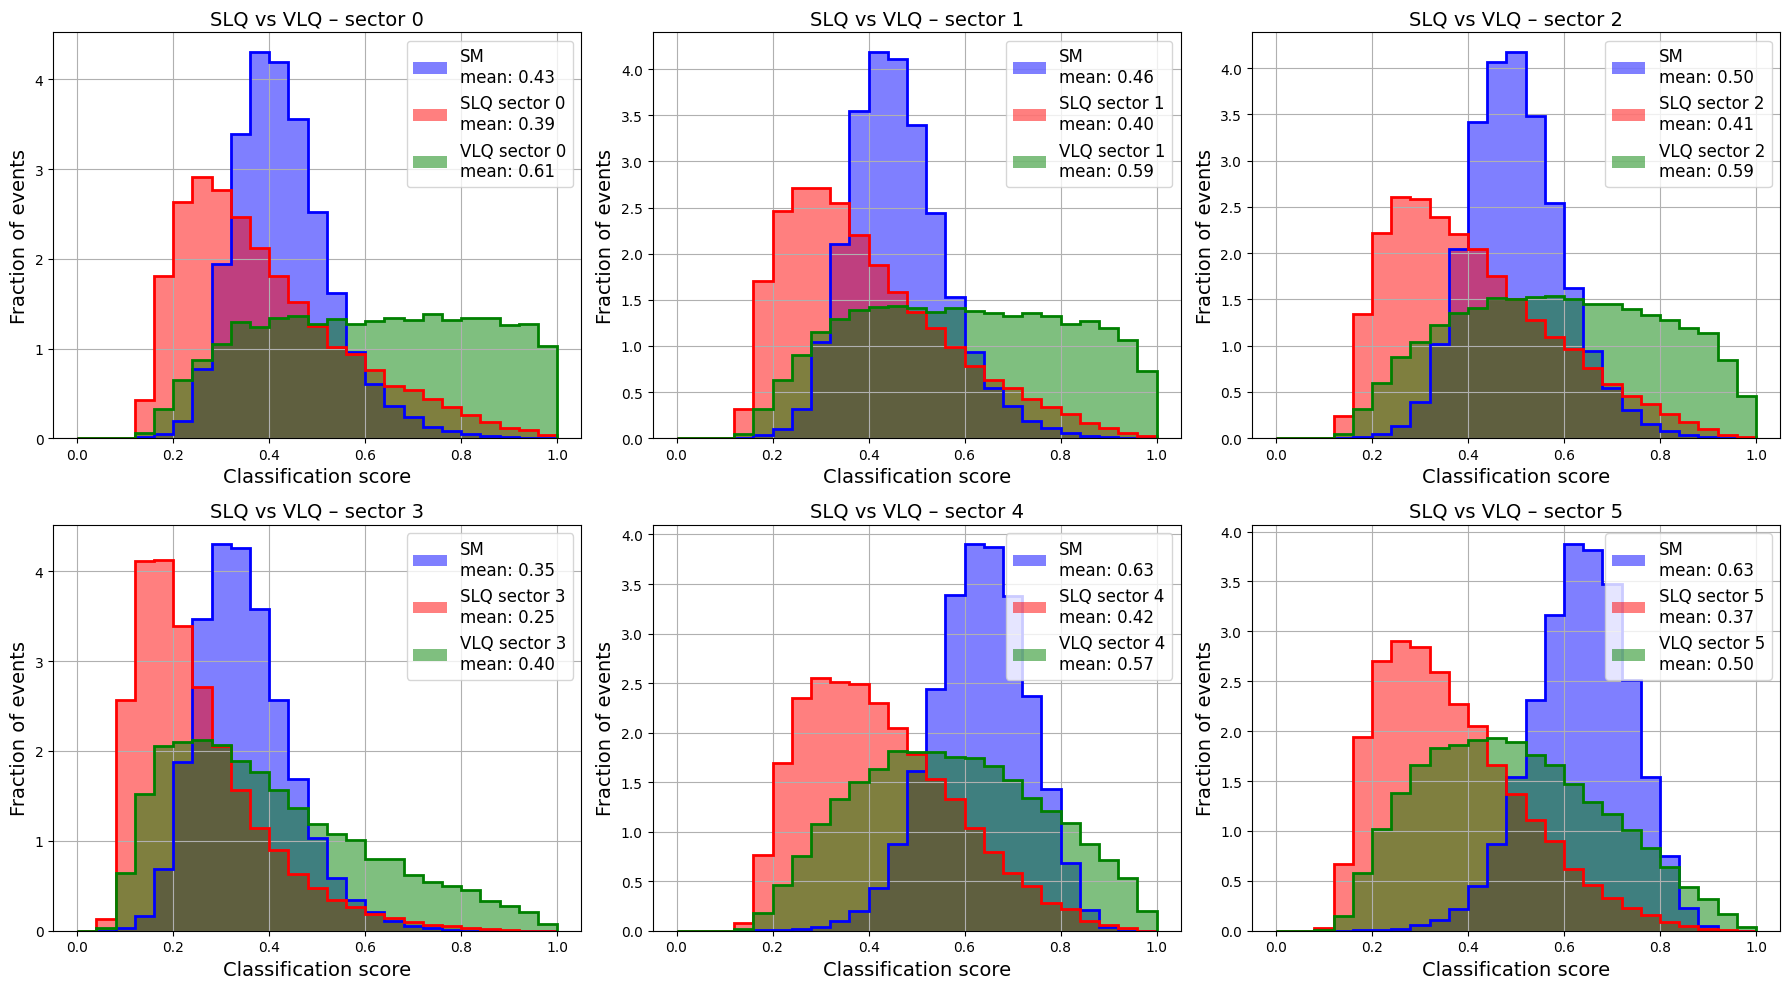

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# axes = axes.flatten()

for sector_id, pair_list in sectors.items():

    if sector_id < 3:
        ax = axes[0,sector_id]
    else:
        ax = axes[1,sector_id-3]

    # SM
    _, _, X_test_B, _ = split_SM
    sector_feature_B = np.full(len(X_test_B), sector_id)
    X_B_spin = np.column_stack([X_test_B, sector_feature_B])
    pred_B = classifier_spin.predict_proba(X_B_spin)[:,1]

    # -------- SLQ --------
    X_SLQ_sector = []

    for m_s, _ in pair_list:
        _, _, X_test_s, _ = split_SLQ[m_s]
        X_SLQ_sector.append(X_test_s)

    X_SLQ_sector = np.vstack(X_SLQ_sector)
    sector_feature_s = np.full(len(X_SLQ_sector), sector_id)
    X_s_spin = np.column_stack([X_SLQ_sector, sector_feature_s])
    pred_s = classifier_spin.predict_proba(X_s_spin)[:,1]


    # -------- VLQ --------
    X_VLQ_sector = []

    for _, m_v in pair_list:
        _, _, X_test_v, _ = split_VLQ[m_v]
        X_VLQ_sector.append(X_test_v)

    X_VLQ_sector = np.vstack(X_VLQ_sector)
    sector_feature_v = np.full(len(X_VLQ_sector), sector_id)
    X_v_spin = np.column_stack([X_VLQ_sector, sector_feature_v])
    pred_v = classifier_spin.predict_proba(X_v_spin)[:,1]


    # Histogramas
    ax.hist(pred_B, bins=25, range=(0,1), density=True, histtype='step', color='blue', linewidth=2)
    ax.hist(pred_s, bins=25, range=(0,1), density=True, histtype='step', color='red', linewidth=2)
    ax.hist(pred_v, bins=25, range=(0,1), density=True, histtype='step', color='green', linewidth=2)

    ax.hist(pred_B, bins=25, range=(0,1), density=True, color='blue', alpha=0.5, label=f'SM\nmean: {np.mean(pred_B):.2f}')
    ax.hist(pred_s, bins=25, range=(0,1), density=True, color='red', alpha=0.5, label=f'SLQ sector {sector_id}\nmean: {np.mean(pred_s):.2f}')
    ax.hist(pred_v, bins=25, range=(0,1), density=True, color='green', alpha=0.5, label=f'VLQ sector {sector_id}\nmean: {np.mean(pred_v):.2f}')

    ax.set_title(f'SLQ vs VLQ – sector {sector_id}', fontsize=14)
    ax.set_xlabel("Classification score", fontsize=14)
    ax.set_ylabel("Fraction of events", fontsize=14)
    ax.grid(True)
    ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

#### With mass reconstruction (regressor)

In [ ]:
split_SM = split_class(df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop']))
split_SLQ = {mass: split_class(df_SLQ_norm[mass].drop(columns=['mLQ1','mLQ2','mTop'])) for mass in df_SLQ_norm}
split_VLQ = {mass: split_class(df_VLQ_norm[mass].drop(columns=['mLQ1','mLQ2','mTop'])) for mass in df_VLQ_norm}

In [ ]:
sectors = {
    0: [(1200, 1600)],        # mucha señal
    1: [(1300, 1700)],
    2: [(1400, 1800)],
    3: [(1500, 1900)],
    4: [(1600, 2000)],        # señal intermedia
    5: [                      # señal baja
        (1700, 2100),
        (1800, 2200),
        (1900, 2300),
    ]
}

In [ ]:
X_train_list, y_train_list, sector_train_list = [], [], []
X_val_list,   y_val_list,   sector_val_list   = [], [], []
X_test_list,  y_test_list,  sector_test_list  = [], [], []

for sector_id, pair_list in sectors.items():

    for (m_s, m_v) in pair_list:

        # -------- SLQ --------
        X_train_s, X_val_s, X_test_s, _ = split_SLQ[m_s]

        X_train_list.append(X_train_s)
        y_train_list.append(np.zeros(len(X_train_s)))
        sector_train_list.append(np.full(len(X_train_s), sector_id))

        X_val_list.append(X_val_s)
        y_val_list.append(np.zeros(len(X_val_s)))
        sector_val_list.append(np.full(len(X_val_s), sector_id))

        X_test_list.append(X_test_s)
        y_test_list.append(np.zeros(len(X_test_s)))
        sector_test_list.append(np.full(len(X_test_s), sector_id))


        # -------- VLQ --------
        X_train_v, X_val_v, X_test_v, _ = split_VLQ[m_v]

        X_train_list.append(X_train_v)
        y_train_list.append(np.ones(len(X_train_v)))
        sector_train_list.append(np.full(len(X_train_v), sector_id))

        X_val_list.append(X_val_v)
        y_val_list.append(np.ones(len(X_val_v)))
        sector_val_list.append(np.full(len(X_val_v), sector_id))

        X_test_list.append(X_test_v)
        y_test_list.append(np.ones(len(X_test_v)))
        sector_test_list.append(np.full(len(X_test_v), sector_id))


# Concatenate
# TRAIN
X_train_spin = np.vstack(X_train_list)
y_train_spin = np.concatenate(y_train_list)
sector_train = np.concatenate(sector_train_list)

# add sector id as extra feature
X_train_spin = np.column_stack([X_train_spin, sector_train])


# VAL
X_val_spin = np.vstack(X_val_list)
y_val_spin = np.concatenate(y_val_list)
sector_val = np.concatenate(sector_val_list)

X_val_spin = np.column_stack([X_val_spin, sector_val])


# TEST
X_test_spin = np.vstack(X_test_list)
y_test_spin = np.concatenate(y_test_list)
sector_test = np.concatenate(sector_test_list)

X_test_spin = np.column_stack([X_test_spin, sector_test])

In [ ]:
classifier_spin = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=5,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50
)

classifier_spin.fit(
    X_train_spin, y_train_spin,
    eval_set=[(X_train_spin, y_train_spin),
              (X_val_spin, y_val_spin)],
    verbose=True
)

classifier_spin.save_model(mainfolder + "saved-models/xgb_spin_conditional_sector_massR.json")

[0]	validation_0-logloss:0.67466	validation_1-logloss:0.67527
[1]	validation_0-logloss:0.66394	validation_1-logloss:0.66511
[2]	validation_0-logloss:0.65506	validation_1-logloss:0.65677
[3]	validation_0-logloss:0.64767	validation_1-logloss:0.64980
[4]	validation_0-logloss:0.64148	validation_1-logloss:0.64407
[5]	validation_0-logloss:0.63622	validation_1-logloss:0.63920
[6]	validation_0-logloss:0.63165	validation_1-logloss:0.63504
[7]	validation_0-logloss:0.62782	validation_1-logloss:0.63155
[8]	validation_0-logloss:0.62459	validation_1-logloss:0.62860
[9]	validation_0-logloss:0.62187	validation_1-logloss:0.62616
[10]	validation_0-logloss:0.61926	validation_1-logloss:0.62386
[11]	validation_0-logloss:0.61701	validation_1-logloss:0.62188
[12]	validation_0-logloss:0.61488	validation_1-logloss:0.62001
[13]	validation_0-logloss:0.61310	validation_1-logloss:0.61840
[14]	validation_0-logloss:0.61149	validation_1-logloss:0.61698
[15]	validation_0-logloss:0.61013	validation_1-logloss:0.61578
[1

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4178/2259578190.py:28: SyntaxWarning: invalid escape sequence '\e'
  keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
/tmp/ipykernel_4178/2259578190.py:28: SyntaxWarning: invalid escape sequence '\p'
  keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
/tmp/ipykernel_4178/2259578190.py:29: SyntaxWarning: invalid escape sequence '\e'
  '$p_T(b_2)$','$\eta(b_2)$','$\phi(b_2)$',
/tmp/ipykernel_4178/2259578190.py:29: SyntaxWarning: invalid escape sequence '

Global AUC = 0.7476438434464279


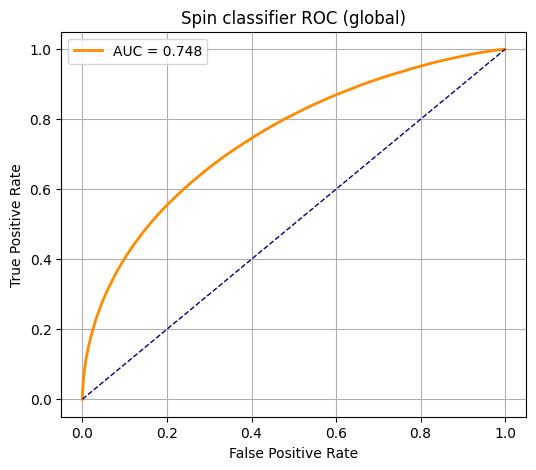

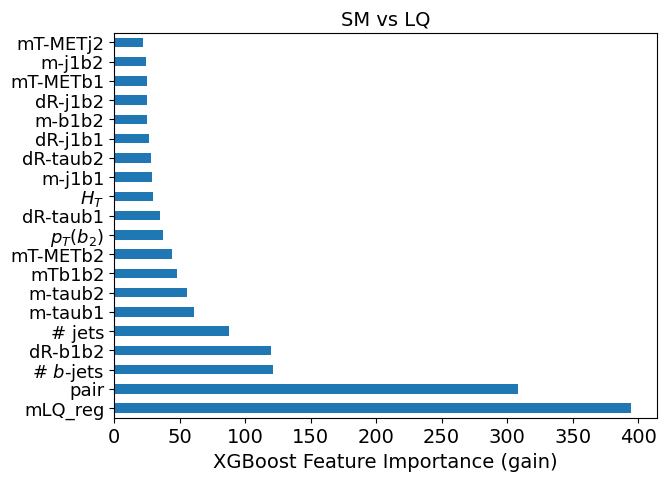

[47, 48, 13, 16, 12, 29, 30, 44, 40, 3, 14, 11, 32, 15, 17]


In [ ]:
# LOAD
classifier_spin = XGBClassifier()
classifier_spin.load_model(mainfolder + "saved-models/xgb_spin_conditional_sector_massR.json")


y_score = classifier_spin.predict_proba(X_test_spin)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test_spin, y_score)
roc_auc = roc_auc_score(y_test_spin, y_score)

print("Global AUC =", roc_auc)


plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Spin classifier ROC (global)")
plt.grid(True)
plt.legend()
plt.show()




keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
                 '$p_T(b_2)$','$\eta(b_2)$','$\phi(b_2)$',
                 r'$p_T(\tau)$',r'$\eta(\tau)$',r'$\phi(\tau)$',
                 '$E_T^{miss}$','$\phi(E_T^{miss})$',
                 '$H_T$','# jets','# $b$-jets',
                 'dR-taub1','dR-taub2','dR-b1b2',
                 'dR-j1b1','dR-j1b2','dR-j1tau',
                 'dR-j2b1','dR-j2b2','dR-j2tau',
                 'dR-j1j2',
#                  'dphi-taub1','dphi-taub2','dphi-b1b2',
                 'dphi-METb1','dphi-METb2','dphi-METtau',
                 'dphi-METj1','dphi-METj2',
                 'm-taub1','m-taub2','m-b1b2',
                 'm-j1b1','m-j1b2','m-j1tau',
                 'm-j2b1','m-j2b2','m-j2tau',
                 'm-j1j2',
                 'mT-METb1','mT-METb2','mT-METtau',
                 'mT-METj1','mT-METj2',
                 'mTb1b2','mTj1j2','sT',
                 'mLQ_reg','pair'])

feature_important = classifier_spin.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(20, columns="score").plot(kind='barh',figsize=(7,5)) ## plot top 20 features
plt.xticks(fontsize=14)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
plt.title(r'SM vs LQ', fontsize=14)
# plt.savefig('XG_feature_importance.pdf', bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

In [ ]:
sector_column = X_test_spin[:, -1]


# evaluate per sector
for sector_id in range(6):

    mask = sector_column == sector_id

    y_true_sector = y_test_spin[mask]
    y_score_sector = y_score[mask]

    fpr, tpr, _ = roc_curve(y_true_sector, y_score_sector)
    auc_sector = roc_auc_score(y_true_sector, y_score_sector)

    print(f"Sector {sector_id} AUC = {auc_sector:.5f}")



Sector 0 AUC = 0.77747
Sector 1 AUC = 0.76166
Sector 2 AUC = 0.74615
Sector 3 AUC = 0.73545
Sector 4 AUC = 0.72209
Sector 5 AUC = 0.70652


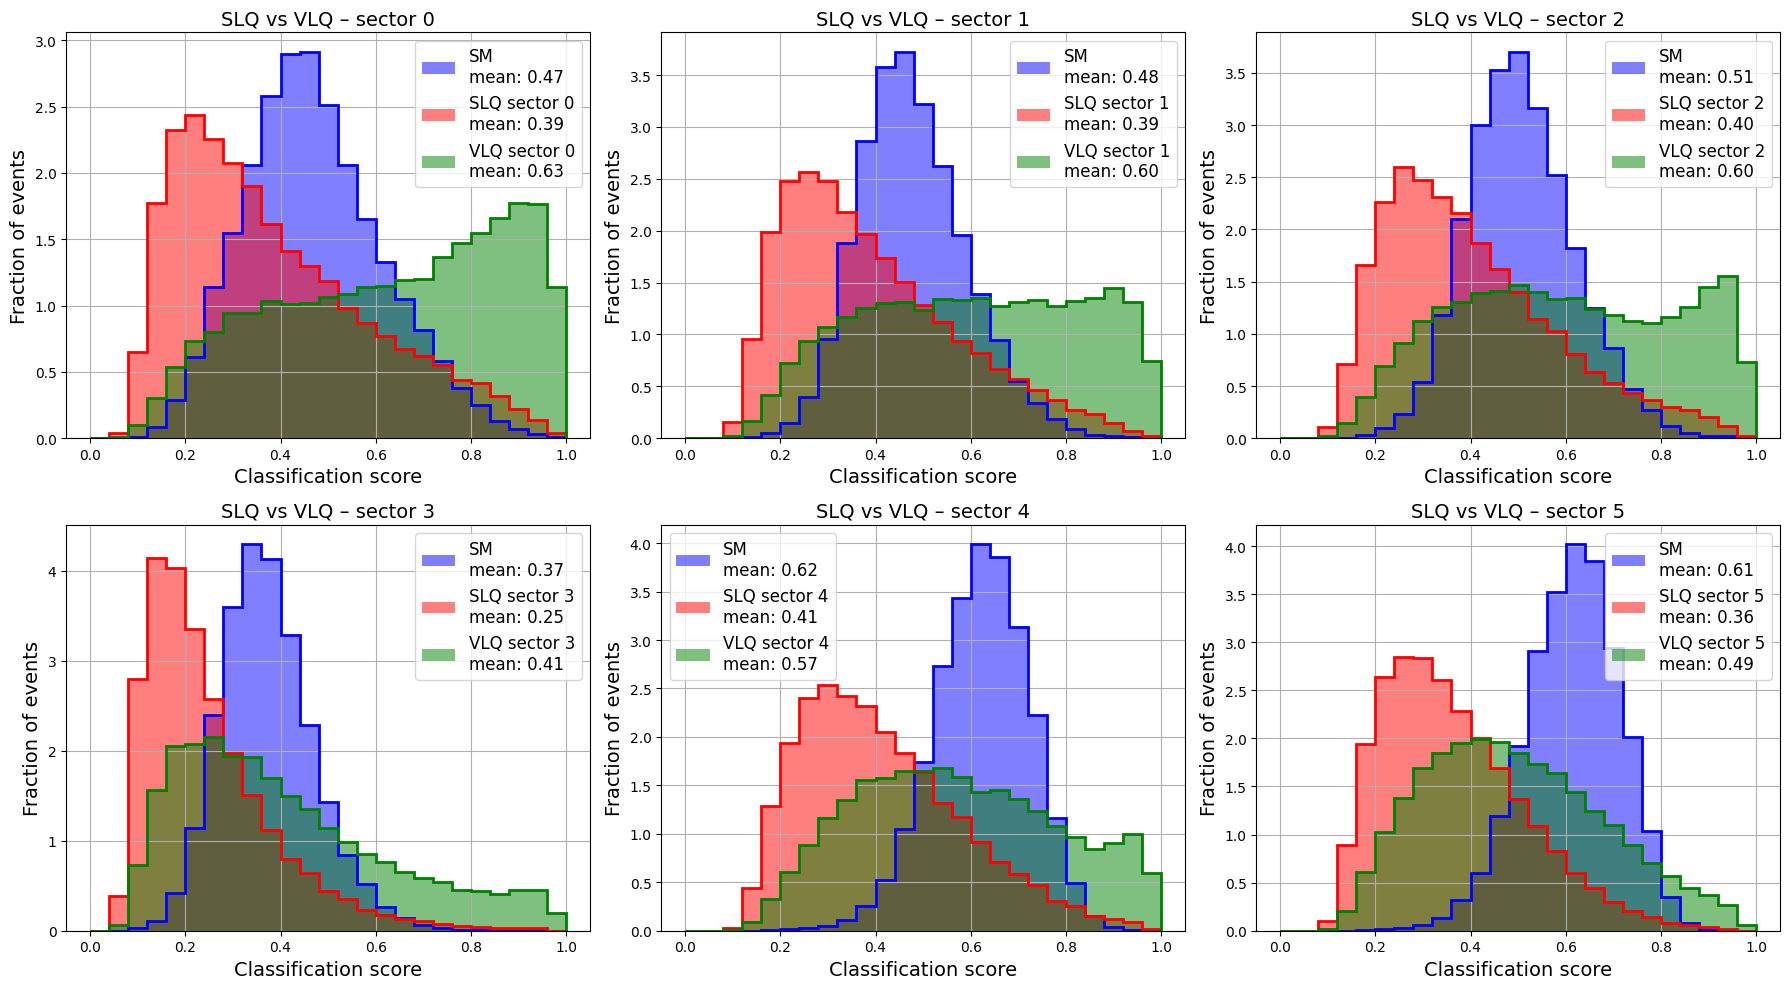

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# axes = axes.flatten()

for sector_id, pair_list in sectors.items():

    if sector_id < 3:
        ax = axes[0,sector_id]
    else:
        ax = axes[1,sector_id-3]

    # SM
    _, _, X_test_B, _ = split_SM
    sector_feature_B = np.full(len(X_test_B), sector_id)
    X_B_spin = np.column_stack([X_test_B, sector_feature_B])
    pred_B = classifier_spin.predict_proba(X_B_spin)[:,1]

    # -------- SLQ --------
    X_SLQ_sector = []

    for m_s, _ in pair_list:
        _, _, X_test_s, _ = split_SLQ[m_s]
        X_SLQ_sector.append(X_test_s)

    X_SLQ_sector = np.vstack(X_SLQ_sector)
    sector_feature_s = np.full(len(X_SLQ_sector), sector_id)
    X_s_spin = np.column_stack([X_SLQ_sector, sector_feature_s])
    pred_s = classifier_spin.predict_proba(X_s_spin)[:,1]


    # -------- VLQ --------
    X_VLQ_sector = []

    for _, m_v in pair_list:
        _, _, X_test_v, _ = split_VLQ[m_v]
        X_VLQ_sector.append(X_test_v)

    X_VLQ_sector = np.vstack(X_VLQ_sector)
    sector_feature_v = np.full(len(X_VLQ_sector), sector_id)
    X_v_spin = np.column_stack([X_VLQ_sector, sector_feature_v])
    pred_v = classifier_spin.predict_proba(X_v_spin)[:,1]


    # Histogramas
    ax.hist(pred_B, bins=25, range=(0,1), density=True, histtype='step', color='blue', linewidth=2)
    ax.hist(pred_s, bins=25, range=(0,1), density=True, histtype='step', color='red', linewidth=2)
    ax.hist(pred_v, bins=25, range=(0,1), density=True, histtype='step', color='green', linewidth=2)

    ax.hist(pred_B, bins=25, range=(0,1), density=True, color='blue', alpha=0.5, label=f'SM\nmean: {np.mean(pred_B):.2f}')
    ax.hist(pred_s, bins=25, range=(0,1), density=True, color='red', alpha=0.5, label=f'SLQ sector {sector_id}\nmean: {np.mean(pred_s):.2f}')
    ax.hist(pred_v, bins=25, range=(0,1), density=True, color='green', alpha=0.5, label=f'VLQ sector {sector_id}\nmean: {np.mean(pred_v):.2f}')

    ax.set_title(f'SLQ vs VLQ – sector {sector_id}', fontsize=14)
    ax.set_xlabel("Classification score", fontsize=14)
    ax.set_ylabel("Fraction of events", fontsize=14)
    ax.grid(True)
    ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

#### With all

In [ ]:
split_SM = split_class(df_SM_norm)
split_SLQ = {mass: split_class(df_SLQ_norm[mass]) for mass in df_SLQ_norm}
split_VLQ = {mass: split_class(df_VLQ_norm[mass]) for mass in df_VLQ_norm}

In [ ]:
sectors = {
    0: [(1200, 1600)],        # mucha señal
    1: [(1300, 1700)],
    2: [(1400, 1800)],
    3: [(1500, 1900)],
    4: [(1600, 2000)],        # señal intermedia
    5: [                      # señal baja
        (1700, 2100),
        (1800, 2200),
        (1900, 2300),
    ]
}

In [ ]:
X_train_list, y_train_list, sector_train_list = [], [], []
X_val_list,   y_val_list,   sector_val_list   = [], [], []
X_test_list,  y_test_list,  sector_test_list  = [], [], []

for sector_id, pair_list in sectors.items():

    for (m_s, m_v) in pair_list:

        # -------- SLQ --------
        X_train_s, X_val_s, X_test_s, _ = split_SLQ[m_s]

        X_train_list.append(X_train_s)
        y_train_list.append(np.zeros(len(X_train_s)))
        sector_train_list.append(np.full(len(X_train_s), sector_id))

        X_val_list.append(X_val_s)
        y_val_list.append(np.zeros(len(X_val_s)))
        sector_val_list.append(np.full(len(X_val_s), sector_id))

        X_test_list.append(X_test_s)
        y_test_list.append(np.zeros(len(X_test_s)))
        sector_test_list.append(np.full(len(X_test_s), sector_id))


        # -------- VLQ --------
        X_train_v, X_val_v, X_test_v, _ = split_VLQ[m_v]

        X_train_list.append(X_train_v)
        y_train_list.append(np.ones(len(X_train_v)))
        sector_train_list.append(np.full(len(X_train_v), sector_id))

        X_val_list.append(X_val_v)
        y_val_list.append(np.ones(len(X_val_v)))
        sector_val_list.append(np.full(len(X_val_v), sector_id))

        X_test_list.append(X_test_v)
        y_test_list.append(np.ones(len(X_test_v)))
        sector_test_list.append(np.full(len(X_test_v), sector_id))


# Concatenate
# TRAIN
X_train_spin = np.vstack(X_train_list)
y_train_spin = np.concatenate(y_train_list)
sector_train = np.concatenate(sector_train_list)

# add sector id as extra feature
X_train_spin = np.column_stack([X_train_spin, sector_train])


# VAL
X_val_spin = np.vstack(X_val_list)
y_val_spin = np.concatenate(y_val_list)
sector_val = np.concatenate(sector_val_list)

X_val_spin = np.column_stack([X_val_spin, sector_val])


# TEST
X_test_spin = np.vstack(X_test_list)
y_test_spin = np.concatenate(y_test_list)
sector_test = np.concatenate(sector_test_list)

X_test_spin = np.column_stack([X_test_spin, sector_test])

In [ ]:
classifier_spin = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=5,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50
)

classifier_spin.fit(
    X_train_spin, y_train_spin,
    eval_set=[(X_train_spin, y_train_spin),
              (X_val_spin, y_val_spin)],
    verbose=True
)

classifier_spin.save_model(mainfolder + "saved-models/xgb_spin_conditional_sector_massKR.json")

[0]	validation_0-logloss:0.67464	validation_1-logloss:0.67524
[1]	validation_0-logloss:0.66389	validation_1-logloss:0.66505
[2]	validation_0-logloss:0.65500	validation_1-logloss:0.65668
[3]	validation_0-logloss:0.64759	validation_1-logloss:0.64971
[4]	validation_0-logloss:0.64138	validation_1-logloss:0.64394
[5]	validation_0-logloss:0.63608	validation_1-logloss:0.63906
[6]	validation_0-logloss:0.63153	validation_1-logloss:0.63487
[7]	validation_0-logloss:0.62796	validation_1-logloss:0.63161
[8]	validation_0-logloss:0.62459	validation_1-logloss:0.62856
[9]	validation_0-logloss:0.62182	validation_1-logloss:0.62603
[10]	validation_0-logloss:0.61906	validation_1-logloss:0.62357
[11]	validation_0-logloss:0.61691	validation_1-logloss:0.62169
[12]	validation_0-logloss:0.61485	validation_1-logloss:0.61984
[13]	validation_0-logloss:0.61292	validation_1-logloss:0.61812
[14]	validation_0-logloss:0.61117	validation_1-logloss:0.61661
[15]	validation_0-logloss:0.60965	validation_1-logloss:0.61530
[1

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_43487/2575020329.py:28: SyntaxWarning: invalid escape sequence '\e'
  keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
/tmp/ipykernel_43487/2575020329.py:28: SyntaxWarning: invalid escape sequence '\p'
  keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
/tmp/ipykernel_43487/2575020329.py:29: SyntaxWarning: invalid escape sequence '\e'
  '$p_T(b_2)$','$\eta(b_2)$','$\phi(b_2)$',
/tmp/ipykernel_43487/2575020329.py:29: SyntaxWarning: invalid escape sequen

Global AUC = 0.747811831179137


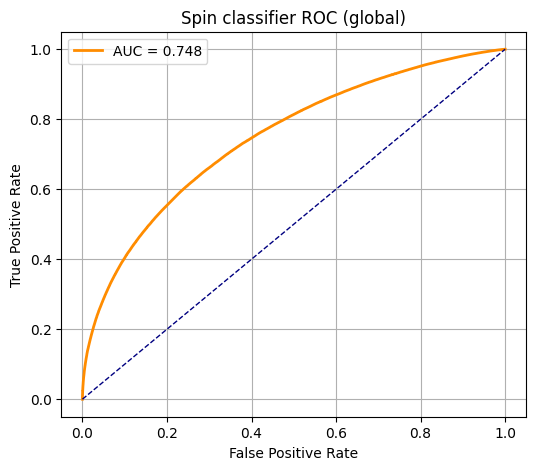

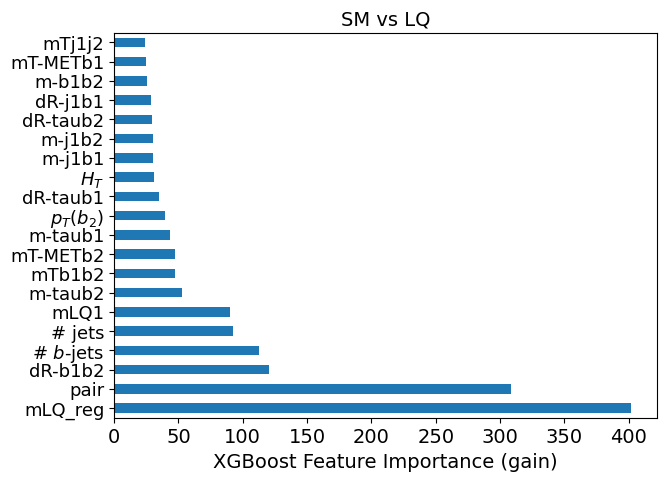

[50, 51, 16, 13, 12, 47, 30, 44, 40, 29, 3, 14, 11, 32, 33]


In [ ]:
# LOAD
classifier_spin = XGBClassifier()
classifier_spin.load_model(mainfolder + "saved-models/xgb_spin_conditional_sector_massKR.json")


y_score = classifier_spin.predict_proba(X_test_spin)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test_spin, y_score)
roc_auc = roc_auc_score(y_test_spin, y_score)

print("Global AUC =", roc_auc)


plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Spin classifier ROC (global)")
plt.grid(True)
plt.legend()
plt.show()




keys = np.array(['$p_T(b_1)$','$\eta(b_1)$','$\phi(b_1)$',
                 '$p_T(b_2)$','$\eta(b_2)$','$\phi(b_2)$',
                 r'$p_T(\tau)$',r'$\eta(\tau)$',r'$\phi(\tau)$',
                 '$E_T^{miss}$','$\phi(E_T^{miss})$',
                 '$H_T$','# jets','# $b$-jets',
                 'dR-taub1','dR-taub2','dR-b1b2',
                 'dR-j1b1','dR-j1b2','dR-j1tau',
                 'dR-j2b1','dR-j2b2','dR-j2tau',
                 'dR-j1j2',
#                  'dphi-taub1','dphi-taub2','dphi-b1b2',
                 'dphi-METb1','dphi-METb2','dphi-METtau',
                 'dphi-METj1','dphi-METj2',
                 'm-taub1','m-taub2','m-b1b2',
                 'm-j1b1','m-j1b2','m-j1tau',
                 'm-j2b1','m-j2b2','m-j2tau',
                 'm-j1j2',
                 'mT-METb1','mT-METb2','mT-METtau',
                 'mT-METj1','mT-METj2',
                 'mTb1b2','mTj1j2','sT',
                 'mLQ1','mLQ2','mTop',
                 'mLQ_reg','pair'])

feature_important = classifier_spin.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(20, columns="score").plot(kind='barh',figsize=(7,5)) ## plot top 20 features
plt.xticks(fontsize=14)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
plt.title(r'SM vs LQ', fontsize=14)
# plt.savefig('XG_feature_importance.pdf', bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

In [ ]:
sector_column = X_test_spin[:, -1]


# evaluate per sector
for sector_id in range(6):

    mask = sector_column == sector_id

    y_true_sector = y_test_spin[mask]
    y_score_sector = y_score[mask]

    fpr, tpr, _ = roc_curve(y_true_sector, y_score_sector)
    auc_sector = roc_auc_score(y_true_sector, y_score_sector)

    print(f"Sector {sector_id} AUC = {auc_sector:.5f}")



Sector 0 AUC = 0.77759
Sector 1 AUC = 0.76197
Sector 2 AUC = 0.74687
Sector 3 AUC = 0.73519
Sector 4 AUC = 0.72258
Sector 5 AUC = 0.70652


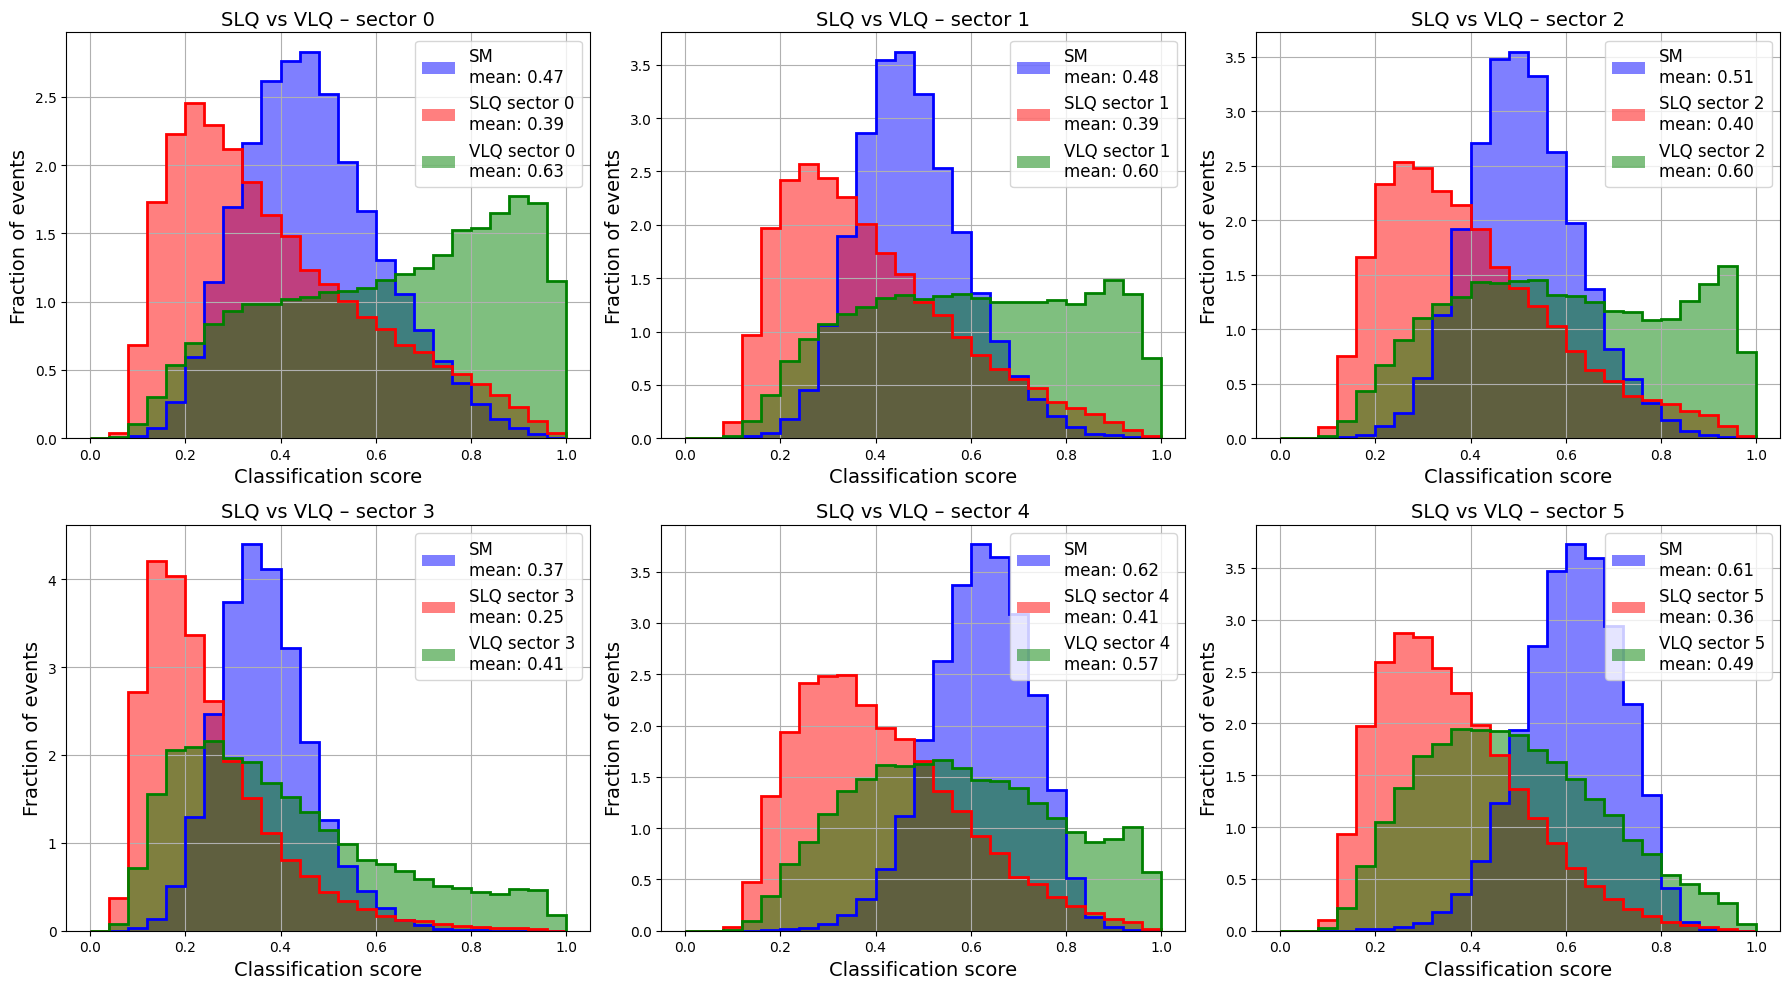

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# axes = axes.flatten()

for sector_id, pair_list in sectors.items():

    if sector_id < 3:
        ax = axes[0,sector_id]
    else:
        ax = axes[1,sector_id-3]

    # SM
    _, _, X_test_B, _ = split_SM
    sector_feature_B = np.full(len(X_test_B), sector_id)
    X_B_spin = np.column_stack([X_test_B, sector_feature_B])
    pred_B = classifier_spin.predict_proba(X_B_spin)[:,1]

    # -------- SLQ --------
    X_SLQ_sector = []

    for m_s, _ in pair_list:
        _, _, X_test_s, _ = split_SLQ[m_s]
        X_SLQ_sector.append(X_test_s)

    X_SLQ_sector = np.vstack(X_SLQ_sector)
    sector_feature_s = np.full(len(X_SLQ_sector), sector_id)
    X_s_spin = np.column_stack([X_SLQ_sector, sector_feature_s])
    pred_s = classifier_spin.predict_proba(X_s_spin)[:,1]


    # -------- VLQ --------
    X_VLQ_sector = []

    for _, m_v in pair_list:
        _, _, X_test_v, _ = split_VLQ[m_v]
        X_VLQ_sector.append(X_test_v)

    X_VLQ_sector = np.vstack(X_VLQ_sector)
    sector_feature_v = np.full(len(X_VLQ_sector), sector_id)
    X_v_spin = np.column_stack([X_VLQ_sector, sector_feature_v])
    pred_v = classifier_spin.predict_proba(X_v_spin)[:,1]


    # Histogramas
    ax.hist(pred_B, bins=25, range=(0,1), density=True, histtype='step', color='blue', linewidth=2)
    ax.hist(pred_s, bins=25, range=(0,1), density=True, histtype='step', color='red', linewidth=2)
    ax.hist(pred_v, bins=25, range=(0,1), density=True, histtype='step', color='green', linewidth=2)

    ax.hist(pred_B, bins=25, range=(0,1), density=True, color='blue', alpha=0.5, label=f'SM\nmean: {np.mean(pred_B):.2f}')
    ax.hist(pred_s, bins=25, range=(0,1), density=True, color='red', alpha=0.5, label=f'SLQ sector {sector_id}\nmean: {np.mean(pred_s):.2f}')
    ax.hist(pred_v, bins=25, range=(0,1), density=True, color='green', alpha=0.5, label=f'VLQ sector {sector_id}\nmean: {np.mean(pred_v):.2f}')

    ax.set_title(f'SLQ vs VLQ – sector {sector_id}', fontsize=14)
    ax.set_xlabel("Classification score", fontsize=14)
    ax.set_ylabel("Fraction of events", fontsize=14)
    ax.grid(True)
    ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

#### Only sT

In [ ]:
split_SM = split_class(pd.DataFrame(df_SM_norm['sT']))
split_SLQ = {mass: split_class(pd.DataFrame(df_SLQ_norm[mass]['sT'])) for mass in df_SLQ_norm}
split_VLQ = {mass: split_class(pd.DataFrame(df_VLQ_norm[mass]['sT'])) for mass in df_VLQ_norm}

In [ ]:
sectors = {
    0: [(1200, 1600)],        # mucha señal
    1: [(1300, 1700)],
    2: [(1400, 1800)],
    3: [(1500, 1900)],
    4: [(1600, 2000)],        # señal intermedia
    5: [                      # señal baja
        (1700, 2100),
        (1800, 2200),
        (1900, 2300),
    ]
}

In [ ]:
X_train_list, y_train_list, sector_train_list = [], [], []
X_val_list,   y_val_list,   sector_val_list   = [], [], []
X_test_list,  y_test_list,  sector_test_list  = [], [], []

for sector_id, pair_list in sectors.items():

    for (m_s, m_v) in pair_list:

        # -------- SLQ --------
        X_train_s, X_val_s, X_test_s, _ = split_SLQ[m_s]

        X_train_list.append(X_train_s)
        y_train_list.append(np.zeros(len(X_train_s)))
        sector_train_list.append(np.full(len(X_train_s), sector_id))

        X_val_list.append(X_val_s)
        y_val_list.append(np.zeros(len(X_val_s)))
        sector_val_list.append(np.full(len(X_val_s), sector_id))

        X_test_list.append(X_test_s)
        y_test_list.append(np.zeros(len(X_test_s)))
        sector_test_list.append(np.full(len(X_test_s), sector_id))


        # -------- VLQ --------
        X_train_v, X_val_v, X_test_v, _ = split_VLQ[m_v]

        X_train_list.append(X_train_v)
        y_train_list.append(np.ones(len(X_train_v)))
        sector_train_list.append(np.full(len(X_train_v), sector_id))

        X_val_list.append(X_val_v)
        y_val_list.append(np.ones(len(X_val_v)))
        sector_val_list.append(np.full(len(X_val_v), sector_id))

        X_test_list.append(X_test_v)
        y_test_list.append(np.ones(len(X_test_v)))
        sector_test_list.append(np.full(len(X_test_v), sector_id))


# Concatenate
# TRAIN
X_train_spin = np.vstack(X_train_list)
y_train_spin = np.concatenate(y_train_list)
sector_train = np.concatenate(sector_train_list)

# add sector id as extra feature
X_train_spin = np.column_stack([X_train_spin, sector_train])


# VAL
X_val_spin = np.vstack(X_val_list)
y_val_spin = np.concatenate(y_val_list)
sector_val = np.concatenate(sector_val_list)

X_val_spin = np.column_stack([X_val_spin, sector_val])


# TEST
X_test_spin = np.vstack(X_test_list)
y_test_spin = np.concatenate(y_test_list)
sector_test = np.concatenate(sector_test_list)

X_test_spin = np.column_stack([X_test_spin, sector_test])

In [ ]:
classifier_spin = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.1,
    max_depth=5,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50
)

classifier_spin.fit(
    X_train_spin, y_train_spin,
    eval_set=[(X_train_spin, y_train_spin),
              (X_val_spin, y_val_spin)],
    verbose=True
)

classifier_spin.save_model(mainfolder + "saved-models/xgb_spin_conditional_sector_sT.json")

[0]	validation_0-logloss:0.68141	validation_1-logloss:0.68151
[1]	validation_0-logloss:0.67633	validation_1-logloss:0.67652
[2]	validation_0-logloss:0.67220	validation_1-logloss:0.67245
[3]	validation_0-logloss:0.66882	validation_1-logloss:0.66914
[4]	validation_0-logloss:0.66607	validation_1-logloss:0.66643
[5]	validation_0-logloss:0.66378	validation_1-logloss:0.66418
[6]	validation_0-logloss:0.66187	validation_1-logloss:0.66232
[7]	validation_0-logloss:0.66030	validation_1-logloss:0.66078
[8]	validation_0-logloss:0.65899	validation_1-logloss:0.65950
[9]	validation_0-logloss:0.65790	validation_1-logloss:0.65844
[10]	validation_0-logloss:0.65699	validation_1-logloss:0.65755
[11]	validation_0-logloss:0.65626	validation_1-logloss:0.65685
[12]	validation_0-logloss:0.65565	validation_1-logloss:0.65626
[13]	validation_0-logloss:0.65513	validation_1-logloss:0.65575
[14]	validation_0-logloss:0.65471	validation_1-logloss:0.65534
[15]	validation_0-logloss:0.65435	validation_1-logloss:0.65499
[1

Global AUC = 0.6399780424811511


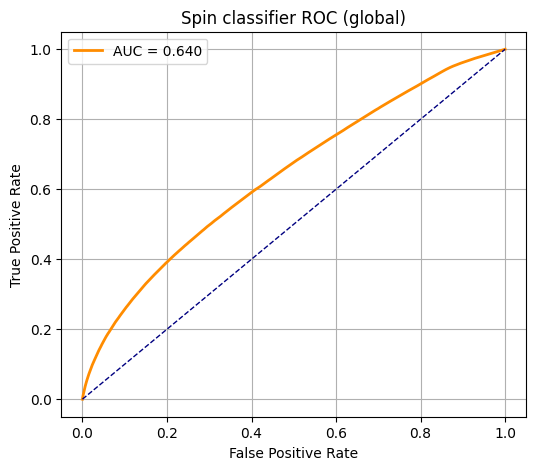

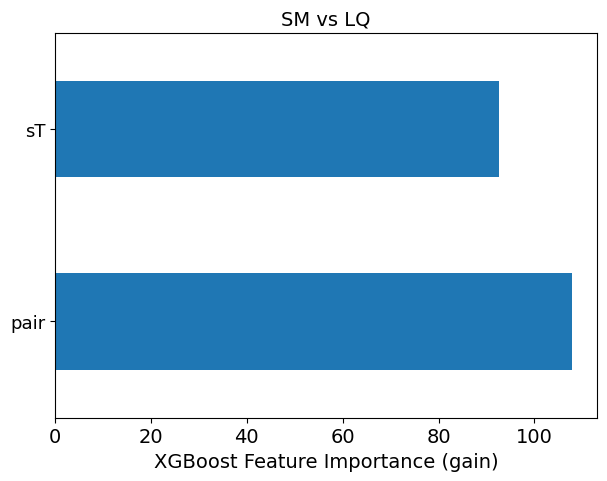

[1, 0]


In [ ]:
# LOAD
classifier_spin = XGBClassifier()
classifier_spin.load_model(mainfolder + "saved-models/xgb_spin_conditional_sector_sT.json")


y_score = classifier_spin.predict_proba(X_test_spin)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test_spin, y_score)
roc_auc = roc_auc_score(y_test_spin, y_score)

print("Global AUC =", roc_auc)


plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Spin classifier ROC (global)")
plt.grid(True)
plt.legend()
plt.show()




keys = np.array(['sT','pair'])

feature_important = classifier_spin.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(20, columns="score").plot(kind='barh',figsize=(7,5)) ## plot top 20 features
plt.xticks(fontsize=14)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
plt.title(r'SM vs LQ', fontsize=14)
# plt.savefig('XG_feature_importance.pdf', bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

In [ ]:
sector_column = X_test_spin[:, -1]


# evaluate per sector
for sector_id in range(6):

    mask = sector_column == sector_id

    y_true_sector = y_test_spin[mask]
    y_score_sector = y_score[mask]

    fpr, tpr, _ = roc_curve(y_true_sector, y_score_sector)
    auc_sector = roc_auc_score(y_true_sector, y_score_sector)

    print(f"Sector {sector_id} AUC = {auc_sector:.5f}")



Sector 0 AUC = 0.67007
Sector 1 AUC = 0.64407
Sector 2 AUC = 0.62304
Sector 3 AUC = 0.60450
Sector 4 AUC = 0.59073
Sector 5 AUC = 0.57421


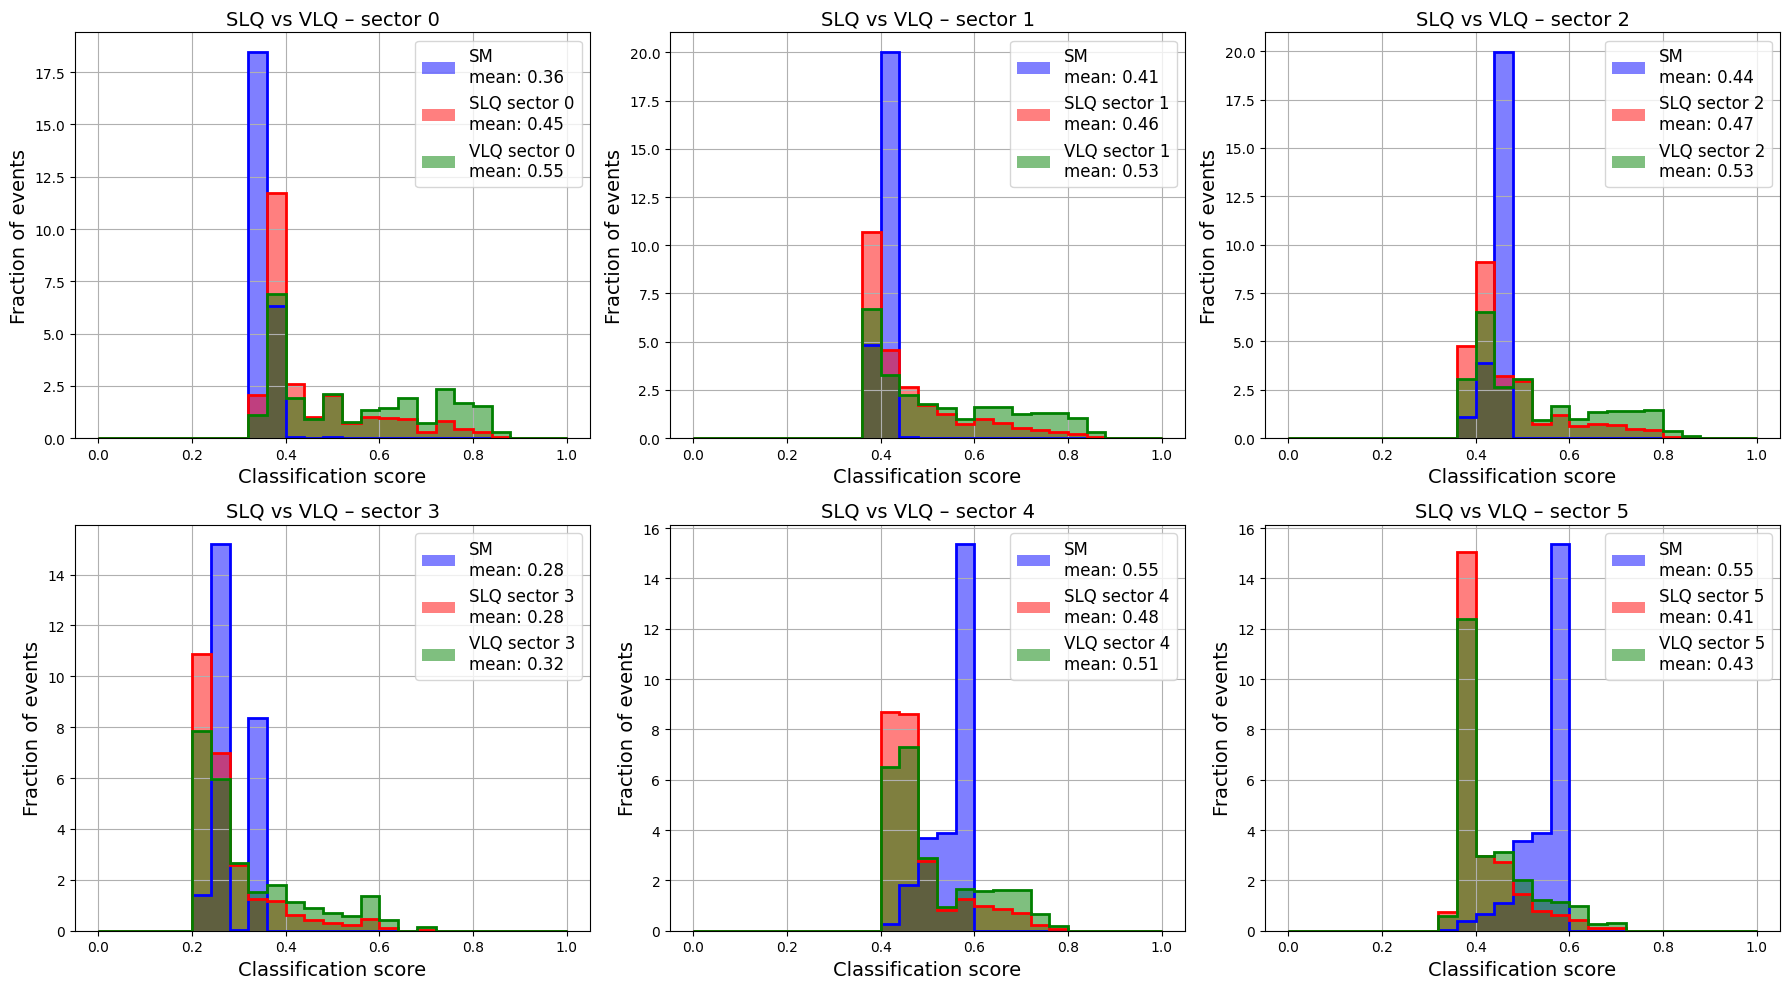

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# axes = axes.flatten()

for sector_id, pair_list in sectors.items():

    if sector_id < 3:
        ax = axes[0,sector_id]
    else:
        ax = axes[1,sector_id-3]

    # SM
    _, _, X_test_B, _ = split_SM
    sector_feature_B = np.full(len(X_test_B), sector_id)
    X_B_spin = np.column_stack([X_test_B, sector_feature_B])
    pred_B = classifier_spin.predict_proba(X_B_spin)[:,1]

    # -------- SLQ --------
    X_SLQ_sector = []

    for m_s, _ in pair_list:
        _, _, X_test_s, _ = split_SLQ[m_s]
        X_SLQ_sector.append(X_test_s)

    X_SLQ_sector = np.vstack(X_SLQ_sector)
    sector_feature_s = np.full(len(X_SLQ_sector), sector_id)
    X_s_spin = np.column_stack([X_SLQ_sector, sector_feature_s])
    pred_s = classifier_spin.predict_proba(X_s_spin)[:,1]


    # -------- VLQ --------
    X_VLQ_sector = []

    for _, m_v in pair_list:
        _, _, X_test_v, _ = split_VLQ[m_v]
        X_VLQ_sector.append(X_test_v)

    X_VLQ_sector = np.vstack(X_VLQ_sector)
    sector_feature_v = np.full(len(X_VLQ_sector), sector_id)
    X_v_spin = np.column_stack([X_VLQ_sector, sector_feature_v])
    pred_v = classifier_spin.predict_proba(X_v_spin)[:,1]


    # Histogramas
    ax.hist(pred_B, bins=25, range=(0,1), density=True, histtype='step', color='blue', linewidth=2)
    ax.hist(pred_s, bins=25, range=(0,1), density=True, histtype='step', color='red', linewidth=2)
    ax.hist(pred_v, bins=25, range=(0,1), density=True, histtype='step', color='green', linewidth=2)

    ax.hist(pred_B, bins=25, range=(0,1), density=True, color='blue', alpha=0.5, label=f'SM\nmean: {np.mean(pred_B):.2f}')
    ax.hist(pred_s, bins=25, range=(0,1), density=True, color='red', alpha=0.5, label=f'SLQ sector {sector_id}\nmean: {np.mean(pred_s):.2f}')
    ax.hist(pred_v, bins=25, range=(0,1), density=True, color='green', alpha=0.5, label=f'VLQ sector {sector_id}\nmean: {np.mean(pred_v):.2f}')

    ax.set_title(f'SLQ vs VLQ – sector {sector_id}', fontsize=14)
    ax.set_xlabel("Classification score", fontsize=14)
    ax.set_ylabel("Fraction of events", fontsize=14)
    ax.grid(True)
    ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

# JOIN BOTH ML

### With only the reconstructed mass (regressor)

#### SM vs LQ

In [ ]:
# --- 1. Combinar todos los LQ en un solo DataFrame ---
df_LQ_list = list(df_SLQ_norm.values()) + list(df_VLQ_norm.values())
df_LQ_norm = pd.concat(df_LQ_list, ignore_index=True)


# --- 2. Igualar número de eventos con SM ---
n_SM = len(df_SM_norm)
n_LQ = len(df_LQ_norm)
n_events = min(n_SM, n_LQ)

df_SM_sample = (df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop'])).sample(n=n_events, random_state=42)
df_LQ_sample = (df_LQ_norm.drop(columns=['mLQ1','mLQ2','mTop'])).sample(n=n_events, random_state=42)


# --- 3. Crear X, y ---
X = pd.concat([df_SM_sample, df_LQ_sample], ignore_index=True)
y = np.hstack([np.zeros(n_events), np.ones(n_events)])  # 0=SM, 1=LQ

# --- 4. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)



# LOAD
xgb_clf = XGBClassifier()
xgb_clf.load_model(mainfolder + "saved-models/xgboost_SMLQ_2026_massR.json")


In [ ]:

y_pred_test = xgb_clf.predict_proba( X_test )[:,1]

B_expected:  45962
S_expected:  137

Best Threshold: 0.9800
Best Significancia: 9.0304

B_expected (after cut): 114.2542
S_expected (after cut): 109.3265


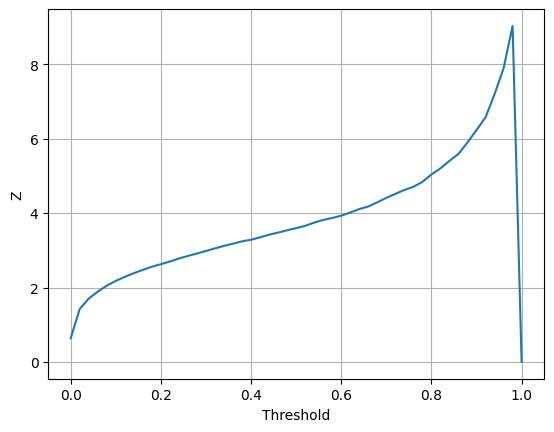

In [ ]:
B_expected = 45962
S_expected = 137   # this is m_SLQ = 1500 GeV

# in the dataset
num_S = np.sum(y_test == 1)
num_B = np.sum(y_test == 0)

# weights
w_S = S_expected / num_S
w_B = B_expected / num_B


def find_optimal_threshold(y_true, y_scores, signal_weight, background_weight):
    """
    Encuentra el threshold que maximiza S/sqrt(B).
    - y_true: Etiquetas reales (1 para señal, 0 para fondo).
    - y_scores: Probabilidades o scores del clasificador.
    """
    # 1. posibles thresholds
    thresholds = np.linspace(0, 1, 51)

    best_sig = -1
    best_threshold = 0
    best_S = 0
    best_B = 0

    # Listas para graficar
    significances = []

    for t in thresholds:
        # Eventos que pasan el corte
        s_pass = np.sum((y_scores >= t) & (y_true == 1)) * signal_weight
        b_pass = np.sum((y_scores >= t) & (y_true == 0)) * background_weight

        # Evitar división por cero
        if b_pass > 0:
            # sig = s_pass / np.sqrt(b_pass)
            sig=np.sqrt(2* ((s_pass+b_pass)*np.log(1 + s_pass/b_pass) - s_pass) )
            # sig=s_pass/b_pass
        else:
            sig = 0

        significances.append(sig)

        if sig > best_sig:
            best_sig = sig
            best_threshold = t
            best_S = s_pass
            best_B = b_pass

    return best_threshold, best_sig, best_S, best_B, thresholds, significances


opt_t, max_s, S_cut, B_cut, t_list, s_list = find_optimal_threshold(y_test, y_pred_test, w_S ,w_B)

print("B_expected: ", B_expected)
print("S_expected: ", S_expected)
print(f"\nBest Threshold: {opt_t:.4f}")
print(f"Best Significancia: {max_s:.4f}")
print(f"\nB_expected (after cut): {B_cut:.4f}")
print(f"S_expected (after cut): {S_cut:.4f}")


plt.plot(t_list, s_list)
plt.xlabel('Threshold')
plt.ylabel('Z')
plt.grid(True)
plt.show()

#### SLQ vs VLQ

In [ ]:
df_SLQ_norm[1300] = df_SLQ_rest_norm[1300]
df_SLQ_norm[1500] = df_SLQ_rest_norm[1500]
df_SLQ_norm[1700] = df_SLQ_rest_norm[1700]
df_SLQ_norm[1900] = df_SLQ_rest_norm[1900]

df_VLQ_norm[1700] = df_VLQ_rest_norm[1700]
df_VLQ_norm[1900] = df_VLQ_rest_norm[1900]
df_VLQ_norm[2100] = df_VLQ_rest_norm[2100]
df_VLQ_norm[2300] = df_VLQ_rest_norm[2300]

In [ ]:
split_SM = split_class(df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop']))
split_SLQ = {mass: split_class(df_SLQ_norm[mass].drop(columns=['mLQ1','mLQ2','mTop'])) for mass in df_SLQ_norm}
split_VLQ = {mass: split_class(df_VLQ_norm[mass].drop(columns=['mLQ1','mLQ2','mTop'])) for mass in df_VLQ_norm}

sectors = {
    0: [(1200, 1600)],        # mucha señal
    1: [(1300, 1700)],
    2: [(1400, 1800)],
    3: [(1500, 1900)],
    4: [(1600, 2000)],        # señal intermedia
    5: [                      # señal baja
        (1700, 2100),
        (1800, 2200),
        (1900, 2300),
    ]
}



X_train_list, y_train_list, sector_train_list = [], [], []
X_val_list,   y_val_list,   sector_val_list   = [], [], []
X_test_list,  y_test_list,  sector_test_list  = [], [], []

for sector_id, pair_list in sectors.items():

    for (m_s, m_v) in pair_list:

        # -------- SLQ --------
        X_train_s, X_val_s, X_test_s, _ = split_SLQ[m_s]

        X_train_list.append(X_train_s)
        y_train_list.append(np.zeros(len(X_train_s)))
        sector_train_list.append(np.full(len(X_train_s), sector_id))

        X_val_list.append(X_val_s)
        y_val_list.append(np.zeros(len(X_val_s)))
        sector_val_list.append(np.full(len(X_val_s), sector_id))

        X_test_list.append(X_test_s)
        y_test_list.append(np.zeros(len(X_test_s)))
        sector_test_list.append(np.full(len(X_test_s), sector_id))


        # -------- VLQ --------
        X_train_v, X_val_v, X_test_v, _ = split_VLQ[m_v]

        X_train_list.append(X_train_v)
        y_train_list.append(np.ones(len(X_train_v)))
        sector_train_list.append(np.full(len(X_train_v), sector_id))

        X_val_list.append(X_val_v)
        y_val_list.append(np.ones(len(X_val_v)))
        sector_val_list.append(np.full(len(X_val_v), sector_id))

        X_test_list.append(X_test_v)
        y_test_list.append(np.ones(len(X_test_v)))
        sector_test_list.append(np.full(len(X_test_v), sector_id))


# Concatenate
# TRAIN
X_train_spin = np.vstack(X_train_list)
y_train_spin = np.concatenate(y_train_list)
sector_train = np.concatenate(sector_train_list)

# add sector id as extra feature
X_train_spin = np.column_stack([X_train_spin, sector_train])


# VAL
X_val_spin = np.vstack(X_val_list)
y_val_spin = np.concatenate(y_val_list)
sector_val = np.concatenate(sector_val_list)

X_val_spin = np.column_stack([X_val_spin, sector_val])


# TEST
X_test_spin = np.vstack(X_test_list)
y_test_spin = np.concatenate(y_test_list)
sector_test = np.concatenate(sector_test_list)

X_test_spin = np.column_stack([X_test_spin, sector_test])



# LOAD
classifier_spin = XGBClassifier()
classifier_spin.load_model(mainfolder + "saved-models/xgb_spin_conditional_sector_massR.json")

In [ ]:
# ALL THE MASSES

df_SLQ_norm_all = {}
df_SLQ_norm_all[1200] = df_SLQ_norm[1200]
df_SLQ_norm_all[1300] = df_SLQ_rest_norm[1300]
df_SLQ_norm_all[1400] = df_SLQ_norm[1400]
df_SLQ_norm_all[1500] = df_SLQ_rest_norm[1500]
df_SLQ_norm_all[1600] = df_SLQ_norm[1600]
df_SLQ_norm_all[1700] = df_SLQ_rest_norm[1700]
df_SLQ_norm_all[1800] = df_SLQ_norm[1800]
df_SLQ_norm_all[1900] = df_SLQ_rest_norm[1900]

df_VLQ_norm_all = {}
df_VLQ_norm_all[1600] = df_VLQ_norm[1600]
df_VLQ_norm_all[1700] = df_VLQ_rest_norm[1700]
df_VLQ_norm_all[1800] = df_VLQ_norm[1800]
df_VLQ_norm_all[1900] = df_VLQ_rest_norm[1900]
df_VLQ_norm_all[2000] = df_VLQ_norm[2000]
df_VLQ_norm_all[2100] = df_VLQ_rest_norm[2100]
df_VLQ_norm_all[2200] = df_VLQ_norm[2200]
df_VLQ_norm_all[2300] = df_VLQ_rest_norm[2300]

In [ ]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM = xgb_clf.predict_proba( df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop']) )[:,1]

scoresA_SLQ = {}
scoresA_VLQ = {}

for m in df_SLQ_norm_all:
    scoresA_SLQ[m] = xgb_clf.predict_proba( df_SLQ_norm_all[m].drop(columns=['mLQ1','mLQ2','mTop']) )[:,1]

for m in df_VLQ_norm_all:
    scoresA_VLQ[m] = xgb_clf.predict_proba( df_VLQ_norm_all[m].drop(columns=['mLQ1','mLQ2','mTop']) )[:,1]

In [ ]:
# --- Clasificador B: SLQ vs VLQ ---

sectors = {
    0: [(1200, 1600)],        # mucha señal
    1: [(1300, 1700)],
    2: [(1400, 1800)],
    3: [(1500, 1900)],
    4: [(1600, 2000)],        # señal intermedia
    5: [                      # señal baja
        (1700, 2100),
        (1800, 2200),
        (1900, 2300),
    ]
}

X_sm = df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop'])
sector_id_ran = np.array([random.randint(0, len(sectors)-1) for i in range(len(X_sm))])

X_sm = np.column_stack([X_sm, sector_id_ran])

scoresB_SM = classifier_spin.predict_proba(X_sm)[:,1]

scoresB_SLQ = {}
scoresB_VLQ = {}

for sector_id, pair_list in sectors.items():

    for (m_s, m_v) in pair_list:

        X_s = df_SLQ_norm_all[m_s].drop(columns=['mLQ1','mLQ2','mTop']).values
        X_v = df_VLQ_norm_all[m_v].drop(columns=['mLQ1','mLQ2','mTop']).values

        X_s = np.column_stack([X_s, np.full(len(X_s), sector_id)])
        X_v = np.column_stack([X_v, np.full(len(X_v), sector_id)])

        scoresB_SLQ[m_s] = classifier_spin.predict_proba(X_s)[:,1]
        scoresB_VLQ[m_v] = classifier_spin.predict_proba(X_v)[:,1]

In [ ]:
# --- Juntar los scores del clasificador A y B

events_SM = np.column_stack([scoresA_SM, scoresB_SM])

events_SLQ = {}
for m in scoresA_SLQ:
    events_SLQ[m] = np.column_stack([scoresA_SLQ[m], scoresB_SLQ[m]])

events_VLQ = {}
for m in scoresA_VLQ:
    events_VLQ[m] = np.column_stack([scoresA_VLQ[m], scoresB_VLQ[m]])

#### Define the test statistic

In [ ]:
def compute_test_statistic(scoresA, scoresB, threshold):
    """
    T = Sum log (P(VLQ) / P(SLQ))

    P(VLQ) = score SLQ vs VLQ classifier
    P(SLQ) = 1 - score SLQ vs VLQ classifier
    """

    mask = scoresA > threshold

    scoresB_sel = scoresB[mask]

    if len(scoresB_sel) == 0:
        return 0

    eps = 1e-6
    s = np.clip(scoresB_sel, eps, 1-eps)

    T = np.sum(np.log(s/(1-s)))

    return T

#### An example

In [ ]:
B_expected = 45962
S_expected = 137   # this is m_SLQ = 1500 GeV


threshold_A = 0.95

n_pseudo = 5000

##### Assuming SLQ is true

In [ ]:
T_SLQ = []

for i in range(n_pseudo):

    N_B = np.random.poisson(B_expected)
    N_S = np.random.poisson(S_expected)

    # sample background
    sample_B = events_SM[np.random.randint(len(events_SM), size=N_B)]

    # sample signal
    mass = 1500
    sample_S = events_SLQ[mass][np.random.randint(len(events_SLQ[mass]), size=N_S)]


    sample_all = np.vstack([sample_B, sample_S])

    scoresA = sample_all[:,0]
    scoresB = sample_all[:,1]

    T = compute_test_statistic(scoresA, scoresB, threshold_A)

    T_SLQ.append(T)

##### Assuming VLQ is true

In [ ]:
T_VLQ = []

for i in range(n_pseudo):

    N_B = np.random.poisson(B_expected)
    N_S = np.random.poisson(S_expected)

    # sample background
    sample_B = events_SM[np.random.randint(len(events_SM), size=N_B)]

    # sample signal
    mass = 1900
    sample_S = events_VLQ[mass][np.random.randint(len(events_VLQ[mass]), size=N_S)]


    sample_all = np.vstack([sample_B, sample_S])

    scoresA = sample_all[:,0]
    scoresB = sample_all[:,1]

    T = compute_test_statistic(scoresA, scoresB, threshold_A)

    T_VLQ.append(T)

##### Z

Z distribuciones (gaussianas) = 4.1289167
mean(T_SLQ) = -185.09337
mean(T_VLQ) = -74.794235


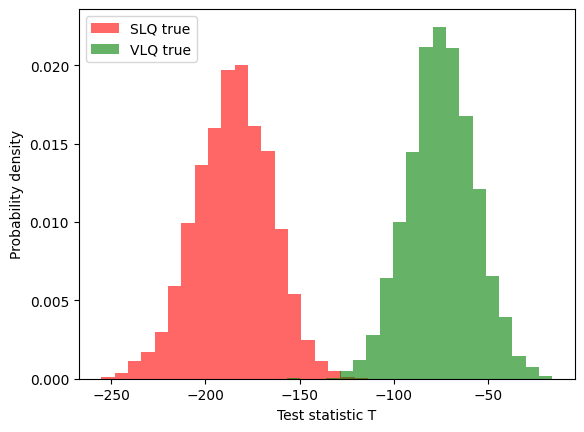

In [ ]:
mu_S = np.mean(T_SLQ)
mu_V = np.mean(T_VLQ)

sigma_S = np.std(T_SLQ)
sigma_V = np.std(T_VLQ)

Z = abs(mu_V - mu_S) / np.sqrt(sigma_S**2 + sigma_V**2)

print("Z distribuciones (gaussianas) =", Z)

print('mean(T_SLQ) =', mu_S)
print('mean(T_VLQ) =', mu_V)

plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label="SLQ true")
plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label="VLQ true")

plt.xlabel("Test statistic T")
plt.ylabel("Probability density")
plt.legend()
plt.show()

T observed = -117.25877
mean(T_SLQ) = -185.09337
mean(T_VLQ) = -74.794235

Pseudo experimento compatible con VLQ
Z wrt SLQ = 3.39644
Z wrt VLQ = -2.393606


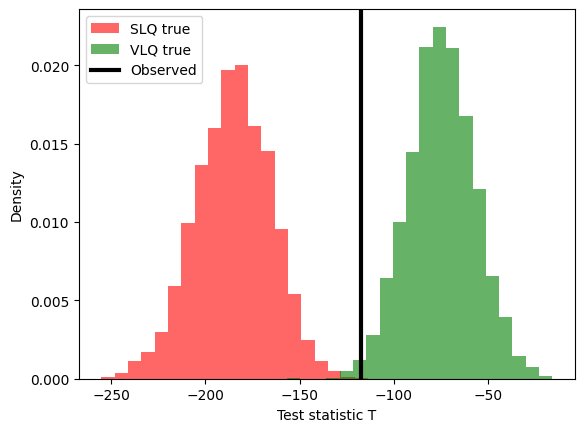

In [ ]:
N_B = np.random.poisson(B_expected)
N_S = np.random.poisson(S_expected)

mass = 1900
sample_B = events_SM[np.random.randint(len(events_SM), size=N_B)]
sample_S = events_VLQ[mass][np.random.randint(len(events_VLQ[mass]), size=N_S)]

sample_all = np.vstack([sample_B, sample_S])

scoresA = sample_all[:,0]
scoresB = sample_all[:,1]

T_obs = compute_test_statistic(scoresA, scoresB, threshold_A)

print("T observed =", T_obs)
print('mean(T_SLQ) =', mu_S)
print('mean(T_VLQ) =', mu_V)

print('')
if abs(T_obs - mu_S) < abs(T_obs - mu_V):
    print("Pseudo experimento compatible con SLQ")
else:
    print("Pseudo experimento compatible con VLQ")


Z_SLQ = (T_obs - mu_S) / sigma_S
Z_VLQ = (T_obs - mu_V) / sigma_V

print("Z wrt SLQ =", Z_SLQ)
print("Z wrt VLQ =", Z_VLQ)


plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label="SLQ true")
plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label="VLQ true")

plt.axvline(T_obs, color='black', lw=3, label="Observed")

plt.xlabel("Test statistic T")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
p_SLQ = np.mean(np.array(T_SLQ) >= T_obs)
p_VLQ = np.mean(np.array(T_VLQ) <= T_obs)

print("p-value SLQ =", p_SLQ)
print("p-value VLQ =", p_VLQ)

p-value SLQ = 0.0002
p-value VLQ = 0.0076


In [ ]:
print('Two-tailed') # Probability of a result more extreme in either direction.
print( "p-value SLQ =", 2 * stats.norm.sf(abs(Z_SLQ)) )
print( "p-value VLQ =", 2 * stats.norm.sf(abs(Z_VLQ)) )

print('\nRight-tailed') # Probability of a result greater than tobs
print( "p-value SLQ =", stats.norm.sf(Z_SLQ) )
print( "p-value VLQ =", stats.norm.sf(Z_VLQ) )

print('\nLeft-tailed') # Probability of a result less than tobs
print( "p-value SLQ =", stats.norm.cdf(Z_SLQ) )
print( "p-value VLQ =", stats.norm.cdf(Z_VLQ) )

Two-tailed
p-value SLQ = 0.0006826851519307243
p-value VLQ = 0.016683662145840647

Right-tailed
p-value SLQ = 0.00034134257596536217
p-value VLQ = 0.9916581689270797

Left-tailed
p-value SLQ = 0.9996586574240346
p-value VLQ = 0.008341831072920323


In [ ]:
print('We will use the two-tailed')
print('\n Two-tailed    p=0.05 (0.025 per side)     -> 95% C.L.   -> Z=1.96')
print('\n One-tailed    p=0.05 (0.05 just one side) -> 95% C.L.   -> Z=1.645')

We will use the two-tailed

 Two-tailed    p=0.05 (0.025 per side)     -> 95% C.L.   -> Z=1.96

 One-tailed    p=0.05 (0.05 just one side) -> 95% C.L.   -> Z=1.645


### super loop

In [ ]:
def compute_test_statistic(scoresA, scoresB, threshold):
    """
    T = Sum log (P(VLQ) / P(SLQ))

    P(VLQ) = score SLQ vs VLQ classifier
    P(SLQ) = 1 - score SLQ vs VLQ classifier
    """

    mask = scoresA > threshold

    scoresB_sel = scoresB[mask]

    if len(scoresB_sel) == 0:
        return 0

    eps = 1e-6
    s = np.clip(scoresB_sel, eps, 1-eps)

    T = np.sum(np.log(s/(1-s)))

    return T

In [ ]:
# funcion para generar pseudo experimentos (da los scores de ambos clasificadores para ese pseudo)

def generate_pseudo(events_B, events_S, N_B, N_S):

    sample_B = events_B[np.random.randint(len(events_B), size=N_B)]
    sample_S = events_S[np.random.randint(len(events_S), size=N_S)]

    sample_all = np.vstack([sample_B, sample_S])

    scoresA = sample_all[:,0]
    scoresB = sample_all[:,1]

    return scoresA, scoresB

In [ ]:
B_expected = 45962

mass_list_SLQ = [1200,1300,1400,1500,1600,1700,1800,1900]
mass_list_VLQ = [1600,1700,1800,1900,2000,2100,2200,2300]

S_expected = [round(fid_xsec_SLQ_14TeV(mmm, 0.5) * Lum) for mmm in mass_list_SLQ]
S_expected_VLQ = [round(fid_xsec_VLQ_14TeV(mmm, 0.5) * Lum) for mmm in mass_list_VLQ]

print('B_expected: ', B_expected)
print('S_expected: ', S_expected)

B_expected:  45962
S_expected:  [742, 419, 237, 137, 80, 46, 27, 16]


#### Distribution of the statistic with only SLQ and only VLQ

In [ ]:
# para saber que par de masas tiene cada sector
mass_to_sector = {}

for sector_id, pairs in sectors.items():
    for m_s, m_v in pairs:
        mass_to_sector[m_s] = sector_id
        mass_to_sector[m_v] = sector_id

In [ ]:
n_pseudo_TRUE = 1000
threshold_A = 0.95
# S_expected = [137]

In [ ]:
mu_S = []
mu_V = []

sigma_S = []
sigma_V = []

for S_exp in S_expected:

    print("\n==========================")
    print("S_expected =", S_exp)

    # dado un S, le asigna la masa (del SLQ) correspondiente
    mass_SLQ = mass_list_SLQ[S_expected.index(S_exp)]
    mass_VLQ = mass_list_VLQ[S_expected.index(S_exp)]
    print("mass_SLQ =", mass_SLQ, " GeV")
    print("mass_VLQ =", mass_VLQ, " GeV")

    # Con esa masa se fija en que sector cae (clasificador B)
    sector = mass_to_sector[mass]


    # computamos el T statistic para todos los pseudo
    T_SLQ = []
    T_VLQ = []

    for i in range(n_pseudo_TRUE):

        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_exp)

        scoresA, scoresB = generate_pseudo( events_SM, events_SLQ[mass_SLQ], N_B, N_S )

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_SLQ.append(T)


        scoresA, scoresB = generate_pseudo( events_SM, events_VLQ[mass_VLQ], N_B, N_S )

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_VLQ.append(T)

        # Compute the Z of the distributions
    mu_S.append( np.mean(T_SLQ) )
    mu_V.append( np.mean(T_VLQ) )

    sigma_S.append( np.std(T_SLQ) )
    sigma_V.append( np.std(T_VLQ) )

print(mu_S)
print(mu_V)

print(sigma_S)
print(sigma_V)


S_expected = 742
mass_SLQ = 1200  GeV
mass_VLQ = 1600  GeV

S_expected = 419
mass_SLQ = 1300  GeV
mass_VLQ = 1700  GeV

S_expected = 237
mass_SLQ = 1400  GeV
mass_VLQ = 1800  GeV

S_expected = 137
mass_SLQ = 1500  GeV
mass_VLQ = 1900  GeV

S_expected = 80
mass_SLQ = 1600  GeV
mass_VLQ = 2000  GeV

S_expected = 46
mass_SLQ = 1700  GeV
mass_VLQ = 2100  GeV

S_expected = 27
mass_SLQ = 1800  GeV
mass_VLQ = 2200  GeV

S_expected = 16
mass_SLQ = 1900  GeV
mass_VLQ = 2300  GeV
[np.float32(-340.054), np.float32(-199.63907), np.float32(-125.95436), np.float32(-185.92589), np.float32(-63.545197), np.float32(-62.398514), np.float32(-47.710705), np.float32(-38.949883)]
[np.float32(534.72437), np.float32(218.62253), np.float32(104.16332), np.float32(-73.84245), np.float32(0.9050159), np.float32(-35.405624), np.float32(-31.191343), np.float32(-30.58761)]
[np.float32(30.449415), np.float32(22.112347), np.float32(18.123835), np.float32(19.867136), np.float32(14.009963), np.float32(13.050301), np.floa

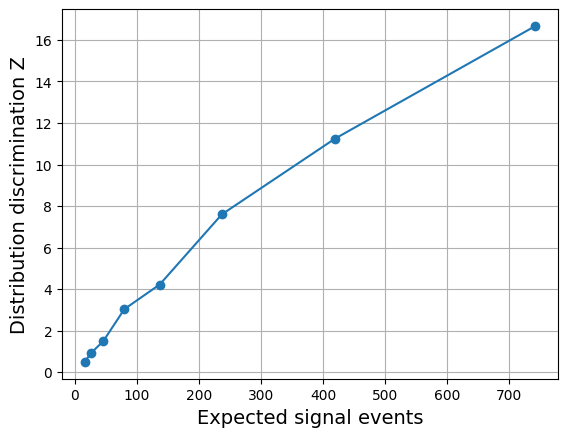

 Z:        1.96
 S:        56.48298799942909
 m_SLQ:    1669.1676823546204  [GeV]
 m_VLQ:    2069.1676823546204  [GeV]



/tmp/ipykernel_1363/14050817.py:28: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mSLQ_threshold = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1600)[0]
/tmp/ipykernel_1363/14050817.py:29: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mVLQ_threshold = fsolve(lambda x: f_results_Z_mVLQ(x) - Z_threshold,1600)[0]


In [ ]:
Z_threshold = 1.96

results_Z_gauss = []

for pair_it in range(len(mu_S)):
    Z = abs(mu_V[pair_it] - mu_S[pair_it]) / np.sqrt(sigma_S[pair_it]**2 + sigma_V[pair_it]**2)

    results_Z_gauss.append(Z)


plt.plot(S_expected, results_Z_gauss, marker='o')

plt.xlabel("Expected signal events", fontsize=14)
plt.ylabel("Distribution discrimination Z", fontsize=14)

plt.grid()
plt.show()


#  interpolate
f_results_Z = interp1d(S_expected, results_Z_gauss, kind='linear', fill_value="extrapolate")
f_results_Z_mSLQ = interp1d(mass_list_SLQ, results_Z_gauss, kind='linear', fill_value="extrapolate")
f_results_Z_mVLQ = interp1d(mass_list_VLQ, results_Z_gauss, kind='linear', fill_value="extrapolate")


# find the S or the mass such that we get Z_threshold
S_threshold = fsolve(lambda x: f_results_Z(x) - Z_threshold,100)[0]
mSLQ_threshold = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1600)[0]
mVLQ_threshold = fsolve(lambda x: f_results_Z_mVLQ(x) - Z_threshold,1600)[0]

print(' Z:       ', Z_threshold)
print(' S:       ', S_threshold)
print(' m_SLQ:   ', mSLQ_threshold, ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold, ' [GeV]\n')

In [ ]:
# ALL THE MASSES

df_SLQ_norm_all = {}
df_SLQ_norm_all[1200] = df_SLQ_norm[1200]
df_SLQ_norm_all[1300] = df_SLQ_rest_norm[1300]
df_SLQ_norm_all[1400] = df_SLQ_norm[1400]
df_SLQ_norm_all[1500] = df_SLQ_rest_norm[1500]
df_SLQ_norm_all[1600] = df_SLQ_norm[1600]
df_SLQ_norm_all[1700] = df_SLQ_rest_norm[1700]
df_SLQ_norm_all[1800] = df_SLQ_norm[1800]
df_SLQ_norm_all[1900] = df_SLQ_rest_norm[1900]

df_VLQ_norm_all = {}
df_VLQ_norm_all[1600] = df_VLQ_norm[1600]
df_VLQ_norm_all[1700] = df_VLQ_rest_norm[1700]
df_VLQ_norm_all[1800] = df_VLQ_norm[1800]
df_VLQ_norm_all[1900] = df_VLQ_rest_norm[1900]
df_VLQ_norm_all[2000] = df_VLQ_norm[2000]
df_VLQ_norm_all[2100] = df_VLQ_rest_norm[2100]
df_VLQ_norm_all[2200] = df_VLQ_norm[2200]
df_VLQ_norm_all[2300] = df_VLQ_rest_norm[2300]

In [ ]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM = xgb_clf.predict_proba( df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop']) )[:,1]

scoresA_SLQ = {}
scoresA_VLQ = {}

for m in df_SLQ_norm_all:
    scoresA_SLQ[m] = xgb_clf.predict_proba( df_SLQ_norm_all[m].drop(columns=['mLQ1','mLQ2','mTop']) )[:,1]

for m in df_VLQ_norm_all:
    scoresA_VLQ[m] = xgb_clf.predict_proba( df_VLQ_norm_all[m].drop(columns=['mLQ1','mLQ2','mTop']) )[:,1]

In [ ]:
# --- Clasificador B: SLQ vs VLQ ---

sectors = {
    0: [(1200, 1600)],        # mucha señal
    1: [(1300, 1700)],
    2: [(1400, 1800)],
    3: [(1500, 1900)],
    4: [(1600, 2000)],        # señal intermedia
    5: [                      # señal baja
        (1700, 2100),
        (1800, 2200),
        (1900, 2300),
    ]
}

X_sm = df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop'])
sector_id_ran = np.array([random.randint(0, len(sectors)-1) for i in range(len(X_sm))])

X_sm = np.column_stack([X_sm, sector_id_ran])

scoresB_SM = classifier_spin.predict_proba(X_sm)[:,1]


# scoresB_SLQ = {}
# scoresB_VLQ = {}

# for sector_id, pair_list in sectors.items():
#     for (m_s, m_v) in pair_list:

#         X_s = df_SLQ_norm_all[m_s].drop(columns=['mLQ1','mLQ2','mTop']).values
#         X_v = df_VLQ_norm_all[m_v].drop(columns=['mLQ1','mLQ2','mTop']).values

#         X_s_sec = np.column_stack([X_s, np.full(len(X_s), sector_id)])
#         X_v_sec = np.column_stack([X_v, np.full(len(X_v), sector_id)])

#         scoresB_SLQ[(m_s, sector_id)] = classifier_spin.predict_proba(X_s_sec)[:,1]
#         scoresB_VLQ[(m_v, sector_id)] = classifier_spin.predict_proba(X_v_sec)[:,1]



all_sectors = list(sectors.keys())

# --- SLQ ---
for m in df_SLQ_norm_all:

    X_s = df_SLQ_norm_all[m].drop(columns=['mLQ1','mLQ2','mTop']).values

    for sector_id in all_sectors:

        X_s_sec = np.column_stack([X_s, np.full(len(X_s), sector_id)])

        scoresB_SLQ[(m, sector_id)] = classifier_spin.predict_proba(X_s_sec)[:,1]


# --- VLQ ---
for m in df_VLQ_norm_all:

    X_v = df_VLQ_norm_all[m].drop(columns=['mLQ1','mLQ2','mTop']).values

    for sector_id in all_sectors:

        X_v_sec = np.column_stack([X_v, np.full(len(X_v), sector_id)])

        scoresB_VLQ[(m, sector_id)] = classifier_spin.predict_proba(X_v_sec)[:,1]

In [ ]:
# --- Juntar los scores del clasificador A y B

# events_SM = np.column_stack([scoresA_SM, scoresB_SM])

# events_SLQ = {}
# for m in scoresA_SLQ:
#     events_SLQ[m] = np.column_stack([scoresA_SLQ[m], scoresB_SLQ[m]])


# events_VLQ = {}
# for m in scoresA_VLQ:
#     events_VLQ[m] = np.column_stack([scoresA_VLQ[m], scoresB_VLQ[m]])

events_SM = {
        "scoresA": scoresA_SM,
        "scoresB": scoresB_SM
}

events_SLQ = {
    m: {
        "scoresA": scoresA_SLQ[m],
        "scoresB": {
            sector: scoresB_SLQ[(m, sector)]
            for sector in all_sectors
        }
    }
    for m in scoresA_SLQ
}


events_VLQ = {
    m: {
        "scoresA": scoresA_VLQ[m],
        "scoresB": {
            sector: scoresB_VLQ[(m, sector)]
            for sector in all_sectors
        }
    }
    for m in scoresA_VLQ
}

#### To compute S_expected for each pseudo using the 1st classifier

In [ ]:
# --- Clasificador A: SM vs LQ ---
# output of all the background events (already done)
# scoresA_SM = xgb_clf.predict_proba( df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop']) )[:,1]

# output of all the signal events
scoresA_S = xgb_clf.predict_proba( df_LQ_norm.drop(columns=['mLQ1','mLQ2','mTop']) )[:, 1]

In [ ]:
bins = np.linspace(0, 1, 30)

# normalized histograms of pure signal and pure background
hist_B, _ = np.histogram(scoresA_SM, bins=bins, density=True)
hist_S, _ = np.histogram(scoresA_S, bins=bins, density=True)


bin_width = bins[1] - bins[0]

pS = hist_S * bin_width
pB = hist_B * bin_width


S_expected = 742
mass_SLQ = 1200  GeV
mass_VLQ = 1600  GeV


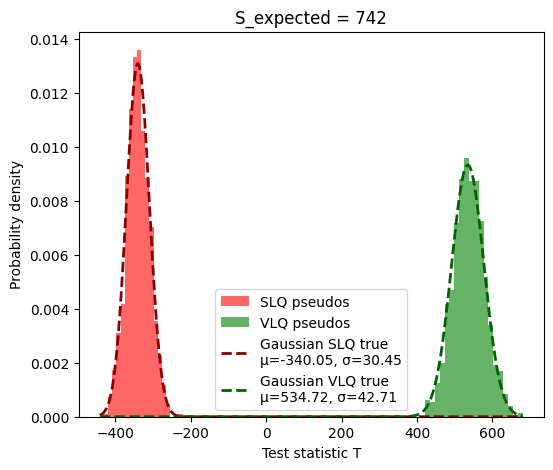

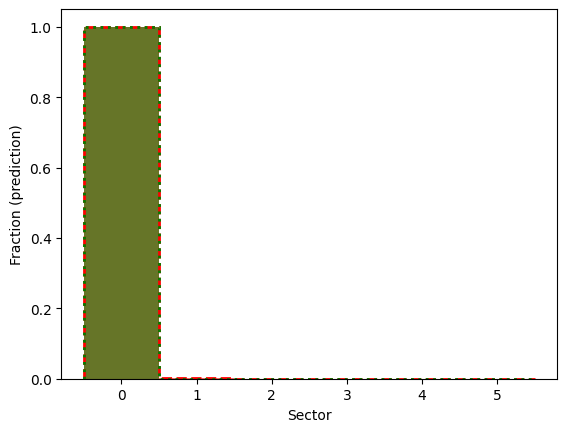

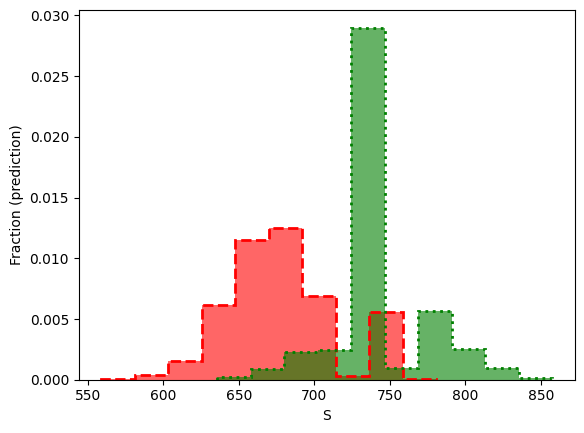

S mean SLQ:  677.2506499425112
S std SLQ:  33.93214650029244
S mean VLQ:  746.5267290590277
S std VLQ:  29.515943361499296

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.951
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.049

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.949
2 = both     : 0.0
3 = neither  : 0.051

S_expected = 419
mass_SLQ = 1300  GeV
mass_VLQ = 1700  GeV


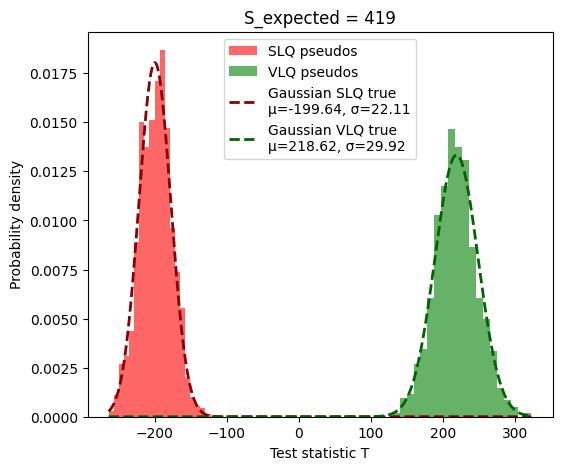

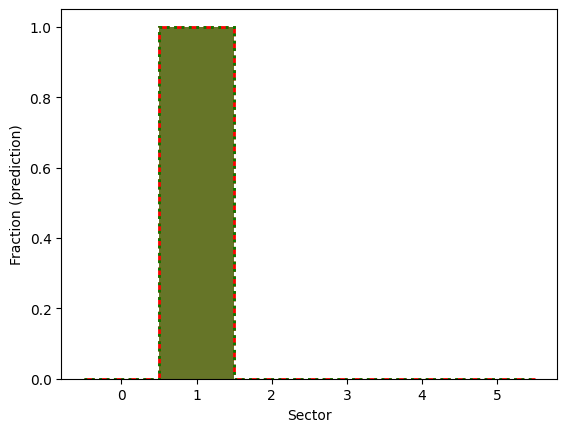

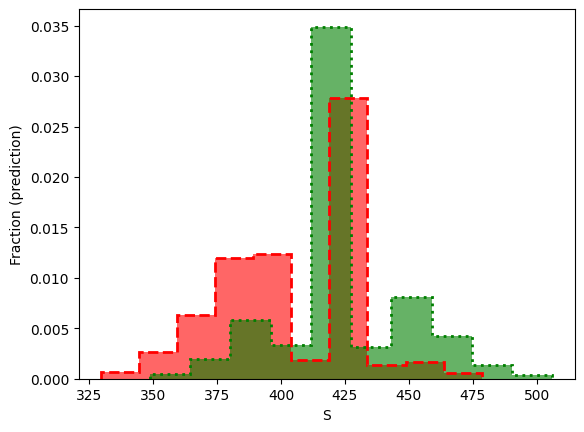

S mean SLQ:  401.46260582635875
S std SLQ:  24.50455019466146
S mean VLQ:  423.31496213847913
S std VLQ:  24.070690022907634

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.947
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.053

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.948
2 = both     : 0.0
3 = neither  : 0.052

S_expected = 237
mass_SLQ = 1400  GeV
mass_VLQ = 1800  GeV


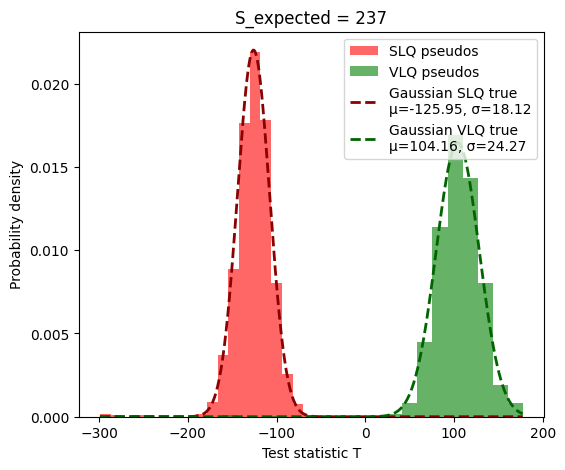

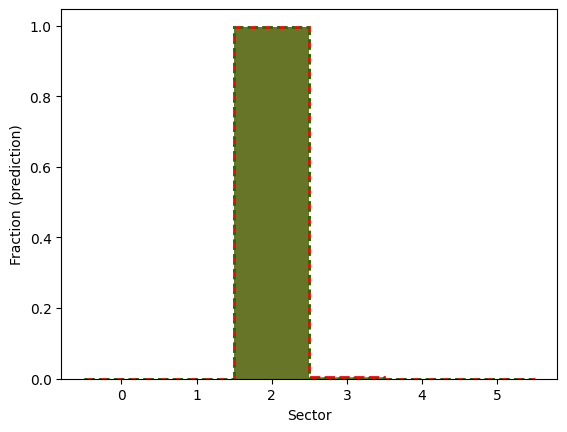

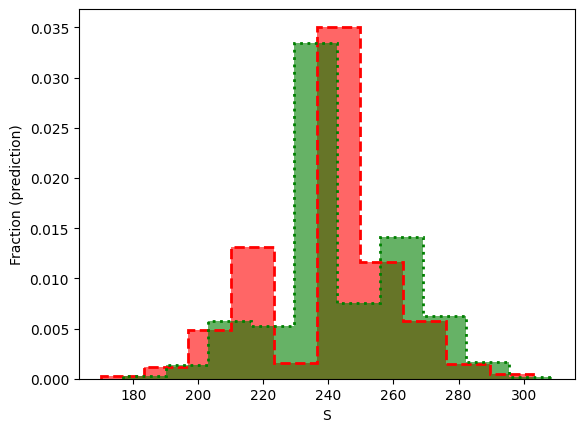

S mean SLQ:  237.18181965722655
S std SLQ:  19.711749557319088
S mean VLQ:  243.61297924044968
S std VLQ:  19.65835979470384

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.938
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.062

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.002
1 = VLQ only : 0.96
2 = both     : 0.0
3 = neither  : 0.038

S_expected = 137
mass_SLQ = 1500  GeV
mass_VLQ = 1900  GeV


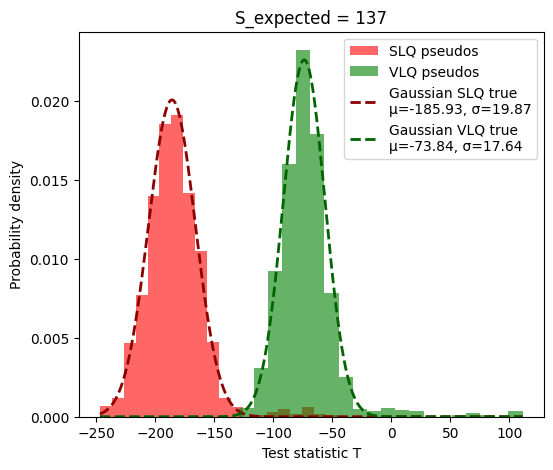

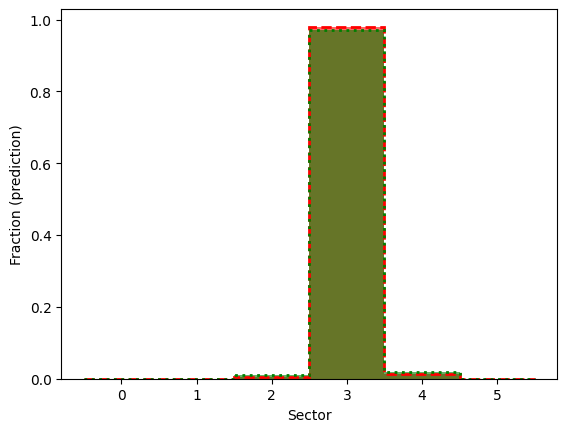

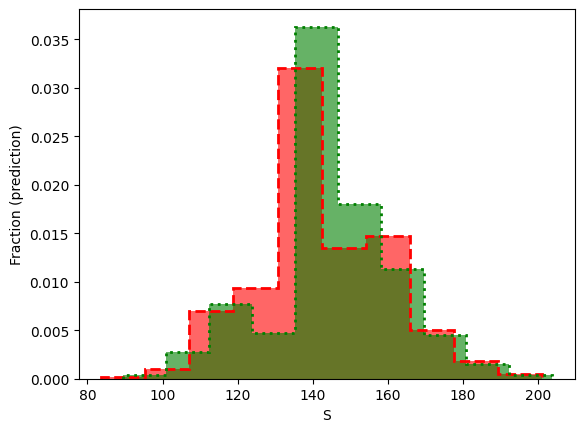

S mean SLQ:  142.41379397085976
S std SLQ:  17.053846381450658
S mean VLQ:  143.27828710207922
S std VLQ:  17.136995180606718

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.94
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.06

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.951
2 = both     : 0.0
3 = neither  : 0.049

S_expected = 80
mass_SLQ = 1600  GeV
mass_VLQ = 2000  GeV


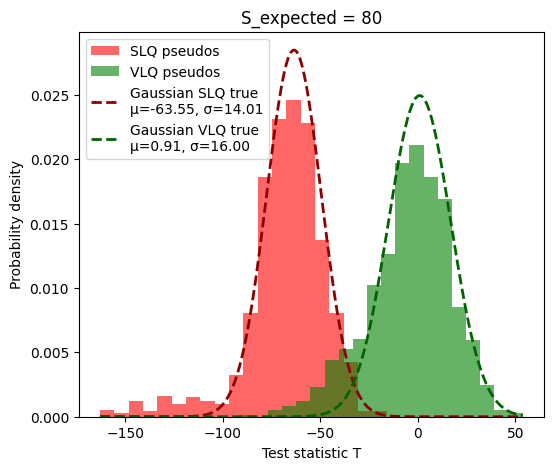

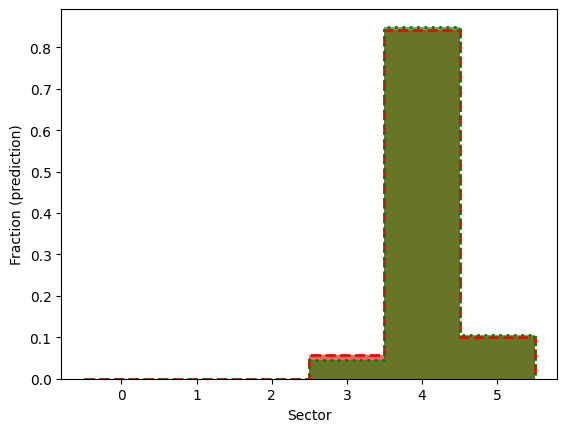

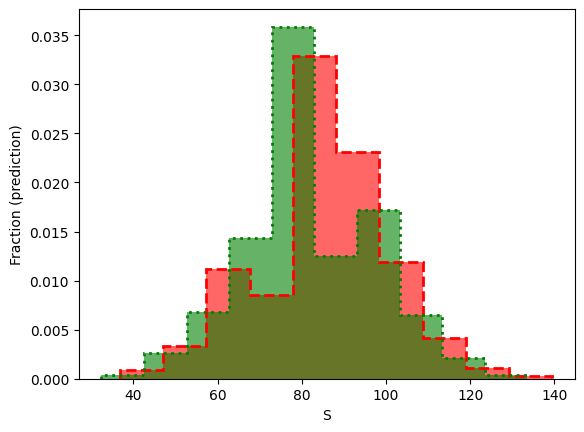

S mean SLQ:  84.00330767071581
S std SLQ:  15.700781172064923
S mean VLQ:  82.80311823336451
S std VLQ:  15.574363375011098

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.887
1 = VLQ only : 0.013
2 = both     : 0.011
3 = neither  : 0.089

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.008
1 = VLQ only : 0.902
2 = both     : 0.048
3 = neither  : 0.042

S_expected = 46
mass_SLQ = 1700  GeV
mass_VLQ = 2100  GeV


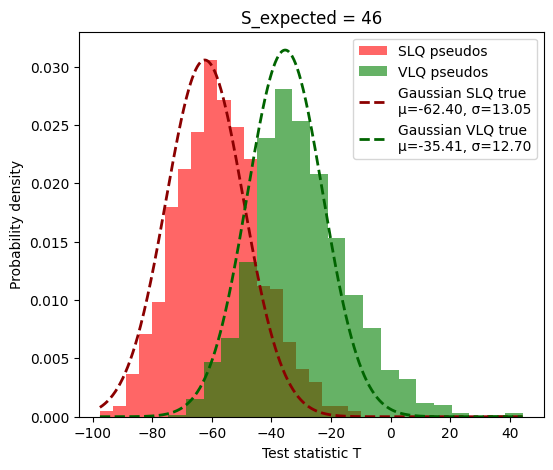

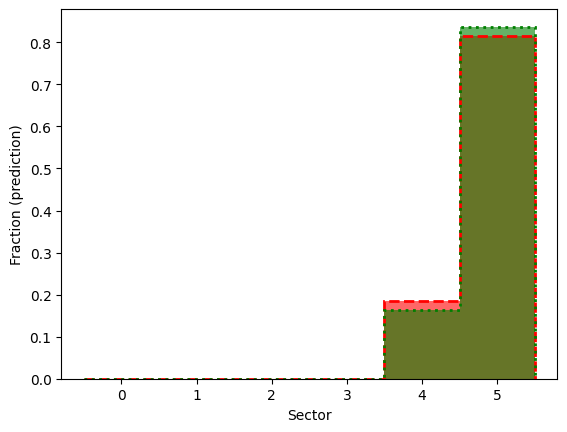

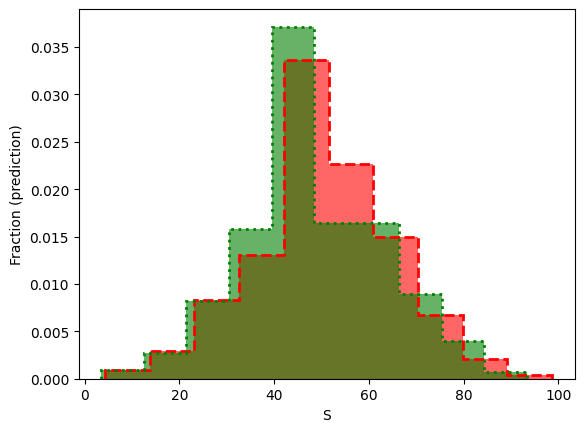

S mean SLQ:  50.04611751636243
S std SLQ:  14.728252271393275
S mean VLQ:  48.77172146600882
S std VLQ:  14.632432534330976

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.538
1 = VLQ only : 0.049
2 = both     : 0.385
3 = neither  : 0.028

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.021
1 = VLQ only : 0.606
2 = both     : 0.339
3 = neither  : 0.034

S_expected = 27
mass_SLQ = 1800  GeV
mass_VLQ = 2200  GeV


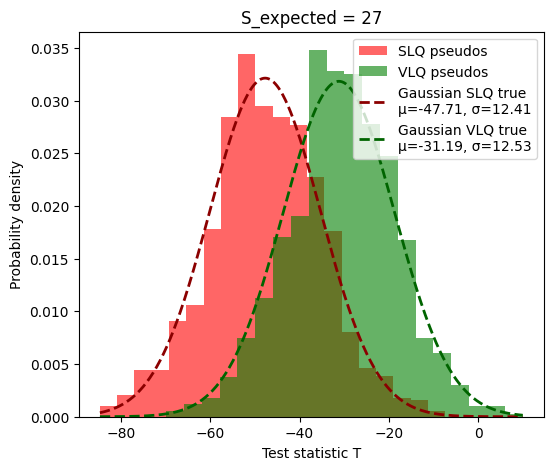

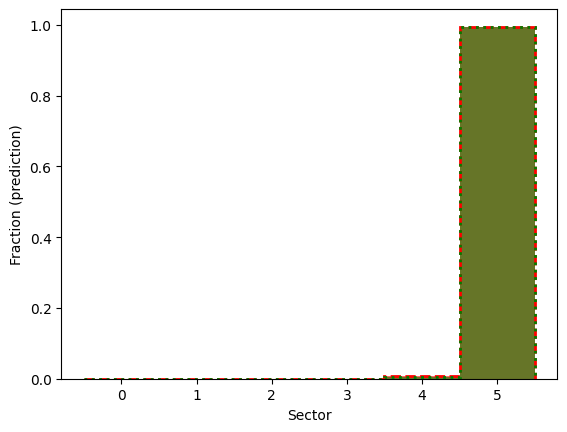

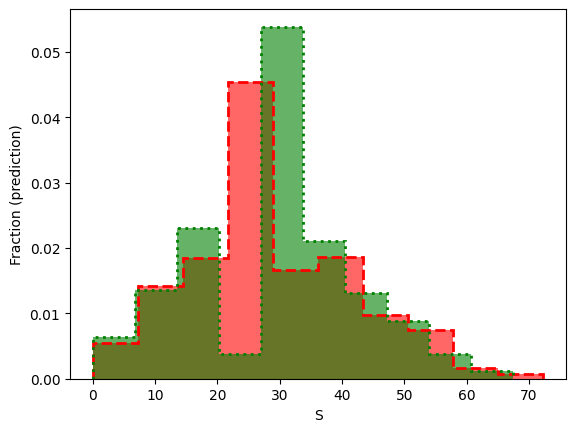

S mean SLQ:  29.217383294801532
S std SLQ:  13.113988314699311
S mean VLQ:  28.29001907154889
S std VLQ:  13.165903151798746

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.144
1 = VLQ only : 0.192
2 = both     : 0.661
3 = neither  : 0.003

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.01
1 = VLQ only : 0.668
2 = both     : 0.274
3 = neither  : 0.048

S_expected = 16
mass_SLQ = 1900  GeV
mass_VLQ = 2300  GeV


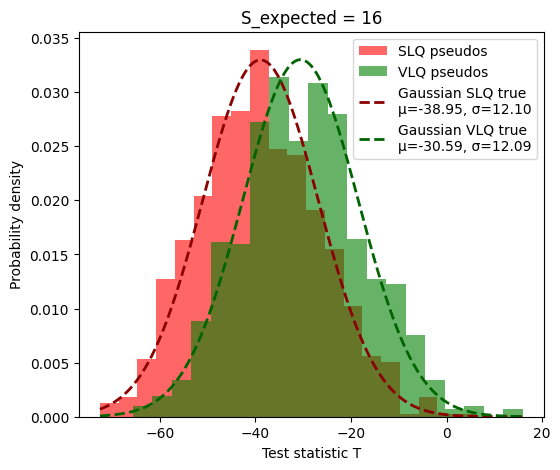

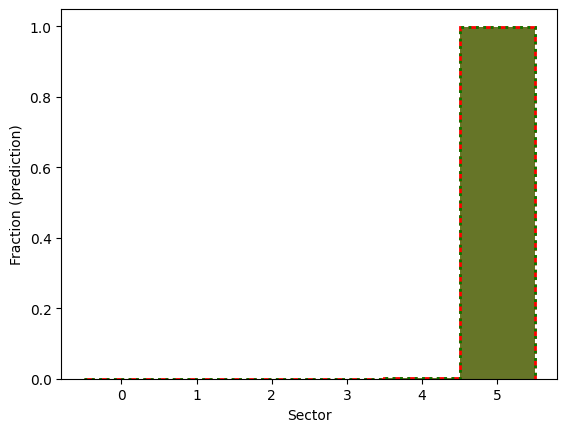

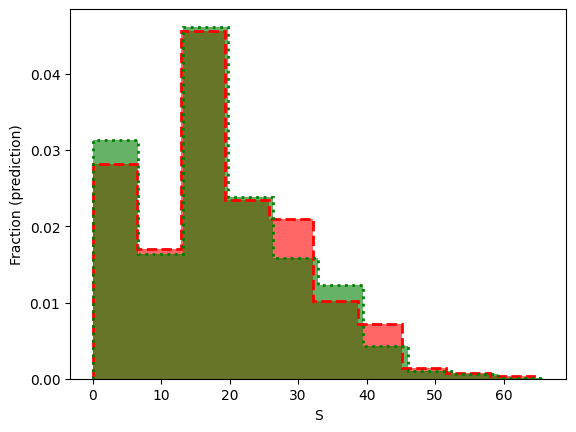

S mean SLQ:  18.457333007139187
S std SLQ:  11.97629862175169
S mean VLQ:  17.6332121198887
S std VLQ:  11.85595947916682

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.037
1 = VLQ only : 0.398
2 = both     : 0.555
3 = neither  : 0.01

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.007
1 = VLQ only : 0.61
2 = both     : 0.311
3 = neither  : 0.072


In [ ]:
Z_threshold = 1.96

n_pseudo = 1000


classification_SLQ = []
classification_VLQ = []

mu_TSLQ = []
std_TSLQ = []
mu_TVLQ = []
std_TVLQ = []



for ii_S, S_exp in enumerate(S_expected):

    print("\n==========================")
    print("S_expected =", S_exp)

    muS_fits = []
    muB_fits = []


    # dado un S, le asigna la masa (del SLQ) correspondiente
    mass_SLQ = mass_list_SLQ[S_expected.index(S_exp)]
    mass_VLQ = mass_list_VLQ[S_expected.index(S_exp)]
    print("mass_SLQ =", mass_SLQ, " GeV")
    print("mass_VLQ =", mass_VLQ, " GeV")

#    # Con esa masa se fija en que sector cae (clasificador B)
#    sector = mass_to_sector[mass]


    # computamos el T statistic para todos los pseudo
    T_SLQ = []
    T_VLQ = []

    # compute the number of events
    muS_fits_SLQ = []
    muS_fits_VLQ = []

    # sector
    sector_SLQ = []
    sector_VLQ = []

    for i in range(n_pseudo):

        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_exp)

        # indices of the events
        idx_B = np.random.choice(len(events_SM["scoresA"]), N_B)

        scoresA_B = events_SM["scoresA"][idx_B]
        scoresB_B = events_SM["scoresB"][idx_B]



        ###########
        # FOR SLQ #
        ###########

        # indices of the events
        idx_S = np.random.choice(len(events_SLQ[mass_SLQ]["scoresA"]), N_S)

        scoresA_S = events_SLQ[mass_SLQ]["scoresA"][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_SLQ.append(muS_fit)

        # Compare with the theoretical S_expected
        diffs = [abs(muS_fit - S_th) for S_th in S_expected]
        best_idx = np.argmin(diffs)

        # the estimated mass
        mass_best = mass_list_SLQ[best_idx]

        # the estimated sector
        sector_pred = mass_to_sector[mass_best]
        sector_SLQ.append(sector_pred)


        scoresB_S = events_SLQ[mass_SLQ]["scoresB"][sector_pred][idx_S]

        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_SLQ.append(T)




        ###########
        # FOR VLQ #
        ###########
        # indices of the events
        idx_S = np.random.choice(len(events_VLQ[mass_VLQ]["scoresA"]), N_S)

        scoresA_S = events_VLQ[mass_VLQ]["scoresA"][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_VLQ.append(muS_fit)

        # Compare with the theoretical S_expected
        diffs = [abs(muS_fit - S_th) for S_th in S_expected]
        best_idx = np.argmin(diffs)

        # the estimated mass (assuming it is SLQ, just to compute the sector)
        mass_best = mass_list_SLQ[best_idx]

        # the estimated sector
        sector_pred = mass_to_sector[mass_best]
        sector_VLQ.append(sector_pred)


        scoresB_S = events_VLQ[mass_VLQ]["scoresB"][sector_pred][idx_S]

        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_VLQ.append(T)

    # Compute the characteristics of the psedo-experiment T distributions
    mu_TSLQ.append( np.mean(T_SLQ) )
    mu_TVLQ.append( np.mean(T_VLQ) )

    std_TSLQ.append( np.std(T_SLQ) )
    std_TVLQ.append( np.std(T_VLQ) )




    # rango común para plotear
    xmin = min(np.min(T_SLQ), np.min(T_VLQ))
    xmax = max(np.max(T_SLQ), np.max(T_VLQ))
    x = np.linspace(xmin, xmax, 500)

    # gaussianas
    gauss_S = (1/(sigma_S[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_S[ii_S])**2 / (2*sigma_S[ii_S]**2))
    gauss_V = (1/(sigma_V[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_V[ii_S])**2 / (2*sigma_V[ii_S]**2))


    # plot
    plt.figure(figsize=(6,5))

    plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label="SLQ pseudos")
    plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label="VLQ pseudos")

    # gaussianas
    plt.plot(x, gauss_S, color='darkred', linewidth=2, linestyle='--', label=f"Gaussian SLQ true\nμ={mu_S[ii_S]:.2f}, σ={sigma_S[ii_S]:.2f}")
    plt.plot(x, gauss_V, color='darkgreen', linewidth=2, linestyle='--', label=f"Gaussian VLQ true\nμ={mu_V[ii_S]:.2f}, σ={sigma_V[ii_S]:.2f}")

    plt.xlabel("Test statistic T")
    plt.ylabel("Probability density")
    plt.title(f"S_expected = {S_exp}")
    plt.legend()

    plt.show()

    plt.hist(sector_SLQ, bins=[-0.5,0.5,1.5,2.5,3.5,4.5,5.5], histtype='step', linestyle='--', edgecolor='red', linewidth=2, density=True)
    plt.hist(sector_SLQ, bins=[-0.5,0.5,1.5,2.5,3.5,4.5,5.5], color='red', alpha=0.6, density=True)
    plt.hist(sector_VLQ, bins=[-0.5,0.5,1.5,2.5,3.5,4.5,5.5], histtype='step', linestyle=':', edgecolor='green', linewidth=2, density=True)
    plt.hist(sector_VLQ, bins=[-0.5,0.5,1.5,2.5,3.5,4.5,5.5], color='green', alpha=0.6, density=True)
    plt.xlabel("Sector")
    plt.ylabel("Fraction (prediction)")
    plt.show()


    plt.hist(muS_fits_SLQ, bins=10, histtype='step', linestyle='--', edgecolor='red', linewidth=2, density=True)
    plt.hist(muS_fits_SLQ, bins=10, color='red', alpha=0.6, density=True)
    plt.hist(muS_fits_VLQ, bins=10, histtype='step', linestyle=':', edgecolor='green', linewidth=2, density=True)
    plt.hist(muS_fits_VLQ, bins=10, color='green', alpha=0.6, density=True)
    plt.xlabel("S")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('S mean SLQ: ', np.mean(muS_fits_SLQ))
    print('S std SLQ: ', np.std(muS_fits_SLQ))
    print('S mean VLQ: ', np.mean(muS_fits_VLQ))
    print('S std VLQ: ', np.std(muS_fits_VLQ))
    print('')


    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    for i in range(n_pseudo):

        # TRUE: SLQ
        T_obs = T_SLQ[i]

        Z_SLQ = abs(T_obs - mu_S[sector_SLQ[i]]) / sigma_S[sector_SLQ[i]]
        Z_VLQ = abs(T_obs - mu_V[sector_SLQ[i]]) / sigma_V[sector_SLQ[i]]

        SLQ_ok = Z_SLQ < Z_threshold
        VLQ_ok = Z_VLQ < Z_threshold

        # p_SLQ = np.mean(np.array(T_SLQ) >= T_obs)
        # p_VLQ = np.mean(np.array(T_VLQ) <= T_obs)

        # SLQ_ok = p_SLQ > 0.05
        # VLQ_ok = p_VLQ > 0.05


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        T_obs = T_VLQ[i]

        Z_SLQ = abs(T_obs - mu_S[sector_VLQ[i]]) / sigma_S[sector_VLQ[i]]
        Z_VLQ = abs(T_obs - mu_V[sector_VLQ[i]]) / sigma_V[sector_VLQ[i]]

        SLQ_ok = Z_SLQ < Z_threshold
        VLQ_ok = Z_VLQ < Z_threshold

        # p_SLQ = np.mean(np.array(T_SLQ) >= T_obs)
        # p_VLQ = np.mean(np.array(T_VLQ) <= T_obs)

        # SLQ_ok = p_SLQ > 0.05
        # VLQ_ok = p_VLQ > 0.05


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ.append(pred_counts_VLQ)



In [ ]:
class_SLQ_array = np.array(classification_SLQ) # Forma (N, 4)
class_VLQ_array = np.array(classification_VLQ) # Forma (N, 4)

# SAVE

file_path = mainfolder + 'saved-results/vs14TeV_err.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    S_expected,
    mass_list_SLQ,
    mass_list_VLQ,
    mu_S,
    sigma_S,
    mu_V,
    sigma_V,
    mu_TSLQ,
    std_TSLQ,
    mu_TVLQ,
    std_TVLQ,
    class_SLQ_array,
    class_VLQ_array,
    # n_pseudo_TRUE,
    # threshold_A
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# S_expected mass_list_SLQ mass_list_SLQ mu_S sigma_S mu_V sigma_V mu_TSLQ std_TSLQ mu_TVLQ std_TVLQ classification_SLQ classification_VLQ',
           comments='')

print(f"Data saved to: {file_path}")

Data saved to: /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/saved-results/vs14TeV_err.txt


In [ ]:
# LOAD

file_path = mainfolder + 'saved-results/vs14TeV_err.txt'

loaded_data = np.loadtxt(file_path)

S_expected = loaded_data[:, 0]
mass_list_SLQ = loaded_data[:, 1]
mass_list_VLQ = loaded_data[:, 2]
mu_S = loaded_data[:, 3]
sigma_S = loaded_data[:, 4]
mu_V = loaded_data[:, 5]
sigma_V = loaded_data[:, 6]
mu_TSLQ = loaded_data[:, 7]
std_TSLQ = loaded_data[:, 8]
mu_TVLQ = loaded_data[:, 9]
std_TVLQ = loaded_data[:, 10]
classification_SLQ = loaded_data[:, 11:15]
classification_VLQ = loaded_data[:, 15:19]





n_pseudo_TRUE = 1000
threshold_A = 0.95

print('n_pseudo_TRUE: ', n_pseudo_TRUE)
print('threshold_A: ', threshold_A)

n_pseudo_TRUE:  1000
threshold_A:  0.95


In [ ]:
# B_expected = 45962

# mass_list_SLQ = [1200,1300,1400,1500,1600,1700,1800,1900]
# mass_list_VLQ = [1600,1700,1800,1900,2000,2100,2200,2300]

# S_expected = [round(fid_xsec_SLQ_14TeV(mmm, 0.5) * Lum) for mmm in mass_list_SLQ]
# S_expected_VLQ = [round(fid_xsec_VLQ_14TeV(mmm, 0.5) * Lum) for mmm in mass_list_VLQ]

# print('B_expected: ', B_expected)
# print('S_expected: ', S_expected)

#### confusion matrix - like

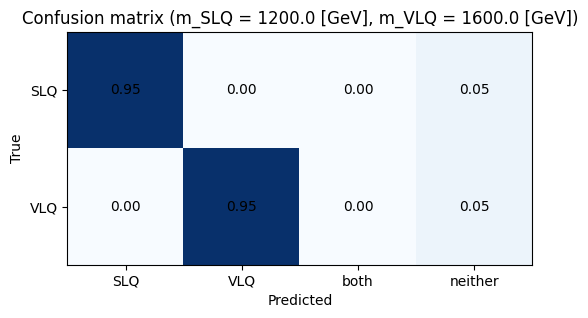

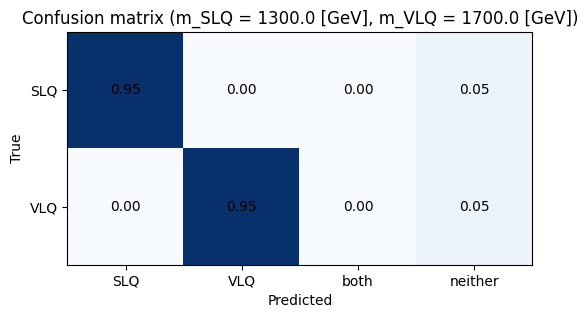

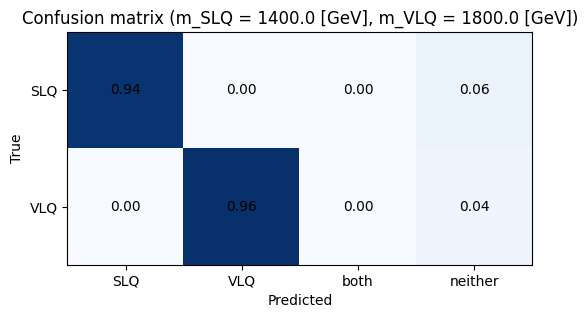

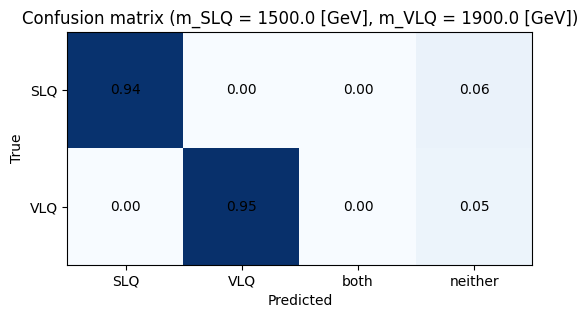

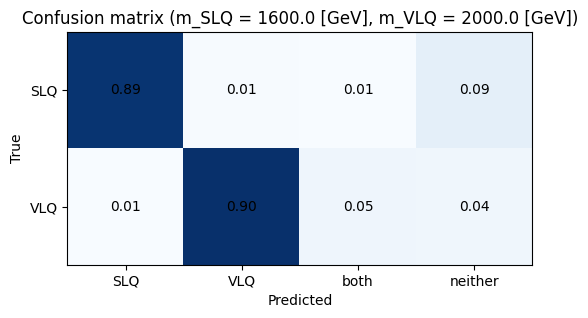

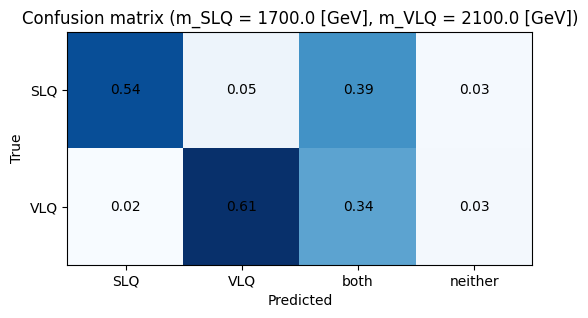

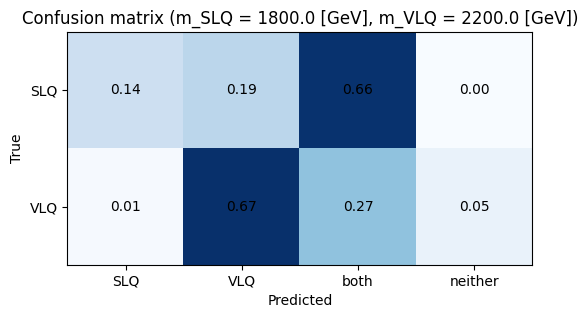

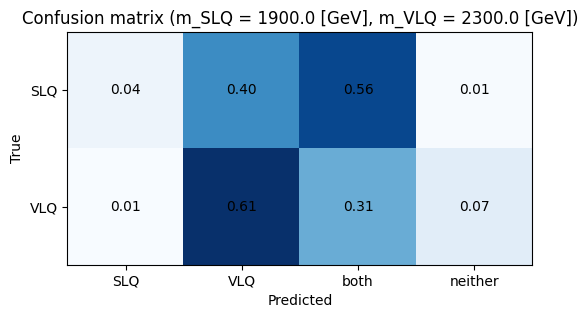

In [ ]:
labels = ["SLQ", "VLQ", "both", "neither"]

accuracy_F = []
both_F = []
fail_F = []

for ii_S, S_exp in enumerate(S_expected):

    conf_matrix = np.array([ classification_SLQ[ii_S], classification_VLQ[ii_S] ])



    plt.figure(figsize=(6,5))
    plt.imshow(conf_matrix, cmap='Blues')

    plt.xticks(range(4), labels)
    plt.yticks(range(2), ["SLQ", "VLQ"])

    for i in range(2):
        for j in range(4):
            plt.text(j, i, f"{conf_matrix[i,j]:.2f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion matrix (m_SLQ = {mass_list_SLQ[ii_S]} [GeV], m_VLQ = {mass_list_VLQ[ii_S]} [GeV])")
    # plt.colorbar()
    plt.show()

    accuracy_F.append( 0.5 * (classification_SLQ[ii_S][0] + classification_VLQ[ii_S][1]) )
    both_F.append( 0.5 * (classification_SLQ[ii_S][2] + classification_VLQ[ii_S][2]) )
    fail_F.append( 0.5 * (classification_SLQ[ii_S][3] + classification_VLQ[ii_S][3]) )


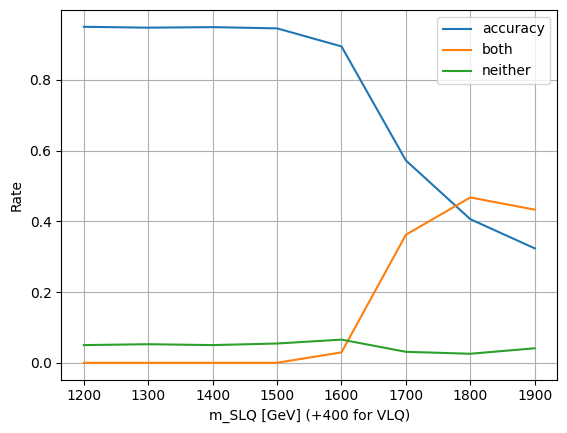

In [ ]:

plt.plot(mass_list_SLQ, accuracy_F, label='accuracy')
plt.plot(mass_list_SLQ, both_F, label='both')
plt.plot(mass_list_SLQ, fail_F, label='neither')
plt.xlabel("m_SLQ [GeV] (+400 for VLQ)")
plt.ylabel("Rate")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# The statistical significance was calculated using the difference in means normalized by
# the combined standard deviation in quadrature,
# weighted/corrected through pseudo-experiments to account for classification bias. It is a Gaussian separation power.

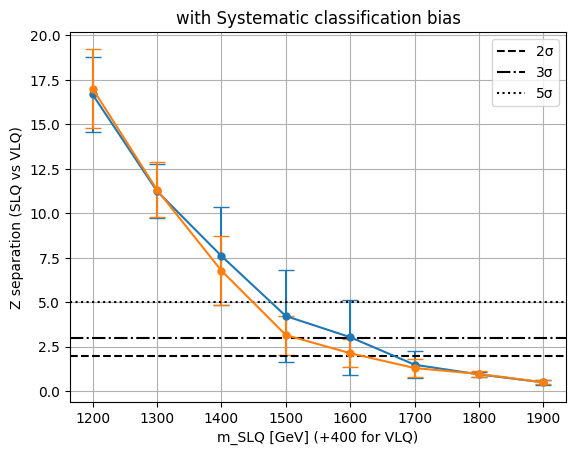

 Z:        5

  with theoretical distributions 
 S:        160.1105938984301   ( 243.25589523212759 - 78.41534673294325 )
 m_SLQ:    1476.8894061015699   ( 1396.5626949274024 - 1604.660744903108 )  [GeV]
 m_VLQ:    1876.8894061015699   ( 1796.5626949274024 - 2004.660744903108 )  [GeV]

  with pseudo-exp distributions 
 S:        188.0390603604796   ( 243.65965125750924 - 153.76872114565256 )
 m_SLQ:    1448.9609396395203   ( 1396.3408509574126 - 1483.2312788543475 )  [GeV]
 m_VLQ:    1848.9609396395203   ( 1796.3408509574126 - 1883.2312788543475 )  [GeV]

 Z:        2

  with theoretical distributions 
 S:        57.36124853490121   ( 148.6208056166624 - 41.97717003928719 )
 m_SLQ:    1666.5845631326436   ( 1488.3791943833376 - 1721.1727892669096 )  [GeV]
 m_VLQ:    2066.5845631326433   ( 1888.3791943833376 - 2121.1727892669096 )  [GeV]

  with pseudo-exp distributions 
 S:        74.71757033729999   ( 132.44491227258067 - 51.453816234774585 )
 m_SLQ:    1615.5365578314706   ( 1507.991

/tmp/ipykernel_1363/1776276044.py:225: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  S_threshold_low_Z2 = fsolve(lambda x: f_results_Z_low(x) - Z_threshold,100, xtol=1e-4)[0]


In [ ]:

Z_gauss = []
Z_gauss_std = []

for ii_S, S_exp in enumerate(S_expected):

    # 1. Calculo de Z
    num = abs(mu_S[ii_S] - mu_V[ii_S])
    den = np.sqrt(sigma_S[ii_S]**2 + sigma_V[ii_S]**2)

    Z = num / den


    # 2. Errores
    # Numero de pseudo experimentos
    N_S = n_pseudo_TRUE
    N_V = n_pseudo_TRUE

    # Means
    # gaussianas
    delta_mu_S_gauss = sigma_S[ii_S] / np.sqrt(N_S)
    delta_mu_V_gauss = sigma_V[ii_S] / np.sqrt(N_V)
    # pseudo
    delta_mu_S_pseudo = abs(mu_S[ii_S] - mu_TSLQ[ii_S])
    delta_mu_V_pseudo = abs(mu_V[ii_S] - mu_TVLQ[ii_S])


    delta_mu_S = np.sqrt( delta_mu_S_gauss**2 + delta_mu_S_pseudo**2 )
    delta_mu_V = np.sqrt( delta_mu_V_gauss**2 + delta_mu_V_pseudo**2 )

    # delta_mu_S = delta_mu_S_gauss
    # delta_mu_V = delta_mu_V_gauss


    # STD
    # gaussianas
    delta_sigma_S_gauss = sigma_S[ii_S] / np.sqrt(2 * N_S)
    delta_sigma_V_gauss = sigma_V[ii_S] / np.sqrt(2 * N_V)
    # pseudo
    delta_sigma_S_pseudo = np.sqrt( abs(sigma_S[ii_S]**2 - std_TSLQ[ii_S]**2) )
    delta_sigma_V_pseudo = np.sqrt( abs(sigma_V[ii_S]**2 - std_TVLQ[ii_S]**2) )


    delta_sigma_S = np.sqrt( delta_sigma_S_gauss**2 + delta_sigma_S_pseudo**2 )
    delta_sigma_V = np.sqrt( delta_sigma_V_gauss**2 + delta_sigma_V_pseudo**2 )

    # delta_sigma_S = delta_sigma_S_gauss
    # delta_sigma_V = delta_sigma_V_gauss


    # 3. Propagación (raiz de la suma al cuadrado de cada componente)
    # Derivadas parciales de las medias ^2
    term_mu = (delta_mu_S**2 + delta_mu_V**2) / den**2

    # Derivadas parciales de las sigmas ^2
    # La derivada de Z respecto a sigma_S es: -(num * sigma_S) / den^3, entonces al cuadrado
    term_sigma = (num**2 / den**6) * (sigma_S[ii_S]**2 * delta_sigma_S**2 + sigma_V[ii_S]**2 * delta_sigma_V**2)

    delta_Z = np.sqrt(term_mu + term_sigma)

    Z_gauss.append(Z)
    Z_gauss_std.append(delta_Z)




Z_T = []
Z_T_std = []

for ii_S, S_exp in enumerate(S_expected):

    # 1. Calculo de Z
    num = abs(mu_TSLQ[ii_S] - mu_TVLQ[ii_S])
    den = np.sqrt(std_TSLQ[ii_S]**2 + std_TVLQ[ii_S]**2)

    Z =  num / den


    # 2. Errores
    # Numero de pseudo experimentos
    N_S = n_pseudo_TRUE
    N_V = n_pseudo_TRUE

    # Means
    # gaussianas
    delta_mu_S_gauss = sigma_S[ii_S] / np.sqrt(N_S)
    delta_mu_V_gauss = sigma_V[ii_S] / np.sqrt(N_V)
    # pseudo
    delta_mu_S_pseudo = abs(mu_S[ii_S] - mu_TSLQ[ii_S])
    delta_mu_V_pseudo = abs(mu_V[ii_S] - mu_TVLQ[ii_S])


    delta_mu_S = np.sqrt( delta_mu_S_gauss**2 + delta_mu_S_pseudo**2 )
    delta_mu_V = np.sqrt( delta_mu_V_gauss**2 + delta_mu_V_pseudo**2 )

    # delta_mu_S = delta_mu_S_gauss
    # delta_mu_V = delta_mu_V_gauss


    # STD
    # gaussianas
    delta_sigma_S_gauss = sigma_S[ii_S] / np.sqrt(2 * N_S)
    delta_sigma_V_gauss = sigma_V[ii_S] / np.sqrt(2 * N_V)
    # pseudo
    delta_sigma_S_pseudo = np.sqrt( abs(sigma_S[ii_S]**2 - std_TSLQ[ii_S]**2) )
    delta_sigma_V_pseudo = np.sqrt( abs(sigma_V[ii_S]**2 - std_TVLQ[ii_S]**2) )


    delta_sigma_S = np.sqrt( delta_sigma_S_gauss**2 + delta_sigma_S_pseudo**2 )
    delta_sigma_V = np.sqrt( delta_sigma_V_gauss**2 + delta_sigma_V_pseudo**2 )

    # delta_sigma_S = delta_sigma_S_gauss
    # delta_sigma_V = delta_sigma_V_gauss


    # 3. Propagación (raiz de la suma al cuadrado de cada componente)
    # Derivadas parciales de las medias ^2
    term_mu = (delta_mu_S**2 + delta_mu_V**2) / den**2

    # Derivadas parciales de las sigmas ^2
    # La derivada de Z respecto a sigma_S es: -(num * sigma_S) / den^3, entonces al cuadrado
    term_sigma = (num**2 / den**6) * (sigma_S[ii_S]**2 * delta_sigma_S**2 + sigma_V[ii_S]**2 * delta_sigma_V**2)

    delta_Z = np.sqrt(term_mu + term_sigma)

    Z_T.append(Z)
    Z_T_std.append(delta_Z)


# plt.plot(mass_list_SLQ, Z_gauss, marker='o')
plt.errorbar(mass_list_SLQ, Z_gauss, yerr=Z_gauss_std, fmt='o', markersize=5, capsize=6, linestyle='-')
plt.errorbar(mass_list_SLQ, Z_T, yerr=Z_T_std, fmt='o', markersize=5, capsize=6, linestyle='-')
plt.axhline(2, color='black', linestyle='--', label='2σ')
plt.axhline(3, color='black', linestyle='-.', label='3σ')
plt.axhline(5, color='black', linestyle=':', label='5σ')

plt.xlabel("m_SLQ [GeV] (+400 for VLQ)")
plt.ylabel("Z separation (SLQ vs VLQ)")
plt.title("with Systematic classification bias",fontsize=12)
plt.legend()
plt.grid()
plt.show()




Z_gauss_low = [i-j  for i,j in zip(Z_gauss, Z_gauss_std)]
Z_T_low = [i-j  for i,j in zip(Z_T, Z_T_std)]
Z_gauss_high = [i+j  for i,j in zip(Z_gauss, Z_gauss_std)]
Z_T_high = [i+j  for i,j in zip(Z_T, Z_T_std)]

#  interpolate
f_results_Z = interp1d(S_expected, Z_gauss, kind='linear', fill_value="extrapolate")
f_results_Z_mSLQ = interp1d(mass_list_SLQ, Z_gauss, kind='linear', fill_value="extrapolate")
f_results_Z_mVLQ = interp1d(mass_list_VLQ, Z_gauss, kind='linear', fill_value="extrapolate")

f_results_Z_low = interp1d(S_expected, Z_gauss_low, kind='linear', fill_value="extrapolate")
f_results_Z_low_mSLQ = interp1d(mass_list_SLQ, Z_gauss_low, kind='linear', fill_value="extrapolate")
f_results_Z_low_mVLQ = interp1d(mass_list_VLQ, Z_gauss_low, kind='linear', fill_value="extrapolate")

f_results_Z_high = interp1d(S_expected, Z_gauss_high, kind='linear', fill_value="extrapolate")
f_results_Z_high_mSLQ = interp1d(mass_list_SLQ, Z_gauss_high, kind='linear', fill_value="extrapolate")
f_results_Z_high_mVLQ = interp1d(mass_list_VLQ, Z_gauss_high, kind='linear', fill_value="extrapolate")

f_results_Z_T = interp1d(S_expected, Z_T, kind='linear', fill_value="extrapolate")
f_results_Z_T_mSLQ = interp1d(mass_list_SLQ, Z_T, kind='linear', fill_value="extrapolate")
f_results_Z_T_mVLQ = interp1d(mass_list_VLQ, Z_T, kind='linear', fill_value="extrapolate")

f_results_Z_T_low  = interp1d(S_expected, Z_T_low, kind='linear', fill_value="extrapolate")
f_results_Z_T_low_mSLQ = interp1d(mass_list_SLQ, Z_T_low, kind='linear', fill_value="extrapolate")
f_results_Z_T_low_mVLQ = interp1d(mass_list_VLQ, Z_T_low, kind='linear', fill_value="extrapolate")

f_results_Z_T_high  = interp1d(S_expected, Z_T_high, kind='linear', fill_value="extrapolate")
f_results_Z_T_high_mSLQ = interp1d(mass_list_SLQ, Z_T_high, kind='linear', fill_value="extrapolate")
f_results_Z_T_high_mVLQ = interp1d(mass_list_VLQ, Z_T_high, kind='linear', fill_value="extrapolate")



Z_threshold = 5

S_threshold_Z5 = fsolve(lambda x: f_results_Z(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_Z5 = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_Z5 = fsolve(lambda x: f_results_Z_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_low_Z5 = fsolve(lambda x: f_results_Z_low(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_low_Z5 = fsolve(lambda x: f_results_Z_low_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_low_Z5 = fsolve(lambda x: f_results_Z_low_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_high_Z5 = fsolve(lambda x: f_results_Z_high(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_high_Z5 = fsolve(lambda x: f_results_Z_high_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_high_Z5 = fsolve(lambda x: f_results_Z_high_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]


S_threshold_T_Z5 = fsolve(lambda x: f_results_Z_T(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_T_Z5 = fsolve(lambda x: f_results_Z_T_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_T_Z5 = fsolve(lambda x: f_results_Z_T_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_T_low_Z5 = fsolve(lambda x: f_results_Z_T_low(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_T_low_Z5 = fsolve(lambda x: f_results_Z_T_low_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_T_low_Z5 = fsolve(lambda x: f_results_Z_T_low_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_T_high_Z5 = fsolve(lambda x: f_results_Z_T_high(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_T_high_Z5 = fsolve(lambda x: f_results_Z_T_high_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_T_high_Z5 = fsolve(lambda x: f_results_Z_T_high_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

print(' Z:       ', Z_threshold)

print('\n  with theoretical distributions ')
print(' S:       ', S_threshold_Z5, '  (', S_threshold_low_Z5, '-', S_threshold_high_Z5, ')')
print(' m_SLQ:   ', mSLQ_threshold_Z5, '  (', mSLQ_threshold_low_Z5, '-', mSLQ_threshold_high_Z5, ')', ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold_Z5, '  (', mVLQ_threshold_low_Z5, '-', mVLQ_threshold_high_Z5, ')', ' [GeV]\n')

print('  with pseudo-exp distributions ')
print(' S:       ', S_threshold_T_Z5, '  (', S_threshold_T_low_Z5, '-', S_threshold_T_high_Z5, ')')
print(' m_SLQ:   ', mSLQ_threshold_T_Z5, '  (', mSLQ_threshold_T_low_Z5, '-', mSLQ_threshold_T_high_Z5, ')', ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold_T_Z5, '  (', mVLQ_threshold_T_low_Z5, '-', mVLQ_threshold_T_high_Z5, ')', ' [GeV]\n')



Z_threshold = 2

S_threshold_Z2 = fsolve(lambda x: f_results_Z(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_Z2 = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_Z2 = fsolve(lambda x: f_results_Z_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_low_Z2 = fsolve(lambda x: f_results_Z_low(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_low_Z2 = fsolve(lambda x: f_results_Z_low_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_low_Z2 = fsolve(lambda x: f_results_Z_low_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_high_Z2 = fsolve(lambda x: f_results_Z_high(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_high_Z2 = fsolve(lambda x: f_results_Z_high_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_high_Z2 = fsolve(lambda x: f_results_Z_high_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]


S_threshold_T_Z2 = fsolve(lambda x: f_results_Z_T(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_T_Z2 = fsolve(lambda x: f_results_Z_T_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_T_Z2 = fsolve(lambda x: f_results_Z_T_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_T_low_Z2 = fsolve(lambda x: f_results_Z_T_low(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_T_low_Z2 = fsolve(lambda x: f_results_Z_T_low_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_T_low_Z2 = fsolve(lambda x: f_results_Z_T_low_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

S_threshold_T_high_Z2 = fsolve(lambda x: f_results_Z_T_high(x) - Z_threshold,100, xtol=1e-4)[0]
mSLQ_threshold_T_high_Z2 = fsolve(lambda x: f_results_Z_T_high_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
mVLQ_threshold_T_high_Z2 = fsolve(lambda x: f_results_Z_T_high_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

print(' Z:       ', Z_threshold)

print('\n  with theoretical distributions ')
print(' S:       ', S_threshold_Z2, '  (', S_threshold_low_Z2, '-', S_threshold_high_Z2, ')')
print(' m_SLQ:   ', mSLQ_threshold_Z2, '  (', mSLQ_threshold_low_Z2, '-', mSLQ_threshold_high_Z2, ')', ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold_Z2, '  (', mVLQ_threshold_low_Z2, '-', mVLQ_threshold_high_Z2, ')', ' [GeV]\n')

print('  with pseudo-exp distributions ')
print(' S:       ', S_threshold_T_Z2, '  (', S_threshold_T_low_Z2, '-', S_threshold_T_high_Z2, ')')
print(' m_SLQ:   ', mSLQ_threshold_T_Z2, '  (', mSLQ_threshold_T_low_Z2, '-', mSLQ_threshold_T_high_Z2, ')', ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold_T_Z2, '  (', mVLQ_threshold_T_low_Z2, '-', mVLQ_threshold_T_high_Z2, ')', ' [GeV]\n')


In [ ]:
# LOAD

file_path = mainfolder + 'saved-results/Z13TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_13TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_13TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_13TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_13TeV = loaded_data[:, 4]
m_BL_exc_SLQ_13TeV = loaded_data[:, 5]
m_BL_dis_SLQ_13TeV = loaded_data[:, 6]
m_BL_exc_VLQ_13TeV = loaded_data[:, 7]
m_BL_dis_VLQ_13TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_13TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_13TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_13TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_13TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_13TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_13TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_13TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_13TeV = loaded_data[:, 16]


# LOAD

file_path = mainfolder + 'saved-results/Z136TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_136TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_136TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_136TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_136TeV = loaded_data[:, 4]
m_BL_exc_SLQ_136TeV = loaded_data[:, 5]
m_BL_dis_SLQ_136TeV = loaded_data[:, 6]
m_BL_exc_VLQ_136TeV = loaded_data[:, 7]
m_BL_dis_VLQ_136TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_136TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_136TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_136TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_136TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_136TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_136TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_136TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_136TeV = loaded_data[:, 16]




# LOAD

file_path = mainfolder + 'saved-results/Z14TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_14TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_14TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_14TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_14TeV = loaded_data[:, 4]
m_BL_exc_SLQ_14TeV = loaded_data[:, 5]
m_BL_dis_SLQ_14TeV = loaded_data[:, 6]
m_BL_exc_VLQ_14TeV = loaded_data[:, 7]
m_BL_dis_VLQ_14TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_14TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_14TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_14TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_14TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_14TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_14TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_14TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_14TeV = loaded_data[:, 16]

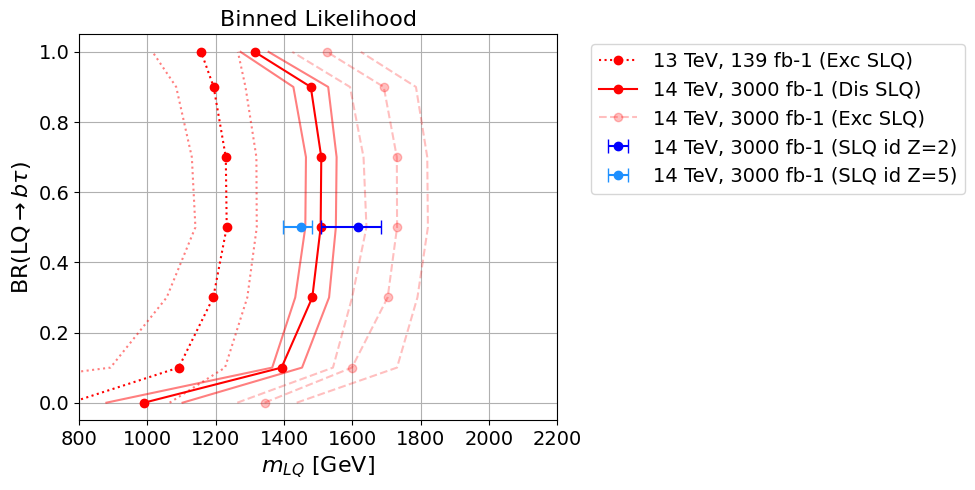

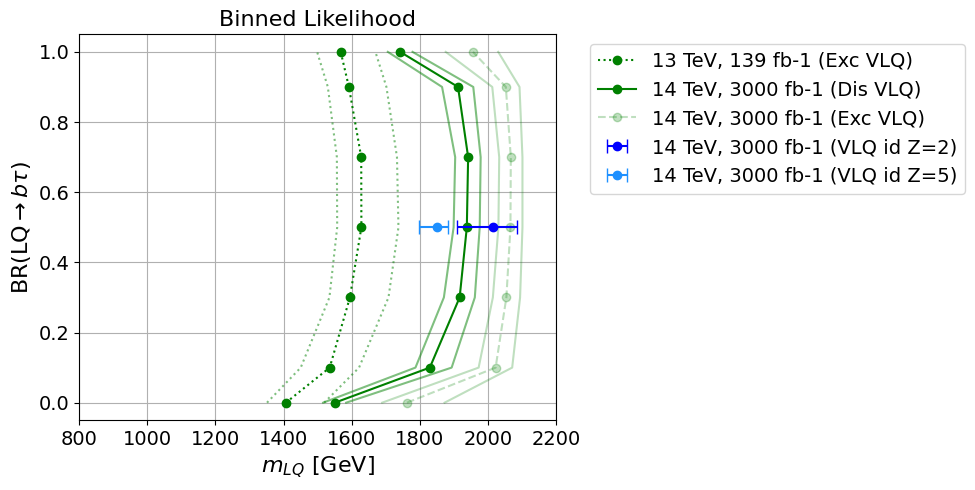

In [ ]:

# plot BINNED LIKEHOOD

plt.figure(figsize=(10, 5))

plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o:', c='red', label='13 TeV, 139 fb-1 (Exc SLQ)')
plt.plot(m_BL_exc_SLQ_low_13TeV, betas, ':', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_13TeV, betas, ':', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_14TeV, betas, 'o-', c='red', label='14 TeV, 3000 fb-1 (Dis SLQ)')
plt.plot(m_BL_dis_SLQ_low_14TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_14TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_14TeV, betas, 'o--', c='red', alpha=0.25, label='14 TeV, 3000 fb-1 (Exc SLQ)')
plt.plot(m_BL_exc_SLQ_low_14TeV, betas, '--', c='red', alpha=0.25)
plt.plot(m_BL_exc_SLQ_high_14TeV, betas, '--', c='red', alpha=0.25)

m_SLQ_T_Z2 = [[mSLQ_threshold_T_Z2 - mSLQ_threshold_T_low_Z2], [mSLQ_threshold_T_high_Z2 - mSLQ_threshold_T_Z2]]
plt.errorbar(mSLQ_threshold_T_Z2, 0.5, xerr=m_SLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=2)')

m_SLQ_T_Z5 = [[mSLQ_threshold_T_Z5 - mSLQ_threshold_T_low_Z5], [mSLQ_threshold_T_high_Z5 - mSLQ_threshold_T_Z5]]
plt.errorbar(mSLQ_threshold_T_Z5, 0.5, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (SLQ id Z=5)')

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(800,2200)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()





plt.figure(figsize=(10, 5))

plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o:', c='green', label='13 TeV, 139 fb-1 (Exc VLQ)')
plt.plot(m_BL_exc_VLQ_low_13TeV, betas, ':', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_13TeV, betas, ':', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_14TeV, betas, 'o-', c='green', label='14 TeV, 3000 fb-1 (Dis VLQ)')
plt.plot(m_BL_dis_VLQ_low_14TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_14TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_14TeV, betas, 'o--', c='green', alpha=0.25, label='14 TeV, 3000 fb-1 (Exc VLQ)')
plt.plot(m_BL_exc_VLQ_low_14TeV, betas, '-', c='green', alpha=0.25)
plt.plot(m_BL_exc_VLQ_high_14TeV, betas, '-', c='green', alpha=0.25)

m_VLQ_T_Z2 = [[mVLQ_threshold_T_Z2 - mVLQ_threshold_T_low_Z2], [mVLQ_threshold_T_high_Z2 - mVLQ_threshold_T_Z2]]
plt.errorbar(mVLQ_threshold_T_Z2, 0.5, xerr=m_VLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=2)')

m_VLQ_T_Z5 = [[mVLQ_threshold_T_Z5 - mVLQ_threshold_T_low_Z5], [mVLQ_threshold_T_high_Z5 - mVLQ_threshold_T_Z5]]
plt.errorbar(mVLQ_threshold_T_Z5, 0.5, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5)')

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(800,2200)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


0.9278572658008042
0.28417324761149704
0.7010335927126196
0.189133603043668
0.5572500469806927
0.13428726666303126
0.6172549604187876
0.07466745149564585
0.43434500812242915
0.05919907579173193
0.41861972042583323
0.03865467948682881
0.3892071810166474
0.03477454251617316
0.38208507775943934
0.03263478541079864


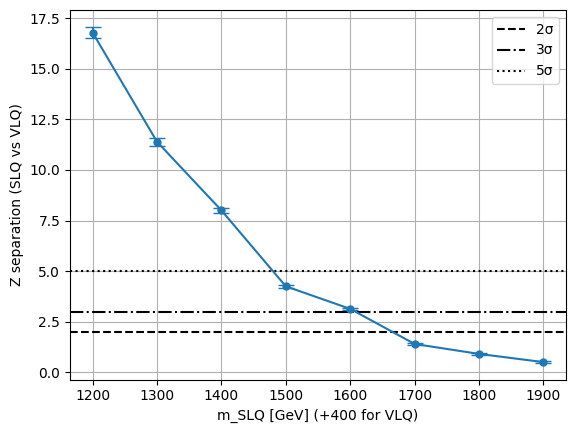

 Z:        1.96
 S:        56.878322834788705
 m_SLQ:    1668.0049328388568  [GeV]
 m_VLQ:    2068.004932838857  [GeV]



In [ ]:

Z_gauss = []
Z_gauss_std = []

for ii_S, S_exp in enumerate(S_expected):

    # 1. Calculo de Z
    num = abs(mu_S[ii_S] - mu_V[ii_S])
    den = np.sqrt(sigma_S[ii_S]**2 + sigma_V[ii_S]**2)

    Z = num / den


    # 2. Errores
    # Numero de pseudo experimentos
    N_S = n_pseudo_TRUE
    N_V = n_pseudo_TRUE

    # (gaussianas)
    s_mu_S = sigma_S[ii_S] / np.sqrt(N_S)
    s_mu_V = sigma_V[ii_S] / np.sqrt(N_V)
    print(s_mu_S)

    s_sigma_S = sigma_S[ii_S] / np.sqrt(2 * N_S)
    s_sigma_V = sigma_V[ii_S] / np.sqrt(2 * N_V)

    # 3. Propagación para Delta = |mu_S - mu_V|
    # s_Delta = sqrt(s_mu_S^2 + s_mu_V^2)
    s_Delta = np.sqrt(s_mu_S**2 + s_mu_V**2)

    # Propagación para D = sqrt(sigma_S^2 + sigma_V^2)
    # Usando derivada parcial: dD/dsigma_S = sigma_S / D
    s_D = np.sqrt((sigma_S[ii_S] * s_sigma_S)**2 + (sigma_V[ii_S] * s_sigma_V)**2) / D

    # 4. Propagación final para Z = Delta / D
    s_Z = np.abs(Z) * np.sqrt((s_Delta / Delta)**2 + (s_D / D)**2)
    print(s_Z)


    Z_gauss.append(Z)
    Z_gauss_std.append(s_Z)


# plt.plot(mass_list_SLQ, Z_gauss, marker='o')
plt.errorbar(mass_list_SLQ, Z_gauss, yerr=Z_gauss_std, fmt='o', markersize=5, capsize=6, linestyle='-')
plt.axhline(2, color='black', linestyle='--', label='2σ')
plt.axhline(3, color='black', linestyle='-.', label='3σ')
plt.axhline(5, color='black', linestyle=':', label='5σ')

plt.xlabel("m_SLQ [GeV] (+400 for VLQ)")
plt.ylabel("Z separation (SLQ vs VLQ)")
plt.legend()
plt.grid()
plt.show()

print(' Z:       ', Z_threshold)
print(' S:       ', S_threshold)
print(' m_SLQ:   ', mSLQ_threshold, ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold, ' [GeV]\n')


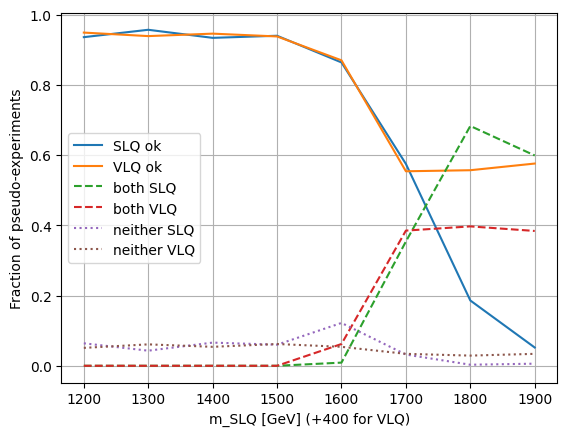

In [ ]:
SLQ_correct = [c[0] for c in classification_SLQ]
VLQ_correct = [c[1] for c in classification_VLQ]
both_frac_SLQ = [c[2] for c in classification_SLQ]
both_frac_VLQ = [c[2] for c in classification_VLQ]
fail_frac_SLQ = [c[3] for c in classification_SLQ]
fail_frac_VLQ = [c[3] for c in classification_VLQ]


plt.plot(mass_list_SLQ, SLQ_correct, label='SLQ ok')
plt.plot(mass_list_SLQ, VLQ_correct, label='VLQ ok')
plt.plot(mass_list_SLQ, both_frac_SLQ, '--', label='both SLQ')
plt.plot(mass_list_SLQ, both_frac_VLQ, '--', label='both VLQ')
plt.plot(mass_list_SLQ, fail_frac_SLQ, ':', label='neither SLQ')
plt.plot(mass_list_SLQ, fail_frac_VLQ, ':', label='neither VLQ')
plt.xlabel("m_SLQ [GeV] (+400 for VLQ)")
plt.ylabel("Fraction of pseudo-experiments")
plt.grid(True)
plt.legend()
plt.show()

# ULTRA loop

In [ ]:
B_expected = 45962

mass_list_SLQ = [1200,1300,1400,1500,1600,1700,1800,1900]
mass_list_VLQ = [1600,1700,1800,1900,2000,2100,2200,2300]

S_expected = [round(fid_xsec_SLQ_14TeV(mmm, 0.5) * Lum) for mmm in mass_list_SLQ]
S_expected_VLQ = [round(fid_xsec_VLQ_14TeV(mmm, 0.5) * Lum) for mmm in mass_list_VLQ]

print('B_expected: ', B_expected)
print('S_expected: ', S_expected)


n_pseudo_TRUE = 1000

B_expected:  45962
S_expected:  [742, 419, 237, 137, 80, 46, 27, 16]


In [ ]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM_pseu = xgb_clf.predict_proba( df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop']) )[:,1]

scoresA_SLQ_pseu = {}
scoresA_VLQ_pseu = {}

for m in df_SLQ_norm_all:
    scoresA_SLQ_pseu[m] = xgb_clf.predict_proba( df_SLQ_norm_all[m].drop(columns=['mLQ1','mLQ2','mTop']) )[:,1]

for m in df_VLQ_norm_all:
    scoresA_VLQ_pseu[m] = xgb_clf.predict_proba( df_VLQ_norm_all[m].drop(columns=['mLQ1','mLQ2','mTop']) )[:,1]

# --- Clasificador B: SLQ vs VLQ ---

sectors = {
    0: [(1200, 1600)],        # mucha señal
    1: [(1300, 1700)],
    2: [(1400, 1800)],
    3: [(1500, 1900)],
    4: [(1600, 2000)],        # señal intermedia
    5: [                      # señal baja
        (1700, 2100),
        (1800, 2200),
        (1900, 2300),
    ]
}

X_sm = df_SM_norm.drop(columns=['mLQ1','mLQ2','mTop'])
sector_id_ran = np.array([random.randint(0, len(sectors)-1) for i in range(len(X_sm))])

X_sm = np.column_stack([X_sm, sector_id_ran])

scoresB_SM_pseu = classifier_spin.predict_proba(X_sm)[:,1]

scoresB_SLQ_pseu = {}
scoresB_VLQ_pseu = {}

for sector_id, pair_list in sectors.items():

    for (m_s, m_v) in pair_list:

        X_s = df_SLQ_norm_all[m_s].drop(columns=['mLQ1','mLQ2','mTop']).values
        X_v = df_VLQ_norm_all[m_v].drop(columns=['mLQ1','mLQ2','mTop']).values

        X_s = np.column_stack([X_s, np.full(len(X_s), sector_id)])
        X_v = np.column_stack([X_v, np.full(len(X_v), sector_id)])

        scoresB_SLQ_pseu[m_s] = classifier_spin.predict_proba(X_s)[:,1]
        scoresB_VLQ_pseu[m_v] = classifier_spin.predict_proba(X_v)[:,1]

# --- Juntar los scores del clasificador A y B

events_SM_pseu = np.column_stack([scoresA_SM_pseu, scoresB_SM_pseu])

events_SLQ_pseu = {}
for m in scoresA_SLQ_pseu:
    events_SLQ_pseu[m] = np.column_stack([scoresA_SLQ_pseu[m], scoresB_SLQ_pseu[m]])

events_VLQ_pseu = {}
for m in scoresA_VLQ_pseu:
    events_VLQ_pseu[m] = np.column_stack([scoresA_VLQ_pseu[m], scoresB_VLQ_pseu[m]])

In [ ]:
threshold_list = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]


save_mSLQ_T_Z2 = []
save_mSLQ_T_low_Z2 = []
save_mSLQ_T_high_Z2 = []

save_mSLQ_T_Z5 = []
save_mSLQ_T_low_Z5 = []
save_mSLQ_T_high_Z5 = []


save_mVLQ_T_Z2 = []
save_mVLQ_T_low_Z2 = []
save_mVLQ_T_high_Z2 = []

save_mVLQ_T_Z5 = []
save_mVLQ_T_low_Z5 = []
save_mVLQ_T_high_Z5 = []


for th_it in threshold_list:
    print("\n**************************************************")
    threshold_A = th_it
    print("threshold_A =", threshold_A)

    mu_S = []
    mu_V = []

    sigma_S = []
    sigma_V = []

    for S_exp in S_expected:

        print("\n==========================")
        print("S_expected =", S_exp)

        # dado un S, le asigna la masa (del SLQ) correspondiente
        mass_SLQ = mass_list_SLQ[S_expected.index(S_exp)]
        mass_VLQ = mass_list_VLQ[S_expected.index(S_exp)]
        print("mass_SLQ =", mass_SLQ, " GeV")
        print("mass_VLQ =", mass_VLQ, " GeV")

        # Con esa masa se fija en que sector cae (clasificador B)
        sector = mass_to_sector[mass]


        # computamos el T statistic para todos los pseudo
        T_SLQ = []
        T_VLQ = []

        for i in range(n_pseudo_TRUE):

            N_B = np.random.poisson(B_expected)
            N_S = np.random.poisson(S_exp)

            scoresA, scoresB = generate_pseudo( events_SM_pseu, events_SLQ_pseu[mass_SLQ], N_B, N_S )

            T = compute_test_statistic(scoresA, scoresB, threshold_A)

            T_SLQ.append(T)


            scoresA, scoresB = generate_pseudo( events_SM_pseu, events_VLQ_pseu[mass_VLQ], N_B, N_S )

            T = compute_test_statistic(scoresA, scoresB, threshold_A)

            T_VLQ.append(T)

            # Compute the Z of the distributions
        mu_S.append( np.mean(T_SLQ) )
        mu_V.append( np.mean(T_VLQ) )

        sigma_S.append( np.std(T_SLQ) )
        sigma_V.append( np.std(T_VLQ) )










    Z_threshold = 1.96 # this if to determine classification_SLQ

    n_pseudo = 1000


    classification_SLQ = []
    classification_VLQ = []

    mu_TSLQ = []
    std_TSLQ = []
    mu_TVLQ = []
    std_TVLQ = []



    for ii_S, S_exp in enumerate(S_expected):

        print("\n==========================")
        print("S_expected =", S_exp)

        muS_fits = []
        muB_fits = []


        # dado un S, le asigna la masa (del SLQ) correspondiente
        mass_SLQ = mass_list_SLQ[S_expected.index(S_exp)]
        mass_VLQ = mass_list_VLQ[S_expected.index(S_exp)]
        print("mass_SLQ =", mass_SLQ, " GeV")
        print("mass_VLQ =", mass_VLQ, " GeV")

    #    # Con esa masa se fija en que sector cae (clasificador B)
    #    sector = mass_to_sector[mass]


        # computamos el T statistic para todos los pseudo
        T_SLQ = []
        T_VLQ = []

        # compute the number of events
        muS_fits_SLQ = []
        muS_fits_VLQ = []

        # sector
        sector_SLQ = []
        sector_VLQ = []

        for i in range(n_pseudo):

            N_B = np.random.poisson(B_expected)
            N_S = np.random.poisson(S_exp)

            # indices of the events
            idx_B = np.random.choice(len(events_SM["scoresA"]), N_B)

            scoresA_B = events_SM["scoresA"][idx_B]
            scoresB_B = events_SM["scoresB"][idx_B]



            ###########
            # FOR SLQ #
            ###########

            # indices of the events
            idx_S = np.random.choice(len(events_SLQ[mass_SLQ]["scoresA"]), N_S)

            scoresA_S = events_SLQ[mass_SLQ]["scoresA"][idx_S]


            data_scores = np.concatenate([scoresA_B, scoresA_S])

            hist_data, _ = np.histogram(data_scores, bins=bins)

            # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
            def neg_logL(params):
                mu_S, mu_B = params

                lambda_i = mu_S * pS + mu_B * pB
                lambda_i = np.clip(lambda_i, 1e-10, None)

                return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

            # 3) Minimizar
            result = minimize(
                neg_logL,
                x0=[S_exp, B_expected],
                bounds=[(0, None), (0, None)]
            )

            muS_fit, muB_fit = result.x

            muS_fits_SLQ.append(muS_fit)

            # Compare with the theoretical S_expected
            diffs = [abs(muS_fit - S_th) for S_th in S_expected]
            best_idx = np.argmin(diffs)

            # the estimated mass
            mass_best = mass_list_SLQ[best_idx]

            # the estimated sector
            sector_pred = mass_to_sector[mass_best]
            sector_SLQ.append(sector_pred)


            scoresB_S = events_SLQ[mass_SLQ]["scoresB"][sector_pred][idx_S]

            scoresA = np.concatenate([scoresA_B, scoresA_S])
            scoresB = np.concatenate([scoresB_B, scoresB_S])

            T = compute_test_statistic(scoresA, scoresB, threshold_A)

            T_SLQ.append(T)




            ###########
            # FOR VLQ #
            ###########
            # indices of the events
            idx_S = np.random.choice(len(events_VLQ[mass_VLQ]["scoresA"]), N_S)

            scoresA_S = events_VLQ[mass_VLQ]["scoresA"][idx_S]


            data_scores = np.concatenate([scoresA_B, scoresA_S])

            hist_data, _ = np.histogram(data_scores, bins=bins)

            # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
            def neg_logL(params):
                mu_S, mu_B = params

                lambda_i = mu_S * pS + mu_B * pB
                lambda_i = np.clip(lambda_i, 1e-10, None)

                return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

            # 3) Minimizar
            result = minimize(
                neg_logL,
                x0=[S_exp, B_expected],
                bounds=[(0, None), (0, None)]
            )

            muS_fit, muB_fit = result.x

            muS_fits_VLQ.append(muS_fit)

            # Compare with the theoretical S_expected
            diffs = [abs(muS_fit - S_th) for S_th in S_expected]
            best_idx = np.argmin(diffs)

            # the estimated mass (assuming it is SLQ, just to compute the sector)
            mass_best = mass_list_SLQ[best_idx]

            # the estimated sector
            sector_pred = mass_to_sector[mass_best]
            sector_VLQ.append(sector_pred)


            scoresB_S = events_VLQ[mass_VLQ]["scoresB"][sector_pred][idx_S]

            scoresA = np.concatenate([scoresA_B, scoresA_S])
            scoresB = np.concatenate([scoresB_B, scoresB_S])

            T = compute_test_statistic(scoresA, scoresB, threshold_A)

            T_VLQ.append(T)

        # Compute the characteristics of the psedo-experiment T distributions
        mu_TSLQ.append( np.mean(T_SLQ) )
        mu_TVLQ.append( np.mean(T_VLQ) )

        std_TSLQ.append( np.std(T_SLQ) )
        std_TVLQ.append( np.std(T_VLQ) )




        # rango común para plotear
        xmin = min(np.min(T_SLQ), np.min(T_VLQ))
        xmax = max(np.max(T_SLQ), np.max(T_VLQ))
        x = np.linspace(xmin, xmax, 500)

        # gaussianas
        gauss_S = (1/(sigma_S[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_S[ii_S])**2 / (2*sigma_S[ii_S]**2))
        gauss_V = (1/(sigma_V[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_V[ii_S])**2 / (2*sigma_V[ii_S]**2))


        # plot
        plt.figure(figsize=(6,5))

        plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label="SLQ pseudos")
        plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label="VLQ pseudos")

        # gaussianas
        plt.plot(x, gauss_S, color='darkred', linewidth=2, linestyle='--', label=f"Gaussian SLQ true\nμ={mu_S[ii_S]:.2f}, σ={sigma_S[ii_S]:.2f}")
        plt.plot(x, gauss_V, color='darkgreen', linewidth=2, linestyle='--', label=f"Gaussian VLQ true\nμ={mu_V[ii_S]:.2f}, σ={sigma_V[ii_S]:.2f}")

        plt.xlabel("Test statistic T")
        plt.ylabel("Probability density")
        plt.title(f"S_expected = {S_exp}")
        plt.legend()

        plt.show()

        plt.hist(sector_SLQ, bins=[-0.5,0.5,1.5,2.5,3.5,4.5,5.5], histtype='step', linestyle='--', edgecolor='red', linewidth=2, density=True)
        plt.hist(sector_SLQ, bins=[-0.5,0.5,1.5,2.5,3.5,4.5,5.5], color='red', alpha=0.6, density=True)
        plt.hist(sector_VLQ, bins=[-0.5,0.5,1.5,2.5,3.5,4.5,5.5], histtype='step', linestyle=':', edgecolor='green', linewidth=2, density=True)
        plt.hist(sector_VLQ, bins=[-0.5,0.5,1.5,2.5,3.5,4.5,5.5], color='green', alpha=0.6, density=True)
        plt.xlabel("Sector")
        plt.ylabel("Fraction (prediction)")
        plt.show()


        print('S mean SLQ: ', np.mean(muS_fits_SLQ))
        print('S std SLQ: ', np.std(muS_fits_SLQ))
        print('S mean VLQ: ', np.mean(muS_fits_VLQ))
        print('S std VLQ: ', np.std(muS_fits_VLQ))
        print('')


        # Vamos a clasificar cada pseudo
        # 0: SLQ
        # 1: VLQ
        # 2: compatible con ambos
        # 3: incompatible con ambos
        pred_counts_SLQ = [0,0,0,0]
        pred_counts_VLQ = [0,0,0,0]

        for i in range(n_pseudo):

            # TRUE: SLQ
            T_obs = T_SLQ[i]

            Z_SLQ = abs(T_obs - mu_S[sector_SLQ[i]]) / sigma_S[sector_SLQ[i]]
            Z_VLQ = abs(T_obs - mu_V[sector_SLQ[i]]) / sigma_V[sector_SLQ[i]]

            SLQ_ok = Z_SLQ < Z_threshold
            VLQ_ok = Z_VLQ < Z_threshold

            # p_SLQ = np.mean(np.array(T_SLQ) >= T_obs)
            # p_VLQ = np.mean(np.array(T_VLQ) <= T_obs)

            # SLQ_ok = p_SLQ > 0.05
            # VLQ_ok = p_VLQ > 0.05


            if SLQ_ok and not VLQ_ok:
                pred = 0
            elif VLQ_ok and not SLQ_ok:
                pred = 1
            elif SLQ_ok and VLQ_ok:
                pred = 2
            else:
                pred = 3

            pred_counts_SLQ[pred] += 1


            # TRUE: VLQ
            T_obs = T_VLQ[i]

            Z_SLQ = abs(T_obs - mu_S[sector_VLQ[i]]) / sigma_S[sector_VLQ[i]]
            Z_VLQ = abs(T_obs - mu_V[sector_VLQ[i]]) / sigma_V[sector_VLQ[i]]

            SLQ_ok = Z_SLQ < Z_threshold
            VLQ_ok = Z_VLQ < Z_threshold

            # p_SLQ = np.mean(np.array(T_SLQ) >= T_obs)
            # p_VLQ = np.mean(np.array(T_VLQ) <= T_obs)

            # SLQ_ok = p_SLQ > 0.05
            # VLQ_ok = p_VLQ > 0.05


            if SLQ_ok and not VLQ_ok:
                pred = 0
            elif VLQ_ok and not SLQ_ok:
                pred = 1
            elif SLQ_ok and VLQ_ok:
                pred = 2
            else:
                pred = 3

            pred_counts_VLQ[pred] += 1


        # SLQ
        pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

        print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
        print("0 = SLQ only :", pred_counts_SLQ[0])
        print("1 = VLQ only :", pred_counts_SLQ[1])
        print("2 = both     :", pred_counts_SLQ[2])
        print("3 = neither  :", pred_counts_SLQ[3])

        classification_SLQ.append(pred_counts_SLQ)


        print('')

        # VLQ
        pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

        print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
        print("0 = SLQ only :", pred_counts_VLQ[0])
        print("1 = VLQ only :", pred_counts_VLQ[1])
        print("2 = both     :", pred_counts_VLQ[2])
        print("3 = neither  :", pred_counts_VLQ[3])

        classification_VLQ.append(pred_counts_VLQ)

















    Z_T = []
    Z_T_std = []

    for ii_S, S_exp in enumerate(S_expected):

        # 1. Calculo de Z
        num = abs(mu_TSLQ[ii_S] - mu_TVLQ[ii_S])
        den = np.sqrt(std_TSLQ[ii_S]**2 + std_TVLQ[ii_S]**2)

        Z =  num / den


        # 2. Errores
        # Numero de pseudo experimentos
        N_S = n_pseudo_TRUE
        N_V = n_pseudo_TRUE

        # Means
        # gaussianas
        delta_mu_S_gauss = sigma_S[ii_S] / np.sqrt(N_S)
        delta_mu_V_gauss = sigma_V[ii_S] / np.sqrt(N_V)
        # pseudo
        delta_mu_S_pseudo = abs(mu_S[ii_S] - mu_TSLQ[ii_S])
        delta_mu_V_pseudo = abs(mu_V[ii_S] - mu_TVLQ[ii_S])


        delta_mu_S = np.sqrt( delta_mu_S_gauss**2 + delta_mu_S_pseudo**2 )
        delta_mu_V = np.sqrt( delta_mu_V_gauss**2 + delta_mu_V_pseudo**2 )

        # delta_mu_S = delta_mu_S_gauss
        # delta_mu_V = delta_mu_V_gauss


        # STD
        # gaussianas
        delta_sigma_S_gauss = sigma_S[ii_S] / np.sqrt(2 * N_S)
        delta_sigma_V_gauss = sigma_V[ii_S] / np.sqrt(2 * N_V)
        # pseudo
        delta_sigma_S_pseudo = np.sqrt( abs(sigma_S[ii_S]**2 - std_TSLQ[ii_S]**2) )
        delta_sigma_V_pseudo = np.sqrt( abs(sigma_V[ii_S]**2 - std_TVLQ[ii_S]**2) )


        delta_sigma_S = np.sqrt( delta_sigma_S_gauss**2 + delta_sigma_S_pseudo**2 )
        delta_sigma_V = np.sqrt( delta_sigma_V_gauss**2 + delta_sigma_V_pseudo**2 )

        # delta_sigma_S = delta_sigma_S_gauss
        # delta_sigma_V = delta_sigma_V_gauss


        # 3. Propagación (raiz de la suma al cuadrado de cada componente)
        # Derivadas parciales de las medias ^2
        term_mu = (delta_mu_S**2 + delta_mu_V**2) / den**2

        # Derivadas parciales de las sigmas ^2
        # La derivada de Z respecto a sigma_S es: -(num * sigma_S) / den^3, entonces al cuadrado
        term_sigma = (num**2 / den**6) * (sigma_S[ii_S]**2 * delta_sigma_S**2 + sigma_V[ii_S]**2 * delta_sigma_V**2)

        delta_Z = np.sqrt(term_mu + term_sigma)

        Z_T.append(Z)
        Z_T_std.append(delta_Z)


    plt.figure(figsize=(6,5))
    plt.errorbar(mass_list_SLQ, Z_T, yerr=Z_T_std, fmt='o', markersize=5, capsize=6, linestyle='-')
    plt.axhline(2, color='black', linestyle='--', label='2σ')
    plt.axhline(3, color='black', linestyle='-.', label='3σ')
    plt.axhline(5, color='black', linestyle=':', label='5σ')

    plt.xlabel("m_SLQ [GeV] (+400 for VLQ)")
    plt.ylabel("Z separation (SLQ vs VLQ)")
    plt.title("with Systematic classification bias",fontsize=12)
    plt.legend()
    plt.grid()
    plt.show()




    Z_T_low = [i-j  for i,j in zip(Z_T, Z_T_std)]
    Z_T_high = [i+j  for i,j in zip(Z_T, Z_T_std)]

    #  interpolate
    f_results_Z_T = interp1d(S_expected, Z_T, kind='linear', fill_value="extrapolate")
    f_results_Z_T_mSLQ = interp1d(mass_list_SLQ, Z_T, kind='linear', fill_value="extrapolate")
    f_results_Z_T_mVLQ = interp1d(mass_list_VLQ, Z_T, kind='linear', fill_value="extrapolate")

    f_results_Z_T_low  = interp1d(S_expected, Z_T_low, kind='linear', fill_value="extrapolate")
    f_results_Z_T_low_mSLQ = interp1d(mass_list_SLQ, Z_T_low, kind='linear', fill_value="extrapolate")
    f_results_Z_T_low_mVLQ = interp1d(mass_list_VLQ, Z_T_low, kind='linear', fill_value="extrapolate")

    f_results_Z_T_high  = interp1d(S_expected, Z_T_high, kind='linear', fill_value="extrapolate")
    f_results_Z_T_high_mSLQ = interp1d(mass_list_SLQ, Z_T_high, kind='linear', fill_value="extrapolate")
    f_results_Z_T_high_mVLQ = interp1d(mass_list_VLQ, Z_T_high, kind='linear', fill_value="extrapolate")



    Z_threshold = 5

    S_threshold_T_Z5 = fsolve(lambda x: f_results_Z_T(x) - Z_threshold,100, xtol=1e-4)[0]
    mSLQ_threshold_T_Z5 = fsolve(lambda x: f_results_Z_T_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
    mVLQ_threshold_T_Z5 = fsolve(lambda x: f_results_Z_T_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

    S_threshold_T_low_Z5 = fsolve(lambda x: f_results_Z_T_low(x) - Z_threshold,100, xtol=1e-4)[0]
    mSLQ_threshold_T_low_Z5 = fsolve(lambda x: f_results_Z_T_low_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
    mVLQ_threshold_T_low_Z5 = fsolve(lambda x: f_results_Z_T_low_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

    S_threshold_T_high_Z5 = fsolve(lambda x: f_results_Z_T_high(x) - Z_threshold,100, xtol=1e-4)[0]
    mSLQ_threshold_T_high_Z5 = fsolve(lambda x: f_results_Z_T_high_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
    mVLQ_threshold_T_high_Z5 = fsolve(lambda x: f_results_Z_T_high_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

    print(' Z:       ', Z_threshold)
    print('  with pseudo-exp distributions ')
    print(' S:       ', S_threshold_T_Z5, '  (', S_threshold_T_low_Z5, '-', S_threshold_T_high_Z5, ')')
    print(' m_SLQ:   ', mSLQ_threshold_T_Z5, '  (', mSLQ_threshold_T_low_Z5, '-', mSLQ_threshold_T_high_Z5, ')', ' [GeV]')
    print(' m_VLQ:   ', mVLQ_threshold_T_Z5, '  (', mVLQ_threshold_T_low_Z5, '-', mVLQ_threshold_T_high_Z5, ')', ' [GeV]\n')



    Z_threshold = 2

    S_threshold_T_Z2 = fsolve(lambda x: f_results_Z_T(x) - Z_threshold,100, xtol=1e-4)[0]
    mSLQ_threshold_T_Z2 = fsolve(lambda x: f_results_Z_T_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
    mVLQ_threshold_T_Z2 = fsolve(lambda x: f_results_Z_T_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

    S_threshold_T_low_Z2 = fsolve(lambda x: f_results_Z_T_low(x) - Z_threshold,100, xtol=1e-4)[0]
    mSLQ_threshold_T_low_Z2 = fsolve(lambda x: f_results_Z_T_low_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
    mVLQ_threshold_T_low_Z2 = fsolve(lambda x: f_results_Z_T_low_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

    S_threshold_T_high_Z2 = fsolve(lambda x: f_results_Z_T_high(x) - Z_threshold,100, xtol=1e-4)[0]
    mSLQ_threshold_T_high_Z2 = fsolve(lambda x: f_results_Z_T_high_mSLQ(x) - Z_threshold,1600, xtol=1e-4)[0]
    mVLQ_threshold_T_high_Z2 = fsolve(lambda x: f_results_Z_T_high_mVLQ(x) - Z_threshold,1600, xtol=1e-4)[0]

    print(' Z:       ', Z_threshold)
    print('  with pseudo-exp distributions ')
    print(' S:       ', S_threshold_T_Z2, '  (', S_threshold_T_low_Z2, '-', S_threshold_T_high_Z2, ')')
    print(' m_SLQ:   ', mSLQ_threshold_T_Z2, '  (', mSLQ_threshold_T_low_Z2, '-', mSLQ_threshold_T_high_Z2, ')', ' [GeV]')
    print(' m_VLQ:   ', mVLQ_threshold_T_Z2, '  (', mVLQ_threshold_T_low_Z2, '-', mVLQ_threshold_T_high_Z2, ')', ' [GeV]\n')








    # plot BINNED LIKEHOOD

    plt.figure(figsize=(10, 5))

    plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o:', c='red', label='13 TeV, 139 fb-1 (Exc SLQ)')
    plt.plot(m_BL_exc_SLQ_low_13TeV, betas, ':', c='red', alpha=0.5)
    plt.plot(m_BL_exc_SLQ_high_13TeV, betas, ':', c='red', alpha=0.5)
    plt.plot(m_BL_dis_SLQ_14TeV, betas, 'o-', c='red', label='14 TeV, 3000 fb-1 (Dis SLQ)')
    plt.plot(m_BL_dis_SLQ_low_14TeV, betas, '-', c='red', alpha=0.5)
    plt.plot(m_BL_dis_SLQ_high_14TeV, betas, '-', c='red', alpha=0.5)
    plt.plot(m_BL_exc_SLQ_14TeV, betas, 'o--', c='red', alpha=0.25, label='14 TeV, 3000 fb-1 (Exc SLQ)')
    plt.plot(m_BL_exc_SLQ_low_14TeV, betas, '--', c='red', alpha=0.25)
    plt.plot(m_BL_exc_SLQ_high_14TeV, betas, '--', c='red', alpha=0.25)

    m_SLQ_T_Z2 = [[mSLQ_threshold_T_Z2 - mSLQ_threshold_T_low_Z2], [mSLQ_threshold_T_high_Z2 - mSLQ_threshold_T_Z2]]
    plt.errorbar(mSLQ_threshold_T_Z2, 0.5, xerr=m_SLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=2)')

    m_SLQ_T_Z5 = [[mSLQ_threshold_T_Z5 - mSLQ_threshold_T_low_Z5], [mSLQ_threshold_T_high_Z5 - mSLQ_threshold_T_Z5]]
    plt.errorbar(mSLQ_threshold_T_Z5, 0.5, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (SLQ id Z=5)')

    # plt.axhline(y=5, linestyle='--', color='black')
    # plt.axhline(y=2, linestyle=':', color='black')
    plt.xlim(800,2200)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
    plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
    plt.title('Binned Likelihood', fontsize=16)
    plt.grid(True)
    plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()





    plt.figure(figsize=(10, 5))

    plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o:', c='green', label='13 TeV, 139 fb-1 (Exc VLQ)')
    plt.plot(m_BL_exc_VLQ_low_13TeV, betas, ':', c='green', alpha=0.5)
    plt.plot(m_BL_exc_VLQ_high_13TeV, betas, ':', c='green', alpha=0.5)
    plt.plot(m_BL_dis_VLQ_14TeV, betas, 'o-', c='green', label='14 TeV, 3000 fb-1 (Dis VLQ)')
    plt.plot(m_BL_dis_VLQ_low_14TeV, betas, '-', c='green', alpha=0.5)
    plt.plot(m_BL_dis_VLQ_high_14TeV, betas, '-', c='green', alpha=0.5)
    plt.plot(m_BL_exc_VLQ_14TeV, betas, 'o--', c='green', alpha=0.25, label='14 TeV, 3000 fb-1 (Exc VLQ)')
    plt.plot(m_BL_exc_VLQ_low_14TeV, betas, '-', c='green', alpha=0.25)
    plt.plot(m_BL_exc_VLQ_high_14TeV, betas, '-', c='green', alpha=0.25)

    m_VLQ_T_Z2 = [[mVLQ_threshold_T_Z2 - mVLQ_threshold_T_low_Z2], [mVLQ_threshold_T_high_Z2 - mVLQ_threshold_T_Z2]]
    plt.errorbar(mVLQ_threshold_T_Z2, 0.5, xerr=m_VLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=2)')

    m_VLQ_T_Z5 = [[mVLQ_threshold_T_Z5 - mVLQ_threshold_T_low_Z5], [mVLQ_threshold_T_high_Z5 - mVLQ_threshold_T_Z5]]
    plt.errorbar(mVLQ_threshold_T_Z5, 0.5, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5)')

    # plt.axhline(y=5, linestyle='--', color='black')
    # plt.axhline(y=2, linestyle=':', color='black')
    plt.xlim(800,2200)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
    plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
    plt.title('Binned Likelihood', fontsize=16)
    plt.grid(True)
    plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



    save_mSLQ_T_Z2.append(mSLQ_threshold_T_Z2)
    save_mSLQ_T_low_Z2.append(mSLQ_threshold_T_low_Z2)
    save_mSLQ_T_high_Z2.append(mSLQ_threshold_T_high_Z2)

    save_mSLQ_T_Z5.append(mSLQ_threshold_T_Z5)
    save_mSLQ_T_low_Z5.append(mSLQ_threshold_T_low_Z5)
    save_mSLQ_T_high_Z5.append(mSLQ_threshold_T_high_Z5)


    save_mVLQ_T_Z2.append(mVLQ_threshold_T_Z2)
    save_mVLQ_T_low_Z2.append(mVLQ_threshold_T_low_Z2)
    save_mVLQ_T_high_Z2.append(mVLQ_threshold_T_high_Z2)

    save_mVLQ_T_Z5.append(mVLQ_threshold_T_Z5)
    save_mVLQ_T_low_Z5.append(mVLQ_threshold_T_low_Z5)
    save_mVLQ_T_high_Z5.append(mVLQ_threshold_T_high_Z5)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:

# SAVE

file_path = mainfolder + 'saved-results/vs14TeV_thresholds.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    threshold_list,
    save_mSLQ_T_Z2,
    save_mSLQ_T_low_Z2,
    save_mSLQ_T_high_Z2,
    save_mSLQ_T_Z5,
    save_mSLQ_T_low_Z5,
    save_mSLQ_T_high_Z5,
    save_mVLQ_T_Z2,
    save_mVLQ_T_low_Z2,
    save_mVLQ_T_high_Z2,
    save_mVLQ_T_Z5,
    save_mVLQ_T_low_Z5,
    save_mVLQ_T_high_Z5
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# threshold_list save_mSLQ_T_Z2 save_mSLQ_T_low_Z2 save_mSLQ_T_high_Z2 save_mSLQ_T_Z5 save_mSLQ_T_low_Z5 save_mSLQ_T_high_Z5 save_mVLQ_T_Z2 save_mVLQ_T_low_Z2 save_mVLQ_T_high_Z2 save_mVLQ_T_Z5 save_mVLQ_T_low_Z5 save_mVLQ_T_high_Z5',
           comments='')

print(f"Data saved to: {file_path}")

In [ ]:
# LOAD

file_path = mainfolder + 'saved-results/vs14TeV_thresholds.txt'

loaded_data = np.loadtxt(file_path)

threshold_list = loaded_data[:, 0]
save_mSLQ_T_Z2 = loaded_data[:, 1]
save_mSLQ_T_low_Z2 = loaded_data[:, 2]
save_mSLQ_T_high_Z2 = loaded_data[:, 3]
save_mSLQ_T_Z5 = loaded_data[:, 4]
save_mSLQ_T_low_Z5 = loaded_data[:, 5]
save_mSLQ_T_high_Z5 = loaded_data[:, 6]
save_mVLQ_T_Z2 = loaded_data[:, 7]
save_mVLQ_T_low_Z2 = loaded_data[:, 8]
save_mVLQ_T_high_Z2 = loaded_data[:, 9]
save_mVLQ_T_Z5 = loaded_data[:, 10]
save_mVLQ_T_low_Z5 = loaded_data[:, 11]
save_mVLQ_T_high_Z5 = loaded_data[:, 12]

In [ ]:

for ii_tt, th_it in enumerate(threshold_list):
    print("\n**************************************************")
    threshold_A = th_it
    print("threshold_A =", threshold_A)

    # plot BINNED LIKEHOOD

    plt.figure(figsize=(10, 5))

    plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o:', c='red', label='13 TeV, 139 fb-1 (Exc SLQ)')
    plt.plot(m_BL_exc_SLQ_low_13TeV, betas, ':', c='red', alpha=0.5)
    plt.plot(m_BL_exc_SLQ_high_13TeV, betas, ':', c='red', alpha=0.5)
    plt.plot(m_BL_dis_SLQ_14TeV, betas, 'o-', c='red', label='14 TeV, 3000 fb-1 (Dis SLQ)')
    plt.plot(m_BL_dis_SLQ_low_14TeV, betas, '-', c='red', alpha=0.5)
    plt.plot(m_BL_dis_SLQ_high_14TeV, betas, '-', c='red', alpha=0.5)
    plt.plot(m_BL_exc_SLQ_14TeV, betas, 'o--', c='red', alpha=0.25, label='14 TeV, 3000 fb-1 (Exc SLQ)')
    plt.plot(m_BL_exc_SLQ_low_14TeV, betas, '--', c='red', alpha=0.25)
    plt.plot(m_BL_exc_SLQ_high_14TeV, betas, '--', c='red', alpha=0.25)

    m_SLQ_T_Z2 = [[save_mSLQ_T_Z2[ii_tt] - save_mSLQ_T_low_Z2[ii_tt]], [save_mSLQ_T_high_Z2[ii_tt] - save_mSLQ_T_Z2[ii_tt]]]
    plt.errorbar(save_mSLQ_T_Z2[ii_tt], 0.5, xerr=m_SLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (SLQ id Z=2)')

    m_SLQ_T_Z5 = [[save_mSLQ_T_Z5[ii_tt] - save_mSLQ_T_low_Z5[ii_tt]], [save_mSLQ_T_high_Z5[ii_tt] - save_mSLQ_T_Z5[ii_tt]]]
    plt.errorbar(save_mSLQ_T_Z5[ii_tt], 0.5, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (SLQ id Z=5)')

    # plt.axhline(y=5, linestyle='--', color='black')
    # plt.axhline(y=2, linestyle=':', color='black')
    plt.xlim(800,2200)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
    plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
    plt.title('Binned Likelihood', fontsize=16)
    plt.grid(True)
    plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()





    plt.figure(figsize=(10, 5))

    plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o:', c='green', label='13 TeV, 139 fb-1 (Exc VLQ)')
    plt.plot(m_BL_exc_VLQ_low_13TeV, betas, ':', c='green', alpha=0.5)
    plt.plot(m_BL_exc_VLQ_high_13TeV, betas, ':', c='green', alpha=0.5)
    plt.plot(m_BL_dis_VLQ_14TeV, betas, 'o-', c='green', label='14 TeV, 3000 fb-1 (Dis VLQ)')
    plt.plot(m_BL_dis_VLQ_low_14TeV, betas, '-', c='green', alpha=0.5)
    plt.plot(m_BL_dis_VLQ_high_14TeV, betas, '-', c='green', alpha=0.5)
    plt.plot(m_BL_exc_VLQ_14TeV, betas, 'o--', c='green', alpha=0.25, label='14 TeV, 3000 fb-1 (Exc VLQ)')
    plt.plot(m_BL_exc_VLQ_low_14TeV, betas, '-', c='green', alpha=0.25)
    plt.plot(m_BL_exc_VLQ_high_14TeV, betas, '-', c='green', alpha=0.25)

    m_VLQ_T_Z2 = [[save_mVLQ_T_Z2[ii_tt] - save_mVLQ_T_low_Z2[ii_tt]], [save_mVLQ_T_high_Z2[ii_tt] - save_mVLQ_T_Z2[ii_tt]]]
    plt.errorbar(save_mVLQ_T_Z2[ii_tt], 0.5, xerr=m_VLQ_T_Z2, fmt='o', capsize=5, color='blue', label='14 TeV, 3000 fb-1 (VLQ id Z=2)')

    m_VLQ_T_Z5 = [[save_mVLQ_T_Z5[ii_tt] - save_mVLQ_T_low_Z5[ii_tt]], [save_mVLQ_T_high_Z5[ii_tt] - save_mVLQ_T_Z5[ii_tt]]]
    plt.errorbar(save_mVLQ_T_Z5[ii_tt], 0.5, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5)')

    # plt.axhline(y=5, linestyle='--', color='black')
    # plt.axhline(y=2, linestyle=':', color='black')
    plt.xlim(800,2200)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
    plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
    plt.title('Binned Likelihood', fontsize=16)
    plt.grid(True)
    plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_667/2379650311.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')


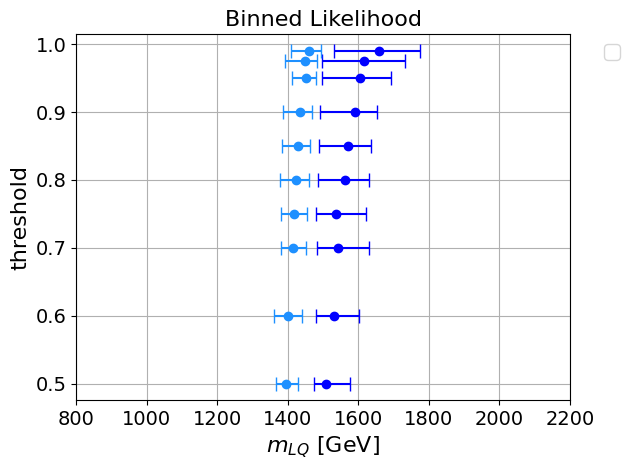

/tmp/ipykernel_667/2379650311.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')


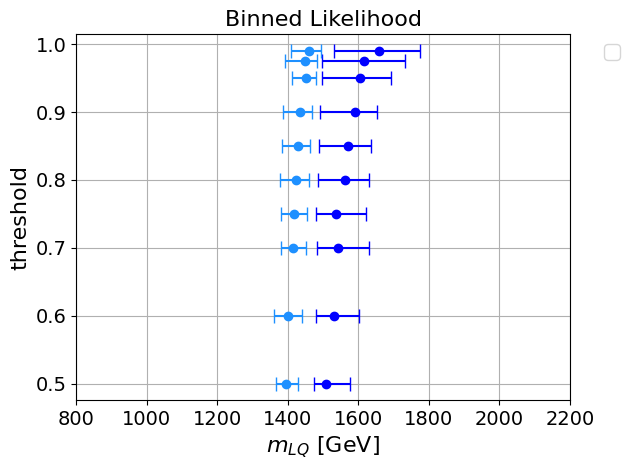

In [ ]:
for ii_tt, th_it in enumerate(threshold_list):

    m_SLQ_T_Z2 = [[save_mSLQ_T_Z2[ii_tt] - save_mSLQ_T_low_Z2[ii_tt]], [save_mSLQ_T_high_Z2[ii_tt] - save_mSLQ_T_Z2[ii_tt]]]
    plt.errorbar(save_mSLQ_T_Z2[ii_tt], th_it, xerr=m_SLQ_T_Z2, fmt='o', capsize=5, color='blue')#, label='14 TeV, 3000 fb-1 (SLQ id Z=2)')

    m_SLQ_T_Z5 = [[save_mSLQ_T_Z5[ii_tt] - save_mSLQ_T_low_Z5[ii_tt]], [save_mSLQ_T_high_Z5[ii_tt] - save_mSLQ_T_Z5[ii_tt]]]
    plt.errorbar(save_mSLQ_T_Z5[ii_tt], th_it, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue')#, label='14 TeV, 3000 fb-1 (SLQ id Z=5)')

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(800,2200)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"threshold",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




for ii_tt, th_it in enumerate(threshold_list):

    m_VLQ_T_Z2 = [[save_mVLQ_T_Z2[ii_tt] - save_mVLQ_T_low_Z2[ii_tt]], [save_mVLQ_T_high_Z2[ii_tt] - save_mVLQ_T_Z2[ii_tt]]]
    plt.errorbar(save_mVLQ_T_Z2[ii_tt], th_it, xerr=m_VLQ_T_Z2, fmt='o', capsize=5, color='blue')#, label='14 TeV, 3000 fb-1 (VLQ id Z=2)')

    m_VLQ_T_Z5 = [[save_mVLQ_T_Z5[ii_tt] - save_mVLQ_T_low_Z5[ii_tt]], [save_mVLQ_T_high_Z5[ii_tt] - save_mVLQ_T_Z5[ii_tt]]]
    plt.errorbar(save_mVLQ_T_Z5[ii_tt], th_it, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue')#, label='14 TeV, 3000 fb-1 (VLQ id Z=5)')

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(800,2200)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"threshold",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
mu_S

[np.float32(-340.56357),
 np.float32(-200.01706),
 np.float32(-125.86859),
 np.float32(-186.27647),
 np.float32(-64.53027),
 np.float32(-62.861675),
 np.float32(-48.09226),
 np.float32(-40.30694)]

In [ ]:
mu_TSLQ[ii_S] - mu_S[ii_S]

np.float32(-2.5766106)

29.341423
29.384552
0.6560941646209575
1.5914698
1.5914698

22.168629
22.924389
0.4957056072466616
5.8377647
5.8377647

17.621794
20.306074
0.3940352870365699
10.090046
10.090046

19.519316
28.09133
0.4364651682331587
20.201958
20.201958

13.735195
20.391802
0.3071283006178957
15.07216
15.07216

13.237918
14.002687
0.2960088430515233
4.564294
4.564294

12.307812
12.514534
0.2752110369833715
2.2652445
2.2652445

12.082591
12.077105
0.2701749494738888
0.36407843
0.36407843



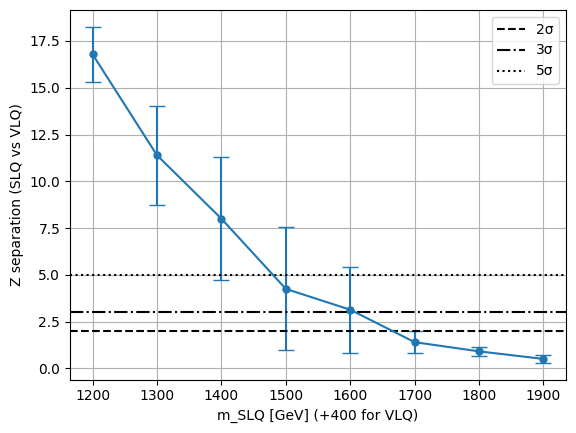

 Z:        1.96
 S:        56.878322834788705
 m_SLQ:    1668.0049328388568  [GeV]
 m_VLQ:    2068.004932838857  [GeV]



In [ ]:

Z_gauss = []
Z_gauss_std = []

for ii_S, S_exp in enumerate(S_expected):

    # 1. Calculo de Z
    num = abs(mu_S[ii_S] - mu_V[ii_S])
    den = np.sqrt(sigma_S[ii_S]**2 + sigma_V[ii_S]**2)

    Z = num / den


    # 2. Errores
    # Numero de pseudo experimentos
    N_S = n_pseudo_TRUE
    N_V = n_pseudo_TRUE

    # Means
    # gaussianas
    delta_mu_S_gauss = sigma_S[ii_S] / np.sqrt(N_S)
    delta_mu_V_gauss = sigma_V[ii_S] / np.sqrt(N_V)
    # pseudo
    delta_mu_S_pseudo = abs(mu_S[ii_S] - mu_TSLQ[ii_S])
    delta_mu_V_pseudo = abs(mu_V[ii_S] - mu_TVLQ[ii_S])


    delta_mu_S = np.sqrt( delta_mu_S_gauss**2 + delta_mu_S_pseudo**2 )
    delta_mu_V = np.sqrt( delta_mu_V_gauss**2 + delta_mu_V_pseudo**2 )

    # delta_mu_S = delta_mu_S_gauss
    # delta_mu_V = delta_mu_V_gauss

    # delta_mu_S = delta_mu_S_pseudo
    # delta_mu_V = delta_mu_V_pseudo

    # STD
    # gaussianas
    delta_sigma_S_gauss = sigma_S[ii_S] / np.sqrt(2 * N_S)
    delta_sigma_V_gauss = sigma_V[ii_S] / np.sqrt(2 * N_V)
    # pseudo
    delta_sigma_S_pseudo = np.sqrt( abs(sigma_S[ii_S]**2 - std_TSLQ[ii_S]**2) )
    delta_sigma_V_pseudo = np.sqrt( abs(sigma_V[ii_S]**2 - std_TVLQ[ii_S]**2) )
    print(sigma_S[ii_S])
    print(std_TSLQ[ii_S])
    print(delta_sigma_S_gauss)
    print(delta_sigma_S_pseudo)
    print(delta_sigma_S_pseudo)
    print('')


    delta_sigma_S = np.sqrt( delta_sigma_S_gauss**2 + delta_sigma_S_pseudo**2 )
    delta_sigma_V = np.sqrt( delta_sigma_V_gauss**2 + delta_sigma_V_pseudo**2 )

    # delta_sigma_S = delta_sigma_S_gauss
    # delta_sigma_V = delta_sigma_V_gauss


    # 3. Propagación para num = |mu_S - mu_V|
    delta_num = np.sqrt(delta_mu_S**2 + delta_mu_V**2)

    # Propagación para den = sqrt(sigma_S^2 + sigma_V^2)
    # Usando derivada parcial: dden/dsigma_S = sigma_S / den
    delta_den = np.sqrt((sigma_S[ii_S] * delta_sigma_S)**2 + (sigma_V[ii_S] * delta_sigma_V)**2) / den

    # 4. Propagación final para Z = num / den
    delta_Z = np.abs(Z) * np.sqrt((delta_num / num)**2 + (delta_den / den)**2)


    Z_gauss.append(Z)
    Z_gauss_std.append(delta_Z)


# plt.plot(mass_list_SLQ, Z_gauss, marker='o')
plt.errorbar(mass_list_SLQ, Z_gauss, yerr=Z_gauss_std, fmt='o', markersize=5, capsize=6, linestyle='-')
plt.axhline(2, color='black', linestyle='--', label='2σ')
plt.axhline(3, color='black', linestyle='-.', label='3σ')
plt.axhline(5, color='black', linestyle=':', label='5σ')

plt.xlabel("m_SLQ [GeV] (+400 for VLQ)")
plt.ylabel("Z separation (SLQ vs VLQ)")
plt.legend()
plt.grid()
plt.show()

print(' Z:       ', Z_threshold)
print(' S:       ', S_threshold)
print(' m_SLQ:   ', mSLQ_threshold, ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold, ' [GeV]\n')

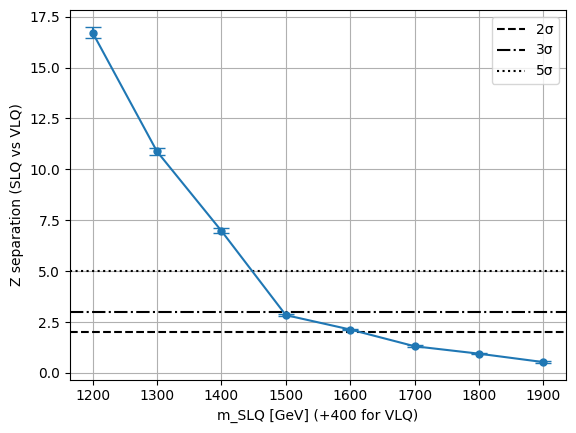

 Z:        1.96
 S:        56.878322834788705
 m_SLQ:    1668.0049328388568  [GeV]
 m_VLQ:    2068.004932838857  [GeV]



In [ ]:
Z_gauss = []
Z_gauss_std = []

for ii_S, S_exp in enumerate(S_expected):

    N_S = n_pseudo
    N_V = n_pseudo

    # 1. solo pseudo
    mu_S_real = mu_TSLQ[ii_S]
    mu_V_real = mu_TVLQ[ii_S]
    sigma_S_real = std_TSLQ[ii_S]
    sigma_V_real = std_TVLQ[ii_S]

    # 2. Nueva Z observada
    num = abs(mu_S_real - mu_V_real)
    den = np.sqrt(sigma_S_real**2 + sigma_V_real**2)
    Z = num / den

    # 3. Incertidumbre puramente estadística (de los Toys)
    # Error de la media (Standard Error)
    delta_mu_S = sigma_S_real / np.sqrt(N_S)
    delta_mu_V = sigma_V_real / np.sqrt(N_V)

    # Error de la desviación estándar
    delta_sigma_S = sigma_S_real / np.sqrt(2 * N_S)
    delta_sigma_V = sigma_V_real / np.sqrt(2 * N_V)

    # 4. Propagación
    delta_num = np.sqrt(delta_mu_S**2 + delta_mu_V**2)
    delta_den = np.sqrt((sigma_S_real * delta_sigma_S)**2 + (sigma_V_real * delta_sigma_V)**2) / den

    delta_Z = Z * np.sqrt((delta_num / num)**2 + (delta_den / den)**2)


    Z_gauss.append(Z)
    Z_gauss_std.append(delta_Z)




# plt.plot(mass_list_SLQ, Z_gauss, marker='o')
plt.errorbar(mass_list_SLQ, Z_gauss, yerr=Z_gauss_std, fmt='o', markersize=5, capsize=6, linestyle='-')
plt.axhline(2, color='black', linestyle='--', label='2σ')
plt.axhline(3, color='black', linestyle='-.', label='3σ')
plt.axhline(5, color='black', linestyle=':', label='5σ')

plt.xlabel("m_SLQ [GeV] (+400 for VLQ)")
plt.ylabel("Z separation (SLQ vs VLQ)")
plt.legend()
plt.grid()
plt.show()

print(' Z:       ', Z_threshold)
print(' S:       ', S_threshold)
print(' m_SLQ:   ', mSLQ_threshold, ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold, ' [GeV]\n')

In [ ]:
mu_TSLQ

[np.float32(-341.744),
 np.float32(-201.80289),
 np.float32(-129.40543),
 np.float32(-184.62094),
 np.float32(-70.81886),
 np.float32(-61.006733),
 np.float32(-50.74215),
 np.float32(-42.88355)]

In [ ]:
mu_S

[np.float32(-340.56357),
 np.float32(-200.01706),
 np.float32(-125.86859),
 np.float32(-186.27647),
 np.float32(-64.53027),
 np.float32(-62.861675),
 np.float32(-48.09226),
 np.float32(-40.30694)]

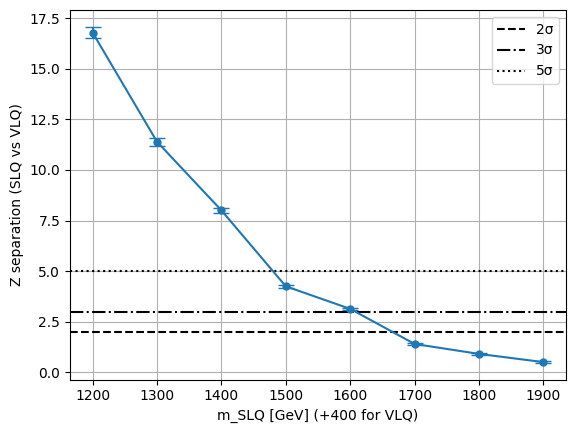

 Z:        1.96
 S:        56.878322834788705
 m_SLQ:    1668.0049328388568  [GeV]
 m_VLQ:    2068.004932838857  [GeV]



In [ ]:
Z_gauss = []
Z_gauss_std = []

for ii_S, S_exp in enumerate(S_expected):

    N_S = n_pseudo
    N_V = n_pseudo

    # 1. solo pseudo
    mu_S_real = mu_S[ii_S]
    mu_V_real = mu_V[ii_S]
    sigma_S_real = sigma_S[ii_S]
    sigma_V_real = sigma_V[ii_S]

    # 2. Nueva Z observada
    num = abs(mu_S_real - mu_V_real)
    den = np.sqrt(sigma_S_real**2 + sigma_V_real**2)
    Z = num / den

    # 3. Incertidumbre puramente estadística (de los Toys)
    # Error de la media (Standard Error)
    delta_mu_S = sigma_S_real / np.sqrt(N_S)
    delta_mu_V = sigma_V_real / np.sqrt(N_V)

    # Error de la desviación estándar
    delta_sigma_S = sigma_S_real / np.sqrt(2 * N_S)
    delta_sigma_V = sigma_V_real / np.sqrt(2 * N_V)

    # 4. Propagación
    delta_num = np.sqrt(delta_mu_S**2 + delta_mu_V**2)
    delta_den = np.sqrt((sigma_S_real * delta_sigma_S)**2 + (sigma_V_real * delta_sigma_V)**2) / den

    delta_Z = Z * np.sqrt((delta_num / num)**2 + (delta_den / den)**2)


    Z_gauss.append(Z)
    Z_gauss_std.append(delta_Z)




# plt.plot(mass_list_SLQ, Z_gauss, marker='o')
plt.errorbar(mass_list_SLQ, Z_gauss, yerr=Z_gauss_std, fmt='o', markersize=5, capsize=6, linestyle='-')
plt.axhline(2, color='black', linestyle='--', label='2σ')
plt.axhline(3, color='black', linestyle='-.', label='3σ')
plt.axhline(5, color='black', linestyle=':', label='5σ')

plt.xlabel("m_SLQ [GeV] (+400 for VLQ)")
plt.ylabel("Z separation (SLQ vs VLQ)")
plt.legend()
plt.grid()
plt.show()

print(' Z:       ', Z_threshold)
print(' S:       ', S_threshold)
print(' m_SLQ:   ', mSLQ_threshold, ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold, ' [GeV]\n')

In [ ]:
Z_threshold = 1.96

n_pseudo = 1000

# results_Z = {}
classification_SLQ = []
classification_VLQ = []

threshold_list = [0.1, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99]

for ii_th, th_set in enumerate(threshold_list):

    print("\n==========================")
    print("threshold selected =", th_set)


    for ii_S, S_exp in enumerate(S_expected):

        print("\n==========================")
        print("S_expected =", S_exp)

        muS_fits = []
        muB_fits = []


        # dado un S, le asigna la masa (del SLQ) correspondiente
        mass_SLQ = mass_list_SLQ[S_expected.index(S_exp)]
        mass_VLQ = mass_list_VLQ[S_expected.index(S_exp)]
        print("mass_SLQ =", mass_SLQ, " GeV")
        print("mass_VLQ =", mass_VLQ, " GeV")

    #    # Con esa masa se fija en que sector cae (clasificador B)
    #    sector = mass_to_sector[mass]


        # computamos el T statistic para todos los pseudo
        T_SLQ = []
        T_VLQ = []

        # compute the number of events
        muS_fits_SLQ = []
        muS_fits_VLQ = []

        # sector
        sector_SLQ = []
        sector_VLQ = []

        for i in range(n_pseudo):

            N_B = np.random.poisson(B_expected)
            N_S = np.random.poisson(S_exp)

            # indices of the events
            idx_B = np.random.choice(len(events_SM["scoresA"]), N_B)

            scoresA_B = events_SM["scoresA"][idx_B]
            scoresB_B = events_SM["scoresB"][idx_B]



            ###########
            # FOR SLQ #
            ###########

            # indices of the events
            idx_S = np.random.choice(len(events_SLQ[mass_SLQ]["scoresA"]), N_S)

            scoresA_S = events_SLQ[mass_SLQ]["scoresA"][idx_S]


            data_scores = np.concatenate([scoresA_B, scoresA_S])

            hist_data, _ = np.histogram(data_scores, bins=bins)

            # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
            def neg_logL(params):
                mu_S, mu_B = params

                lambda_i = mu_S * pS + mu_B * pB
                lambda_i = np.clip(lambda_i, 1e-10, None)

                return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

            # 3) Minimizar
            result = minimize(
                neg_logL,
                x0=[S_exp, B_expected],
                bounds=[(0, None), (0, None)]
            )

            muS_fit, muB_fit = result.x

            muS_fits_SLQ.append(muS_fit)

            # Compare with the theoretical S_expected
            diffs = [abs(muS_fit - S_th) for S_th in S_expected]
            best_idx = np.argmin(diffs)

            # the estimated mass
            mass_best = mass_list_SLQ[best_idx]

            # the estimated sector
            sector_pred = mass_to_sector[mass_best]
            sector_SLQ.append(sector_pred)


            scoresB_S = events_SLQ[mass_SLQ]["scoresB"][sector_pred][idx_S]

            scoresA = np.concatenate([scoresA_B, scoresA_S])
            scoresB = np.concatenate([scoresB_B, scoresB_S])

            T = compute_test_statistic(scoresA, scoresB, threshold_A)

            T_SLQ.append(T)




            ###########
            # FOR VLQ #
            ###########
            # indices of the events
            idx_S = np.random.choice(len(events_VLQ[mass_VLQ]["scoresA"]), N_S)

            scoresA_S = events_VLQ[mass_VLQ]["scoresA"][idx_S]


            data_scores = np.concatenate([scoresA_B, scoresA_S])

            hist_data, _ = np.histogram(data_scores, bins=bins)

            # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
            def neg_logL(params):
                mu_S, mu_B = params

                lambda_i = mu_S * pS + mu_B * pB
                lambda_i = np.clip(lambda_i, 1e-10, None)

                return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

            # 3) Minimizar
            result = minimize(
                neg_logL,
                x0=[S_exp, B_expected],
                bounds=[(0, None), (0, None)]
            )

            muS_fit, muB_fit = result.x

            muS_fits_VLQ.append(muS_fit)

            # Compare with the theoretical S_expected
            diffs = [abs(muS_fit - S_th) for S_th in S_expected]
            best_idx = np.argmin(diffs)

            # the estimated mass (assuming it is SLQ, just to compute the sector)
            mass_best = mass_list_SLQ[best_idx]

            # the estimated sector
            sector_pred = mass_to_sector[mass_best]
            sector_VLQ.append(sector_pred)


            scoresB_S = events_VLQ[mass_VLQ]["scoresB"][sector_pred][idx_S]

            scoresA = np.concatenate([scoresA_B, scoresA_S])
            scoresB = np.concatenate([scoresB_B, scoresB_S])

            T = compute_test_statistic(scoresA, scoresB, threshold_A)

            T_VLQ.append(T)




        # rango común para plotear
        xmin = min(np.min(T_SLQ), np.min(T_VLQ))
        xmax = max(np.max(T_SLQ), np.max(T_VLQ))
        x = np.linspace(xmin, xmax, 500)

        # gaussianas
        gauss_S = (1/(sigma_S[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_S[ii_S])**2 / (2*sigma_S[ii_S]**2))
        gauss_V = (1/(sigma_V[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_V[ii_S])**2 / (2*sigma_V[ii_S]**2))


        # plot
        plt.figure(figsize=(6,5))

        plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label="SLQ pseudos")
        plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label="VLQ pseudos")

        # gaussianas
        plt.plot(x, gauss_S, color='darkred', linewidth=2, linestyle='--', label=f"Gaussian SLQ true\nμ={mu_S[ii_S]:.2f}, σ={sigma_S[ii_S]:.2f}")
        plt.plot(x, gauss_V, color='darkgreen', linewidth=2, linestyle='--', label=f"Gaussian VLQ true\nμ={mu_V[ii_S]:.2f}, σ={sigma_V[ii_S]:.2f}")

        plt.xlabel("Test statistic T")
        plt.ylabel("Probability density")
        plt.title(f"S_expected = {S_exp}")
        plt.legend()

        plt.show()


        # Vamos a clasificar cada pseudo
        # 0: SLQ
        # 1: VLQ
        # 2: compatible con ambos
        # 3: incompatible con ambos
        pred_counts_SLQ = [0,0,0,0]
        pred_counts_VLQ = [0,0,0,0]

        for i in range(n_pseudo):

            # TRUE: SLQ
            T_obs = T_SLQ[i]

            Z_SLQ = abs(T_obs - mu_S[sector_SLQ[i]]) / sigma_S[sector_SLQ[i]]
            Z_VLQ = abs(T_obs - mu_V[sector_SLQ[i]]) / sigma_V[sector_SLQ[i]]

            SLQ_ok = Z_SLQ < Z_threshold
            VLQ_ok = Z_VLQ < Z_threshold

            # p_SLQ = np.mean(np.array(T_SLQ) >= T_obs)
            # p_VLQ = np.mean(np.array(T_VLQ) <= T_obs)

            # SLQ_ok = p_SLQ > 0.05
            # VLQ_ok = p_VLQ > 0.05


            if SLQ_ok and not VLQ_ok:
                pred = 0
            elif VLQ_ok and not SLQ_ok:
                pred = 1
            elif SLQ_ok and VLQ_ok:
                pred = 2
            else:
                pred = 3

            pred_counts_SLQ[pred] += 1


            # TRUE: VLQ
            T_obs = T_VLQ[i]

            Z_SLQ = abs(T_obs - mu_S[sector_VLQ[i]]) / sigma_S[sector_VLQ[i]]
            Z_VLQ = abs(T_obs - mu_V[sector_VLQ[i]]) / sigma_V[sector_VLQ[i]]

            SLQ_ok = Z_SLQ < Z_threshold
            VLQ_ok = Z_VLQ < Z_threshold

            # p_SLQ = np.mean(np.array(T_SLQ) >= T_obs)
            # p_VLQ = np.mean(np.array(T_VLQ) <= T_obs)

            # SLQ_ok = p_SLQ > 0.05
            # VLQ_ok = p_VLQ > 0.05


            if SLQ_ok and not VLQ_ok:
                pred = 0
            elif VLQ_ok and not SLQ_ok:
                pred = 1
            elif SLQ_ok and VLQ_ok:
                pred = 2
            else:
                pred = 3

            pred_counts_VLQ[pred] += 1


        # SLQ
        pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

        print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
        print("0 = SLQ only :", pred_counts_SLQ[0])
        print("1 = VLQ only :", pred_counts_SLQ[1])
        print("2 = both     :", pred_counts_SLQ[2])
        print("3 = neither  :", pred_counts_SLQ[3])

        classification_SLQ.append(pred_counts_SLQ)


        print('')

        # VLQ
        pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

        print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
        print("0 = SLQ only :", pred_counts_VLQ[0])
        print("1 = VLQ only :", pred_counts_VLQ[1])
        print("2 = both     :", pred_counts_VLQ[2])
        print("3 = neither  :", pred_counts_VLQ[3])

        classification_VLQ.append(pred_counts_VLQ)


S_expected = 742
mass_SLQ = 1200  GeV
mass_VLQ = 1600  GeV
Z distribuciones (gaussian) = 16.46889


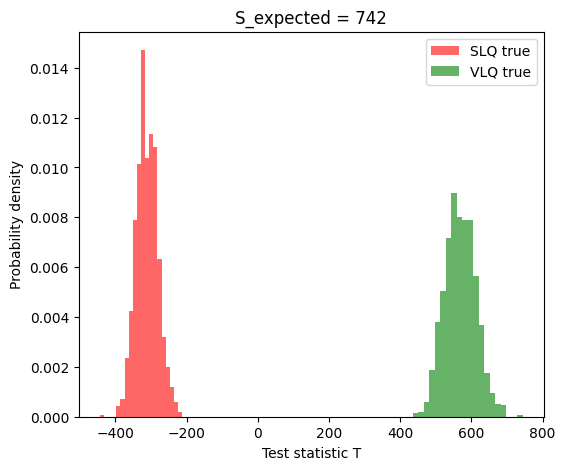

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.03
2 = both     : 0.97
3 = neither  : 0.0

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.973
2 = both     : 0.0
3 = neither  : 0.027

S_expected = 419
mass_SLQ = 1300  GeV
mass_VLQ = 1700  GeV
Z distribuciones (gaussian) = 11.391265


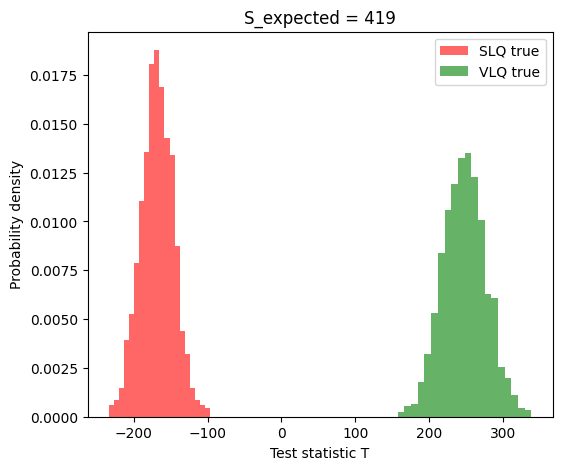

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.023
2 = both     : 0.977
3 = neither  : 0.0

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.97
2 = both     : 0.0
3 = neither  : 0.03

S_expected = 237
mass_SLQ = 1400  GeV
mass_VLQ = 1800  GeV
Z distribuciones (gaussian) = 7.595433


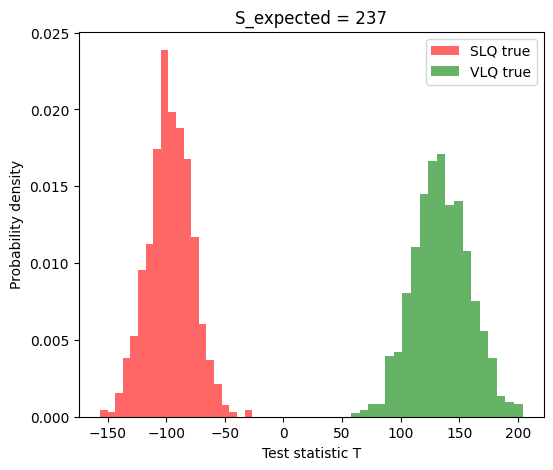

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.028
2 = both     : 0.972
3 = neither  : 0.0

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.975
2 = both     : 0.0
3 = neither  : 0.025

S_expected = 137
mass_SLQ = 1500  GeV
mass_VLQ = 1900  GeV
Z distribuciones (gaussian) = 4.119607


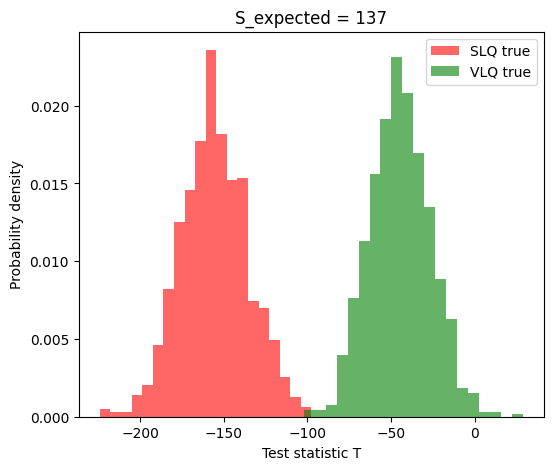

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.028
2 = both     : 0.972
3 = neither  : 0.0

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.977
2 = both     : 0.0
3 = neither  : 0.023

S_expected = 80
mass_SLQ = 1600  GeV
mass_VLQ = 2000  GeV
Z distribuciones (gaussian) = 3.0372548


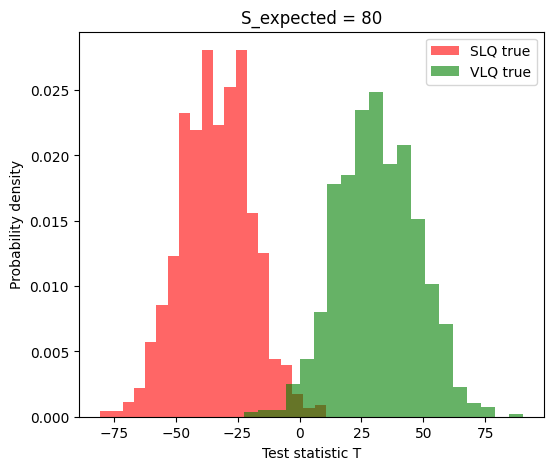

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.027
2 = both     : 0.973
3 = neither  : 0.0

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.97
2 = both     : 0.008
3 = neither  : 0.022

S_expected = 46
mass_SLQ = 1700  GeV
mass_VLQ = 2100  GeV
Z distribuciones (gaussian) = 1.4439763


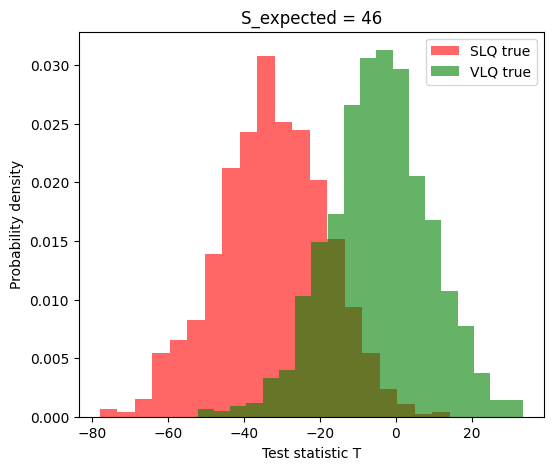

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.021
2 = both     : 0.979
3 = neither  : 0.0

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.491
2 = both     : 0.487
3 = neither  : 0.022

S_expected = 27
mass_SLQ = 1800  GeV
mass_VLQ = 2200  GeV
Z distribuciones (gaussian) = 0.9217723


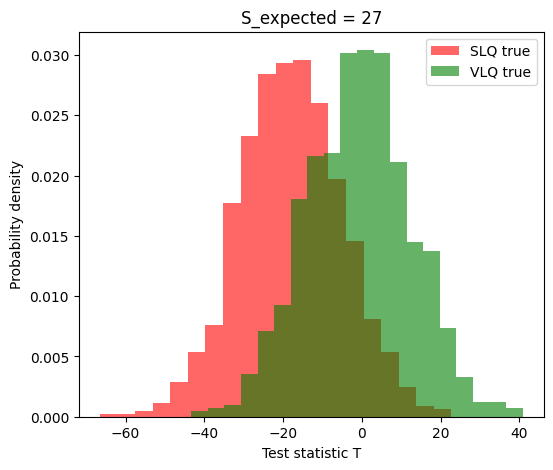

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.027
2 = both     : 0.973
3 = neither  : 0.0

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.237
2 = both     : 0.743
3 = neither  : 0.02

S_expected = 16
mass_SLQ = 1900  GeV
mass_VLQ = 2300  GeV
Z distribuciones (gaussian) = 0.5278514


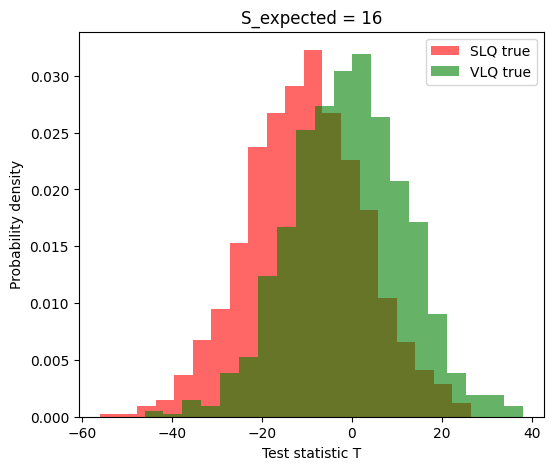

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.03
2 = both     : 0.967
3 = neither  : 0.003

Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.082
2 = both     : 0.895
3 = neither  : 0.023


In [ ]:
Z_threshold = 1.96

n_pseudo = 10

results_Z = []
classification_SLQ = []
classification_VLQ = []


for S_exp in S_expected:

    print("\n==========================")
    print("S_expected =", S_exp)



    # dado un S, le asigna la masa (del SLQ) correspondiente
    mass_SLQ = mass_list_SLQ[S_expected.index(S_exp)]
    mass_VLQ = mass_list_VLQ[S_expected.index(S_exp)]
    print("mass_SLQ =", mass_SLQ, " GeV")
    print("mass_VLQ =", mass_VLQ, " GeV")

    # Con esa masa se fija en que sector cae (clasificador B)
    sector = mass_to_sector[mass]


    # computamos el T statistic para todos los pseudo
    T_SLQ = []
    T_VLQ = []

    for i in range(n_pseudo):

        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_exp)

        scoresA, scoresB = generate_pseudo( events_SM, events_SLQ[mass_SLQ], N_B, N_S )

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_SLQ.append(T)


        scoresA, scoresB = generate_pseudo( events_SM, events_VLQ[mass_VLQ], N_B, N_S )

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_VLQ.append(T)

    # Compute the Z of the distributions
    # mu_S = np.mean(T_SLQ)
    # mu_V = np.mean(T_VLQ)

    # sigma_S = np.std(T_SLQ)
    # sigma_V = np.std(T_VLQ)

    Z = abs(mu_V - mu_S) / np.sqrt(sigma_S**2 + sigma_V**2)

    print("Z distribuciones (gaussian) =", Z)

    results_Z.append(Z)

    # plot
    plt.figure(figsize=(6,5))

    plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label="SLQ true")
    plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label="VLQ true")

    plt.xlabel("Test statistic T")
    plt.ylabel("Probability density")
    plt.title(f"S_expected = {S_exp}")
    plt.legend()

    plt.show()


    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    for i in range(n_pseudo):

        # TRUE: SLQ
        T_obs = T_SLQ[i]

        Z_SLQ = (T_obs - mu_S) / sigma_S
        Z_VLQ = (T_obs - mu_V) / sigma_V

        SLQ_ok = Z_SLQ < Z_threshold
        VLQ_ok = Z_VLQ < Z_threshold

        # p_SLQ = np.mean(np.array(T_SLQ) >= T_obs)
        # p_VLQ = np.mean(np.array(T_VLQ) <= T_obs)

        # SLQ_ok = p_SLQ > 0.05
        # VLQ_ok = p_VLQ > 0.05


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: SLQ
        T_obs = T_VLQ[i]

        Z_SLQ = (T_obs - mu_S) / sigma_S
        Z_VLQ = (T_obs - mu_V) / sigma_V

        SLQ_ok = Z_SLQ < Z_threshold
        VLQ_ok = Z_VLQ < Z_threshold

        # p_SLQ = np.mean(np.array(T_SLQ) >= T_obs)
        # p_VLQ = np.mean(np.array(T_VLQ) <= T_obs)

        # SLQ_ok = p_SLQ > 0.05
        # VLQ_ok = p_VLQ > 0.05


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ.append(pred_counts_VLQ)

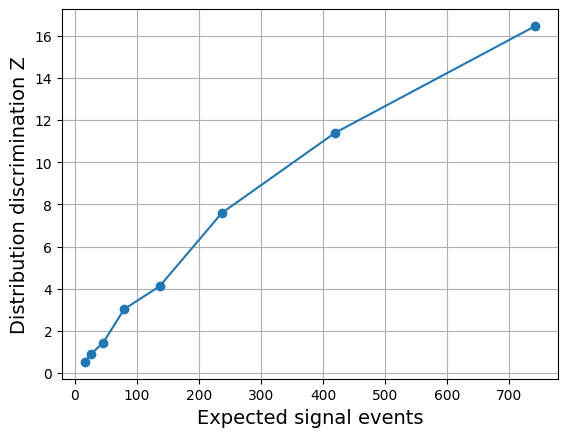

 Z:        1.96
 S:        57.01176352742146
 m_SLQ:    1667.6124602134662  [GeV]
 m_VLQ:    2067.6124602134664  [GeV]



/tmp/ipykernel_43487/4216299278.py:18: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mSLQ_threshold = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1600)[0]
/tmp/ipykernel_43487/4216299278.py:19: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mVLQ_threshold = fsolve(lambda x: f_results_Z_mVLQ(x) - Z_threshold,1600)[0]


In [ ]:
plt.plot(S_expected, results_Z, marker='o')

plt.xlabel("Expected signal events", fontsize=14)
plt.ylabel("Distribution discrimination Z", fontsize=14)

plt.grid()
plt.show()


#  interpolate
f_results_Z = interp1d(S_expected, results_Z, kind='linear', fill_value="extrapolate")
f_results_Z_mSLQ = interp1d(mass_list_SLQ, results_Z, kind='linear', fill_value="extrapolate")
f_results_Z_mVLQ = interp1d(mass_list_VLQ, results_Z, kind='linear', fill_value="extrapolate")


# find the S or the mass such that we get Z_threshold
S_threshold = fsolve(lambda x: f_results_Z(x) - Z_threshold,100)[0]
mSLQ_threshold = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1600)[0]
mVLQ_threshold = fsolve(lambda x: f_results_Z_mVLQ(x) - Z_threshold,1600)[0]

print(' Z:       ', Z_threshold)
print(' S:       ', S_threshold)
print(' m_SLQ:   ', mSLQ_threshold, ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold, ' [GeV]\n')

Min S:  57.01176352742146
Min m_SLQ:  1667.6124602134662  [GeV]
Min m_VLQ:  2067.6124602134664  [GeV]



/tmp/ipykernel_43487/1923402505.py:9: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mSLQ_threshold = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1600)[0]
/tmp/ipykernel_43487/1923402505.py:10: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  mVLQ_threshold = fsolve(lambda x: f_results_Z_mVLQ(x) - Z_threshold,1600)[0]


In [ ]:
#  interpolate



# find the mass such that we get Z for discovery or exclusion

S_threshold = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1600)[0]

S_threshold

/tmp/ipykernel_43487/515854660.py:7: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  S_threshold = fsolve(lambda x: f_results_Z(x) - Z_threshold,1600)[0]


np.float64(1667.6124602134662)

### Usando ahora likelihood 2D (no hay threshold para el 1er clasificador)

In [ ]:
    """
    T = Sum log (P(VLQ) / P(SLQ))

    P(VLQ) = p(score A, score B | H_VLQ)
    P(SLQ) = p(score A, score B | H_VLQ)
    """

'\nT = Sum log (P(VLQ) / P(SLQ))\n\nP(VLQ) = p(score A, score B | H_VLQ)\nP(SLQ) = p(score A, score B | H_VLQ)\n'

##### vamos a binnear para approximar P(VLQ) y P(SLQ)

In [ ]:
num_bins = 15

binsA = np.linspace(0,1,num_bins) # for classifier A
binsB = np.linspace(0,1,num_bins) # for classifier A


# only SLQ
pdf_SLQ = {}

for m in mass_list_SLQ:

    data = events_SLQ[m]

    H, xedges, yedges = np.histogram2d( data[:,0], data[:,1], bins=[binsA, binsB], density=True )

    pdf_SLQ[m] = H + 1e-12


# only VLQ
pdf_VLQ = {}

for m in mass_list_VLQ:

    data = events_VLQ[m]

    H, _, _ = np.histogram2d( data[:,0], data[:,1], bins=[binsA, binsB], density=True )

    pdf_VLQ[m] = H + 1e-12

In [ ]:
# esta funcion sirve para calcular el test statistic

def compute_T_2D(scoresA, scoresB, pdf_S, pdf_V):
    """
    T = Sum log (P(VLQ) / P(SLQ))

    P(VLQ) = p(score A, score B | H_VLQ)
    P(SLQ) = p(score A, score B | H_VLQ)
    """

    T = 0

    for a,b in zip(scoresA, scoresB):

        i = np.digitize(a, binsA) - 1
        j = np.digitize(b, binsB) - 1

        i = np.clip(i,0,len(binsA)-2)
        j = np.clip(j,0,len(binsB)-2)

        pS = pdf_S[i,j]
        pV = pdf_V[i,j]

        T += np.log(pV/pS)

    return T

In [ ]:
B_expected = 45962
# S_expected = [149.0, 77.0, 37.0, 22.0, 12.0, 6.0, 3.0, 2.0] # this correspond to SLQ from 1200-1900 GeV

mass_list_SLQ = [1200,1300,1400,1500,1600,1700,1800,1900]
mass_list_VLQ = [1600,1700,1800,1900,2000,2100,2200,2300]

S_expected = [fid_xsec_SLQ_14TeV(mmm, 0.5) * Lum for mmm in mass_list_SLQ]

#masses:            [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]
#S_expected (SLQ):  [149.0, 77.0, 37.0, 22.0, 12.0, 6.0, 3.0, 2.0, 1.0, 0.0]

#masses:            [1200, 1400, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
#S_expected (VLQ):  [1609.0, 432.0, 130.0, 71.0, 39.0, 23.0, 26.0, 8.0, 4.0, 3.0]


n_pseudo = 500

results_Z_2d = []
classification_SLQ_2d = []
classification_VLQ_2d = []

for S_exp in S_expected:

    print("\n==========================")
    print("S_expected =", S_exp)



    # dado un S, le asigna la masa (del SLQ) correspondiente
    mass_SLQ = mass_list_SLQ[S_expected.index(S_exp)]
    mass_VLQ = mass_list_VLQ[S_expected.index(S_exp)]
    print("mass_SLQ =", mass_SLQ, " GeV")
    print("mass_VLQ =", mass_VLQ, " GeV")

    pdfS = pdf_SLQ[mass_SLQ]
    pdfV = pdf_VLQ[mass_VLQ]


    # compute the T distributions
    T_SLQ = []
    T_VLQ = []

    # pseudo experiments
    for i in range(n_pseudo):

        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_exp)

        # SLQ
        scoresA, scoresB = generate_pseudo( events_SM, events_SLQ[mass_SLQ], N_B, N_S )

        T = compute_T_2D(scoresA, scoresB, pdfS, pdfV)

        T_SLQ.append(T)


        # VLQ
        scoresA, scoresB = generate_pseudo( events_SM, events_VLQ[mass_VLQ], N_B, N_S )

        T = compute_T_2D(scoresA, scoresB, pdfS, pdfV)

        T_VLQ.append(T)



    # Z distributions
    mu_S = np.mean(T_SLQ)
    mu_V = np.mean(T_VLQ)

    sigma_S = np.std(T_SLQ)
    sigma_V = np.std(T_VLQ)

    Z = abs(mu_V - mu_S) / np.sqrt(sigma_S**2 + sigma_V**2)


    print("Z distribuciones (gaussian) =", Z)

    results_Z_2d.append(Z)

    # plot
    plt.figure(figsize=(6,5))

    plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label="SLQ true")
    plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label="VLQ true")

    plt.xlabel("Test statistic T")
    plt.ylabel("Probability density")
    plt.title(f"S_expected = {S_exp}")
    plt.legend()

    plt.show()




    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    for i in range(n_pseudo):

        # TRUE: SLQ
        T_obs = T_SLQ[i]

        p_SLQ = np.mean(np.array(T_SLQ) >= T_obs)
        p_VLQ = np.mean(np.array(T_VLQ) <= T_obs)

        SLQ_ok = p_SLQ > 0.05
        VLQ_ok = p_VLQ > 0.05


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: SLQ
        T_obs = T_VLQ[i]

        p_SLQ = np.mean(np.array(T_SLQ) >= T_obs)
        p_VLQ = np.mean(np.array(T_VLQ) <= T_obs)

        SLQ_ok = p_SLQ > 0.05
        VLQ_ok = p_VLQ > 0.05


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("Classification fractions: (p-value threshold: 0.05)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_2d.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("Classification fractions: (p-value threshold: 0.05)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_2d.append(pred_counts_VLQ)

In [ ]:
plt.plot(S_expected, results_Z_2d, marker='o')

plt.xlabel("Expected signal events", fontsize=14)
plt.ylabel("Distribution discrimination Z", fontsize=14)

plt.grid()
plt.show()

In [ ]:
plt.imshow(pdf_SLQ[1200], origin='lower')
plt.colorbar()
plt.xlabel("score_A bin", fontsize=14)
plt.ylabel("score_B bin", fontsize=14)
plt.title("SLQ pdf")
plt.show()

In [ ]:
plt.imshow(pdf_VLQ[1600], origin='lower')
plt.colorbar()
plt.xlabel("score_A bin", fontsize=14)
plt.ylabel("score_B bin", fontsize=14)
plt.title("VLQ pdf")
plt.show()